In [ ]:
import pandas as pd
import numpy as np
from pandas import DataFrame
from IPython.display import HTML

import textwrap
def wrap_labels(ax, width, break_long_words=False):
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        labels.append(textwrap.fill(text, width=width,
                      break_long_words=break_long_words))
    ax.set_xticklabels(labels, rotation=90)

    

# Loading the data

In [284]:
original_list = pd.read_csv("../input/02-BERTopic/merged.csv", converters={'Local File': str}, index_col=0)
selected_list = pd.read_csv("../input/03-Mapping/clustering_results.csv", converters={'Local File': str}, header=0)

to_remove = [9, 43, 79, 106, 156, 264, 266, 305]
print(f"Selected documents total: {len(selected_list)} but removing {len(to_remove)} documents that are not available or peer reviewed.")
display(selected_list["index"].isin(to_remove))
selected_list = selected_list[~selected_list["index"].isin(to_remove)]
selected_list = selected_list.reset_index(drop=True)

print("Total documents in original list: ", len(original_list))
print("Final selected documents total:", len(selected_list))
print(f"Removed {len(to_remove)} documents: ", to_remove)

display(selected_list[60:])

Selected documents total: 78 but removing 8 documents that are not available or peer reviewed.


0     False
1      True
2     False
3     False
4     False
      ...  
73    False
74    False
75    False
76    False
77    False
Name: index, Length: 78, dtype: bool

Total documents in original list:  399
Final selected documents total: 70
Removed 8 documents:  [9, 43, 79, 106, 156, 264, 266, 305]


,Unnamed: 0,index,Title,DOI,Source,Year,Source title,Cited by,Document Type,Abstract,...,BERTopic_Topic_Label,BERTopic_Probability,BERTopic_Count,BERTopic_Name,BERTopic_Representation,BERTopic_main,BERTopic_openai,BERTopic_aspect1,BERTopic_aspect2,BERTopic_Representative_Docs
60,68,359,Sustainable Software Design,10.1016/B978-0-12-801379-3.00007-3,Scopus,2015,NaN,3.0,Book chapter,The sustainability of software depends on dire...,...,energy_software_consumption,0.445665,18,1_energy_software_consumption_energy consumption,"['energy', 'software', 'consumption', 'energy ...","['software energy', 'energy consumption', 'sus...",Software Energy Efficiency,"['energy', 'software', 'consumption', 'develop...","['software energy', 'sustainable software', 'e...",['Although software does not consume energy by...
61,69,363,Techniques for low energy software,10.1145/263272.263286,IEEE,1997,Proceedings of 1997 International Symposium on...,41.0,IEEE Conferences,The energy consumption of a system depends upo...,...,energy_consumption_design,0.713580,19,0_energy_consumption_design_software,"['energy', 'consumption', 'design', 'software'...","['energy consumption', 'energy efficiency', 'e...",Energy efficiency in software,"['energy', 'consumption', 'design', 'software'...","['energy savings', 'power consumption', 'desig...",['Design patterns are applied frequently durin...
62,70,364,The Energy Cost of the Visitor Pattern,10.1109/ICSME55016.2022.00036,Scopus,2022,NaN,7.0,Conference paper,Design patterns are applied frequently during ...,...,energy_consumption_design,0.758161,19,0_energy_consumption_design_software,"['energy', 'consumption', 'design', 'software'...","['energy consumption', 'energy efficiency', 'e...",Energy efficiency in software,"['energy', 'consumption', 'design', 'software'...","['energy savings', 'power consumption', 'desig...",['Design patterns are applied frequently durin...
63,71,369,The hunt for the guzzler: Architecture-based e...,10.1016/j.infsof.2017.12.003,Scopus,2018,Information and Software Technology,1.0,Article,Context: Software producing organizations have...,...,energy_software_consumption,0.550918,18,1_energy_software_consumption_energy consumption,"['energy', 'software', 'consumption', 'energy ...","['software energy', 'energy consumption', 'sus...",Software Energy Efficiency,"['energy', 'software', 'consumption', 'develop...","['software energy', 'sustainable software', 'e...",['Although software does not consume energy by...
64,72,370,The impact of Distributed programming abstract...,10.1016/j.infsof.2013.02.014,Scopus,2013,Information and Software Technology,18.0,Article,With battery capacities remaining a key physic...,...,Outlier,0.102201,16,-1_energy_cloud_software_consumption,"['energy', 'cloud', 'software', 'consumption',...","['software energy', 'cloud patterns', 'energy ...",Energy efficiency in cloud computing,"['energy', 'cloud', 'software', 'consumption',...","['software energy', 'cloud patterns', 'energy ...",['With billions of lines of code being deploye...
65,73,381,Towards Sustainable Software Engineering: A Gr...,10.1109/ICIC63915.2024.11116549,Scopus,2024,NaN,0.0,Conference paper,The field of software engineering is evolving ...,...,engineering_green_sustainability,0.636581,7,3_engineering_green_sustainability_software en...,"['engineering', 'green', 'sustainability', 'so...","['sustainable software', 'sustainability softw...",Sustainable Software Engineering,"['engineering', 'green', 'sustainability', 'so...","['sustainability software', 'green computing',...",['The field of software engineering is evolvin...
66,74,383,Towards a Knowledge Base of Common Sustainabil...,10.1109/ASE56229.2023.00204,Scopus,2023,NaN,3.0,Conference paper,"With the climate crisis looming, engineering s...",...,engineering_green_sustainability,0.564743,7,3_engineering_green_sustainability_software en...,"['engineering', 'green', 'sustainability', 'so...","['sustainable software', 'sustainability softw...",Sustainabl

# Structuring Knowledge

After reducing the initial list of documents with a total of 399 down to 71, we are going to further structurize the selected papers.
Therefore we first define the goal of structuring the documents:
* Which domains is being addressed by the research? (Besides energy, since all of them are kind of related to energy)
* How many studies exist per domain?
* What research approach has been used?
* What is the context of the study?
* What is the contribution?




|            Aspect | Value |
| ----------------: | ----- |
|   Research Domain |       |
| Research Keywords |       |
| Research Approach/Type\* |       |
|     Study Context |       |
|      Contribution |       |


\*: See Table below

| Category             | Description                                                                                                                                                                                                                                                                                                                                                     |
| -------------------- | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Validation Research  | Techniques investigated are novel and have not yet been implemented in practice. Techniques used are for example experiments, i.e., work done in the lab.                                                                                                                                                                                                       |
| Evaluation Research  | Techniques are implemented in practice and an evaluation of the technique is conducted. That means, it is shown how the technique is implemented in practice (solution implementation) and what are the consequences of the implementation in terms of benefits and drawbacks (implementation evaluation). This also includes to identify problems in industry. |
| Solution Proposal    | A solution for a problem is proposed, the solution can be either novel or a significant extension of an existing technique. The potential benefits and the applicability of the solution is shown by a small example or a good line of argumentation.                                                                                                           |
| Philosophical Papers | These papers sketch a new way of looking at existing things by structuring the field in form of a taxonomy or conceptual framework.                                                                                                                                                                                                                             |
| Opinion Papers       | These papers express the personal opinion of somebody whether a certain technique is good or bad, or how things should been done. They do not rely on related work and research methodologies.                                                                                                                                                                  |
| Experience Papers    | Experience papers explain on what and how something has been done in practice. It has to be the personal experience of the author.                                                                                                                                                                                                                              |




In [285]:
#selected_list.info()

In [286]:
structurized_list = pd.DataFrame()

structurized_list["Title"] = selected_list["Title"]
structurized_list["Authors"] = selected_list["Author full names"]
structurized_list["Year"] = selected_list["Year"]
structurized_list["Abstract"] = selected_list["Abstract"]
structurized_list["DOI"] = selected_list["DOI"]
structurized_list["Type"] = selected_list["Document Type"]
structurized_list["Venue"] = selected_list["Conference name"].fillna(selected_list["Source title"])
structurized_list["Domain"] = ""
structurized_list["Research_Keywords"] = ""
structurized_list["Research_Approach"] = ""
structurized_list["Context"] = ""
structurized_list["Contribution"] = ""

def set_aspects(row_number, domain, keywords, approach, context, contribution, list=structurized_list):
    try:
        if list.loc[row_number, "Title"] == "":
            return
        list.loc[row_number, "Domain"] = domain
        list.loc[row_number, "Research_Keywords"] = keywords
        list.loc[row_number, "Research_Approach"] = approach
        list.loc[row_number, "Context"] = context
        list.loc[row_number, "Contribution"] = contribution

        display(f"{row_number}: {list.loc[row_number, 'Title']}")
    except Exception as e:
        print(f"Error setting aspects for row {row_number}: {e}")

structurized_list

,Title,Authors,Year,Abstract,DOI,Type,Venue,Domain,Research_Keywords,Research_Approach,Context,Contribution
0,A Comparative Analysis of Monolith vs Microser...,"Capuano, Roberta; O’Dea, Eoan; Muccini, Henry",2026,As energy demands rise and sustainability beco...,10.1007/978-3-032-02138-0_17,Conference paper,Software Architecture: 19th European Conferenc...,,,,,
1,A Green Perspective on Structured Parallel Pro...,"Kilpatrick, Peter; M. Torquati; M. Danelutto...",2015,"Structured parallel programming, and in partic...",10.1109/PDP.2015.116,IEEE Conferences,"['', 'Proceedings of the 2015 23rd Euromicro I...",,,,,
2,A Highly-efficient Lattice-based Post-Quantum ...,"Huang, Kejie; Ye, Zewen; Cheung, Ray C.C.; ...",2024,"Lattice-Based Cryptography (LBC) schemes, like...",10.46586/tches.v2024.i2.130-153,Article,IACR Transactions on Cryptographic Hardware an...,,,,,
3,A Multi-Sensor-Based System for Cardiovascular...,"Jin, Wenguang; H. Shan; W. Jin; Shan, Haicheng",2025,With the rising prevalence of cardiovascular d...,10.1109/ICSI64877.2025.11009742,IEEE Conferences,2025 5th International Conference on Sensors a...,,,,,
4,A comprehensive study of task coalescing for s...,"Łuszczek, Piotr R.; Ltaief, Hatem; Dongarra...",2012,We present new high performance numerical kern...,10.1109/IPDPS.2012.13,Conference paper,NaN,,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...
65,Towards Sustainable Software Engineering: A Gr...,"Rauf, Minahil; Kalsum, Tehmina; Ramzan, Hafi...",2024,The field of software engineering is evolving ...,10.1109/ICIC63915.2024.11116549,Conference paper,NaN,,,,,
66,Towards a Knowledge Base of Common Sustainabil...,"Mehra, Rohit; Podder, Sanjay; Pathania, Priy...",2023,"With the climate crisis looming, engineering s...",10.1109/ASE56229.2023.00204,Conference paper,NaN,,,,,
67,Towards a sustainable architectural design by ...,"Casas, Oscar; Cabezas, Ivan Mauricio; Lopez...",2016,Sustainability is a global concern. It must be...,10.1007/978-3-319-42108-7_6,Conference paper,Lecture Notes in Computer Science,,,,,
68,Understanding the impact of cloud patterns on ...,"Khomh, Foutse; Abtahizadeh, S. Amirhossein",2018,Cloud patterns are abstract solutions to recur...,10.1016/j.jss.2018.03.063,Article,Journal of Systems and Software,,,,,


## Document classification

0. **A Comparative Analysis of Monolith vs Microservices Energy Consumption**

As energy demands rise and sustainability becomes critical, Information and Communication Technology’s energy footprint is increasingly monitored. In this context, software architecture may play a significant role in determining a system’s energy consumption. This study aims to evaluate and compare the energy consumption of monolithic and microservice-based software to understand their implications for sustainable software design. We applied a cohort study approach in a controlled experimental environment using two open-source Java applications—PetClinic and TicketMonster —each implemented in both monolithic and microservice versions. Three use cases, representing different workloads, were defined and executed 30 times each per version, resulting in 360 total runs. Server energy use was measured with Powerstat and analyzed using Welch’s t-test. Our findings show that microservices may consume less energy than their monolithic counterparts under medium and heavy loads. Specifically, PetClinic and TicketMonster showed energy reductions of 4.99% and 5.05%, respectively. Across all use cases and applications, microservices demonstrated an average energy saving of 5.02% compared to monoliths. These results suggest that microservice architectures may offer improved energy efficiency in high-demand scenarios due to better resource utilization and modular execution. While the study is limited to controlled conditions and two case studies, it provides a foundation for further research on architectural decisions and sustainable software engineering practices.

|            Aspect | Value                                                                                                                                        |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Architecture                                                                                                                        |
| Research Keywords | Microservice; Monolithic Architecture; Energy Consumption; Software Architecture                                                             |
| Research Approach | Validation Research                                                                                                  |
|     Study Context | Two Open Source Java-Applications, each implemented in both architectures for controlled comparative experiment regarding energy consumption |
|      Contribution | Empirical Evidence                                                                                                                           |


In [287]:
row_number = 0
set_aspects(
    row_number,
    "Software Architecture",
    "Microservice; Monolithic Architecture; Energy Consumption; Software Architecture",
    "Validation Research",
    "Two Open Source Java-Applications, each implemented in both architectures for controlled comparative experiment regarding energy consumption",
    "Empirical evidence"
)     

'0: A Comparative Analysis of Monolith vs Microservices Energy Consumption'

1. **A Framework for Estimating the Impact of a Distributed Software System's Architectural Style on its Energy Consumption**

The selection of an architectural style for a given software system is an important factor in satisfying its quality requirements. In battery-powered environments, such as mobile and pervasive systems, efficiency with respect to energy consumption has increasingly been recognized as an important quality attribute. In this paper, we present a framework that (1) facilitates early estimation of the energy consumption induced by an architectural style in a distributed software system, and (2) consequently enables an engineer to use energy consumption estimates along with other quality attributes in determining the most appropriate style for a given distributed application. We have applied the framework on five distributed systems styles to date, and have evaluated it for precision and accuracy using a particular middleware platform that supports the implementation of those styles. In a large number of application scenarios, our framework exhibited excellent precision, in that it was consistently able to correctly rank the five styles and estimate the relative differences in their energy consumptions. Moreover, the framework has also proven to be accurate: its estimates were within 7% of the different style implementations' actually measured energy consumptions. ¬© 2008 IEEE. 

|            Aspect | Value                                                                                         |
| ----------------: | :-------------------------------------------------------------------------------------------- |
|   Research Domain | Software Architecture                                                                         |
| Research Keywords | Architecture; Distributed Systems; Energy Consumption; Energy-Efficiency; Distributed Systems |
| Research Approach | Solution Proposal                                                                             |
|     Study Context | Five distributed system styles; Framework estimates energy consumption                        |
|      Contribution | Framework                                                                                     |

In [288]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Architecture; Distributed Systems; Energy Consumption; Energy-Efficiency; Distributed Systems",
    "Validation Research",
    "Five distributed system styles; Framework estimates energy consumption",
    "Framework"
)     

'1: A Green Perspective on Structured Parallel Programming'

2. **A Green Perspective on Structured Parallel Programming**

Structured parallel programming, and in particular programming models using the algorithmic skeleton or parallel design pattern concepts, are increasingly considered to be the only viable means of supporting effective development of scalable and efficient parallel programs. Structured parallel programming models have been assessed in a number of works in the context of performance. In this paper we consider how the use of structured parallel programming models allows knowledge of the parallel patterns present to be harnessed to address both performance and energy consumption. We consider different features of structured parallel programming that may be leveraged to impact the performance/energy trade-off and we discuss a preliminary set of experiments validating our claims. 

|            Aspect | Value                                                                                                |
| ----------------: | :--------------------------------------------------------------------------------------------------- |
|   Research Domain | Parallel Programming                                                                                 |
| Research Keywords | Structured Parallel Programming; Algorithmic Skeletons; Parallel Design Patterns; Energy Consumption |
| Research Approach | Validation Research                                                                                  |
|     Study Context | Parallel Software Systems                                                                            |
|      Contribution | Conceptual Framework                                                                                 |

In [289]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Parallel Programming",
    "Structured Parallel Programming; Algorithmic Skeletons; Parallel Design Patterns; Energy Consumption",
    "Validation Research",
    "Parallel Software Systems",
    "Conceptual Framework",
)

'2: A Highly-efficient Lattice-based Post-Quantum Cryptography Processor for IoT Applications'

3. **A Measurement-Driven Approach to Enhancing Sustainability in Microservice Architectures**

The Information and Communication Technology (ICT) sector plays a significant role in shaping modern society, but its environmental impact has become a growing concern due to the increasing energy demands of complex systems. Among these, microservice architectures are gaining widespread adoption for their flexibility and scalability in software design. However, their distributed nature and intricate communication patterns may introduce unique challenges in achieving energy efficiency, further contributing to the sector's environmental footprint. This research proposes a comprehensive framework to evaluate the energy efficiency of microservice-based systems. The frame-work includes a systematic method for energy assessment, identification of inefficiencies through anti-pattern analysis, and the application of green refactoring strategies that optimize energy consumption while maintaining other software quality attributes, such as performance and maintainability. By addressing these attributes through measurement-driven optimization, this study ensures that energy efficiency improvements do not compromise the long-term health of software systems. The outcomes aim to provide actionable tools and insights to integrate sustainability into the software development lifecycle of microservice-based applications. 

|      Aspect       | Value                                                                   |
| :---------------: | :---------------------------------------------------------------------- |
|  Research Domain  | Software Architecture                                |
| Research Keywords | Microservices; Software-Architecture; Anti-Patterns; Energy Consumption |
| Research Approach | Solution Proposal                                                       |
|   Study Context   | Development Lifecycle of nicroservice-based apps                        |
|   Contribution    | Framework                                                               |

In [290]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Microservices; Software-Architecture; Anti-Patterns; Energy Consumption; Energy Efficiency",
    "Solution Proposal",
    "Development Lifecycle of microservice-based apps",
    "Framework",
)

'3: A Multi-Sensor-Based System for Cardiovascular Health Monitoring'

4. **A comparative study on the energy consumption of Progressive Web Apps**

Progressive Web Apps (PWAs) are a promising approach for developing mobile apps, especially when developing apps for multiple mobile systems. As mobile devices are limited with respect to battery capacity, developers should keep the energy footprint of a mobile app as low as possible. The goal of this study is to analyze the difference in energy consumption of PWAs compared to other mobile development approaches. As mobile apps are primarily interactive in nature, we focus on UI rendering and interaction scenarios. For this, we implemented five versions of the same app with different development approaches and examined their energy footprint on two Android devices with four execution scenarios. Additionally, we extended our research by analyzing multiple real-world mobile apps to include a more practical perspective. Regarding execution environments, we also compared the energy consumption of PWAs executed in different web-browsers. The results based on sample and real-world apps show that the used development approach influences the energy footprint of a mobile app. Native development shows the lowest energy consumption. PWAs, albeit having a higher energy consumption than native apps, are a viable alternative to other mobile cross-platform development (MCPD) approaches. The experiments could not assert an inherent technological disadvantage of PWAs in contrast to other MCPD approaches when considering UI energy consumption. Moreover, the web-browser engine used to execute the PWA has a significant influence on the energy footprint of the app. 

|      Aspect       | Value                                                                    |
| :---------------: | :----------------------------------------------------------------------- |
|  Research Domain  | Mobile Software Engineering                                              |
| Research Keywords | Progressive-Web-Apps; Energy Consumption; Mobile-Apps; Energy Efficiency |
| Research Approach | Validation Research                                                      |
|   Study Context   | Mobile Applications Energy Consumption                                   |
|   Contribution    | Empirical comparison                                                     |

In [291]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Mobile Software Engineering",
    "Progressive-Web-Apps; Energy Consumption; Mobile-Apps; Energy Efficiency",
    "Validation Research",
    "Mobile Applications Energy Consumption",
    "Empirical evidence",
)

'4: A comprehensive study of task coalescing for selecting parallelism granularity in a two-stage bidiagonal reduction'

5. **A framework for estimating the energy consumption induced by a distributed system's architectural style**

The architectural style used in a software system is an important factor in satisfying its quality requirements. In battery-powered environments, such as mobile and pervasive systems, efficiency with respect to energy consumption is often an important quality requirement. In this paper, we present a framework that facilitates early estimation of the energy consumption induced by an architectural style in a distributed system, and enables an engineer to use energy consumption estimates along with other quality attributes in determining the most appropriate style for a given distributed application. We apply the framework to three architectural styles, and evaluate it for precision and accuracy using a middleware platform that supports the implementation of those styles. In a large number of application scenarios, our framework exhibited excellent precision, in that it was consistently able to correctly rank the styles and estimate the relative differences in their energy costs. Moreover, the framework has also proven to be accurate: its estimates were within 7% of each style implementation's actual energy cost. ¬© 2009 ACM. 


|      Aspect       | Value                                                                                         |
| :---------------: | :-------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Architecture                                                                         |
| Research Keywords | Architecture; Distributed Systems; Energy Consumption; Energy-Efficiency; Distributed Systems |
| Research Approach | Validation Research                                                                           |
|   Study Context   | Three distributed system styles; Framework estimates energy consumption                       |
|   Contribution    | Framework                                                                                     |

In [292]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Architecture; Distributed Systems; Energy Consumption; Energy-Efficiency; Distributed Systems",
    "Validation Research",
    "Distributed Systems; Energy Consumption",
    "Framework"
)

"5: A framework for estimating the impact of a distributed software system's architectural style on its energy consumption"

6. **An aspect oriented model for software energy efficiency in decentralised servers**

Green software is currently gaining interests with the increasing impact of IT in energy consumption. Green-ness in software however, can be achieved at various stages of the Software Development Life Cycle (SDLC). Consequently, several software engineering concepts can be adopted for achieving greener software. Aspect Oriented Programming (AOP) has been used in solving several crosscutting concerns of software, such as security and performance, but has not been well explored within the context of Energy Efficiency (EE). In this paper we propose and implement an Aspect-oriented Model for EE (AMEE) which adopts AOP for software EE as a crosscutting concern and consequently reducing computational energy consumption based on client-server architecture, where the server layer is distributed. By using a selected case study, the paper presents the energy saving outcome of using AMEE model for different simulated workload patterns. 

|      Aspect       | Value                                                                                                                       |
| :---------------: | :-------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Architecture                                                                                                       |
| Research Keywords | Aspect Oriented Programming; Software Development Life Cycle;   Energy Consumption;  Energy Efficiency; Distributed Systems |
| Research Approach | Solution Proposal                                                                                                           |
|   Study Context   | Distributed Architecture evaluated in Case-Study with developed aspect-oriented model                                                       |
|   Contribution    | Model                                                                                                                       |

In [293]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Aspect Oriented Programming; Software Development Life Cycle; Energy Consumption;  Energy Efficiency; Distributed Systems",
    "Solution Proposal",
    "Distributed Architecture evaluated in Case-Study with developed aspect-oriented model",
    "Model",
)

'6: An adaptive offloading framework for Android applications in mobile edge computing'

7. **An embedded software power consumption model based on software architecture and support vector machine regression**

As embedded devices prevail in daily life, high energy consumption caused by embedded software caught academic attentions. Multifarious testing and predicting methods are developed accordingly. This paper proposes a model about energy consumption of embedded device based on analysis of embedded software structure and support vector machine regression. The nonlinear relationship between energy consumption and software structure is revealed. The research finds software structure is determined by features like number of components, complexity of component interface, component coupling, and path length. These features are qualified and modeled by using support vector machine regression and energy consumption is predicted based on this model. The experiments results confirm the proposed model. 


|      Aspect       | Value                                                                                                                                            |
| :---------------: | :----------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Architecture                                                                                                                            |
| Research Keywords | Energy Consumption Modelling; Architecture; Metrics; Support Vector Machine; Machine Learning; Embedded Software-Engineering; Energy Consumption |
| Research Approach | Validation Research                                                                                                                              |
|   Study Context   | Embedded Software Systems analyzed through architectural features and validated using experimental prediction results using machine learning                            |
|   Contribution    | Model                                                                |

In [294]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Energy Consumption Modelling; Architecture; Metrics; Support Vector Machine; Machine Learning; Embedded Software-Engineering; Energy Consumption",
    "Validation Research",
    "Embedded Software Systems analyzed through architectural features and validated using experimental prediction results using machine learning",
    "Model",
)

'7: An effective measurement technique of level-2 cache performance for multicore embedded systems'

8. **An empirical investigation into code smell elimination sequences for energy efficient software**

Recent research has shown that maintainability improving activities, such as removing code smells using recommended refactoring activities, may degrade the energy consumption behavior of software systems. However, current research is still immature and requires considerable effort for transferring findings to practice. This work empirically investigates the impact of eliminating a set of three notorious code smells, individually as well as in all six possible sequences, on energy consumption behavior of software systems. It also analyzes whether any relationship exists between software architecture sustainability (in terms of energy efficiency) and maintainability within the context of individual and sequential code smell elimination. The study outcomes show that the selected code smell removal permutations yield variant levels of energy consumption values for the resulted refactored software versions. Also, a particular permutation is learned to yield most energy-efficient refactored software versions, when compared to all other code smell removal permutations. 

|      Aspect       | Value                                                                                                                                                            |
| :---------------: | :--------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Code Smells                                                                                                                                                      |
| Research Keywords | Code Smells; Maintenance and Sustainability; Software Architectures; Refactoring; Software Maintenance; Energy Efficiency                                        |
| Research Approach | Validation Research                                                                                                                                             |
|   Study Context   | Software system evaluated through empirical refactoring experiments (code smell elimination sequences) and their impact on energy consumption and sustainability |
|   Contribution    | Empirical evidence                                       |


In [295]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Code Smells",
    "Code Smells; Maintenance and Sustainability; Software Architectures; Refactoring; Software Maintenance; Energy Efficiency",
    "Validation Research",
    "Software system evaluated through empirical refactoring experiments (code smell elimination sequences) and their impact on energy consumption and sustainability",
    "Empirical evidence",
)

'8: An empirical evaluation of database software features on energy consumption'

9. **Analysis of Architectural solutions Impact on Energy Consumption: Graph-Based Analysis**

The prevalence of mobile computing platforms and the Internet of Things applications has triggered a quest to evolve energy-efficient software systems. Thus, addressing energy efficiency at the architectural level is a booming topic of interest. By this paper, we aim to propose an energy-driven architecture that encloses the most relevant artifacts tackled throughout the software design to analyze energy consumption. Our approach combines the meta-Modelling and the graph transformations to formalize the understudied system and to survey the energy consumption. The energy consumption analysis is held on different alternative solutions of software architecture in a precocious stage for design more energy-efficient applications. 


|      Aspect       | Value                                                                                                                                                                                                             |
| :---------------: | :---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Architecture                                                                                                                                                                                             |
| Research Keywords | Software-Architecture; Meta-Modelling; Graph Transformations; Energy-Driven Architecture; Energy Consumption                                                                                                      |
| Research Approach | Solution Proposal                                                                                                                                                                                                 |
|   Study Context   | Software architectures analyzed at early design stages for mobile and IoT applications using a Graph-based, architectural-level approach for analyzing and comparing the energy impact of architectural solutions |
|   Contribution    | Method                                                                                                                                                                                                            |

In [296]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Software-Architecture; Meta-Modelling; Graph Transformations; Energy-Driven Architecture; Energy Consumption",
    "Solution Proposal",
    "Software architectures analyzed at early design stages for mobile and IoT applications using a Graph-based, architectural-level approach for analyzing and comparing the energy impact of architectural solutions",
    "Method"
)

'9: Analysis of Architectural solutions Impact on Energy Consumption: Graph-Based Analysis'

10. **Architectural Tactics to Optimize Software for Energy Efficiency in the Public Cloud**

A promise of cloud computing is the reduction of energy footprint enabled by economies of scale. Unfortunately, little research is available on how cloud consumers can reduce their energy footprint when running software in the public cloud. Moreover, cloud consumers do not have full access to information regarding their cloud infrastructure usage, which is required to understand the impact of design decisions on energy usage. The purpose of our study is to support cloud consumers in developing energy-efficient workloads in the public cloud. To achieve our goal, we collaborated with a large cloud solution provider to discover an initial set of reusable architectural tactics for software energy efficiency. Starting from interviews with 17 practitioners, we reviewed and selected available tactics to improve the energy efficiency of individual workloads in the public cloud, and synthetized the identified tactics in a reusable model. In addition, we conducted a case study to assess the impact of utilizing a tactic, which was selected following a prioritization provided by the practitioners. Our results demonstrate the possibility to architect cloud workloads for energy efficiency through reasoning and estimation of resource optimization. However, the process is not (yet) straightforward due to the current lack of transparency of cloud providers. 

|      Aspect       | Value                                                                                                                                     |
| :---------------: | :---------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Architecture                                                                                                                     |
| Research Keywords | Energy Efficiency Tactics; Cloud; Resource Optimization; Cloud Architecture; Case Study; Energy Efficiency                                |
| Research Approach | Evaluation Research                                                                                                                       |
|   Study Context   | Public cloud workloads studied in collaboration with a cloud provider using pracitioner interviews and a case study                       |
|   Contribution    | Identification and synthesis of reusable archtiectural tactics to improve the energy efficiency of software wodkloads in the public cloud |


In [297]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Energy Efficiency Tactics; Cloud; Resource Optimization; Cloud Architecture; Case Study; Energy Efficiency",
    "Evaluation Research",
    "Public cloud workloads studied in collaboration with a cloud provider using pracitioner interviews and a case study. Identification and synthesis of reusable architectural tactics to improve the energy efficiency of software workloads in the public cloud",
    "Empirical evidence",
)

'10: Architectural Tactics to Optimize Software for Energy Efficiency in the Public Cloud'

11. **Assessment of REST and WebSocket in regards to their energy consumption for mobile applications**

Mobile devices dominate a majority of our business and private life. The increasing number of apps and powerful hardware ensure high demand and a growing usage rate. Based on the device sizes, the space for hardware is limited and this fact impacts battery size and, therefore, battery life. Mobile phone vendors look for ways to increase battery life through hardware and software features. This paper analyses two popular interface technologies for mobile devices, REST and WebSocket in regards to their energy consumption. It is shown that the use of WebSockets consumes less energy than the use of REST. We identify as the reason the pattern of REST to connect and disconnect, which consumes more energy than a connection that stays open. 

|      Aspect       | Value                                                                                                         |
| :---------------: | :------------------------------------------------------------------------------------------------------------ |
|  Research Domain  | Communication Technologies                                                                                    |
| Research Keywords | REST; WebSocket; Energy Consumption; Communication Protocols; Mobile Software Engineering |
| Research Approach | Evaluation Research                                                                                           |
|   Study Context   | Mobile applications evaluated with respect to energy consumption of different communication technologies (REST and WebSocket)      |
|   Contribution    | Empirical evidence    |

In [298]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Communication Technologies",
    "REST; WebSocket; Energy Consumption; Communication Protocols; Mobile Software Engineering",
    "Evaluation Research",
    "Mobile applications evaluated with respect to energy consumption of different communication technologies (REST and WebSocket)",
    "Empirical evidence",
)

'11: Assessment of REST and WebSocket in regards to their energy consumption for mobile applications'

12. **Automated Refactoring for Energy-Aware Software**

Executing software consumes energy, usually in the form of electricity. The amount of electricity expended on running software is not trivial. With the growth of mobile computing and much of our electricity being generated from non-renewable sources, a greater focus is being placed on energy consumption habits and how consumption can be reduced. This work aims to explore the ways in which higher-level features of software, e.g. design patterns and code smells, can be refactored to reduce the energy consumed by software during execution. This project will clarify the impact these features have on energy efficiency and direct future research into the development of an automated refactoring tool. 

|      Aspect       | Value                                                                                                                     |
| :---------------: | :------------------------------------------------------------------------------------------------------------------------ |
|  Research Domain  | Software Maintenance                                                                                                      |
| Research Keywords | Energy-Aware Refactoring; Design Pattern; Code Smells; Energy Consumption; Software Design                                |
| Research Approach | Solution Proposal                                                                                                         |
|   Study Context   | Software systems analyzed at code and design level with a focus on execution-time energy consumption towards automated refactoring of design patterns and code smells to improve software energy efficiency                      |
|   Contribution    | Conceptual Framework |

In [299]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Maintenance",
    "Energy-Aware Refactoring; Design Pattern; Code Smells; Energy Consumption; Software Design",
    "Solution Proposal",
    "Software systems analyzed at code and design level with a focus on execution-time energy consumption towards automated refactoring of design patterns and code smells to improve software energy efficiency",
    "Conceptual Framework",
)

'12: Automated Refactoring for Energy-Aware Software'

13. **Automatically Assessing Software Architecture Compliance With Green Software Patterns**

With increasing awareness of climate change, there is a growing emphasis on the environmental impact of digital solutions. While numerous tools are available to assess software environmental footprint post-development, few focus on sustainability during the software design phase. To address this gap, we propose EcoDocSense, a framework that supports engineers to evaluate the sustainability of a software design at design time. Using Large Language Models fine-tuned on a catalog of green software patterns, EcoDocSense analyzes software architecture documents to generate sustainability reports, assessing alignment with green software practices to minimize carbon emissions and recommending improvements. As one of the first frameworks targeting sustainability at the design stage, EcoDocSense represents a significant advancement, though opportunities remain for further enhancement. In future, we plan to extend EcoDocSense's applicability to a variety of architectural types and documents as well as to provide the capability to estimate carbon emissions. 

|      Aspect       | Value                                                                                                                  |
| :---------------: | :--------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Architecture                                                                        |
| Research Keywords | Green Software Patterns; Software-Architecture; Design-Time Sustainability; LLM                                        |
| Research Approach | Solution Proposal                                                                                                      |
|   Study Context   | Software Architecture design documents analyzed at design time using an automated assessment framework which uses green software patterns and recommendations.                 |
|   Contribution    | Framework|

In [300]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Green Software Patterns; Software-Architecture; Design-Time Sustainability; LLM",
    "Solution Proposal",
    "Software Architecture design documents analyzed at design time using an automated assessment framework which uses green software patterns and recommendations",
    "Framework",
)

'13: Automatically Assessing Software Architecture Compliance With Green Software Patterns'

14. **Awakening awareness on energy consumption in software engineering**

Software producing organizations have the ability to address the energy impact of their ICT solutions during the development process. However, while industry is convinced of the energy impact of hardware, the role of software has mostly been acknowledged by researchers in software engineering. Strengthened by the limited practical knowledge to reduce the energy consumption, organizations have less control over the energy impact of their products and lose the contribution of software towards energy related strategies. Consequently, industry risks not being able to meet customer requirements or even fulfillcorporate sustainability goals. In this paper we perform an exploratory case study on how to create and maintain awareness on an energy consumption perspective for software among stakeholders involved with the development of software products. During the study, we followed the development process of two commercial software products and provided direct feedback to the stakeholders on the effects of their development efforts, specifically concerning energy consumption and performance, using an energy dashboard. Multiple awareness measurements allowed us to keep track of changes over time on specific aspects affecting software development. Our results show that, despite a mixed sentiment towards the dashboard, changed awareness has triggered discussion on the energy consumption of software. 

|      Aspect       | Value                                                                                                                           |
| :---------------: | :------------------------------------------------------------------------------------------------------------------------------ |
|  Research Domain  | Software Engineering                                                                                                            |
| Research Keywords | Energy Awareness; Software Development Process; Energy Consumption Mitigation; Sustainable Software Engineering                 |
| Research Approach | Evaluation Research                                                                                                             |
|   Study Context   | Software Development accompanied by researchers measuring energy consumption and performance shown on a dashboard. Awarenex mechanisms influence stakeholder perception and discussion of software energy consumption               |
|   Contribution    | Empirical evidence |

In [301]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Awareness; Software Development Process; Energy Consumption Mitigation; Sustainable Software Engineering",
    "Evaluation Research",
    "Software Development accompanied by researchers measuring energy consumption and performance shown on a dashboard. Awarenex mechanisms influence stakeholder perception and discussion of software energy consumption",
    "Empirical evidence",
)

'14: Awakening awareness on energy consumption in software engineering'

15. **Comparing REST, SOAP, Socket and gRPC in computation offloading of mobile applications: An energy cost analysis**

There has been a high concern regarding the energy saving on mobile devices recently, for mobile devices have been performing increasingly complex tasks over time. The computation offloading is one of the most popular techniques used by developers as an effective way of saving energy on mobile devices, which consists on executing complex tasks in external servers with different purposes including save energy. Deciding towards offloading certain tasks requires to understand the influence of the amount of data, amount of computation, and the network profile. Several studies have investigated the influence of different wireless flavours, such as 3G, 4G and wifi, but no study has investigated the influence of the communication choices on the energy cost. Therefore, in this paper, we present an experiment we conducted to evaluate the energy consumption of different communication protocols and architectural styles, namely REST, SOAP, Socket and gRPC, when executing algorithms of different complexities and different input sizes and types. Results show that local execution is more economic with less complex algorithms and small input data. When it comes to remote execution, REST is the most economic choice followed by Socket. Moreover, our data show that computation offloading can save up to 10 time as much energy when compared to local execution for some executions configurations. 


|      Aspect       | Value                                                                                                                                   |
| :---------------: | :-------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Communication Technologies                                                                                                              |
| Research Keywords | REST; Socket; SOAP; GRPC; Energy Consumption; Communication Protocols; Computation Offloading                                           |
| Research Approach | Validation Research                                                                                                                     |
|   Study Context   | Mobile applications executing local and offloaded computations under varying workloads and communication protocols                      |
|   Contribution    | Empirical evidence |

In [302]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Communication Technologies",
    "REST; Socket; SOAP; GRPC; Energy Consumption; Communication Protocols; Computation Offloading; Mobile Software Engineering; Energy Efficiency; Distributed Systems",
    "Validation Research",
    "Mobile applications executing local and offloaded computations under varying workloads and communication protocols",
    "Empirical evidence",
)

'15: Comparing REST, SOAP, Socket and gRPC in computation offloading of mobile applications: An energy cost analysis'

16. **Deriving power models for architecture-level energy efficiency analyses** 

In early design phases and during software evolution, design-time energy efficiency analyses enable software architects to reason on the effect of design decisions on energy efficiency. Energy efficiency analyses rely on accurate power models to estimate power consumption. Deriving power models that are both accurate and usable for design time predictions requires extensive measurements and manual analysis. Existing approaches that aim to automate the extraction of power models focus on the construction of models for runtime estimation of power consumption. Power models constructed by these approaches do not allow users to identify the central set of system metrics that impact energy efficiency prediction accuracy. The identification of these central metrics is important for design time analyses, as an accurate prediction of each metric incurs Modelling effort. We propose a methodology for the automated construction of multi-metric power models using systematic experimentation. Our approach enables the automated training and selection of power models for the design time prediction of power consumption. We validate our approach by evaluating the prediction accuracy of derived power models for a set of enterprise and data-intensive application benchmarks. 


|      Aspect       | Value                                                                                                                                 |
| :---------------: | :------------------------------------------------------------------------------------------------------------------------------------ |
|  Research Domain  | Software Architecture                                                                                                                 |
| Research Keywords | Power Modelling; Design-Time Energy Analysis; Architectural Metrics; Energy Consumption; Prediction; Energy-Efficient Software Design |
| Research Approach | Validation Research                                                                                                                   |
|   Study Context   | Architecture-level, design-time analysis using enterprise and data-intensive application benchmarks for an automated construction and selection of multi-metric power models to support design-time energy efficiency analysis                                   |
|   Contribution    | Method   |

In [303]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Power Modelling; Design-Time Energy Analysis; Architectural Metrics; Energy Consumption; Prediction; Energy-Efficient Software Design",
    "Validation Research",
    "Architecture-level, design-time analysis using enterprise and data-intensive application benchmarks for an automated construction and selection of multi-metric power models to support design-time energy efficiency analysis",
    "Method",
)

'16: Deriving power models for architecture-level energy efficiency analyses'

17. **EACOF: A framework for providing energy transparency to enable Energy-Aware software development**

Making energy consumption data accessible to software developers is an essential step towards energy efficient software engineering. The presence of various different, bespoke and incompatible, methods of instrumentation to obtain energy readings is currently limiting the widespread use of energy data in software development. This paper presents EACOF, a modular Energy-Aware Computing Framework that provides a layer of abstraction between sources of energy data and the applications that exploit them. EACOF replaces platform specific instrumentation through two APIs-one accepts input to the framework while the other provides access to application software. This allows developers to profile their code for energy consumption in an easy and portable manner using simple API calls. We outline the design of our framework and provide details of the API functionality. In a use case, where we investigate the impact of data bit width on the energy consumption of various sorting algorithms, we demonstrate that the data obtained using eacof provides interesting, sometimes counter-intuitive, insights. All the code is available online under an open source license. http://github.com/eacof. Copyright 2014 ACM. 

|      Aspect       | Value                                                                                                               |
| :---------------: | :------------------------------------------------------------------------------------------------------------------ |
|  Research Domain  | Framework                                                                                         |
| Research Keywords | Energy Consumption; Measurement; Profiling; Framework                                                               |
| Research Approach | Solution Proposal                                                                                                   |
|   Study Context   | Created a Framework supporting developers to percieve applications energy consumption by abstracting heterogenous energy measurement sources and enables portable energy profiling for developers                               |
|   Contribution    | Framework|

In [304]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Framework",
    "Energy Consumption; Measurement; Profiling; Framework",
    "Solution Proposal",
    "Created a Framework supporting developers to percieve applications energy consumption by abstracting heterogenous energy measurement sources and enables portable energy profiling for developers",
    "Framework",
)

'17: EACOF: A framework for providing energy transparency to enable Energy-Aware software development'

18. **ETSTM: A New Green Software Model**

In green computing, the green evaluation of complex software system is an important research topic. Its task is to determine whether the software system meets the performance design constraints, such as time or energy consumption, under the premise of the function correctness. In software design phase, if the model based detection technology is used to do the green evaluation for software design, the redesign of software because the green indicator does not meet the design constraints can be avoided. Based on above ideas, we propose Energy Consumption Time State Transition Matrix(ETSTM) as the green software model, which can effectively model software logic, time and energy consumption. Through this way, we can realize the integration of software logic function and performance in one model. Then we put forward the maximum and minimum energy consumption path algorithm, and energy consumption analysis method under the constraint of multiple properties, which can provide theoretical support and technical means for model-based software green evaluation. At last, by Modelling and verifying software of an intelligent sweeping robot based on ETSTM, the effectiveness of above method is proved. 

|      Aspect       | Value                                                                                                      |
| :---------------: | :--------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Modelling                                                                      |
| Research Keywords | Green Software Model; Energy Consumption Modelling; Software Functionality Modelling; Design-Time Evaluation |
| Research Approach | Validation Research                                                                                        |
|   Study Context   | Design-time Modelling and verification of software using a robotic system as an example case resulting in a Formal Model (STSTM) for analysis of software functionality and energy consumption                |
|   Contribution    | Model                         |

In [305]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Modelling",
    "Green Software Model; Energy Consumption Modelling; Software Functionality Modelling; Design-Time Evaluation",
    "Validation Research",
    "Design-time Modelling and verification of software using a robotic system as an example case resulting in a Formal Model (STSTM) for analysis of software functionality and energy consumption",
    "Method",
)

'18: ETSTM: A new green software model'

19. **Early analysis of software architecture to estimate energy consumption in android platform**

In recent years, the popularities of smartphones and its apps have been growing exponentially. This growth have made mobile applications more complex and require a large amount of energy to run in an efficient manner. It means mobile applications rely heavily on battery consumption. However, battery consumption is still a limiting factor in mobile applications development. To this end, a mobile software architecture plays a crucial role in determining the performance of a mobile application in terms of energy consumption. Up to date, there has been limited work to assist mobile applications developers to select the most suitable software architecture that intends to manage resources consumption during the design phase accordingly. Hence, this paper aims at presenting a consumption analysis of two different architectures, namely; Server-centric architecture and Mobile-centric architecture. This analysis helps to identify the least energy-consuming architecture. Moreover, Data Retrieval Information System (DRIS) in Android mobile applications has been used as a case study to prove the effects of software architectures concept in reducing energy consumption. The analysis results have shown that Mobile-centric architecture is less energy-consuming. 

|      Aspect       | Value                                                                                                                |
| :---------------: | :------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Mobile-Software-Engineering                                                                      |
| Research Keywords | Software-Architecture; Energy Consumption Estimation; Android; Design-Time Evaluation; Energy Consumption                                |
| Research Approach | Validation Research                                                                                                  |
|   Study Context   | Android mobile applications analyzed at design and implementation level using a case study regarding server-centric and mobile-centric archtiectures with respect to energy consumption                           |
|   Contribution    | Empirical evidence  |

In [306]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Mobile Software Engineering",
    "Software-Architecture; Energy Consumption Estimation; Android; Design-Time Evaluation; Energy Consumption",
    "Validation Research",
    "Android mobile applications analyzed at design and implementation level using a case study regarding server-centric and mobile-centric archtiectures with respect to energy consumption",
    "Empirical evidence",
)

'19: Early analysis of software architecture to estimate energy consumption in android platform'

20. **Empirical evaluation of two best practices for energy-efficient software development**

Background. Energy efficiency is an increasingly important property of software. A large number of empirical studies have been conducted on the topic. However, current state-of-the-Art does not provide empirically-validated guidelines for developing energy-efficient software. Aim. This study aims at assessing the impact, in terms of energy savings, of best practices for achieving software energy efficiency, elicited from previous work. By doing so, it identifies which resources are affected by the practices and the possible trade-offs with energy consumption. Method. We performed an empirical experiment in a controlled environment, where we applied two different Green Software practices to two software applications, namely query optimization in MySQL Server and usage of "sleep" instruction in the Apache web server. We then performed a comparison of the energy consumption at system-level and at resource-level, before and after applying the practice. Results. Our results show that both practices are effective in improving software energy efficiency, reducing consumption up to 25%. We observe that after applying the practices, resource usage is more energy-proportional i.e., increasing CPU usage increases energy consumption in an almost linear way. We also provide our reflections on empirical experimentation in software energy efficiency. Conclusions. Our contribution shows that significant improvements in software energy efficiency can be gained by applying best practices during design and development. Future work will be devoted to further validate best practices, and to improve their reusability. 

|      Aspect       | Value                                                                                                                                     |
| :---------------: | :---------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Engineering                                                                                                                      |
| Research Keywords | Energy Efficiency Practices; Empirical Experimentation; Resource Utilization; Software Optimization; Energy Consumption                   |
| Research Approach | Validation Research                                                                                                                       |
|   Study Context   | Controlled experimental evaluation of software best practices applied to database and web server systems resulting in empirical evidence on the effectiveness of selected best practices in reducing software energy consumption and improving energy profiling                                  |
|   Contribution    | Empirical evidence |

In [307]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency Practices; Empirical Experimentation; Resource Utilization; Software Optimization; Energy Consumption",
    "Validation Research",
    "Controlled experimental evaluation of software best practices applied to database and web server systems resulting in empirical evidence on the effectiveness of selected best practices in reducing software energy consumption and improving energy profiling",
    "Empirical evidence",
)

'20: Empirical evaluation of two best practices for energy-efficient software development'

21. **Energy Consumption of IoT Monitoring Software Architectures in the Edge**

IoT has led energy consumption to be a critical issue for sustainability due to the huge amount of power connections of IoT devices and the huge amount of generated data that must be transmitted and stored. As a result, the data monitoring process and its processing activities must be performed by the nodes and servers of the Edge in a sustainable way. The IoT monitoring process of data consists of four main activities: listening, filtering, translating and routing. Once the data has been monitored, it can be stored and transmitted to the Edge/Cloud. In order to address sustainable monitoring processes in the Edge, it is necessary to evaluate how the configuration of the components that compose the Edge monitoring architecture may influence its energy consumption. In this paper, we present the experimental results of an exploratory study and its findings, in which the energy consumption of four different software architecture configurations of an indoor environmental monitoring IoT system is measured. From the execution of 24 experiments, the study reveals the importance of balancing the monitoring activities between the Edge nodes and servers, and evidences the energy consumption increment that data storage implies for the Edge. 

|      Aspect       | Value                                                                                                               |
| :---------------: | :------------------------------------------------------------------------------------------------------------------ |
|  Research Domain  | Software Architecture                                                                                               |
| Research Keywords | Monitoring; Software-Architecture Configuration; Energy Consumption; Internet-of-Things                             |
| Research Approach | Validation Research                                                                                                 |
|   Study Context   | Indoor IoT monitoring systems evaluated on Edge nodes and servers through controlled experiments giving empirical evidence on the energy consumption of different software architecture configurations for Edge-based IoT monitoring systems                    |
|   Contribution    | Empirical evidence |

In [308]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Monitoring; Software-Architecture Configuration; Energy Consumption; Internet-of-Things",
    "Validation Research",
    "Indoor IoT monitoring systems evaluated on Edge nodes and servers through controlled experiments giving empirical evidence on the energy consumption of different software architecture configurations for Edge-based IoT monitoring systems",
    "Empirical evidence",
)

'21: Energy Consumption of&nbsp;IoT Monitoring Software Architectures in&nbsp;the&nbsp;Edge'

22. **Energy Cost of IoT Design Patterns**

Design patterns are a set of general and reusable software components built to deal with common integration problems. They provide functionalities and allow the experienced designer/developer to write efficient code programs faster. With the rise of the Internet of Things (IoT), there has been an increase in design patterns aimed at IoT problems that are proposed. Although efforts have been made to document the patterns, they are not as widely used as they could be. Moreover, the issue of energy consumption is less addressed, despite being a major concern for any IoT device. This paper aims at identifying IoT Patterns as recently proposed in the scientific literature, as well as providing an incentive for their use by showing the difference in terms of energy consumption that can be achieved by choosing the right design pattern. We used Mozilla's WebThing software to set up our platform. Our experiments show that some patterns are way more energy efficient than others, which can have a great impact. 

|      Aspect       | Value                                                                                                          |
| :---------------: | :------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Design Patterns                                                                                                |
| Research Keywords | IoT Design Patterns; Energy Consumption; Software-Architecture; Design Pattern Comparison; Internet-of-Things  |
| Research Approach | Validation Research                                                                                            |
|   Study Context   | IoT systems implemented using different design patterns and evaluated through experimental energy measurements giving empirical evidence on the energy consumption of IoT design patterns to support energy-aware design decisions |
|   Contribution    | Empirical evidence |

In [309]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Design Patterns",
    "IoT Design Patterns; Energy Consumption; Software-Architecture; Design Pattern Comparison; Internet-of-Things",
    "Validation Research",
    "IoT systems implemented using different design patterns and evaluated through experimental energy measurements giving empirical evidence on the energy consumption of IoT design patterns to support energy-aware design decisions",
    "Empirical evidence",
)

'22: Energy Cost of IoT Design Patterns'

23. **Energy Efficiency Optimization of Application Software**

The application software design has a major impact on the energy efficiency of a computing system. But research on the subject is still in its infancy. What is the energy efficiency of software? How can it be measured? What are guidelines for the development of energy efficient software? In this paper, we set out to find an answer to these questions and motivate the need for a dedicated research area for application software energy efficiency. We place this subject in the context of other initiatives for green and sustainable computing and clarify central concepts. Furthermore we give an overview of different existing approaches for both measuring and optimization of software energy efficiency. ¬© 2013 Elsevier Inc. 

|      Aspect       | Value                                                                                                                                                                |
| :---------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Engineering                                                                                                                              |
| Research Keywords | Software Energy Efficiency; Energy Measurement; Energy Optimization; Energy Efficiency                                                                                                  |
| Research Approach | Philosophical Papers                                                                                                                                                 |
|   Study Context   | Application of software considered at a general, cross-domain level without a specific system or experimental setup. Clarification of software energy efficiency, motivation of the research field, and structured overview of existing measurement and optimization approaches                                                |
|   Contribution    | Conceptual Framework |

In [310]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Software Energy Efficiency; Energy Measurement; Energy Optimization; Energy Efficiency",
    "Philosophical Paper",
    "Application of software considered at a general, cross-domain level without a specific system or experimental setup. Clarification of software energy efficiency, motivation of the research field, and structured overview of existing measurement and optimization approaches",
    "Conceptual Framework",
)

'23: Energy Efficiency Optimization of Application Software'

24. **Energy awareness needs a rethinking in software development**

Energy efficiency and -awareness are buzzwords in various areas of information and communication technology and are at the core backbone of GreenIT. Computing centers aim for reducing energy consumption in order to save money and carbon dioxide emissions. Furthermore, GreenIT labels are perfect selling points for computer equipment. Especially battey-powered and mobile devices must consider software's energy consumption in order to prolong their uptime, while keeping the desired or agreed quality of service (QoS). Even if energy awareness regarding hardware has been researched intensively for a couple of years, the analysis of the impact of software on energy consumption is rather novel. We claim that the development of energy-efficient and -aware software systems require a careful re-examination of the many paradigms in software development. 

|      Aspect       | Value                                                                                                            |
| :---------------: | :--------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Engineering                                                                                             |
| Research Keywords | Energy Awareness; Energy-Efficient Software; Green IT; Software Development Paradigms; Energy Efficiency         |
| Research Approach | Philosophical Paper                                                                                              |
|   Study Context   | General software development across domains, with emphasis on mobile and energy-constrained systems. Conceptual argument for rethinking software development paradigms to incorporate energy awareness and efficiency              |
|   Contribution    | Conceptual Framework |

In [311]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Awareness; Energy-Efficient Software; Green IT; Software Development Paradigms; Energy Efficiency",
    "Philosophical Paper",
    "General software development across domains, with emphasis on mobile and energy-constrained systems. Conceptual argument for rethinking software development paradigms to incorporate energy awareness and efficiency",
    "Conceptual Framework",
)

'24: Energy awareness needs arethinking in software development'

25. **Energy efficiency of the Visitor Pattern: contrasting Java and C++ implementations**

Design patterns are applied frequently during software evolution in order to make the software more flexible and amenable to extension. One little-studied aspect of design patterns is their propensity to increase run-time energy consumption due to the indirection and additional structure they introduce. In this paper we study the impact of the Visitor pattern on energy efficiency. The Visitor pattern separates an algorithm from the objects it acts upon and improves maintainability by placing each algorithm within a single visitor class. This is at the cost of increased indirection due to the double dispatch required when the algorithm is invoked. We experimentally investigate the energy impact of varying the implementation of this pattern, and of removing the pattern entirely from software written in Java and C++. In our results we observe energy consumption reductions greater than 7% in a Java-based textbook example when the pattern is implemented using reflective dispatch, and reductions of over 10% when experimenting with an open source Java project, JavaParser. The complete removal of the pattern yields more complex results, with little impact in the textbook example but reductions of over 7% in the JavaParser study. To explore the generalisability of our findings, we subsequently apply the same transformations to the C++ based CppParser. Total pattern removal here sees energy consumption reductions of over 66% while the reflective dispatch approach increases energy consumption by up to 2012%. Our results highlight the energy savings that can be achieved when the Visitor pattern is removed both in Java and C++ implementations, and also show that some language specific features can allow for further energy savings when the implementation of the pattern is varied. 

|      Aspect       | Value                                                                                                                                                                                                                                                                                                        |
| :---------------: | :----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Design Patterns                                                                                                                                                                                                                                                                                              |
| Research Keywords | Visitor Pattern; Design Patterns; Energy Consumption; Java; C++                                                                                                                                                                                                                                              |
| Research Approach | Validation Research                                                                                                                                                                                                                                                                                          |
|   Study Context   | Software systems implemented in Java and C++ evaluated through controlled experiments on pattern variants and real-world projects resulting in empirical evidence on how different implementations and removal of the Visitor design pattern affect software energy consumption across programming languages |
|   Contribution    | Empirical evidence                                                                                                                                                                                                                                                                                           |

In [312]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Design Patterns",
    "Visitor Pattern; Design Patterns; Energy Consumption; Java; C++",
    "Validation Research",
    "Software systems implemented in Java and C++ evaluated through controlled experiments on pattern variants and real-world projects resulting in empirical evidence on how different implementations and removal of the Visitor design pattern affect software energy consumption across programming languages",
    "Empirical evidence",
)

'25: Energy efficiency of the Visitor Pattern: contrasting Java and C++ implementations'

26. **Energy efficient operating systems and software**

Energy efficient system design is becoming increasingly important with the proliferation of portable, battery-operated appliances such as laptops, Personal Digital Assistants (PDAs) and cellular phones. Numerous dedicated hardware approaches for energy minimization have been proposed while software energy efficiency has been relatively unexplored. Since it is the software that drives the hardware, decisions taken during software design can have a significant impact on system energy consumption. This thesis explores avenues for improving system energy efficiency from application level to the operating system level. The embedded operating system can have a significant impact on system energy by performing dynamic power management both in the active and passive states of the device. Software controlled active power management techniques using dynamic voltage and frequency scaling have been explored. Efficient workload prediction strategies have been developed that enable just-in-time computation. An algorithm for efficient real-time operating system task scheduling has also been developed that minimizes energy consumption. Portable systems spend a lot of time in steep mode. Idle power management strategies have been developed that consider the effect of leakage and duty-cycle on system lifetime. A hierarchical shutdown approach for systems characterized multiple sleep states has been proposed. Although the proposed techniques are quite general, their applicability and utility have been demonstrated using the MIT ŒºAMPS wireless sensor node an example system wherever possible. To quantify software energy consumption, an estimation framework has been developed based on experiments on the StrongARM and Hitachi processors. The software energy profiling tool is available on-line. Finally, in energy constrained systems, we would like to have the ability to trade-off quality of service for extended battery life. A scalable approach to application development has been demonstrated that allows energy quality trade-offs.

|      Aspect       | Value                                                                                                                                                            |
| :---------------: | :--------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Operating Systems                                                                                                                                                |
| Research Keywords | Energy Efficciency in Operating Systems;  Dynamic Power Management; Dynamic Voltage and Frequency Scaling; Task Scheduling; Energy Profiling; Energy Consumption |
| Research Approach | Validation Research                                                                                                                                              |
|   Study Context   | Embedded and portable systems evaluated across application, operating system, and hardware layers using experimental platforms resulting in a collection of software-level techniques, models, and tools for improving and estimating energy efficiency from applications to operating systems |
|   Contribution    | Conceptual Framework |

In [313]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Operating Systems",
    "Energy Efficciency in Operating Systems;  Dynamic Power Management; Dynamic Voltage and Frequency Scaling; Task Scheduling; Energy Profiling; Energy Consumption",
    "Validation Research",
    "Embedded and portable systems evaluated across application, operating system, and hardware layers using experimental platforms resulting in a collection of software-level techniques, models, and tools for improving and estimating energy efficiency from applications to operating systems",
    "Conceptual Framework",
)

'26: Energy efficient operating systems and software'

27. **Energy-Aware Pattern Framework: The Energy-Efficiency Challenge for Embedded Systems from a Software Design Perspective**

Driven by the success of Internet of Things, the number of embedded systems is constantly increasing. Reducing power consumption and improving energy efficiency are among the key challenges for battery-powered embedded systems. Additionally, threats like climate change clearly illustrate the need for systems with low resource usages. Due to the impact of software applications on the system's power consumption, it is important to optimize the software design even in early development phases. The important role of the software layer is often overlooked because energy consumption is commonly associated with the hardware layer. As a result, existing research mainly focuses on energy optimization at the hardware level, while only limited research has been published on energy optimization at the software design level. This work presents a novel approach to propose an energy-aware software design pattern framework description, which takes power consumption and time behavior into account. We evaluate the expressiveness of the framework by defining design patterns, which use elaborated power-saving strategies for various hardware components to reduce the overall energy consumption of an embedded system. Furthermore, we introduce a dimensionless numerical efficiency factor to make energy savings quantifiable and a comparison for design patterns applied in various use cases possible. 

|      Aspect       | Value                                                                                                                                                                                                                                                                 |
| :---------------: | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Embedded Software Engineering                                                                                                                                                                                                                                         |
| Research Keywords | Energy-Aware Design Patterns; Embedded Systems; Software Design Framework; Energy Consumption                                                                                                                                                                         |
| Research Approach | Validation Research                                                                                                                                                                                                                                                   |
|   Study Context   | Embedded systems analyzed at software design time using pattern definitons and illustrative use cases resulting in an energy-aware software design pattern framework with a quantitative efficiency factor to compare energy savings across embedded system use cases |
|   Contribution    | Conceptual Framework                                                                                                                                                                                                                                                  |

In [314]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Embedded Software Engineering",
    "Energy-Aware Design Patterns; Embedded Systems; Software Design Framework; Energy Consumption",
    "Validation Research",
    "Embedded systems analyzed at software design time using pattern definitons and illustrative use cases resulting in an energy-aware software design pattern framework with a quantitative efficiency factor to compare energy savings across embedded system use cases",
    "Conceptual Framework",
)

'27: Energy-Aware Pattern Framework: The\xa0Energy-Efficiency Challenge for\xa0Embedded Systems from a Software Design Perspective'

28. **Energy-driven statistical sampling: Detecting software hotspots**

Energy is a critical resource in many computing systems, motivating the need for energy-efficient software design. This work proposes a new approach, energy-driven statistical sampling, to help software developers reason about the energy impact of software design decisions. We describe a prototype implementation of this approach built on the Itsy pocket computing platform. Our experimental results of 14 benchmark programs show that when multiple power states are exercised, energy-driven statistical sampling provides greater accuracy than existing timedriven statistical sampling approaches. Furthermore, if instruction-level energy attribution is desired, energy-driven statistical sampling may provide better resolution. On simple handheld systems, however, many applications may exercise only a single power state other than idle mode. In this case, time profiling may sufficiently approximate energy profiling for the purpose of assisting programmers, without requiring any hardware support. 

|      Aspect       | Value                                                                                                                                                      |
| :---------------: | :--------------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Engineering                                                                                           |
| Research Keywords | Energy Profiling; Statistical Sampling; Software Energy Hotspots; Energy Attribution; Embedded Systems; Software Performance Analysis; Energy-Aware Software Engineering                                                     |
| Research Approach | Validation Research                                                                                                                                        |
|   Study Context   | Embedded/handheld systems analyzed using benchmark programs on a prototype energy-profiling platform resulting in an energy-driven statistical sampling approach for identifiying and attributing software energy hotspots with improved accuracy over time-driven profiling |
|   Contribution    | Conceptual Framework |

In [315]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Profiling; Statistical Sampling; Software Energy Hotspots; Energy Attribution; Embedded Systems; Software Performance Analysis; Energy-Aware Software Engineering",
    "Validation Research",
    "Embedded/handheld systems analyzed using benchmark programs on a prototype energy-profiling platform resulting in an energy-driven statistical sampling approach for identifiying and attributing software energy hotspots with improved accuracy over time-driven profiling",
    "Conceptual Framework",
)

'28: Energy-driven statistical sampling: Detecting software hotspots'

29. **Estimating the energy consumption of software components from size, complexity and code smells metrics**

Software quality may influence energy consumption. This work presents the CCsEM green model based on Size, Complexity and Code Smells to estimate energy consumption of architecture software components without being executed. This paper details the definition of this multiple linear regression model constructed from 42 applications, and its results. 

|      Aspect       | Value                                                                                                                                        |
| :---------------: | :------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Architecture                                                                                    |
| Research Keywords | Energy Consumption; Estimation; Software Metrics; Code Smells; Regression Model; Energy-Efficiency; Software-Design                                                              |
| Research Approach | Validation Research                                                                                                                          |
|   Study Context   | Architecture-level software components analyzed at design time using metric-based models derived from empirical data resulting in a regression-based model (CCsEM) for estimating the energy consumption of software components using size, complexity, and code smell metrics                         |
|   Contribution    | Model |

In [316]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Energy Consumption; Estimation; Software Metrics; Code Smells; Regression Model; Energy-Efficiency; Software-Design",
    "Validation Research",
    "Architecture-level software components analyzed at design time using metric-based models derived from empirical data resulting in a regression-based model (CCsEM) for estimating the energy consumption of software components using size, complexity, and code smell metrics ",
    "Model",
)

'29: Estimating the energy consumption of software components from size, complexity and code smells metrics'

30. **Evaluating the Impact of Design Pattern Usage on Energy Consumption of Applications for Mobile Platform**

Energy efficiency in mobile computing is really an important issue these days. Owing to the popularity and prevalence of Android operating system among the people, a great number of Android smartphone applications have been developed and proliferated by the software developers. While developing these applications, developers have to keep energy consumption factor in mind, as the efficiency of an application is largely affected by it. Thus, designers and programmers endeavour to choose the best designing approaches to develop energy-efficient applications. It is imperative to assist the programmers in choosing appropriate techniques and strategies to manage power consumption. In the present research, we have investigated the effect of Android application design on its energy utilisation. For this purpose, we have practically implemented design patterns on two Android applications and evaluated their energy consumption before and after implementing these patterns. We have modelled the high-level design of these two Android applications by using software design patterns in such a way as to abate their energy requirement. We have also checked how the quality, maintainability, and efficiency of code are affected by these design patterns. The outcomes of the research can facilitate programmers to utilise these details while developing energy efficient solutions.

|      Aspect       | Value                                                                                                                                                         |
| :---------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------ |
|  Research Domain  | Mobile Software Engineering                                                                                                                                   |
| Research Keywords | Design Patterns; Energy Consumption; Android Applications; Software Quality; Software maintainability; Software Efficiency; Energy-Efficieny; Software Design |
| Research Approach | Validation Research                                                                                                                                           |
|   Study Context   | Android mobile applications empirically evaluated before and after applying design patterns and their affects on energy consumption and quality attributes    |
|   Contribution    | Empirical evidence                                                                                                                                            |

In [317]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Mobile Software Engineering",
    "Design Patterns; Energy Consumption; Android Applications; Software Quality; Software Maintainability; Software Efficiency; Energy-Efficieny; Software Design",
    "Validation Research",
    "Android mobile applications empirically evaluated before and after applying design patterns and their affects on energy consumption and quality attributes",
    "Empirical evidence",
)

'30: Evaluating the Impact of Design Pattern Usage on Energy Consumption of Applications for Mobile Platform'

31. **Evolution of Kotlin Apps in terms of Energy Consumption: An Exploratory Study**

Context. Java and Kotlin are the two main programming languages used to create Android applications. Kotlin almost completely replicates the capabilities offered by Java and offers extra features, making it a popular choice among developers. From a sustainability perspective, it is crucial to assess the energy usage of Kotlin-based Android applications. Goal. The goal of this study is to explore how the energy consumption of Kotlin applications evolves over time. The study also aims at identifying the key factors that influence energy consumption, to inform developers on how the changes they make affect the energy consumed by their applications. Method. To investigate how Kotlin apps' energy consumption changes through releases, we study three open-source apps Kotlin apps that are also present in the Google Play store. We conduct a measurement-based experiment during which we assess the energy consumed by several releases of each studied application, for a total of 171 executions. Afterwards, we statistically analyse the collected data to identify relevant energy fluctuations (i.e.,, spikes, drops). Finally, we manually inspect the source code changes in the apps to identify possible causes of the identified energy fluctuations. Results. All three studied applications exhibit a growing trend for energy consumption over the course of their releases. Moreover, abnormal energy spikes are found for all applications. There are different causes behind these variations, including OS upgrades, new features, poorly chosen design patterns and libraries, UI issues, and unstable app versions. Conclusions. Our study provides evidence that a number of not fully understood factors can affect the energy consumption of a mobile application. Further work is needed to study their impact. 

|      Aspect       | Value                                                                                                                                                   |
| :---------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------ |
|  Research Domain  | Mobile Software Engineering                                                                                                                             |
| Research Keywords | Energy Consumption Evolution; Kotlin; Java; Android Applications; Software Evolution; Energy Efficiency; Software Design                              |
| Research Approach | Evaluation Research                                                                                                                                     |
|   Study Context   | Open-source Android applications written in Kotlin, analyzed across multiple releases using measurement-based experiments resulting in empirical insights into how the energy consumption of Kotlin-based Android applications evolves over time and the factors influencing energy variations |
|   Contribution    | Empirical evidence |

In [318]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Mobile Software Engineering",
    "Energy Consumption Evolution; Kotlin; Java; Android Applications; Software Evolution; Energy Efficiency; Software Design",
    "Evaluation Research",
    "Open-source Android applications written in Kotlin, analyzed across multiple releases using measurement-based experiments resulting in empirical insights into how the energy consumption of Kotlin-based Android applications evolves over time and the factors influencing energy variations",
    "Empirical evidence",
)

'31: Evolution of Kotlin Apps in terms of Energy Consumption: An Exploratory Study'

32. **Framework of software design patterns for energy-aware embedded systems**

With the increasing size and complexity of embedded systems, the impact of software on energy consumption is becoming more important. Previous research focused mainly on energy optimization at the hardware level. However, little research has been carried out regarding energy optimization at the software design level. This paper focuses on the software design level and addresses the gap between software and hardware design for embedded systems. This is achieved by proposing a framework for software design patterns, which takes aspects of power consumption and time behavior of the hardware level into account. We evaluate the expressiveness of the framework by applying it to well-known and novel design patterns. Furthermore, we introduce a dimensionless numerical efficiency factor to make possible energy savings quantifiable. 

|      Aspect       | Value                                                                                                                                                                                                                                                 |
| :---------------: | :---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Embedded Software Engineering                                                                                                                                                                                                                         |
| Research Keywords | Energy-Aware Design Patterns; Embedded Systems; Software Design Framework; Design Patterns; Energy-Efficient Software Engineering                                                                                                                     |
| Research Approach | Validation Research                                                                                                                                                                                                                                   |
|   Study Context   | Embedded systems analyzed at software design time through pattern Modelling and illustrative applications resulting in a framework for energy-aware software design patterns with a quantitative efficiency factor to assess potential energy savings |
|   Contribution    | Framework                                                                                                                                                                                                                                             |

In [319]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Embedded Software Engineering",
    "Energy-Aware Design Patterns; Embedded Systems; Software Design Framework; Design Patterns; Energy-Efficient Software Engineering",
    "Validation Research",
    "Embedded systems analyzed at software design time through pattern Modelling and illustrative applications resulting in a framework for energy-aware software design patterns with a quantitative efficiency factor to assess potential energy savings",
    "Framework",
)

'32: Framework of software design patterns for energy-aware embedded systems'

33. **From sensibility to responsibility: The impact of system software on ecological and economical sustainability of computing systems**

From an ecological and economic perspective, saving energy is an important factor for the design of today's computing systems. However, building energy-efficient systems is a challenging task for system designers. It requires exact knowledge about the system's components (i.e., software and hardware components) and it is not immediately obvious how the energy demand of a system can be improved. This paper presents energy-aware programming techniques that help developers at optimizing the energy demand of software. Such techniques address sensibility aspects (i.e., energy awareness) and provide optimization suggestions to developers. The paper further discusses responsibility aspects that emerge from the advent of energy-aware programming techniques. 

|      Aspect       | Value                                                                                                                               |
| :---------------: | :---------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Engineering                                                                           |
| Research Keywords | Energy-Aware Programming; Energy Optimization; Developer Awareness; Programming Techniques; Energy Awareness                                                                   |
| Research Approach | Philosophical Paper                                                                                                                 |
|   Study Context   | General software focusing on the programming level and developer awareness. Argument for the importance of energy-aware programming techniques and the need for increased awareness among developers regarding the energy implications of their coding decisions |
|   Contribution    | Conceptual Framework |

In [320]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy-Aware Programming; Energy Optimization; Developer Awareness; Programming Techniques; Energy Awareness",
    "Philosophical Paper",
    "General software focusing on the programming level and developer awareness. Argument for the importance of energy-aware programming techniques and the need for increased awareness among developers regarding the energy implications of their coding decisions",
    "Conceptual Framework",
)

'33: From sensibility to responsibility: The impact of system software on ecological and economical sustainability of computing systems'

34. **Green in software engineering**

This is the first book that presents a comprehensive overview of sustainability aspects in software engineering. Its format follows the structure of the SWEBOK and covers the key areas involved in the incorporation of green aspects in software engineering, encompassing topics from requirement elicitation to quality assurance and maintenance, while also considering professional practices and economic aspects. The book consists of thirteen chapters, which are structured in five parts. First the “Introduction” gives an overview of the primary general concepts related to Green IT, discussing what Green in Software Engineering is and how it differs from Green by Software Engineering. Next “Environments, Processes and Construction” presents green software development environments, green software engineering processes and green software construction in general. The third part, “Economic and Other Qualities,” details models for measuring how well software supports green software engineering techniques and for performing trade-off analyses between alternative green practices from an economic perspective. “Software Development Process” then details techniques for incorporating green aspects at various stages of software development, including requirements engineering, design, testing, and maintenance. In closing, “Practical Issues” addresses the repercussions of green software engineering on decision-making, stakeholder participation and innovation management. The audience for this book includes software engineering researchers in academia and industry seeking to understand the challenges and impact of green aspects in software engineering, as well as practitioners interested in learning about the state of the art in Green in Software Engineering.


|      Aspect       | Value                                                                                                                                               |
| :---------------: | :-------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Engineering                                                                                        |
| Research Keywords | Green Software Engineering; Sustainability; Energy Efficiency; Software Lifecycle; Sustainable Software Engineering                                                                   |
| Research Approach | Philosophical Paper                                                                                                                                                |
|   Study Context   | Software Engineering across the full development lifecycle, spanning academic and industrial perspectives giving a comprehensive conceptual overview and structuring of sustainability and green aspects in software engineering, aligned with SWEBOK knowledge areas                                            |
|   Contribution    | Conceptual Framework |

In [321]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Green Software Engineering; Sustainability; Energy Efficiency; Software Lifecycle; Sustainable Software Engineering",
    "Philosophical Paper",
    "Software Engineering across the full development lifecycle, spanning academic and industrial perspectives giving a comprehensive conceptual overview and structuring of sustainability and green aspects in software engineering, aligned with SWEBOK knowledge areas",
    "Conceptual Framework",
)

'34: Green in software engineering'

35. **GreenC5: An adaptive, energy-aware collection for green software development**

Dynamic data structures in software applications have been shown to have a large impact on system performance. In this paper, we explore energy saving opportunities of interface-based dynamic data structures. Our results suggest that savings opportunities exist in the C5 Collection between 16.95% and 97.50%. We propose a prototype and architecture for creating adaptive green data structures by applying machine learning tools to build a model for predicting energy efficient data structures based on the dynamic workload. Our neural network model can classify energy efficient data structures based on features such as the number of elements, frequency of operations, interface and set/bag semantics. The 10-fold cross validation result show 95.80% average accuracy of these predictions. Our n-gram model can accurately predict the most energy efficient data structure sequence in 19 simulated and real-world programs—on average, with more than 50% accuracy and up to 98% using a bigram predictor. Our GreenC5 prototype demonstrates how a green data structure can be implemented. With a simple decision making technique, the data structure can efficiently adapt for energy efficiency with low overhead. The actual medians of GreenC5′s potential energy savings from two test computers are 61.19% and 60.56% and range from 18% to 95%.

|      Aspect       | Value                                                                                                                                                 |
| :---------------: | :---------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Engineering                                                                                                                     |
| Research Keywords | Energy-Aware Data Structures; Adaptive Data Strutures; Machine Learning; Energy Consumption; Prediction; Data Structures; Energy Awareness            |
| Research Approach | Validation Research                                                                                                                                   |
|   Study Context   | Software applications using dynamic data structures evaluated through experiments and prototype implementations resulting in an adaptive, energy-aware collection framework (GreenC5) that uses machine learning to predict and dynamiclly select energy-efficient data structures  |
|   Contribution    | Conceptual Framework |

In [322]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy-Aware Data Structures; Adaptive Data Strutures; Machine Learning; Energy Consumption; Prediction; Data Structures; Energy Awareness",
    "Validation Research",
    "Software applications using dynamic data structures evaluated through experiments and prototype implementations resulting in an adaptive, energy-aware collection framework (GreenC5) that uses machine learning to predict and dynamiclly select energy-efficient data structures",
    "Conceptual Framework",
)

'35: GreenC5: An adaptive, energy-aware collection for green software development'

36. **How green are cloud patterns?**

Cloud Patterns are abstract solutions to recurrent design problems in the cloud. Previous work has shown that these patterns can improve the Quality of Service (QoS) of cloud applications but their impact on energy consumption is still unknown. Yet, energy consumption is the biggest challenge that cloud computing systems (the backbone of today's high-tech economy) face today. In fact, 10% of the world's electricity is now being consumed by servers, laptops, tablets and smartphones. Energy consumption has complex dependencies on the hardware platform, and the multiple software layers. The hardware, its firmware, the operating system, and the various software components used by a cloud application, all contribute to determining the energy footprint. Hence, even though increasing a data center efficiency will eventually improve energy efficiency, the internal design of cloud-based applications can be improved to lower energy consumption. In this paper, we conduct an empirical study on a RESTful multi-threaded application deployed in the cloud, to investigate the individual and the combined impact of three cloud patterns (e.g., Local Database proxy, Local Sharding Based Router and Priority Queue) on the energy consumption of cloud based applications. We measure the energy consumption using Power-API; an application programming interface (API) written in Java to monitor the energy consumed at the process-level. Results show that cloud patterns can effectively reduce the energy consumption of a cloud application, but not in all cases. In general, there appear to be a trade-off between an improved response time of the application and the energy consumption. Developers and software architects can make use of these results to guide their design decisions. 

|      Aspect       | Value                                                                                                                                                                                                                                                                       |
| :---------------: | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Architecture                                                                                                                                                                                                                                                       |
| Research Keywords | Cloud Patterns; Energy Consumption; RESTful Applications; Power Measurement; Large Scale Software Engineering; Energy-Efficient Software Design; Cloud Software Architecture                                                                                                |
| Research Approach | Validation Research                                                                                                                                                                                                                                                         |
|   Study Context   | Cloud-based applications deployed in a public cloud and evaluated through controlled experiments using energy monitoring APIs giving empirical evidence on the energy impact of cloud design patterns and analysis of trade-offs between energy consumption and performance |
|   Contribution    | Empirical evidence                                                                                                                                                                                                                                                          |

In [323]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Cloud Patterns; Energy Consumption; RESTful Applications; Power Measurement; Large Scale Software Engineering; Cloud Software Architecture",
    "Validation Research",
    "Cloud-based applications deployed in a public cloud and evaluated through controlled experiments using energy monitoring APIs giving empirical evidence on the energy impact of cloud design patterns and analysis of trade-offs between energy consumption and performance",
    "Empirical evidence",
)

'36: How green are cloud patterns?'

37. **Inheritance versus Delegation: Which is more energy efficient?**

Energy consumption of software is receiving more attention as concerns regarding climate change increase. One factor that significantly impacts how much energy is expended by a software application is the design of the software itself. Existing studies find few consistent results regarding the impact of common refactorings on energy consumption, nor do they define a concrete set of metrics that measure the energy efficiency of software. In this paper, we present the results of preliminary experiments that explore the Replace Inheritance with Delegation refactoring, and its inverse, to assess the impact these design-level refactorings have on energy consumption in the Java programming language. In the tested programs, inheritance proved to be more energy efficient than delegation, with a reduction in run time of 77% and a reduction in average power consumption of 4%. We subsequently propose a research plan to further explore this problem and observe a number of specific challenges in this area. The primary goals of this research are threefold: (i) to investigate how redundancy in an object-oriented design can contribute to unnecessary energy consumption, (ii) to determine how refactoring of the software can remove this redundancy, and (iii) to develop a general-purpose automated tool to perform this refactoring. 

|      Aspect       | Value                                                                                                                                                    |
| :---------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Maintenance                                                                                                                                     |
| Research Keywords | Inheritance; Delegation; Refactoring; Energy Consumption; Object-Oriented Design; Idiom; Energy-Efficient Software Engineering; Software Design          |
| Research Approach | Validation Research                                                                                                                                      |
|   Study Context   | Java software systems analyzed through preliminary refactoring experiments on inheritance and delegation refactorings with respect to energy consumption |
|   Contribution    | Empirical evidence                                                                                                                                       |

In [324]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Maintenance",
    "Inheritance; Delegation; Refactoring; Energy Consumption; Object-Oriented Design; Idiom; Energy-Efficient Software Engineering; Software Design",
    "Validation Research",
    "Java software systems analyzed through preliminary refactoring experiments on inheritance and delegation refactorings with respect to energy consumption",
    "Empirical evidence",
)

'37: Inheritance versus Delegation: Which is more energy efficient?'

38. **Interrelations between software quality metrics, performance and energy consumption in embedded applications**

Source code refactorings and transformations are extensively used by embedded system developers to improve the quality of applications, often supported by various open source and proprietary tools. They either aim at improving the design time quality such as the maintainability and reusability of software artifacts, or the runtime quality such as performance and energy efficiency. However, an inherent trade-off between design- and run-time qualities is often present posing challenges to embedded software development. This work is a first step towards the investigation of the impact of transformations for improving the performance and the energy efficiency on software quality metrics and the impact of refactorings for increasing the design time quality on the execution time, the memory and the energy consumption. Based on a set of embedded applications from widely used benchmark suites and typical transformations and refactorings, we identify interrelations and trade-offs between the aforementioned metrics.

|      Aspect       | Value                                                                                                                                                                                                                                                                      |
| :---------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Embedded Software Engineering                                                                                                                                                                                                                                              |
| Research Keywords | Software Quality Metrics; Refactoring; Performance; Energy Consumption; Trade-offs; Energy-Efficient Software Design                                                                                                                                                       |
| Research Approach | Validation Research                                                                                                                                                                                                                                                        |
|   Study Context   | Embeddes applications from benchmark suites analyzed through code transformations and refactorings giving empirical analysis of trade-offs and interrelations between software quality metrics, preformance, memory usage, and energy consumption in embedded applications |
|   Contribution    | Empirical evidence                                                                                                                                                                                                                                                         |

In [325]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Embedded Software Engineering",
    "Software Quality Metrics; Refactoring; Performance; Energy Consumption; Trade-offs; Energy-Efficient Software Design",
    "Validation Research",
    "Embeddes applications from benchmark suites analyzed through code transformations and refactorings giving empirical analysis of trade-offs and interrelations between software quality metrics, preformance, memory usage, and energy consumption in embedded applications",
    "Empirical evidence",
)

'38: Interrelations between software quality metrics, performance and energy consumption in embedded applications'

39. **Introduction of design pattern(s) for power-management in embedded systems**

Resource management is important because of the rising diversity and the resource constraints, like energy, of embedded systems. Energy-constraints are especially challenging in mobile systems like smart phones. A solution to deal with these constraints are power-management techniques that are often only general design principles. Consequently, implementation is often done by experts only. One common approach is to optimize hardware and software until the energy-constraints are fulfilled. This leads to resulting solutions working only for one specific use case. So why shouldn't we mine and use design patterns for power-management in embedded systems from these individual solutions. In contribution, we extended the dynamics and consequence section of the pattern structure to be able to describe the impact to the power consumption. We used the extended structure and mined an example pattern called Energy Valve as a start for mining others. 

|      Aspect       | Value                                                                                                                                                                                                                   |
| :---------------: | :---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Embedded Software Engineering                                                                                                                                                                                           |
| Research Keywords | Power Management; Design Patterns; Embedded Systems; Energy Consumption; Energy-Efficient Software Design                                                                                                               |
| Research Approach | Solution Proposal                                                                                                                                                                                                       |
|   Study Context   | Embedded systems considered at software design level for power-management concerns giving an extension of design pattern structures and introduction of an initial power-management design pattern for embedded systems |
|   Contribution    | Conceptual Framework                                                                                                                                                                                                    |

In [326]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Embedded Software Engineering",
    "Power Management; Design Patterns; Embedded Systems; Energy Consumption; Energy-Efficient Software Design",
    "Solution Proposal",
    "Embedded systems considered at software design level for power-management concerns giving an extension of design pattern structures and introduction of an initial power-management design pattern for embedded systems",
    "Conceptual Framework"
)

'39: Introduction of design pattern(s) for power-management in embedded systems'

40. **Investigating the impact on execution time and energy consumption of developing with Spring**

Respect for the environment has become a feature of life that is essential to take into account in our present-day society. Nevertheless, although software consumes large amounts of energy, in the software development sector it seems that awareness of this issue is still lacking. As software engineers, we must contribute to bringing about a change of vision in the sector. A good way of doing so is by giving companies clear guidelines on how to act. In this paper we present an example of this, focused on Spring. Spring is a server-side Java development framework that reduces the time to market of new applications, helps developers to save a great deal of development time, and hence improves their productivity. Our objective is to discover whether all these advantages are also accompanied by good energy consumption behaviour. To that end, we have compared the execution time and the energy consumption required by three releases of the same application, developed with and without Spring. This paper presents all the details of the study carried out, and sets forth our conclusions on the suitability of using Spring in the development of software applications. 

|      Aspect       | Value                                                                                                                                                    |
| :---------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Framework                                                                                                                                                     |
| Research Keywords | Spring Framework; Energy Consumption; Execution Time; Java Applications; Software Frameworks; Energy-Efficient Software Engineering; Distributed Systems |
| Research Approach | Validation Research                                                                                                                                      |
|   Study Context   | Server-side Java applications evaluated across multiple releases developed with and without the Spring framework giving empirical comparison of execution time and energy consumption of applications developed using the Spring framework versus plain Java                                         |
|   Contribution    | Empirical evidence                     |

In [327]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Framework",
    "Spring Framework; Energy Consumption; Execution Time; Java Applications; Energy-Efficient Software Engineering; Distributed Systems",
    "Validation Research",
    "Server-side Java applications evaluated across multiple releases developed with and without the Spring framework giving empirical comparison of execution time and energy consumption of applications developed using the Spring framework versus plain Java",
    "Empirical evidence",
)

'40: Investigating the impact on execution time and energy consumption of developing with Spring'

41. **Is it Worth Migrating a Monolith to Microservices? An Experience Report on Performance, Availability and Energy Usage**

The microservice architecture (MSA) emerged as an evolution of existing architectural styles with the promise of improving software quality by decomposing an app into modules that can be maintained, deployed, and scaled independently. However, the transition from a monolithic to a microservice architecture is fraught with difficulties, especially when it comes to assessing qualitative aspects, as controversial results can arise. In this paper, we present an experience report on the migration of a monolithic web application and use performance, availability and energy efficiency as quality attributes to shed light on such an architectural transition. Horizontal scaling, i.e., distributing the workload across several service instances, is applied and we study its impact.Our main findings are: i) when no app component is replicated, MSA outperforms the monolithic architecture; ii) the monolithic architecture shows performance and availability improvement when replicating the entire app; iii) the replicated MSA version reaches a ceiling when not replicating its routing part (i.e., the API gateway), showing worse response times compared to the replicated monolith; iv) when replicating the API gateway, the MSA version reaches optimal performance with fewer replicates than the monolith; v) when not replicating services, MSA consumes more CPU resources than the monolithic architecture; vi) when scaling up, the MSA version is more efficient than the replicated monolith in terms of memory usage, and it can better exploit CPU resources; vii) when not replicating services, MSA consumes more energy than the monolithic architecture, whereas when scaling up, the MSA version is more efficient than the replicated monolith; MSA version reaches a good balance between CPU and memory usage. 

|      Aspect       | Value                                                                                                                                             |
| :---------------: | :------------------------------------------------------------------------------------------------------------------------------------------------ |
|  Research Domain  | Software Architecture                                                                                                                             |
| Research Keywords | Microservices; Monolithic Architecture; Energy Consumption; Performance; Availability; Software Architecture;Energy-Efficient Distributed Systems |
| Research Approach | Validation Research                                                                                                                               |
|   Study Context   | Migration of a real-world web application from monolithic to microservice architecture with horizontal scaling to gain empirical insights into performance, availability, resource usage, and energy trade-offs when migrating from monoliths to microservices                                    |
|   Contribution    | Empirical evidence           |

In [328]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Microservices; Monolithic Architecture; Energy Consumption; Performance; Availability; Software Architecture; Energy-Efficient Distributed Systems",
    "Validation Research",
    "Migration of a real-world web application from monolithic to microservice architecture with horizontal scaling to gain empirical insights into performance, availability, resource usage, and energy trade-offs when migrating from monoliths to microservices",
    "Empirical evidence",
)

'41: Is it Worth Migrating a Monolith to Microservices? An Experience Report on Performance, Availability and Energy Usage'

42. **JSEVAsync: An Asynchronous Event-based Framework to Energy Saving on IoT Devices**

Typically the Internet of Things devices are constrained in terms of processing, memory, and energy consumption. Energy consumption is a critical aspect of these devices, being heavily impacted by how programs are developed, and it becomes more evident in interpreted languages that naturally demand more resources. Commonly embedded software development uses Time-triggered (TT) and Event-triggered (ET) architectures to design embedded projects. However, the TT strategy can consume more energy due to the polling method; in contrast, the ET approach can be energy-efficient but cannot deal with multiple events. This paper introduces JSEVAsync, a framework to help developers to design applications using JavaScript language for IoT devices that combine the best parts of TT and ET architectures. This approach uses JavaScript's non-blocking concept as a development interface to structure the algorithms into asynchronous events. To validate it, we compare C- and JavaScript-based applications and analyze the results from the energy consumption perspective. We found that writing code through JSEVAsync can be up to 21% more energy efficient than the traditional method. Moreover, JavaScript can improve design-time aspects such as readability, maintainability, and code reuse. 

|      Aspect       | Value                                                                                                                                                                                                                                                                                     |
| :---------------: | :---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Engineering                                                                                                                                                                                                                                                                      |
| Research Keywords | Energy-Aware Framework; JavaScript; Event-Based; Architectures; Time-triggered Architetures; Embedded Systems; Internet-of-Things; Energy Efficiency                                                                                                                                      |
| Research Approach | Validation Research                                                                                                                                                                                                                                                                       |
|   Study Context   | Internet-of-Things devices evaluated through comparative experiments using C- and JavaScript-based implementations resulting in an asynchronous, event-based software framework (JSEVAsync) that improves energy efficiency and design-time qualities for Internet-of-Things applications |
|   Contribution    | Framework                                                                                                                                                                                                                                                                                 |

In [329]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy-Aware Framework; JavaScript; Event-Based; Architectures; Time-triggered Architetures; Embedded Systems; Internet-of-Things; Energy Efficiency",
    "Validation Research",
    "Internet-of-Things devices evaluated through comparative experiments using C- and JavaScript-based implementations resulting in an asynchronous, event-based software framework (JSEVAsync) that improves energy efficiency and design-time qualities for Internet-of-Things applications",
    "Framework",
)

'42: JSEVAsync: An Asynchronous Event-based Framework to Energy Saving on IoT Devices'

43. **Litearch: an energy-centric software architecture for wireless sensor networks**

Wireless sensor networks promise an unprecedented potential for observing the physical world. Their battery life, however, is usually the bottleneck that limits application lifetime, a problem that is exacerbated by the disparity between the rapidly growing processing speed and the slowly improving battery capacity. We observed the importance of this problem in our first-hand experiences: during our involvement in two large-scale sensor network deployments, VigilNet, and EnviroMic, energy is the primary concern in the development and deployment of applications. Our experiences with these projects motivate us to consider the central role that energy plays in the design and implementation of software stacks for wireless sensor networks, including not only the design choices of protocols but also the overall system architecture. In this dissertation, we present an energy-centric software architecture, LiteArch, that addresses the following three problems. First, we address the problem of energy conservation, where we consider a stack of protocols that extends the lifetime of sensor networks through duty scheduling, and provide an analysis on the quantitative relationship between energy consumption and surveillance performance. Second, we address energy awareness, where we design energy-efficient communication protocols, whose performance usually dominates the overall energy efficiency of applications. Finally, we address energy isolation, where we implement an energy reserve abstraction that virtualizes energy sources, giving each application sharing the same platform an illusion of having its own guaranteed energy source. Because these three problems are closely related to the role played by energy, we call the overall LiteArch architecture  energy-centric.  The immediate implications of LiteArch is that it can improve the performance of the motivating projects, VigilNet and EnviroMic. In the long term, the impact of LiteArch will be manifested through our continuing development of LiteOS, an operating system on which we have implemented several representative protocols in LiteArch. Our solutions reflect the profound impact of energy on the design and implementation of the sensor network software stack, and shed light on the general principles that help design and implementation of future sensor network platforms.

| Aspect            | Value                                                                                                                                                                                                                                                                                                                                           |
| :---------------- | :---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Research Domain   | Embedded Software Engineering                                                                                                                                                                                                                                                                                                                   |
| Research Keywords | Energy-Centry Architecture; Wireless Sensor Networks; Energy Awareness; Energy Isolation; Wirless Sensor Network Architeture; Energy Efficiency                                                                                                                                                                                                 |
| Research Approach | Validation Research                                                                                                                                                                                                                                                                                                                             |
| Study Context     | Large-scale wireless sensor network systems informed by real deployments and validated through architectrual design and protocol implementation resulting in an energy-centric software architecture (LiteArch) that integrates energy conseration, awareness, and isolation to improve the efficiency and lifetime of wireless sensor networks |
| Contribution      | Software Architecture                                                                                                                                                                                                                                                                                                                           |

In [330]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Embedded Software Engineering",
    "Energy-Centry Architecture; Wireless Sensor Networks; Energy Awareness; Energy Isolation; Wirless Sensor Network Architeture; Energy Efficiency ",
    "Validation Research",
    "Large-scale wireless sensor network systems informed by real deployments and validated through architectrual design and protocol implementation resulting in an energy-centric software architecture (LiteArch) that integrates energy conseration, awareness, and isolation to improve the efficiency and lifetime of wireless sensor networks",
    "Software Architecture",
)

'43: Litearch: an energy-centric software architecture for wireless sensor networks'

44. **Measuring and Analysing Erlang's Energy Usage**

Energy efficiency in software development has become an increasingly important research area in recent years. Previous studies investigated the impact of programming language and coding practices on energy consumption. The studies show that the Erlang programming language consumes more energy compared to other languages. In this paper, we would like to demonstrate that Erlang's energy behaviour is significantly better than the previous thought when a problem close to Erlang's design is measured. Therefore, when we are creating green software, we need to consider not only the programming language but also the problem domain. 

|      Aspect       | Value                                                                                                                                                                                                                                                          |
| :---------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Engineering                                                                                                                                                                                                                                           |
| Research Keywords | Erlang; Energy Consumption; Programming Language Evaluation; Problem Domain; Programming Languages                                                                                                                                                             |
| Research Approach | Validation Research                                                                                                                                                                                                                                            |
|   Study Context   | Software systems evaluated by measuring energy usage of Erlang programs in problem domains aligned with the language design showing that erlang's energy consumption depends strongly on the problem domain and can be more efficient than previously assumed" |
|   Contribution    | Empirical evidence                                                                                                                                                                                                                                             |

In [331]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Erlang; Energy Consumption; Programming Language Evaluation; Problem Domain; Problem Domain; Programming Languages",
    "Validation Research",
    "Software systems evaluated by measuring energy usage of Erlang programs in problem domains aligned with the language design showing that erlang's energy consumption depends strongly on the problem domain and can be more efficient than previously assumed",
    "Empirical evidence"
)

"44: Measuring and Analysing Erlang's Energy Usage"

45. **Mining energy traces to aid in software development: An empirical case study**

Context: With the advent of increased computing on mobile devices such as phones and tablets, it has become crucial to pay attention to the energy consumption of mobile applications. Goal: The software engineering field is now faced with a whole new spectrum of energy-related challenges, ranging from power budgeting to testing and debugging the energy consumption, for which exists only limited tool support. The goal of this work is to provide techniques to engineers to analyze power consumption and detect anomalies. Method: In this paper, we present our work on analyzing energy patterns for the Windows Phone platform. We first describe the data that is collected for testing (power traces and execution logs). We then present several approaches for describing power consumption and detecting anomalous energy patterns and potential energy defects. Finally we show prediction models based on usage of individual modules that can estimate the overall energy consumption with high accuracy. Results: The techniques in this paper were successful in Modelling and estimating power consumption and in detecting anomalies. Conclusions: The techniques presented in the paper allow assessing the individual impact of modules on the overall energy consumption and support overall energy planning. 

|      Aspect       | Value                                                                                                                           |
| :---------------: | :------------------------------------------------------------------------------------------------------------------------------ |
|  Research Domain  | Mobile Software Engineering                                                                                                     |
| Research Keywords | Energy Traces; Energy Profiling; Energy Consumption; Prediction; Energy Awareness; Software Analysis         |
| Research Approach | Validation Research                                                                                                             |
|   Study Context   | Mobile applications on the Windows Phone platform analyzed using collected power traces and execution logs for mining energy traces to detect anomalies and estimate module-level and system-level energy consumption |
|   Contribution    | Empirical evidence |

In [332]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Mobile Software Engineering",
    "Energy Traces; Energy Profiling; Energy Consumption; Prediction; Energy Awareness; Software Analysis",
    "Validation Research",
    "Mobile applications on the Windows Phone platform analyzed using collected power traces and execution logs for mining energy traces to detect anomalies and estimate module-level and system-level energy consumption",
    "Empirical evidence",
)

'45: Mining energy traces to aid in software development: An empirical case study'

46. **Mining energy-aware commits**

Over the last years, energy consumption has become a first-class citizen in software development practice. While energy-efficient solutions on lower-level layers of the software stack are well-established, there is convincing evidence that even better results can be achieved by encouraging practitioners to participate in the process. For instance, previous work has shown that using a newer version of a concurrent data structure can yield a 2.19x energy savings when compared to the old associative implementation [75]. Nonetheless, little is known about how much software engineers are employing energy-efficient solutions in their applications and what solutions they employ for improving energy-efficiency. In this paper we present a qualitative study of 'energy-aware commits'. Using Github as our primary data source, we perform a thorough analysis on an initial sample of 2,189 commits and carefully curate a set of 371 energy-aware commits spread over 317 real-world non-trivial applications. Our study reveals that software developers heavily rely on low-level energy management approaches, such as frequency scaling and multiple levels of idleness. Also, our findings suggest that ill-chosen energy saving techniques can impact the correctness of an application. Yet, we found what we call 'energy-aware interfaces', which are means for clients (e.g., Developers or end-users) to save energy in their applications just by using a function, abstracting away the low-level implementation details. 


|      Aspect       | Value                                                                                                                                                 |
| :---------------: | :---------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Engineering                                                                                                                                  |
| Research Keywords | Energy-Aware Commits; Mining Software Repositories; Energy Optimization; Developer Practices; Energy Awareness; Software Development                  |
| Research Approach | Evaluation Research                                                                                                                                   |
|   Study Context   | Large-scale analysis of real-world software repositories on GitHub providing empirical insights into how developers apply energy-aware solutions in practice, including identified patterns, pitfalls, and energy-aware interfaces |
|   Contribution    | Empirical evidence |

In [333]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy-Aware Commits; Mining Software Repositories; Energy Optimization; Developer Practices; Energy Awareness; Software Development",
    "Evaluation Research",
    "Large-scale analysis of real-world software repositories on GitHub providing empirical insights into how developers apply energy-aware solutions in practice, including identified patterns, pitfalls, and energy-aware interfaces",
    "Empirical evidence",
)

'46: Mining energy-aware commits'

47. **Native or web? A preliminary study on the energy consumption of android development models**

Energy consumption has become an increasingly important topic in software development, especially due to the ubiquity of mobile devices, and the choice of programming language can directly impact battery life. This paper presents a study on the issue of energy efficiency on the Android platform, comparing the performance and energy consumption of 33 different benchmarks in the two main programming languages employed in Android development: Java and JavaScript. Preliminary results show that Java applications may consume up to 36.27x more energy, with a median of 2.28x, than their JavaScript counterparts, in benchmarks that are mostly CPU-intensive. In some scenarios, though, Java benchmarks exhibited better energy efficiency, with JavaScript consuming up to 2.27x more energy. Based on these results, two Java applications were re-engineered, and through the insertion of JavaScript functions, hybrid applications were produced. In both cases, improvements in energy efficiency were obtained. Considering that Android apps written in Java are the norm, results from this study indicate that using a combination of JavaScript and Java may lead to a non-negligible improvement in energy efficiency. 

|      Aspect       | Value                                                                                                                                                                      |
| :---------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Mobile Software Engineering                                                                                                                                                |
| Research Keywords | Android Development Models; Energy Consumption; Java; JavaScript; Hybrid Implementations;Energy Efficiency                                                               |
| Research Approach | Validation Research                                                                                                                                                        |
|   Study Context   | Android applications evaluated using benchmark programs and hybrid implementations resulting in empirical evidence of the energy consumption of native Java and web-based JavaScript Android development models and evidence of energy savings through hybrid approaches |
|   Contribution    | Empirical evidence |

In [334]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Mobile Software Engineering",
    "Android Development Models; Energy Consumption; Java; JavaScript; Hybrid Implementations;Energy Efficiency",
    "Validation Research",
    "Android applications evaluated using benchmark programs and hybrid implementations resulting in empirical evidence of the energy consumption of native Java and web-based JavaScript Android development models and evidence of energy savings through hybrid approaches",
    "Empirical evidence",
)

'47: Native or web? A preliminary study on the energy consumption of android development models'

48. **On the Energy Consumption of Web Applications: An Empirical Study of their Design Solutions** 

Recent studies show that software systems account for approximately 6% of global energy consumption. Coupled with new regulations urging French organizations to adopt energy-efficient practices, this has increased the need for energy-conscious development methods. However, a key challenge remains the lack of detailed data on the impact of design solutions on software energy consumption, complicating efforts for software architects who must balance performance and energy efficiency. Without clear data on how design decisions - such as architectural styles, frameworks, and serialization methods - affect energy use, optimizing both performance and sustainability is difficult. Most existing studies on software energy consumption focus on small-scale projects and technologies irrelevant to Berger-Levrault's environment, where this study was conducted. To address this, we propose a methodology to evaluate the energy consumption of alternative design solutions using the Dynatrace Carbon Impact module, chosen for its compatibility with virtualized and cloud-based environments, and NeoLoad performance testing, selected for its compatibility with Berger-Levrault's specific technologies. Using this approach, we compared two versions of the same application: a legacy version built with Citrix, Java Swing, and RPC, and a modern version using Angular, Spring Boot, and REST. We also evaluated Protobuf versus JSON serialization. Our findings show that adopting Angular for the frontend and Spring Boot for the backend reduces overall energy consumption by approximately 70%. The Angular frontend uses 30 times less energy than Java Swing. Furthermore, Protobuf serialization reduces energy usage by 33% compared to JSON, due to its faster processing and lower memory requirements. These results highlight the energy-saving potential of modern web technologies and optimized data formats for sustainable software development. 

|      Aspect       | Value                                                                                                                                                          |
| :---------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Architecture                                                                                               |
| Research Keywords | Web Applications; Energy Consumption; Architectural Styles; Serialization Formats; Energy-Efficiency; Software Engineering                                                                              |
| Research Approach | Evaluation Research                                                                                                                                            |
|   Study Context   | Enterprise web applications evaluated in virtualized/cloud environment using performance and energy monitoring tools giving empirical evidence of the energy impact of alternative web design solutions, including frontedn frameworks, backend architectures, and serialization methods                                           |
|   Contribution    | Empirical evidence |

In [335]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Web Applications; Energy Consumption; Architectural Styles; Serialization Formats; Energy Efficiency; Software Engineering",
    "Evaluation Research",
    "Enterprise web applications evaluated in virtualized/cloud environment using performance and energy monitoring tools giving empirical evidence of the energy impact of alternative web design solutions, including frontedn frameworks, backend architectures, and serialization methods",
    "Empirical evidence",
)

'48: On the Energy Consumption of Web Applications: An Empirical Study of their Design Solutions'

49. **On the impact of code smells on the energy consumption of mobile applications**
Context. The demand for green software design is steadily growing higher especially in the context of mobile devices, where the computation is often limited by battery life. Previous studies found how wrong programming solutions have a strong impact on the energy consumption. Objective. Despite the efforts spent so far, only a little knowledge on the influence of code smells, i.e.,symptoms of poor design or implementation choices, on the energy consumption of mobile applications is available. Method. To provide a wider overview on the relationship between smells and energy efficiency, in this paper we conducted a large-scale empirical study on the influence of 9 Android-specific code smells on the energy consumption of 60 Android apps. In particular, we focus our attention on the design flaws that are theoretically supposed to be related to non-functional attributes of source code, such as performance and energy consumption. Results. The results of the study highlight that methods affected by four code smell types, i.e.,Internal Setter, Leaking Thread, Member Ignoring Method, and Slow Loop, consume up to 87 times more than methods affected by other code smells. Moreover, we found that refactoring these code smells reduces energy consumption in all of the situations. Conclusions. Based on our findings, we argue that more research aimed at designing automatic refactoring approaches and tools for mobile apps is needed. 

| Aspect            | Value       |
| :---------------- | :---------- |
| Research Domain   | Code Smells |
| Research Keywords | Code Quality; Refactoring; Mobile Applications; Energy Efficiency; Software Analysis; Empirical Research            |
| Research Approach | Evaluation Research             |
| Study Context     | Evaluationg 9 android specific code smells regarding their impact on energy consumption of 60 android apps            |
| Contribution      | Empirical evidence            |

In [336]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Code Smells",
    "Code Quality; Refactoring; Mobile Applications; Energy Efficiency; Software Analysis; Empirical Research",
    "Evaluation Research",
    "Evaluationg 9 android specific code smells regarding their impact on energy consumption of 60 android apps",
    "Empirical evidence",
)

'49: On the impact of code smells on the energy consumption of mobile applications'

50. **Optimising Energy Consumption of Design Patterns**

Software design patterns are widely used in software engineering to enhance productivity and maintainability. However, recent empirical studies revealed the high energy overhead in these patterns. Our vision is to automatically detect and transform design patterns during compilation for better energy efficiency without impacting existing coding practices. In this paper, we propose compiler transformations for two design patterns, Observer and Decorator, and perform an initial evaluation of their energy efficiency. 

|      Aspect       | Value                                                                                                                        |
| :---------------: | :--------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Design Patterns                                                              |
| Research Keywords | Design Patterns; Compiler Transformations; Energy Optimization; Observer Pattern; Decorator Pattern; Energy Efficiency; Software Engineering                          |
| Research Approach | Validation Research                                                                                                          |
|   Study Context   | Software applications analyzed at compile time using pattern-specific compiler transformations  for optimizing the energy consumption of design patterns with an initial empirical evaluation |
|   Contribution    | Empirical evidence |

In [337]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Design Patterns",
    "Design Patterns; Compiler Transformations; Energy Optimization; Observer Pattern; Decorator Pattern; Energy Efficiency; Software Engineering",
    "Validation Research",
    "Software applications analyzed at compile time using pattern-specific compiler transformations  for optimizing the energy consumption of design patterns with an initial empirical evaluation",
    "Empirical evidence",
)

'50: Optimising Energy Consumption of Design Patterns'

51. **Power consumption aware software architecture for M-health applications with adaptive security of network protocols**

The goal of this paper is development of software architecture for mobile devices, which is able to trade-off between security levels and power consumption. The analysis of the influence of different security protocols on power consumption is given. The proposed architecture is described in detail. Three different security levels with corresponding cipher suites are proposed: low, medium and high. The architecture is implemented on Android platform. The difference in power consumptions of the cipher suites in high and low security/power profiles is around 8.2% for WiFi, and 9.6% for 3G network. In order to further reduce the power consumption during network communication, the delay between sending two successive packets is analyzed. The proposed architecture is capable of stalling packets and sending them in burst-mode, letting the network interface to stay in low-power mode for a longer period of time. The power consumption in this mode is reduced for additional 25%. 

|      Aspect       | Value                                                                                                                                                                                                                                                                                            |
| :---------------: | :----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Architecture                                                                                                                                                                                                                                                                            |
| Research Keywords | Power-Aware Architecture; Mobile Health (M-Health); Security Protocols; Energy Consumption; Mobile Applications; Energy Efficiency; Secure Systems                                                                                                                                               |
| Research Approach | Validation Research                                                                                                                                                                                                                                                                              |
|   Study Context   | Android-based m-health applications evaluated under different network protocols and security configurations for a power-aware mobile software architecture that dynamically trades off security levels and energy consumption through adaptive protocol selection and burst- based communication |
|   Contribution    | Software Architecture                                                                                                                                                                                                                                                                            |

In [338]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Power-Aware Architecture; Mobile Health (M-Health); Security Protocols; Energy Consumption; Mobile Applications; Energy Efficiency; Secure Systems",
    "Validation Research",
    "Android-based m-health applications evaluated under different network protocols and security configurations for a power-aware mobile software architecture that dynamically trades off security levels and energy consumption through adaptive protocol selection and burst- based communication",
    "Software Architecture",
)

'51: Power consumption aware software architecture for M-health applications with adaptive security of network protocols'

52. **Practical Sustainable Software Development in Architectural Flexibility for Energy Efficiency Using the Extended Agile Framework**

Many regular business operations are transforming into digital services, increasing advanced multi-platforms, rapid operational alignment, flexibility, and environmental impact through energy consumption, hardware waste, and technology investments. Flexible and sustainable system development models emphasizing energy efficiency can help innovate software development as digital servicing applications shift. This research is motivated by the need to improve energy consumption in early software design and development due to rising technological efficiency and sustainability demands. Although effective in iterative development and stakeholder engagement, traditional Agile methodologies often struggle with long-term sustainability and energy efficiency. Extended Agile, combining Agile, layered architecture, and aspect-oriented frameworks (ALAI), promises to improve system modularity, flexibility, maintainability, and sustainability. This study’s findings are not just theoretical, but also practically relevant, as they explore the energy efficiency of ALAI software development methodologies, using graduate admission information system services (GAISS) as an example. GAISS is a complex system that handles the entire process of graduate admissions, from application submission to final decision. The study quantifies the energy usage of a student-list webpage by analyzing Microsoft IIS server logs from February 2022 to May 2024. Directly applicable findings show that the GAISS based on the ALAI framework reduces energy consumption by 10.7914% compared to traditional Agile software developments. ALAI used 892.80 kWh versus Agile’s 1000.80 kWh during operations, saving energy. These findings demonstrate the benefits of integrating aspect-oriented frameworks and layering approaches into Agile methodologies, contributing to sustainable software development discourse. The study emphasizes the importance of energy-efficient frameworks such as ALAI to reduce software systems’ environmental impact and promote software development sustainability. The findings of this study, with their practical relevance, assist software developers and organizations in choosing software design and development methods that maximize operational efficiency and environmental sustainability.

|      Aspect       | Value                                                                                                                                                                                       |
| :---------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
|  Research Domain  | Software Architecture                                                                                                       |
| Research Keywords | Energy Efficiency; Agile Software Development; Architectural Flexibility; Modularity; Flexibility; Maintainability; Sustainability; Aspect-Oriented Frameworks; Microsoft IIS; Methodologies; Sustainable Software Engineering               |
| Research Approach | Evaluation Research                                                                                                                                                                         |
|   Study Context   | Enterprise information system developed using Agile-layering aspect-oriented framework (ALAI) and evaluated through operational energy measurements compared to traditional Agile development                                         |
|   Contribution    | Empirical evidence |

In [339]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Energy Efficiency; Agile Software Development; Architectural Flexibility; Modularity; Flexibility; Maintainability; Sustainability; Aspect-Oriented Frameworks; Microsoft IIS; Methodologies; Sustainable Software Engineering",
    "Evaluation Research",
    "Enterprise information system developed using Agile-layering aspect-oriented framework (ALAI) and evaluated through operational energy measurements compared to traditional Agile development",
    "Empirical evidence",
)

'52: Practical Sustainable Software Development in Architectural Flexibility for Energy Efficiency Using the Extended Agile Framework'

53. **Programming Techniques for Energy-Efficient Software**

Software is becoming a central issue in decreasing the power consumption in low-power programmable computer systems. In such systems the amount of energy consumption caused by software has several impact of the systems costs. Minimizing power consumption is one of the primary challenges that applications developers faces due to lack of the running cost (x86 based computer) or the instrumentation functionality (Embedded Systems) of the system. This talk will focus on different prospects of energy usage and energy aware software design in computer systems mainly in Embedded Systems. Some examples of the role of programming techniques to rise the system energy efficiency, quantify the impact and fix the issues in applications to minimize the power consumption will be presented. The limits and differences in application of these techniques to x86 based server or HPC will be discussed. 

|      Aspect       | Value                                                                                                                               |
| :---------------: | :---------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Embedded Software Engineering                                                                            |
| Research Keywords | Energy-Aware Programming; Programming Techniques; Power Consumption; Embedded Systems; Energy Efficiency; Software Engineering                                               |
| Research Approach | Validation Research                                                                                                                 |
|   Study Context   | Embedded and low-power software systems analyzed using measured energy profiles to evaluate programming techniques and their impact on software energy consumption |
|   Contribution    | Empirical evidence |

In [340]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Embedded Software Engineering",
    "Energy-Aware Programming; Programming Techniques; Power Consumption; Embedded Systems; Energy Efficiency; Software Engineering",
    "Validation Research",
    "Embedded and low-power software systems analyzed using measured energy profiles to evaluate programming techniques and their impact on software energy consumption",
    "Empirical evidence"
)

'53: Programming Techniques for Energy-Efficient Software'

54. **Removing Decorator to Improve Energy Efficiency**

With growing concerns regarding climate change and rising energy costs, there is an increased focus on improving the energy efficiency of software. One relevant avenue of research is the transformation of software designs in order to increase efficiency and reduce energy consumption. Design Patterns are of interest here as the indirection they introduce is likely to have a detrimental effect on energy consumption. In this paper we report on our investigations into the impact on energy consumption of the Decorator pattern, which is a structural design pattern used to enable additional behaviour to be attached to an individual component dynamically. Application of this pattern improves the maintainability of software at the cost of increased indirection and redundancy, which may reduce energy efficiency. In this paper we explore features of the Decorator pattern that impact on its systematic removal, with a future goal of removing this pattern using automated refactoring. We subsequently examine experimentally the Decorator pattern's impact on energy consumption in Java and find its implementation results in an increased number of instantiated objects and method invocations at run-time. The removal of the pattern can result in up to a 96% reduction in energy consumption in a best-case scenario with a textbook example, and up to a 5% reduction in energy consumption in an open-source project with a case study examining JUnit, a popular unit testing framework for Java. These results demonstrate the energy savings achievable with the removal of Decorator pattern instances and open the way for similar investigations of other design patterns. 

|      Aspect       | Value                                                                                                                                  |
| :---------------: | :------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Design Patterns                                                                        |
| Research Keywords | Decorator Pattern; Energy Consumption; Refactoring; Object-Oriented Design; Energy Efficiency; Software Engineering                                                             |
| Research Approach | Validation Research                                                                                                                    |
|   Study Context   | Java software systems evaluated through controlled experiments on texbook examples and an open-source project resulting in empirical evidence showing that removing the decorator design pattern can significantly reduce energy consumption in Java applications |
|   Contribution    | Empirical evidence |

In [341]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Design Patterns",
    "Decorator Pattern; Energy Consumption; Refactoring; Object-Oriented Design; Energy Efficiency; Software Engineering",
    "Validation Research",
    "Java software systems evaluated through controlled experiments on texbook examples and an open-source project resulting in empirical evidence showing that removing the decorator design pattern can significantly reduce energy consumption in Java applications",
    "Empirical evidence",
)

'54: Removing Decorator to Improve Energy Efficiency'

55. **Self-adaptive energy-efficent applications: The HADAS developing approach**

Software systems have a strong impact on the energy consumption of the hardware they use. For this reason, software developers should be more aware of the energy consumed by their systems. Moreover, software systems should be developed to be able to adapt their behavior to minimize the energy consumed during their execution. This paper illustrates how to address the problem of developing self-adaptive energy-efficient applications using the HADAS approach. HADAS makes use of advanced software engineering methods, such as Dynamic Software Product Lines and Aspect-Oriented Software Development. The main steps of the HADAS approach, both during the design of the application and also at runtime are illustrated by applying them to a running case study. 

|      Aspect       | Value                                                                                                                                        |
| :---------------: | :------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Engineering                                                                        |
| Research Keywords | Self-Adaptive Applications; Energy Efficiency; Dynamic Software Product Lines; Aspect-Oriented Development; Self-Adaptive Software Systems; Energy Efficiency                                   |
| Research Approach | Validation Research                                                                                                                          |
|   Study Context   | Software applications designed and executed with runtime adaption mechanisms, illustrated through a running case study resulting in a development approach (HADAS) for building self-adaptive applications that dynamically adjust their behavior to reduce energy consumption                       |
|   Contribution    | Conceptual Framework |

In [342]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Self-Adaptive Applications; Energy Efficiency; Dynamic Software Product Lines; Aspect-Oriented Development; Self-Adaptive Software Systems; Energy Efficiency",
    "Validation Research",
    "Software applications designed and executed with runtime adaption mechanisms, illustrated through a running case study resulting in a development approach (HADAS) for building self-adaptive applications that dynamically adjust their behavior to reduce energy consumption",
    "Conceptual Framework",
)

'55: Self-adaptive energy-efficent applications: The HADAS developing approach'

56. **Software Architectural Transformations: A New Approach to Low Energy Embedded Software**

Previous work on software optimization for low energy has focussed on instruction-level optimizations and compiler techniques. We argue, and demonstrate, that significant energy saviings could be "left on the table" if energy is not considered during the design of the software architecture. As a first step towards addressing this gap, we propose a systematic framework for software architectural transformations to reduce energy consumption. We consider software architectural transformations in the context of the multi-process software style driven by an operating system (OS), which is very commonly employed in energy-sensitive embedded systems. Our methodology for applying software architectural transformations consists of: (i) constructing a software architecture graph representation, (ii) deriving initial energy and performance statistics using a detailed energy simulation framework, (iii) constructing sequences of atomic software architectural transformations, guided by energy change estimates derived from high-level energy macro-models, that result in maximal energy reduction, and (iv) generation of program source code to reflect the optimized software architecture. We employ a wide suite of software architectural transformations whose effects span the application-OS boundary, including how the program functionality is structured into architectural components (e.g., Application processes, signal handlers, and device drivers), and connectors between them (inter-component synchronization and communication mechanisms). We present experimental results on several multi-process embedded software programs, in the context of an embedded system that features the Intel StrongARM processor and the embedded Linux OS. The presented results clearly underscore the potential of the proposed methodology (up to 66.1% reduction in energy is obtained). In a broader sense, our work demonstrates the impact of considering energy during the earlier stages of the software design process.

|      Aspect       | Value                                                                                                                                    |
| :---------------: | :--------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Architecture                                                                                                                    |
| Research Keywords | Software Architectural Transformations; Energy Optimization; Embedded Systems; Design-Time Analysis; Embedded Software Design; Energy Efficiency; Software Engineering                                      |
| Research Approach | Validation Research                                                                                                                      |
|   Study Context   | Multi-process embedded software systems evaluated on an embedded Linux platform with energy simulation and experimental measurements for a systematic framework for applying software arcitectural transformations to significantly reduce energy consumption in embedded systems     |
|   Contribution    | Conceptual Framework |

In [343]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Software Architectural Transformations; Energy Optimization; Embedded Systems; Design-Time Analysis; Embedded Software Design; Energy Efficiency; Software Engineering",
    "Validation Research",
    "Multi-process embedded software systems evaluated on an embedded Linux platform with energy simulation and experimental measurements for a systematic framework for applying software arcitectural transformations to significantly reduce energy consumption in embedded systems",
    "Conceptual Framework",
)

'56: Software Architectural Transformations: A New Approach to Low Energy Embedded Software'

57. **Software implementation strategies for power-conscious systems**

A variety of systems with possibly embedded computing power, such as small portable robots, hand-held computers, and automated vehicles, have power supply constraints. Their batteries generally last only for a few hours before being replaced or recharged. It is important that all design efforts are made to conserve power in those systems. Energy consumption in a system can be reduced using a number of techniques, such as low-power electronics, architecture-level power reduction, compiler techniques, to name just a few. However, energy conservation at the application software-level has not yet been explored. In this paper, we show the impact of various software implementation techniques on energy saving. Based on the observation that different instructions of a processor cost different amount of energy, we propose three energy saving strategies, namely (i) assigning live variables to registers, (ii) avoiding repetitive address computations, and (iii) minimizing memory accesses. We also study how a variety of algorithm design and implementation techniques affect energy consumption. In particular, we focus on the following aspects: (i) recursive versus iterative (with stacks and without stacks), (ii) different representations of the same algorithm, (iii) different algorithms - with identical asymptotic complexity - for the same problem, and (iv) different input representations. We demonstrate the energy saving capabilities of these approaches by studying a variety of applications related to power-conscious systems, such as sorting, pattern matching, matrix operations, depth-first search, and dynamic programming. From our experimental results, we conclude that by suitably choosing an algorithm for a problem and applying the energy saving techniques, energy savings in excess of 60% can be achieved. 


|      Aspect       | Value                                                                                                                                                         |
| :---------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------ |
|  Research Domain  | Embedded Software Engineering                                                                                                                                 |
| Research Keywords | Energy-Aware Programming; Software Implementation Strategies; Algorithm Design; Power Consumption; Application-Level; Software Engineering; Energy Efficiency |
| Research Approach | Validation Research                                                                                                                                           |
|   Study Context   | Power-constrained systems evaluated through experimental analysis of software implementations and algorithms to provide empirical evidence that software implementation strategies and algorithm choices can substantially reduced energy consumption in power-constrained systems                                                  |
|   Contribution    | Empirical evidence    |

In [344]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Embedded Software Engineering",
    "Energy-Aware Programming; Software Implementation Strategies; Algorithm Design; Power Consumption; Application-Level Software Engineering; Energy Efficiency",
    "Validation Research",
    "Power-constrained systems evaluated through experimental analysis of software implementations and algorithms to provide empirical evidence that software implementation strategies and algorithm choices can substantially reduced energy consumption in power-constrained systems",
    "Empirical evidence",
)

'57: Software implementation strategies for power-conscious systems'

58. **Software power optimization: Analysis and optimization for energy-efficient software**

Software is increasingly becoming a central issue in low power consumer based system. The amount of energy consumed by software has severe battery impact on the system. Minimizing power consumption is one of the primary challenges that today's developers faces due to lack of instrumentation functionality in the system. This tutorial will cover different prospect of energy usage and energy aware software design in system ranging from notebooks to smartphones/tablets. This tutorial will give special importance on the role of idle software in attain overall system energy efficiency. In Summary, this tutorial will give overview of software impact on hardware, quantify the impact and fix the issues in applications to extend the battery life.

|      Aspect       | Value                                                                                                                                     |
| :---------------: | :---------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Engineering                                                                                                                      |
| Research Keywords | Software Power Optimization; Energy-Aware Software Design; Idle Software; Battery Life; Energy Efficiency                                 |
| Research Approach | Philosophical Papers                                                                                                                                  |
|   Study Context   | General-purpose and mobile computing systems, ranigng from notebooks to smartphones and tables providing a tutorial-style overview of software power optimization concepts, techniques, and practical considerations for improving energy efficiency                                            |
|   Contribution    | Conceptual Framework |

In [345]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Software Power Optimization; Energy-Aware Software Design; Idle Software; Battery Life; Energy Efficiency",
    "Philosophical Paper",
    "General-purpose and mobile computing systems, ranigng from notebooks to smartphones and tables providing a tutorial-style overview of software power optimization concepts, techniques, and practical considerations for improving energy efficiency",
    "Conceptual Framework"
)

'58: Software power optimization: Analysis and optimization for energy-efficient software'

59. **Sustainability-Aware Software Architecting for the Future Cloud**

The ever-increasing digitization has created the need to address global sustainability goals at the software level. Designing the architecture for the sustainability of software-intensive systems is a grand challenge of contemporary software engineering. For cloud-based solutions, where software, platform and infrastructure are delivered as-a-service (XaaS), this under-taking becomes even more challenging due to the opaqueness of services and the diverse set of stakeholders involved. In the context of cloud computing, the primary focus of research has been on addressing the energy consumption and carbon footprint of data centers in terms of their environmental impact. This creates an emerging need to assess sustainability across other sustainability dimensions for its social, economic and technical impacts, too. Through our research, we aim to develop a sustainability-aware architecting framework for Cloud-Based Software Services (CBSSs) that enables practitioners to evaluate and design sustainability-aware architectures. We envision this framework to consist of guidelines, tactics, tools, or methods for delivering sustainability-aware architectures for CBSSs. Furthermore, we aim to evaluate the sustainability awareness of such architectures through sustainability indicators across all four sustainability dimensions (4D-sustainability) i.e. economic, technical, environmental and social. 

|      Aspect       | Value                                                                                                                                                                                       |
| :---------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
|  Research Domain  | Software Architecture                                                                                                                               |
| Research Keywords | Sustainability-Aware Architecture; Cloud Computing; Software Sustainability; Architectural Frameworks; Sustainable Software Engineering                                                                                       |
| Research Approach | Solution Proposal                                                                                                                                                                           |
|   Study Context   | Cloud-based software services (XaaS) considered at architectural design time using a sustainability-aware architectural framework encompassing environmental, economic, technical, and social sustainability dimensions for cloud-based systems                                                                                                                |
|   Contribution    | Conceptual Framework |

In [346]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Sustainability-Aware Architecture; Cloud Computing; Software Sustainability; Architectural Frameworks; Sustainable Software Engineering",
    "Solution Proposal",
    "Cloud-based software services (XaaS) considered at architectural design time using a sustainability-aware architectural framework encompassing environmental, economic, technical, and social sustainability dimensions for cloud-based systems",
    "Conceptual Framework"
)

'59: Sustainability-Aware Software Architecting for the Future Cloud'

60. **Sustainable Software Design**

The sustainability of software depends on direct effects, which result from executing programs, as well as indirect effects, which influence the sustainability of the product incorporating the software. Indirect effects are caused, e.g., by planned obsolescence when a device manufacturer stops to provide software updates, rendering the device useless.In order to optimise direct effects, tools are required which provide methods for energy modelling and to analyse and optimize the energy consumption of a given program. Indirect effects are harder to assess, since their optimization requires changing economical incentives. However, it is important to optimise both kinds of effect in order to provide sustainable software, since the amount of energy consumed during the operation of a device is in the same order of magnitude as the energy used during its production.This chapter gives an overview of the various parameters involved and provides links to publications discussing optimization approaches. 

|      Aspect       | Value                                                                                                                                           |
| :---------------: | :---------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Engineering                                                                                               |
| Research Keywords | Software Sustainability; Energy Consumption; Direct and Indirect Effects; Energy Modelling; Sustainable Software Design                                                      |
| Research Approach | Philosophical Paper                                                                                                                             |
|   Study Context   | Software systems considered across their lifecycle, including operational and socio-economic impacts resulting in a conceptual overview of sustainable software design, distinguishing direct and indirect effects and summarizing existing optimization approaches                                            |
|   Contribution    | Conceptual Framework |

In [347]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Software Sustainability; Energy Consumption; Direct and Indirect Effects; Energy Modelling; Sustainable Software Design",
    "Philosophical Paper",
    "Software systems considered across their lifecycle, including operational and socio-economic impacts resulting in a conceptual overview of sustainable software design, distinguishing direct and indirect effects and summarizing existing optimization approaches",
    "Conceptual Framework",
)

'60: Sustainable Software Design'

61. **Techniques for low energy software**

The energy consumption of a system depends upon the hardware and software component of a system. Since it is the software which drives the hardware in most systems, decisions taken during software design has significant impact on the energy consumption of the processor. The paper focuses on decreasing energy consumption of a processor using software techniques. A novel compiler technique is proposed which reduces energy consumption by proper register labeling during the compilation phase. The idea behind this technique is to reduce the energy of the processor by reducing the energy of the instruction register (also the instruction data bus) and the register file decoder by encoding the register labels such that the sum of the switching costs between all the register labels in the transition graph is minimized. There is no hardware penalty since this is purely a compiler optimization. Results on benchmarks show that the energy consumption of the DLX processor can be reduced by 9.82% (maximum) and 4.25% (average) (as measured by DLX energy simulator). In addition several compiler techniques such as loop unrolling, software pipelining, recursion elimination and of effects of different algorithms on power and energy consumption are studied. This evaluation methodology is useful for computer architects to evaluate energy improvements of their hardware, compiler writers to evaluate energy of the compiled code and program writers to evaluate energy of data structures and algorithms.

|      Aspect       | Value                                                                                                                                                 |
| :---------------: | :---------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Engineering                                                                                              |
| Research Keywords | Low-Energy Software; Compiler Optimization; Register Allocation; Energy Consumption; Compiler; Systems Software; Energy Efficiency                                                                   |
| Research Approach | Validation Research                                                                                                                                   |
|   Study Context   | Processor-level software evaluated using benchmark programs and energy simulation for a compiler-based technique for reducing processor energy consumption through energy-aware register labeling, supported by simulation-based evaluation                                                                     |
|   Contribution    | Method |


In [348]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Low-Energy Software; Compiler Optimization; Register Allocation; Energy Consumption; Compiler; System Software; Energy Efficiency",
    "Validation Research",
    "Processor-level software evaluated using benchmark programs and energy simulation for a compiler-based technique for reducing processor energy consumption through energy-aware register labeling, supported by simulation-based evaluation",
    "Method"
)

'61: Techniques for low energy software'

62. **The Energy Cost of the Visitor Pattern**

Design patterns are applied frequently during software evolution in order to make the software more flexible and amenable to extension. One little-studied aspect of design patterns is their propensity to increase run time energy consumption due to the indirection and additional structure they introduce. In this paper we study the impact of the Visitor pattern on energy efficiency. The Visitor pattern separates an algorithm from the objects it acts upon and improves maintainability by placing each algorithm within a single visitor class, at the cost of increased indirection due to the double dispatch required when the algorithm is invoked. We experimentally investigate the energy impact of varying the implementation of this pattern, and of removing the pattern entirely from the software. In our results we observe energy consumption reductions of greater than 7% in the textbook example when the pattern is implemented using reflective casting, and reductions of over 10% when experimenting with an open source project, JavaParser. The complete removal of the pattern yields more complex results, with little impact in the textbook example but reductions of over 7% in the JavaParser study. Our results highlight the energy savings that may be achieved when the Visitor pattern is removed, and show that energy savings may also be achieved by varying the implementation of the pattern. 

|      Aspect       | Value                                                                                                           |
| :---------------: | :-------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Design Patterns                                                                                                 |
| Research Keywords | Visitor Pattern; Energy Consumption; Design Patterns; Refactoring; Energy Efficiency; Software Engineering      |
| Research Approach | Validation Research                                                                                             |
|   Study Context   | Java software systems evaluated through controlled experiments on textbook examples and an open-source project resulting in empirical evidence of the energy impact of different implementation and removal of the Visitor design pattern |
|   Contribution    | Empirical evidence |

In [349]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Design Patterns",
    "Visitor Pattern; Energy Consumption; Design Patterns; Refactoring; Energy Efficiency; Software Engineering",
    "Validation Research",
    "Java software systems evaluated through controlled experiments on textbook examples and an open-source project resulting in empirical evidence of the energy impact of different implementation and removal of the Visitor design pattern",
    "Empirical evidence",
)

'62: The Energy Cost of the Visitor Pattern'

63. **The hunt for the guzzler: Architecture-based energy profiling using stubs**

Context: Software producing organizations have the ability to address the energy impact of their software products through their source code and software architecture. In spite of that, the focus often remains on hardware aspects, which limits the contribution of software towards energy efficient ICT solutions. Objective: No methods exist to provide software architects information about the energy consumption of the different components in their software product. The objective of this paper is to bring software producing organizations in control of this qualitative aspect of their software. Method: To achieve the objective, we developed the StEP Method to systematically investigate the effects of software units through the use of software stubs in relation to energy concerns. To evaluate the proposed method, an experiment involving three different versions of a commercial software product has been conducted. In the experiment, two versions of a software product were stubbed according to stakeholder concerns and stressed according to a test case, whilst energy consumption measurements were performed. The method provided guidance for the experiment and all activities were documented for future purposes. Results: Comparing energy consumption differences across versions unraveled the energy consumption related to the products's core functionality. Using the energy profile, stakeholders could identify the major energy consuming elements and prioritize software engineering efforts to maximize impact. Conclusions: We introduce the StEP Method and demonstrate its applicability in an industrial setting. The method identified energy hotspots and thereby improved the control stakeholders have over the sustainability of a software product. Despite promising results, several concerns are identified that require further attention to improve the method. For instance, we recommend the investigation of software operation data to determine, and possibly automatically create, stubs. 

|      Aspect       | Value                                                                                                                                |
| :---------------: | :----------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Architecture                                                                             |
| Research Keywords | Energy Profiling; Architecture-Based Analysis; Software Stubs; Energy Hotspots; Energy Awareness; Software Engineering                                                       |
| Research Approach | Evaluation Research                                                                                                                  |
|   Study Context   | Industrial software product evaluated through controlled experiments on multiple system versions using software stubs to isolate architectural components and measure their energy consumption for identifying energy hotspots and providing empirical evidence on the effectiveness of architecture-based energy profiling                                      |
|   Contribution    | Method |

In [350]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Energy Profiling; Architecture-Based Analysis; Software Stubs; Energy Hotspots; Energy Awareness; Software Engineering",
    "Evaluation Research",
    "Industrial software product evaluated through controlled experiments on multiple system versions using software stubs to isolate architectural components and measure their energy consumption for identifying energy hotspots and providing empirical evidence on the effectiveness of architecture-based energy profiling",
    "Method"
)

'63: The hunt for the guzzler: Architecture-based energy profiling using stubs'

64. **The impact of Distributed programming abstractions on application energy consumption**

With battery capacities remaining a key physical constraint for mobile devices, energy efficiency has become an important software design consideration. Distributed programming abstractions (e.g., sockets, RPC, messages, etc.) are an essential component of modern software, but their energy consumption characteristics are poorly understood. The programmer has few practical guidelines to choose the right abstraction for energy-constrained scenarios. In this article, we report on the findings of a systematic study we conducted to compare and contrast major distributed programming abstractions in terms of their energy consumption patterns. By varying the abstractions with the rest of the functionality fixed, we measure and analyze the impact of distributed programming abstractions on application energy consumption. Based on our findings, we present a set of practical guidelines for the programmer to select an abstraction that satisfies the energy consumption constraints in place. Our other guidelines can steer future efforts in creating energy efficient distributed programming abstractions.

|      Aspect       | Value                                                                                                                                                |
| :---------------: | :--------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Engineering                                                                                       |
| Research Keywords | Distributed Programming Abstractions; Energy Consumption; RPC; Sockets; Communication; Distributed Software Systems; Energy Efficiency; Software Design                                                                    |
| Research Approach | Validation Research                                                                                                                                  |
|   Study Context   | Software applications evaluated by varying distributed programming abstractions under controlled experimental conditions to provide empirical evidence on the energy consumption of different distributed programming abstractions and their trade-offs in distributed software systems                             |
|   Contribution    | Empirical evidence |

In [351]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Distributed Programming Abstractions; Energy Consumption; RPC; Sockets; Communication; Distributed Software Systems; Energy Efficiency; Software Design",
    "Validation Research",
    "Software applications evaluated by varying distributed programming abstractions under controlled experimental conditions to provide empirical evidence on the energy consumption of different distributed programming abstractions and their trade-offs in distributed software systems",
    "Empirical evidence",
)

'64: The impact of Distributed programming abstractions on application energy consumption'

65. **Towards Sustainable Software Engineering: A Green Computing Approach**

The field of software engineering is evolving toward sustainability in an era where the effects of technology on the environment are becoming more and more apparent. To investigate methods for reducing the environmental impact of software systems, this article explores the relationship between software engineering and green computing. To promote a more sustainable digital environment, we establish best practices and methodology for implementing green computing principles into the software engineering process through empirical analysis and case studies. The study emphasizes how important it is to achieve sustainable software engineering using resource optimization, green deployment strategies, energy-efficient design, and constant monitoring. This work highlights the significance of multidisciplinary innovation and collaboration in driving the transition to sustainable software development by showcasing real-world applications and their obvious advantages. 

|      Aspect       | Value                                                                                                                               |
| :---------------: | :---------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Engineering                                                                        |
| Research Keywords | Sustainable Software Engineering; Green Computing; Energy Efficiency; Resource Optimization; Green Software Engineering                                         |
| Research Approach | Validation Research                                                                                                                 |
|   Study Context   | Software engineering processes and real-world software systems analyzed through empirical studies and case studies providing empirical insights and best practices for integrating green computing principles into software engineering to improve sustainability                  |
|   Contribution    | Empirical evidence |

In [352]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Sustainable Software Engineering; Green Computing; Energy Efficiency; Resource Optimization; Green Software Engineering",
    "Validation Research",
    "Software engineering processes and real-world software systems analyzed through empirical studies and case studies providing empirical insights and best practices for integrating green computing principles into software engineering to improve sustainability",
    "Empirical evidence",
)

'65: Towards Sustainable Software Engineering: A Green Computing Approach'

66. **Towards a Knowledge Base of Common Sustainability Weaknesses in Green Software Development**

With the climate crisis looming, engineering sustainable software systems become crucial to optimize resource utilization, minimize environmental impact, and foster a greener, more resilient digital ecosystem. For developers, getting access to automated tools that analyze code and suggest sustainability-related optimizations becomes extremely important from a learning and implementation perspective. However, there is currently a dearth of such tools due to the lack of standardized knowledge, which serves as the foundation of these tools. In this paper, we motivate the need for the development of a standard knowledge base of commonly occurring sustainability weaknesses in code, and propose an initial way of doing that. Furthermore, through preliminary experiments, we demonstrate why existing knowledge regarding software weaknesses cannot be re-tagged 'as is' to sustainability without significant due diligence, thereby urging further explorations in this ecologically significant domain. 


|      Aspect       | Value                                                                                                                                                                                         |
| :---------------: | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Engineering                                                                                                                                  |
| Research Keywords | Sustainability Weaknesses; Knowledge Base; Green Software Development; Automated Tooling; Sustainable Software Engineering                                                                                                      |
| Research Approach | Validation Research                                                                                                                                                                           |
|   Study Context   | Software code analyzed conceptually and through preliminary experiments to assess sustainability-related weaknesses and propose an initial knowledge base of common sustainability weaknesses in software, with preliminary experimental evidence higlighting limitations of reusing existing weakness taxonomies                                                                           |
|   Contribution    | Proposal |

In [353]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Sustainability Weaknesses; Knowledge Base; Green Software Development; Automated Tooling; Sustainable Software Engineering",
    "Validation Research",
    "Software code analyzed conceptually and through preliminary experiments to assess sustainability-related weaknesses and propose an initial knowledge base of common sustainability weaknesses in software, with preliminary experimental evidence higlighting limitations of reusing existing weakness taxonomies",
    "Proposal"
)

'66: Towards a Knowledge Base of Common Sustainability Weaknesses in Green Software Development'

67. **Towards a sustainable architectural design by an adaptation of the architectural driven design method**

Sustainability is a global concern. It must be addressed by different sectors of society, even by the information technology sector. Moreover, such effort should not be only focused on direct impacts of technology over the environment, but also on the software engineering discipline by itself, which is facing now other dimensions of sustainability. In this paper, an adaptation of the Attribute-Driven Design method including sustainability as a driver is introduced. The proposal is based on sustainability guidelines established by the Karlskrona Manifesto. It involves a multidimensional sustainability analysis considering three levels of impacts and opportunities for each one of the architectural components. The adaptation is motivated by the design of a sustainable architecture of a cloud-based personal health record. The designed architecture is termed Health Catalogue Repository. It offers cloud services, allowing interoperability and timely access to patients's clinical information. Energy consumption and resources optimization are contemplated like fundamental sustainability characteristics in the architectural design. The achieved design offers a better trade-off among quality attributes and sustainability constraints. The achieved design by using the proposal reduces the long-term impacts whilst increases the sustainability opportunities in architectural components. 

|      Aspect       | Value                                                                                                                                                                |
| :---------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Architecture                                                                                                              |
| Research Keywords | Architectural Design Methods; Sustainability; Attribute-Driven Design; Cloud-Based Systems; Sustainable Software Engineering                                                                           |
| Research Approach | Validation Research                                                                                                                                                  |
|   Study Context   | Design-time architectural analysis of cloud-based personal health record system to illustrate an adaption of the Attribute-Driven Design method that integrates sustainability as a first-class architectural driver                                                                                      |
|   Contribution    | Conceptual Framework |

In [354]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Architectural Design Methods; Sustainability; Attribute-Driven Design; Cloud-Based Systems; Sustainable Software Engineering",
    "Validation Research",
    "Design-time architectural analysis of cloud-based personal health record system to illustrate an adaption of the Attribute-Driven Design method that integrates sustainability as a first-class architectural driver",
    "Conceptual Framework",
)

'67: Towards a sustainable architectural design by an adaptation of the architectural driven design method'

68. **Understanding the impact of cloud patterns on performance and energy consumption**

Cloud patterns are abstract solutions to recurrent design problems in the cloud. Previous work has shown that these patterns can improve the Quality of Service (QoS) of cloud applications but their impact on energy consumption is still unknown. In this work, we conduct an empirical study on two multi-processing and multi-threaded applications deployed in the cloud, to investigate the individual and the combined impact of six cloud patterns (Local Database Proxy, Local Sharding Based Router, Priority Queue, Competing Consumers, Gatekeeper and Pipes and Filters) on the energy consumption. We measure the energy consumption using Power-API; an application programming interface (API) written in Java to monitor the energy consumed at the process-level. Results show that cloud patterns can effectively reduce the energy consumption of a cloud-based application, but not in all cases. In general, there appear to be a trade-off between an improved response time of the application and the energy consumption. Moreover, our findings show that migrating an application to a microservices architecture can improve the performance of the application, while significantly reducing its energy consumption. We summarize our contributions in the form of guidelines that developers and software architects can follow during the implementation of a cloud-based application. 

|      Aspect       | Value                                                                                                                                                          |
| :---------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Architecture                                                                                                  |
| Research Keywords | Cloud Patterns; Energy Consumption; Performance Trade-offs; Microservices; Power Measurement; Large Scale Software Engineering; Cloud Software Architecture; Energy Efficiency; Software Design                                 |
| Research Approach | Validation Research                                                                                                                                            |
|   Study Context   | Cloud-deployed multi-process and multi-threaded applications evaluated using process-level energy measurements giving empirical evidence of the energy and performance impact of cloud design patterns, resulting in pracical guidelines for energy-aware cloud application design                                                 |
|   Contribution    | Empirical evidence |

In [355]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Cloud Patterns; Energy Consumption; Performance Trade-offs; Microservices; Power Measurement; Large Scale Software Engineering; Cloud Software Architecture; Energy Efficiency; Software Design",
    "Validation Research",
    "Cloud-deployed multi-process and multi-threaded applications evaluated using process-level energy measurements giving empirical evidence of the energy and performance impact of cloud design patterns, resulting in pracical guidelines for energy-aware cloud application design",
    "Empirical evidence"
)

'68: Understanding the impact of cloud patterns on performance and energy consumption'

69. **Understanding the impact of object oriented programming and design patterns on energy efficiency**

With billions of lines of code being deployed and running on cloud servers, PCs, as well as battery-driven mobile phones, embedded systems, and IoT devices, software energy efficiency will play an increasingly important role in green IT. In the past decades, object oriented programming (OOP) has become the de facto standard for commercial software design. However, very little is known about the impact of OOP and design patterns on software energy efficiency. In this paper, we conduct an empirical study on a series of OOP features and design patterns and find out that their influences on performance and energy efficiency vary greatly. Some of them have negligible impact while others could degrade performance and increase energy consumption. If used appropriately, design patterns can also help improve performance and reduce energy consumption. 

|      Aspect       | Value                                                                                                                                   |
| :---------------: | :-------------------------------------------------------------------------------------------------------------------------------------- |
|  Research Domain  | Software Engineering                                                           |
| Research Keywords | Object-Oriented Programming; Design Patterns; Energy Consumption; Performance; Software Design; Programming Paradigms; Energy Efficiency                                                           |
| Research Approach | Validation Research                                                                                                                     |
|   Study Context   | Software systems analyzed through empirical experiments assessing OOP features and design pattern usage on how object-oriented programming features and design patterns influence software performance and energy efficiency                                 |
|   Contribution    | Empirical evidence |

In [356]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Object-Oriented Programming; Design Patterns; Energy Consumption; Performance; Software Design; Programming Paradigms; Energy Efficiency",
    "Validation Research",
    "Software systems analyzed through empirical experiments assessing OOP features and design pattern usage on how object-oriented programming features and design patterns influence software performance and energy efficiency",
    "Empirical evidence",
)

'69: Understanding the impact of object oriented programming and design patterns on energy efficiency'

**Wrongly added, wasnt in the original set of database search**

70. **An Energy Consumption Perspective on Software Architecture A Case Study on Architectural Change**

Abstract. The rising energy consumption of the ICT industry has triggered a quest for more sustainable, i.e. energy efficient, ICT solutions. Software plays an essential role in finding these solutions, as software is identified as the true consumer of power. However, in this context, software is often treated as a single, complex entity which fails to provide detailed insight in the elements that invoke specific energy consumption behavior. In this paper, we propose an energy consumption perspective on software architecture as a means to provide this insight and enable analysis on the architectural elements that are the actual drivers behind the energy consumption. In a case study using a commercial software product, the perspective is applied and its potential demonstrated by achieving an energy consumption saving of 67.1 %.

| Aspect                | Value                                                                                                                                                                                                                                                                                                  |
| --------------------- | :----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Research Domain   | Software Architecture                                                                                                                                                                                                                                                                                  |
| Research Keywords | Architecture; Energy Efficiency; Software Analysis; Sustainability                                                                                                                                                                                                                                     |
| Research Approach | Validation Research                                                                                                                                                                                                                                                                                    |
| Study Context     | The study applies an energy consumption perspective on software architecture within a real-world commercial software system, conducting a case study to analyze how architectural elements influence energy usage and demonstrating the impact of architectural changes on overall energy consumption. |
| Contribution      | Empirical evidence                                                                                                                                                                                                                                                                                   |


In [357]:
## Wrongly added, wasnt in the original set of database search

# row_number += 1
# set_aspects(
#     row_number,
#     "Software Architecture",
#     "Architecture; Energy Efficiency; Software Analysis; Sustainability",
#     "Validation Research",
#     "The study applies an energy consumption perspective on software architecture within a real-world commercial software system, conducting a case study to analyze how architectural elements influence energy usage and demonstrating the impact of architectural changes on overall energy consumption.",
#     "Empirical evidence",
# )

In [358]:
print("We decided to remove the paper 62. The Energy Cost of the Visitor Pattern, since this paper is the prequel to paper 25. Energy efficiency of the visitor pattern: contrasting java and C++ implementations, which provides a more comprehensive analysis of the energy impact of the Visitor design pattern across programming languages and implementation variations repeating some findings")
structurized_list = structurized_list[structurized_list["Title"] != "The Energy Cost of the Visitor Pattern"]

structurized_list.to_csv("../output/03-Mapping/initial_list_structuring.csv", index=False)

We decided to remove the paper 62. The Energy Cost of the Visitor Pattern, since this paper is the prequel to paper 25. Energy efficiency of the visitor pattern: contrasting java and C++ implementations, which provides a more comprehensive analysis of the energy impact of the Visitor design pattern across programming languages and implementation variations repeating some findings


## Evaluation

In [359]:
display(structurized_list)

,Title,Authors,Year,Abstract,DOI,Type,Venue,Domain,Research_Keywords,Research_Approach,Context,Contribution
0,A Comparative Analysis of Monolith vs Microser...,"Capuano, Roberta; O’Dea, Eoan; Muccini, Henry",2026,As energy demands rise and sustainability beco...,10.1007/978-3-032-02138-0_17,Conference paper,Software Architecture: 19th European Conferenc...,Software Architecture,Microservice; Monolithic Architecture; Energy ...,Validation Research,"Two Open Source Java-Applications, each implem...",Empirical evidence
1,A Green Perspective on Structured Parallel Pro...,"Kilpatrick, Peter; M. Torquati; M. Danelutto...",2015,"Structured parallel programming, and in partic...",10.1109/PDP.2015.116,IEEE Conferences,"['', 'Proceedings of the 2015 23rd Euromicro I...",Software Architecture,Architecture; Distributed Systems; Energy Cons...,Validation Research,Five distributed system styles; Framework esti...,Framework
2,A Highly-efficient Lattice-based Post-Quantum ...,"Huang, Kejie; Ye, Zewen; Cheung, Ray C.C.; ...",2024,"Lattice-Based Cryptography (LBC) schemes, like...",10.46586/tches.v2024.i2.130-153,Article,IACR Transactions on Cryptographic Hardware an...,Parallel Programming,Structured Parallel Programming; Algorithmic S...,Validation Research,Parallel Software Systems,Conceptual Framework
3,A Multi-Sensor-Based System for Cardiovascular...,"Jin, Wenguang; H. Shan; W. Jin; Shan, Haicheng",2025,With the rising prevalence of cardiovascular d...,10.1109/ICSI64877.2025.11009742,IEEE Conferences,2025 5th International Conference on Sensors a...,Software Architecture,Microservices; Software-Architecture; Anti-Pat...,Solution Proposal,Development Lifecycle of microservice-based apps,Framework
4,A comprehensive study of task coalescing for s...,"Łuszczek, Piotr R.; Ltaief, Hatem; Dongarra...",2012,We present new high performance numerical kern...,10.1109/IPDPS.2012.13,Conference paper,NaN,Mobile Software Engineering,Progressive-Web-Apps; Energy Consumption; Mobi...,Validation Research,Mobile Applications Energy Consumption,Empirical evidence
...,...,...,...,...,...,...,...,...,...,...,...,...
65,Towards Sustainable Software Engineering: A Gr...,"Rauf, Minahil; Kalsum, Tehmina; Ramzan, Hafi...",2024,The field of software engineering is evolving ...,10.1109/ICIC63915.2024.11116549,Conference paper,NaN,Software Engineering,Sustainable Software Engineering; Green Comput...,Validation Research,Software engineering processes and real-world ...,Empirical evidence
66,Towards a Knowledge Base of Common Sustainabil...,"Mehra, Rohit; Podder, Sanjay; Pathania, Priy...",2023,"With the climate crisis looming, engineering s...",10.1109/ASE56229.2023.00204,Conference paper,NaN,Software Engineering,Sustainability Weaknesses; Knowledge Base; Gre...,Validation Research,Software code analyzed conceptually and throug...,Proposal
67,Towards a sustainable architectural design by ...,"Casas, Oscar; Cabezas, Ivan Mauricio; Lopez...",2016,Sustainability is a global concern. It must be...,10.1007/978-3-319-42108-7_6,Conference paper,Lecture Notes in Computer Science,Software Architecture,Architectural Design Methods; Sustainability; ...,Validation Research,Design-time architectural analysis of cloud-ba...,Conceptual Framework
68,Understanding the impact of cloud patterns on ...,"Khomh, Foutse; Abtahizadeh, S. Amirhossein",2018,Cloud patterns are abstract solutions to recur...,10.1016/j.jss.2018.03.063,Article,Journal of Systems and Software,Software Architecture,Cloud Patterns; Energy Consumption; Performanc...,Validation Research,Cloud-deployed multi-process and multi-threade...,Empirical evidence


### Research Approaches

Text(0, 0.5, '')

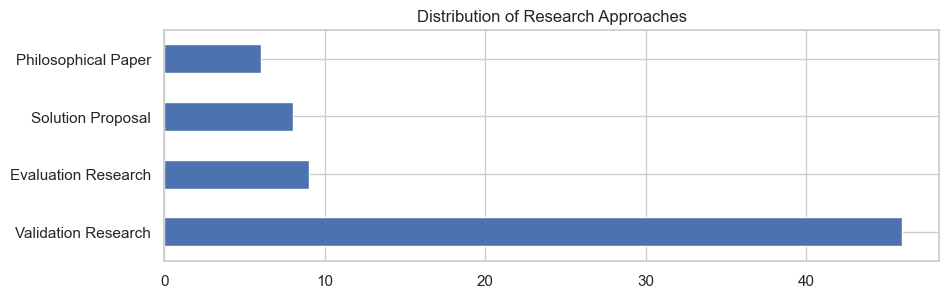

In [360]:
plot = structurized_list['Research_Approach'].value_counts().plot(kind='barh', figsize=(10, 3), title='Distribution of Research Approaches')
plot.set_ylabel('')

### Merge similar keywords
In order to reduce the amount of research keywords, we are going to merge semantically identical keywords:

In [361]:
categories = set()
for index, row in enumerate(structurized_list["Research_Keywords"].to_list()):
    for category in row.split(";"):
        categories.add(category.strip())
    
for cat in sorted(categories):
    print(cat)

Adaptive Data Strutures
Agile Software Development
Algorithm Design
Algorithmic Skeletons
Android
Android Applications
Android Development Models
Anti-Patterns
Application-Level Software Engineering
Architectural Design Methods
Architectural Flexibility
Architectural Frameworks
Architectural Metrics
Architectural Styles
Architecture
Architecture-Based Analysis
Architectures
Aspect Oriented Programming
Aspect-Oriented Development
Aspect-Oriented Frameworks
Attribute-Driven Design
Automated Tooling
Availability
Battery Life
C++
Case Study
Cloud
Cloud Architecture
Cloud Computing
Cloud Patterns
Cloud Software Architecture
Cloud-Based Systems
Code Quality
Code Smells
Communication
Communication Protocols
Compiler
Compiler Optimization
Compiler Transformations
Computation Offloading
Data Structures
Decorator Pattern
Delegation
Design Pattern
Design Pattern Comparison
Design Patterns
Design-Time Analysis
Design-Time Energy Analysis
Design-Time Evaluation
Design-Time Sustainability
Developer 

The keywords to merge or unify are shown in the following:

In [362]:
research_keywords_transformations = {
    "Adaptive Data Strutures": "Data Structures",
    "Agile Software Development": "Software Development Process",
    "Algorithm Design": "Programming",
    "Algorithmic Skeletons": "Programming",
    "Android": "Mobile Applications",
    "Android Applications": "Mobile Applications",
    "Android Development Models": "Mobile Applications",
    "Anti-Patterns": "Code Quality",
    "Application-Level Software Engineering": "Software Engineering",
    "Architectural Design Methods": "Architecture",
    "Architectural Flexibility": "Architecture",
    "Architectural Frameworks": "Frameworks and Tools",
    "Architectural Metrics": "Metrics and Measurement",
    "Architectural Styles": "Architecture",
    "Architecture": "Architecture",
    "Architecture-Based Analysis": "Software Analysis",
    "Architectures": "Architecture",
    "Aspect Oriented Programming": "Programming",
    "Aspect-Oriented Development": "Programming",
    "Aspect-Oriented Frameworks": "Frameworks and Tools",
    "Attribute-Driven Design": "Architecture",
    "Automated Tooling": "Frameworks and Tools",
    "Availability": "Software Quality",
    "Battery Life": "Energy Efficiency",
    "C++": "Programming Languages",
    "Case Study": "Empirical Research",
    "Cloud": "Cloud Computing",
    "Cloud Architecture": "Architecture; Cloud Computing",
    "Cloud Computing": "Cloud Computing",
    "Cloud Patterns": "Design Patterns; Cloud Computing",
    "Cloud Software Architecture": "Architecture;Cloud Computing",
    "Cloud-Based Systems": "Cloud Computing",
    "Code Smells": "Code Quality",
    "Communication": "Communication Technologies",
    "Communication Protocols": "Communication Technologies",
    "Compiler": "Compilers",
    "Compiler Optimization": "Compilers",
    "Compiler Transformations": "Compilers",
    "Computation Offloading": "Resource Optimization",
    "Concurrency control": "Concurrency",
    "Data Structures": "Data Structures",
    "Decorator Pattern": "Design Patterns",
    "Delegation": "Design Patterns",
    "Design Pattern": "Design Patterns",
    "Design Pattern Comparison": "Design Patterns",
    "Design Patterns": "Design Patterns",
    "Design-Time Analysis": "Software Analysis",
    "Design-Time Energy Analysis": "Energy Efficiency",
    "Design-Time Evaluation": "Software Analysis",
    "Design-Time Sustainability": "Sustainability",
    "Developer Awareness": "Software Engineering",
    "Developer Practices": "Software Engineering",
    "Direct and Indirect Effects": "Sustainability",
    "Distributed Programming Abstractions": "Distributed Systems",
    "Distributed Software Systems": "Distributed Systems",
    "Distributed Systems": "Distributed Systems",
    "Dynamic Power Management": "Energy Efficiency",
    "Dynamic Software Product Lines": "Software Engineering",
    "Dynamic Voltage and Frequency Scaling": "Energy Efficiency",
    "Embedded Software Design": "Embedded Systems",
    "Embedded Software-Engineering": "Embedded Systems",
    "Embedded Systems": "Embedded Systems",
    "Empirical Experimentation": "Empirical Research",
    "Energy Attribution": "Energy Efficiency",
    "Energy Awareness": "Energy Efficiency",
    "Energy Consumption": "Energy Efficiency",
    "Energy Consumption Estimation": "Energy Efficiency",
    "Energy Consumption Evolution": "Energy Efficiency",
    "Energy Consumption Mitigation": "Energy Efficiency",
    "Energy Consumption Modelling": "Energy Efficiency",
    "Energy Efficciency in Operating Systems": "Energy Efficiency",
    "Energy Efficiency": "Energy Efficiency",
    "Energy Efficiency Practices": "Energy Efficiency",
    "Energy Efficiency Tactics": "Energy Efficiency",
    "Energy Hotspots": "Energy Efficiency",
    "Energy Isolation": "Energy Efficiency",
    "Energy Measurement": "Metrics and Measurement",
    "Energy Modelling": "Energy Efficiency",
    "Energy Optimization": "Energy Efficiency",
    "Energy Profiling": "Metrics and Measurement",
    "Energy Traces": "Metrics and Measurement",
    "Energy-Aware Commits": "Energy Efficiency",
    "Energy-Aware Data Structures": "Energy Efficiency;Data Structures",
    "Energy-Aware Design Patterns": "Energy Efficiency;Design Patterns",
    "Energy-Aware Framework": "Energy Efficiency;Frameworks and Tools",
    "Energy-Aware Programming": "Energy Efficiency;Programming",
    "Energy-Aware Refactoring": "Energy Efficiency;Refactoring",
    "Energy-Aware Software Design": "Energy Efficiency;Software Engineering",
    "Energy-Aware Software Engineering": "Energy Efficiency;Software Engineering",
    "Energy-Centry Architecture": "Energy Efficiency;Architecture",
    "Energy-Driven Architecture": "Energy Efficiency;Architecture",
    "Energy-Efficiency": "Energy Efficiency",
    "Energy-Efficient Distributed Systems": "Energy Efficiency",
    "Energy-Efficient Software": "Energy Efficiency",
    "Energy-Efficient Software Design": "Energy Efficiency; Software Engineering",
    "Energy-Efficient Software Engineering": "Energy Efficiency; Software Engineering",
    "Energy-Efficieny": "Energy Efficiency",
    "Erlang": "Programming Languages",
    "Estimation": "Metrics and Measurement",
    "Event-Based": "Programming",
    "Execution Time": "Metrics and Measurement",
    "Flexibility": "Software Quality",
    "Framework": "Frameworks and Tools",
    "GRPC": "Communication Technologies",
    "Graph Transformations": "Modeling and Meta-Modeling",
    "Green Computing": "Green Computing",
    "Green IT": "Green Computing",
    "Green Software Development": "Energy Efficiency;Software Engineering",
    "Green Software Engineering": "Energy Efficiency;Software Engineering",
    "Green Software Model": "Energy Efficiency;Modeling and Meta-Modeling",
    "Green Software Patterns": "Energy Efficiency;Programming",
    "Hybrid Implementations": "Software Engineering",
    "Idiom": "Programming",
    "Idle Software": "Energy Efficiency",
    "Inheritance": "Programming",
    "Internet-of-Things": "Internet of Things",
    "IoT Design Patterns": "Internet of Things",
    "Java": "Programming Languages",
    "Java Applications": "Programming Languages",
    "JavaScript": "Programming Languages",
    "Knowledge Base": "Knowledge Management",
    "Kotlin": "Programming Languages",
    "LLM": "AI",
    "Large Scale Software Engineering": "Software Engineering",
    "Low-Energy Software": "Energy Efficiency",
    "Machine Learning": "AI",
    "Maintainability": "Maintenance",
    "Maintenance and Sustainability": "Maintenance",
    "Measurement": "Metrics and Measurement",
    "Meta-Modelling": "Modeling and Meta-Modeling",
    "Methodologies": "Methodologies",
    "Metrics": "Metrics and Measurement",
    "Microservice": "Architecture",
    "Microservices": "Architecture",
    "Microsoft IIS": "System Software",
    "Mining Software Repositories": "Software Analysis",
    "Mobile Applications": "Mobile Applications",
    "Mobile Health (M-Health)": "Mobile Applications",
    "Mobile Software Engineering": "Mobile Applications",
    "Mobile-Apps": "Mobile Applications",
    "Modularity": "Architecture",
    "Monitoring": "Metrics and Measurement",
    "Monolithic Architecture": "Architecture",
    "Object-Oriented Design": "Programming",
    "Object-Oriented Programming": "Programming",
    "Observer Pattern": "Design Patterns",
    "Parallel Design Patterns": "Design Patterns",
    "Performance": "Performance",
    "Performance Analysis": "Performance",
    "Performance Trade-offs": "Performance",
    "Power Consumption": "Energy Efficiency",
    "Power Management": "Energy Efficiency",
    "Power Measurement": "Metrics and Measurement",
    "Power Modelling": "Energy Efficiency",
    "Power-Aware Architecture": "Energy Efficiency",
    "Prediction": "AI",
    "Problem Domain": "Software Engineering",
    "Profiling": "Metrics and Measurement",
    "Programming Language Evaluation": "Programming Languages",
    "Programming Languages": "Programming Languages",
    "Programming Paradigms": "Programming",
    "Programming Techniques": "Programming",
    "Progressive-Web-Apps": "Web Applications",
    "REST": "Communication Technologies",
    "RESTful Applications": "Web Applications",
    "RPC": "Communication Technologies",
    "Refactoring": "Refactoring",
    "Register Allocation": "Compilers",
    "Regression Model": "AI",
    "Resource Optimization": "Resource Optimization",
    "Resource Utilization": "Resource Optimization",
    "SOAP": "Communication Technologies",
    "Secure Systems": "Security",
    "Security Protocols": "Security",
    "Self-Adaptive Applications": "Self-Adaptive Systems",
    "Self-Adaptive Software Systems": "Self-Adaptive Systems",
    "Serialization Formats": "Communication Technologies",
    "Socket": "Communication Technologies",
    "Sockets": "Communication Technologies",
    "Software Analysis": "Software Analysis",
    "Software Architectural Transformations": "Architecture",
    "Software Architecture": "Architecture",
    "Software Architectures": "Architecture",
    "Software Design": "Software Engineering",
    "Software Design Framework": "Software Engineering;Frameworks and Tools",
    "Software Development": "Software Engineering",
    "Software Development Life Cycle": "Software Development Process",
    "Software Development Paradigms": "Software Development Process",
    "Software Development Process": "Software Development Process",
    "Software Efficiency": "Performance",
    "Software Energy Efficiency": "Energy Efficiency",
    "Software Energy Hotspots": "Energy Efficiency",
    "Software Engineering": "Software Engineering",
    "Software Evolution": "Software Evolution",
    "Software Functionality Modelling": "Modeling and Meta-Modeling",
    "Software Implementation Strategies": "Software Engineering",
    "Software Lifecycle": "Software Development Process",
    "Software Maintainability": "Maintenance",
    "Software Maintenance": "Maintenance",
    "Software Metrics": "Metrics and Measurement",
    "Software Optimization": "Performance;Software Engineering",
    "Software Performance Analysis": "Performance",
    "Software Power Optimization": "Energy Efficiency",
    "Software Quality": "Software Quality",
    "Software Quality Metrics": "Software Quality",
    "Software Stubs": "Software Engineering",
    "Software Sustainability": "Sustainability",
    "Software transactional memories": "Concurrency",
    "Software-Architecture": "Architecture",
    "Software-Architecture Configuration": "Architecture",
    "Software-Design": "Software Engineering",
    "Spring Framework": "Frameworks and Tools",
    "Statistical Sampling": "Metrics and Measurement",
    "Structured Parallel Programming": "Programming",
    "Support Vector Machine": "AI",
    "Sustainability": "Sustainability",
    "Sustainability Weaknesses": "Sustainability",
    "Sustainability-Aware Architecture": "Sustainability;Architecture",
    "Sustainable Software Design": "Sustainability;Software Engineering",
    "Sustainable Software Engineering": "Sustainability;Software Engineering",
    "Task Scheduling": "Concurrency",
    "Time-triggered Architetures": "Architecture",
    "Trade-offs": "Performance",
    "Visitor Pattern": "Design Patterns",
    "Web Applications": "Web Applications",
    "WebSocket": "Communication Technologies",
    "Wireless Sensor Networks": "Internet of Things",
    "Wirless Sensor Network Architeture": "Internet of Things",
}

column = "Research_Keywords"
for index, row in structurized_list.iterrows():
    new_categories = []
    for category in row[column].split(";"):
        if category == "Android Applications":
            print(f"CHECK '{category}' to '{research_keywords_transformations[category]}'")
        if category.strip() in research_keywords_transformations:
            new_categories.append(research_keywords_transformations[category.strip()])
        else:
            new_categories.append(category.strip())
    structurized_list.at[index, column + '_new'] = ";".join(new_categories) # type: ignore
    
structurized_list['Research_Keywords'] = structurized_list[column + '_new']

/var/folders/pg/xktlq8917zj4gsm41nm520z00000gn/T/ipykernel_45720/144307787.py:242: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  structurized_list.at[index, column + '_new'] = ";".join(new_categories) # type: ignore
/var/folders/pg/xktlq8917zj4gsm41nm520z00000gn/T/ipykernel_45720/144307787.py:244: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  structurized_list['Research_Keywords'] = structurized_list[column + '_new']


### Research Keywords

AI: 6
Architecture: 22
Cloud Computing: 5
Code Quality: 5
Communication Technologies: 4
Compilers: 2
Concurrency: 1
Data Structures: 1
Design Patterns: 14
Distributed Systems: 6
Embedded Systems: 8
Empirical Research: 3
Energy Efficiency: 67
Frameworks and Tools: 8
Green Computing: 2
Internet of Things: 4
Knowledge Management: 1
Maintenance: 3
Methodologies: 1
Metrics and Measurement: 13
Mobile Applications: 9
Modeling and Meta-Modeling: 2
Performance: 7
Programming: 11
Programming Languages: 6
Refactoring: 6
Resource Optimization: 4
Security: 1
Self-Adaptive Systems: 1
Software Analysis: 7
Software Development Process: 5
Software Engineering: 34
Software Evolution: 1
Software Quality: 4
Sustainability: 9
System Software: 2
Web Applications: 3


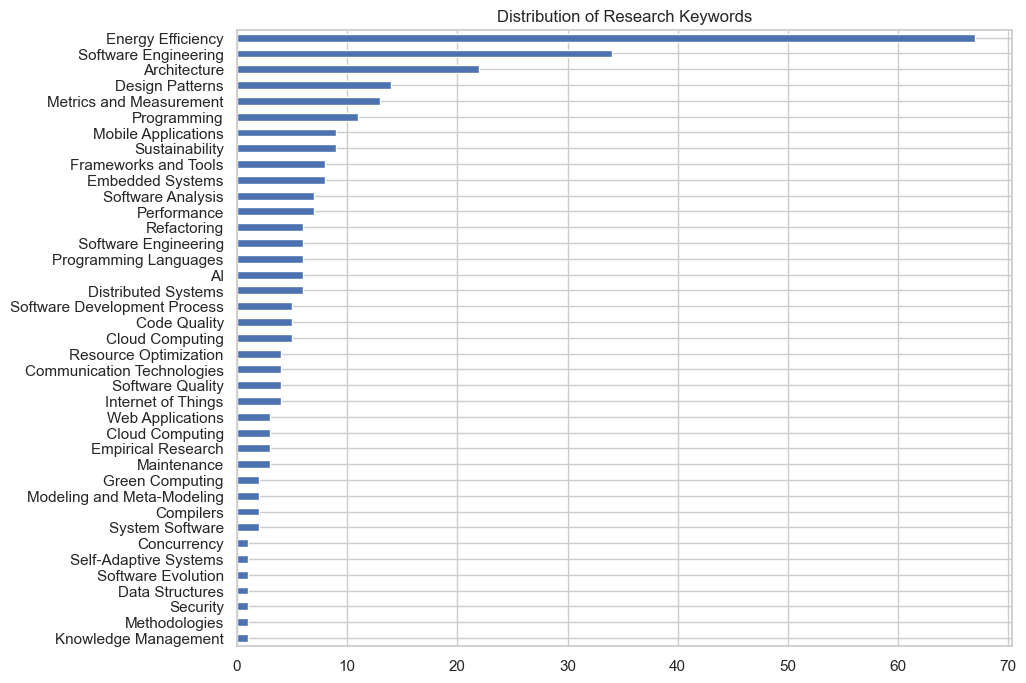

In [363]:
categories = set()
cat_count = {}
for index, row in enumerate(structurized_list["Research_Keywords"].to_list()):
    for category in set(row.split(";")):
        categories.add(category.strip())
        cat_count[category] = cat_count.get(category, 0) + 1
    
for cat in sorted(categories):
    print(f"{cat}: {cat_count[cat]}")

pd.Series(cat_count).sort_values().plot(kind='barh', figsize=(10, 8), title='Distribution of Research Keywords')
display()

### Domains

Code Smells
Communication Technologies
Design Patterns
Embedded Software Engineering
Framework
Mobile Software Engineering
Operating Systems
Parallel Programming
Software Architecture
Software Engineering
Software Maintenance
Software Modelling


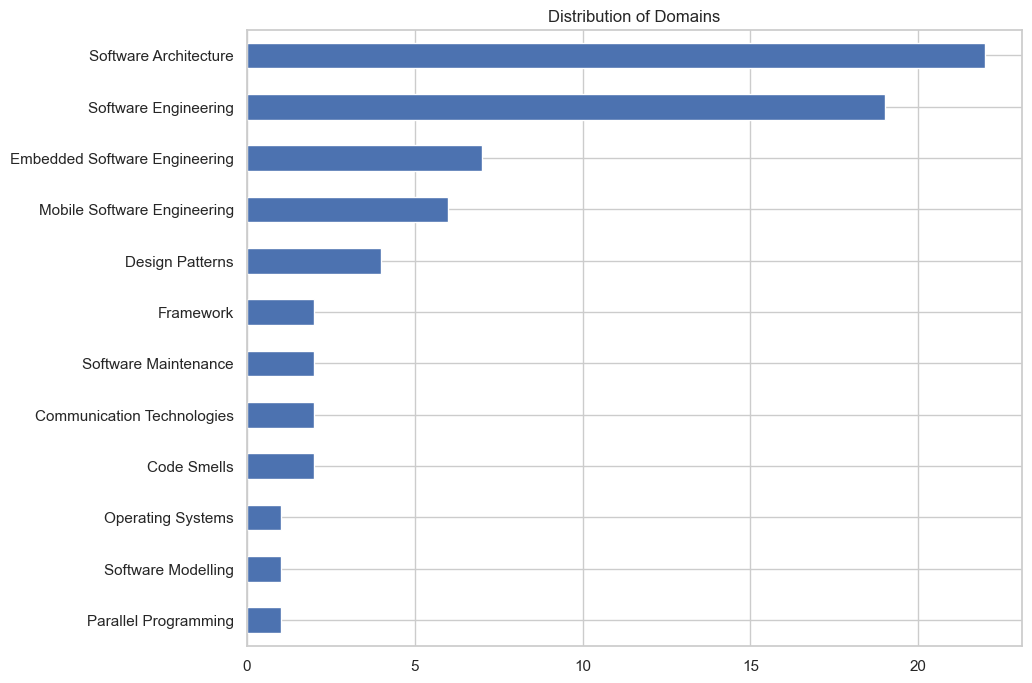

In [364]:
categories = set()
dom_count = {}
for row in structurized_list["Domain"].to_list():
    for category in set(row.split(";")):
        categories.add(category.strip())
        dom_count[category] = dom_count.get(category, 0) + 1
    
for cat in sorted(categories):
    print(cat)

pd.Series(dom_count).sort_values().plot(kind='barh', figsize=(10, 8), title='Distribution of Domains')
display()

In [365]:
def build_pivot_table(dataset, column, count_by="Year", min_count=1):
    categories = set()
    for row in dataset[column].to_list():
        for category in row.split(";"):
            categories.add(category.strip())
    
    # display(sorted(categories))
    
    category_series = pd.Series(list(categories))
    df = pd.DataFrame({column: [], count_by: []})
    
    for category in categories:
        count = len(dataset[dataset[column].str.contains(category, regex=False)])
        count_by_rows = dataset[dataset[column].str.contains(category, regex=False)]
    
        for count_by_value in count_by_rows[count_by]:
            df.loc[len(df)] = [category, count_by_value]
    
    pivot = df.pivot_table(index=column, columns=count_by, aggfunc='size', fill_value=0)
    pivot['total'] = pivot.sum(axis=1)
    filtered_pivot = pivot.loc[pivot['total'] >= min_count]
    
    return filtered_pivot
    

### Keywords by domain

In [366]:
min_count= 5
print("Research Keywords pivot table")
filtered_pivot = build_pivot_table(structurized_list, 'Research_Keywords', count_by="Domain", min_count=min_count)
display(filtered_pivot)

Research Keywords pivot table


Domain,Code Smells,Communication Technologies,Design Patterns,Embedded Software Engineering,Framework,Mobile Software Engineering,Operating Systems,Parallel Programming,Software Architecture,Software Engineering,Software Maintenance,Software Modelling,total
Research_Keywords,,,,,,,,,,,,,
AI,0,0,0,0,0,1,0,0,4,1,0,0,6
Architecture,1,0,1,1,0,1,0,0,17,1,0,0,22
Cloud Computing,0,0,0,0,0,0,0,0,5,0,0,0,5
Code Quality,2,0,0,0,0,0,0,0,2,0,1,0,5
Design Patterns,0,0,4,3,0,1,0,1,2,1,2,0,14
Distributed Systems,0,1,0,0,1,0,0,0,3,1,0,0,6
Embedded Systems,0,0,0,4,0,0,0,0,2,2,0,0,8
Energy Efficiency,2,2,4,7,2,6,1,1,20,19,2,1,67
Frameworks and Tools,0,0,0,2,2,0,0,0,2,2,0,0,8


In [367]:
def build_long_pivot(filtered_pivot, id_var):
    pivot_reset = filtered_pivot.reset_index()
    pivot_reset.head()
    # Melt the pivot table to long-form
    pivot_long = pivot_reset.melt(id_vars=[id_var, 'total'], var_name='Year', value_name='count')
    return pivot_long

In [368]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('default')

# Create the bubble chart using seaborn


def plot_pivot_table(df, x, y, title):
    sns.set(style="whitegrid")
    plt.figure(figsize=(15, 6))
    # Use sns.scatterplot for bubbles
    plot = sns.scatterplot(
        data=df,
        x=x,
        y=y,
        size='count',
        sizes=(0, 400), # Adjust bubble size range
        alpha=0.6,
    )
    for i, row in df.iterrows():
     if row['count'] > 2: # Highlight keywords with count > 2
        plt.annotate(
            f"{row['count']}",
            (row[x], row[y]),
            textcoords="offset points",
            xytext=(-0.5,-4),
            ha='center',
            fontsize=12,
            color='white'
        )
    # plot.legend_.remove()
    all_years = df['Year'].unique()
    # print(all_years)
    # Add labels and title
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)
    # Show the plot
    plt.show

,Research_Keywords,total,Year,count
0,AI,6,1997,0
1,Architecture,22,1997,0
2,Cloud Computing,5,1997,0
3,Code Quality,5,1997,0
4,Communication Technologies,4,1997,0
5,Design Patterns,14,1997,0
6,Distributed Systems,6,1997,0
7,Embedded Systems,8,1997,0
8,Empirical Research,3,1997,0
9,Energy Efficiency,67,1997,1


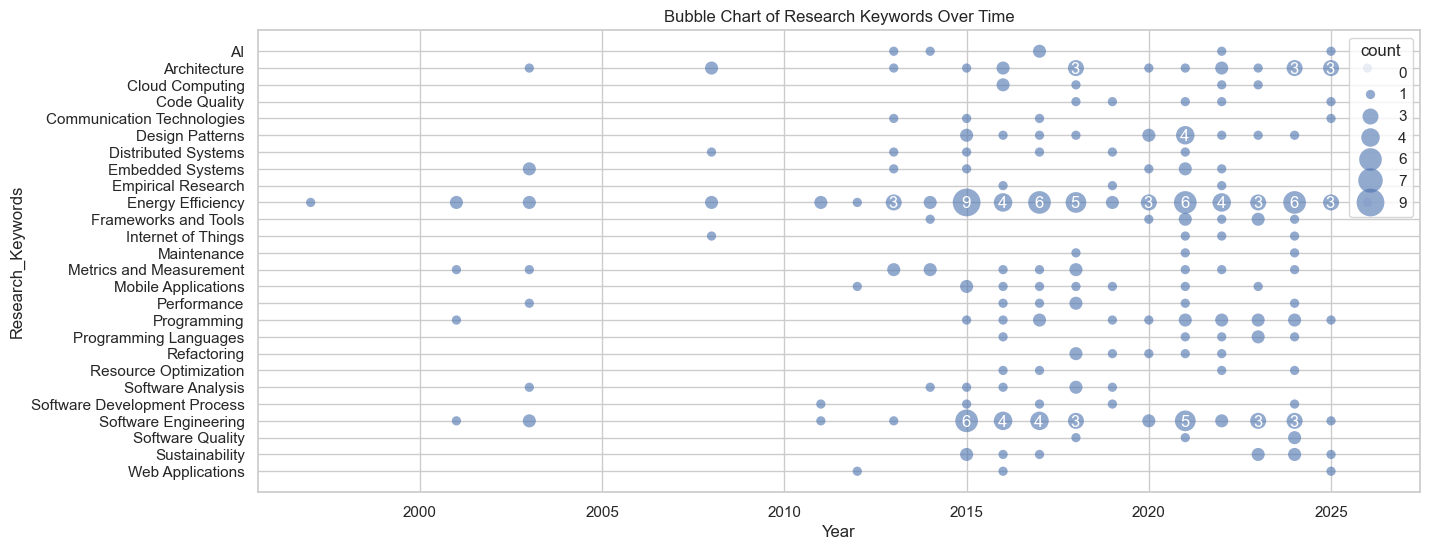

In [369]:
#display(structurized_list.head(2))
min_count = 3
filtered_pivot = build_pivot_table(structurized_list, 'Research_Keywords', count_by="Year", min_count=min_count)
long_pivot = build_long_pivot(filtered_pivot, 'Research_Keywords')
display(long_pivot.head(10))
plot_pivot_table(long_pivot, x="Year", y="Research_Keywords", title="Bubble Chart of Research Keywords Over Time")

Text(0, 0.5, '')

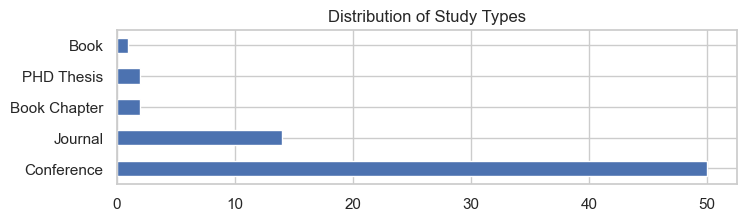

In [370]:
type_bar_chart = structurized_list['Type'].map(
    {
        'Article': 'Journal',
        'Book': 'Book',
        'Book chapter': 'Book Chapter',
        'Conference paper': 'Conference',
        'IEEE Conferences': 'Conference',
        'article': 'Journal',
        'inproceedings': 'Conference',
        'phdthesis': 'PHD Thesis'
    }
).value_counts().plot(kind='barh', title='Distribution of Study Types', figsize=(8, 2))
type_bar_chart.set_ylabel('')

In [371]:
min_count = 1
filtered_domain_pivot = build_pivot_table(structurized_list, 'Domain', count_by="Year", min_count=min_count)
display(filtered_domain_pivot)

Year,1997,2001,2003,2008,2011,2012,2013,2014,2015,2016,...,2018,2019,2020,2021,2022,2023,2024,2025,2026,total
Domain,,,,,,,,,,,,,,,,,,,,,
Code Smells,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,2
Communication Technologies,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,2
Design Patterns,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,1,1,0,0,0,4
Embedded Software Engineering,0,1,0,1,0,0,0,0,1,0,...,1,0,1,2,0,0,0,0,0,7
Framework,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,2
Mobile Software Engineering,0,0,0,0,0,1,0,1,0,1,...,1,0,0,1,0,1,0,0,0,6
Operating Systems,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
Parallel Programming,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
Software Architecture,0,0,1,1,0,0,1,0,2,2,...,2,1,1,0,2,1,3,3,1,22


Year,1997,2001,2003,2008,2011,2012,2013,2014,2015,2016,...,2018,2019,2020,2021,2022,2023,2024,2025,2026,total
Domain,,,,,,,,,,,,,,,,,,,,,
Code Smells,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,2
Communication Technologies,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,2
Design Patterns,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,1,1,0,0,0,4
Embedded Software Engineering,0,1,0,1,0,0,0,0,1,0,...,1,0,1,2,0,0,0,0,0,7
Framework,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,2
Mobile Software Engineering,0,0,0,0,0,1,0,1,0,1,...,1,0,0,1,0,1,0,0,0,6
Operating Systems,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
Parallel Programming,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
Software Architecture,0,0,1,1,0,0,1,0,2,2,...,2,1,1,0,2,1,3,3,1,22


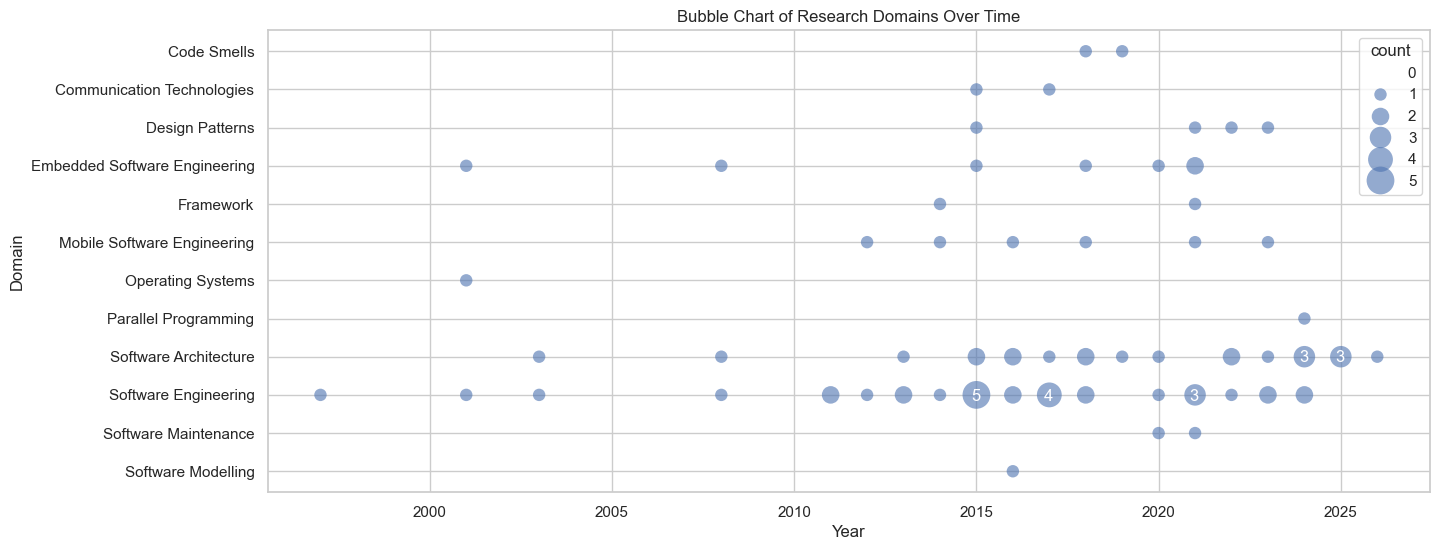

In [372]:
min_count = 1
filtered_domain_pivot = build_pivot_table(structurized_list, 'Domain', count_by="Year", min_count=min_count)
display(filtered_domain_pivot)
plot_pivot_table(build_long_pivot(filtered_domain_pivot, "Domain"), y="Domain", x="Year", title="Bubble Chart of Research Domains Over Time")

In [373]:
list(sorted(set(structurized_list['Contribution'])))

['Conceptual Framework',
 'Empirical evidence',
 'Framework',
 'Method',
 'Model',
 'Proposal',
 'Software Architecture']

## Backward Snowballing
To increase the completeness of the study and mitigate potential limitations of the database search strategy, we conducted a backward snowballing procedure on all initially included primary studies. For each paper, the reference lists were systematically screened and assessed against the defined inclusion and exclusion criteria to identify additional relevant studies. Newly identified papers meeting the criteria were incorporated into the final dataset before proceeding with the synthesis phase. The results are shown in the following table:
(For further information on the applied inclusion/exclusion criteria check the file [selected_topics.xlsx](../iterations/selected_topics.xlsx))

In [374]:
snowballing_list = pd.read_csv("../output/03-Mapping/snowballing_results.csv", converters={'Local File': str}, header=0)
snowballing_list = snowballing_list.sort_values(by=['Title'], ascending=True).reset_index(drop=True)
snowballing_list = snowballing_list.rename(columns={'Publication year': 'Year'})
display(snowballing_list)

,Title,DOI,Abstract,URLs,Authors,Item type,Journal,Full journal,Year,Volume,...,Date accessed,ISBN,ISBN (alt.),ISSN,ISSN (alt.),Keywords,Copyright,Affiliation,Language,Series
0,A blessing in disguise? Assessing the Relation...,10.1109/icsme46990.2020.00088,Code smells have always been associated with b...,http://dx.doi.org/10.1109/icsme46990.2020.00088,Catolino G,Conference Paper,NaN,NaN,2020.0,NaN,...,NaN,9.781730e+12,NaN,NaN,NaN,NaN,https://ieeexplore.ieee.org/Xplorehelp/downloa...,NaN,NaN,NaN
1,A green computing based architecture compariso...,10.1109/greencom-cpscom.2010.110,With rising energy cost and growing environmen...,http://dx.doi.org/10.1109/greencom-cpscom.2010...,"Zhong B,Feng M,Lung CH",Conference Paper,NaN,NaN,2010.0,NaN,...,NaN,9.781420e+12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A preliminary study of the impact of software ...,10.1109/greens.2012.6224251,GreenIT has emerged as a discipline concerned ...,http://dx.doi.org/10.1109/greens.2012.6224251,"Noureddine A,Bourdon A,Rouvoy R,Seinturier L",Conference Paper,NaN,NaN,2012.0,NaN,...,NaN,9.781470e+12,9.781470e+12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A process for analysing the energy efficiency ...,10.1016/j.infsof.2021.106560,Context: It is essential to be aware of the en...,http://dx.doi.org/10.1016/j.infsof.2021.106560,"Mancebo J,Garcia F,Calero C",Journal Article,Inf. Softw. Technol.,Information and Software Technology,2021.0,134.0,...,NaN,NaN,NaN,0950-5849,1873-6025,NaN,NaN,NaN,en,NaN
4,A study of energy-aware implementation techniq...,10.1016/j.suscom.2014.11.005,As devices like smartphones and tablets have b...,http://dx.doi.org/10.1016/j.suscom.2014.11.005,"Corral L,Georgiev AB,Sillitti A,Succi G",Journal Article,Sustain. Comput. Inform. Syst.,Sustainable Computing Informatics and Systems,2015.0,7.0,...,NaN,NaN,NaN,2210-5379,2210-5387,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,Towards power reduction through improved softw...,10.1109/energytech.2012.6304705,NaN,http://dx.doi.org/10.1109/energytech.2012.6304705,"Sahin C,Cayci F,Clause J,Kiamilev F,Pollock L,...",Conference Paper,NaN,NaN,2012.0,NaN,...,NaN,9.781470e+12,9.781470e+12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
88,Transforming set data types to power optimal d...,10.1109/43.503932,"In this paper, we present a novel approach to ...",http://dx.doi.org/10.1109/43.503932,"Wuytack S,Catthoor FV,De Man HJ",Journal Article,IEEE Trans. Comput.-aided Des. Integr. Circuit...,IEEE Transactions on Computer-Aided Design of ...,1996.0,15.0,...,NaN,NaN,NaN,0278-0070,1937-4151,NaN,https://ieeexplore.ieee.org/Xplorehelp/downloa...,NaN,NaN,NaN
89,Understanding the performance-energy tradeoffs...,10.1109/saner60148.2024.00069,Object-Relational Mapping (ORM) frameworks are...,http://dx.doi.org/10.1109/saner60148.2024.00069,"Bonvoisin A,Quinton C,Rouvoy R",Conference Paper,NaN,NaN,2024.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Univ. Lille, CNRS, Inria, UMR 9189 CRIStAL,Lil...",NaN,NaN
90,Unit testing of energy consumption of software...,10.1145/2554850.2554932,The development of energy-efficient software h...,http://dx.doi.org/10.1145/2554850.2554932,"Noureddine A,Rouvoy R,Seinturier L",Conference Paper,NaN,NaN,2014.0,NaN,...,NaN,9.781450e+12,NaN,NaN,NaN,NaN,NaN,Inria Lille -- Nord Europe and University Lill...,NaN,NaN


### Snowballing Classification
We are going to do the same classification we did for the initial dataset for the snowballed sources. We to stick to the previously used and minimized keywords and domains.

0. A blessing in disguise? Assessing the Relationship between Code Smells and Sustainability

Code smells have always been associated with bad code source quality and maintenance problems by the research community. However, a few code smells remain within code for years without influence a project, and some of the developers do not even recognize them. This late-breaking idea paper wants to investigate the role of code smells within the context of software quality and the sustainability of projects. For this reason, we first plan to understand the impact of code smells on sustainability and then perform a fine-grain analysis to analyze their evolution, focusing on the possible benefits of their presence.

|            Aspect | Value                                                                                                                                                           |
| ----------------: | :-------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Code Smells                                                                                                                                                     |
| Research Keywords | Code Quality; Sustainability; Software Quality; Software Evolution                                                                                              |
| Research Approach | Philosophical Papers                                                                                                                                            |
|     Study Context | The paper discusses planned research to investigate the impact and evolution of code smells in relation to software sustainability. |
|      Contribution | None                                                                                                                                                            |

**We are adding a new contribution "None" since this paper only declares an intention for future research**


In [375]:
row_number = -1
row_number = row_number + 1
set_aspects(
    row_number,
    "Code Smells",
    "Code Quality; Sustainability; Software Quality; Software Evolution",
    "Philosophical Paper",
    "The paper discusses planned research to investigate the impact and evolution of code smells in relation to software sustainability.",
    "None",
    list=snowballing_list
)



'0: A blessing in disguise? Assessing the Relationship between Code Smells and Sustainability'

1. A green computing based architecture comparison and analysis

With rising energy cost and growing environmental concerns, green computing is receiving more and more attention. Software and system architectures ( in terms of concurrency patterns) play a crucial role in both computing and telecommunication systems, and they have been analyzed for performance, reliability, maintainability, and security. Yet, little work on analysis based on the amount of energy that the CPU/processor will consume has been reported. Since most communication systems have to run 24/7 (e.g., most server farms, servers in a cloud computing infrastructure), the energy consumption of a system based on a specific software architecture is of great importance. For example, high energy consuming always leads to higher operational cost of the system. High energy consumption also implies more heat produced, thus, more power is required for cooling-down. In this paper, we propose a model that can be used to analyze the energy consumption of a software architecture, given the CPU/processor that will be used. Thus, this model gives one an additional dimension to compare competing software architectures. We present a case study using a generic sender/receiver communication system to evaluate two architectural alternatives with emphasis on energy consumption

|            Aspect | Value                                                                                                                                                               |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
|   Research Domain | Software Architecture                                                                                                                                               |
| Research Keywords | Architecture, Energy Efficiency, Green Computing, Performance, Modeling and Meta-Modeling                                                                           |
| Research Approach | Validation Research                                                                                                                                                 |
|     Study Context | The study proposes and validates a model to analyze and compare the energy consumption of two software architectures using a communication system case study. |
|      Contribution | Model                                                                                                                                                               |


In [376]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Architecture; Energy Efficiency; Green Computing; Performance; Modeling and Meta-Modeling",
    "Validation Research",
    "The study proposes and validates a model to analyze and compare the energy consumption of two software architectures using a communication system case study.",
    "Model",
    list=snowballing_list
)

'1: A green computing based architecture comparison and analysis'

2. A preliminary study of the impact of software engineering on GreenIT

GreenIT has emerged as a discipline concerned with the optimization of software solutions with regards to their energy consumption. In this domain, most of state-of-the-art solutions offer limited or constraining approaches to monitor the energy consumption of a device or a process. In this paper, we therefore report on a runtime energy monitoring framework we developed to easily report on the energy consumption of system processes. Concretely, our approach adopts an OS-level library, called PowerAPI, which estimates the power consumption of processes according to different dimensions (CPU, network, etc.). In order to better understand potential energy leaks of legacy software, we use this library to study the impact of programming languages and algorithmic choices on the energy consumption. This preliminary study is based on an empirical evaluation of a eight implementations of the Towers of Hanoi problem.

|            Aspect | Value                                                                                                                                                                                             |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
|   Research Domain | Software Engineering                                                                                                                                                                              |
| Research Keywords | Energy Efficiency; Green Computing; Metrics and Measurement; Programming Languages; Empirical Research                                                                                            |
| Research Approach | Validation Research                                                                                                                                                                               |
|     Study Context | The study introduces a runtime energy monitoring framework and empirically evaluates how programming languages and algorithmic choices affect energy consumption using benchmark implementations. |
|      Contribution | Framework                                                                                                                                                                                         |
 

In [377]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Green Computing; Metrics and Measurement; Programming Languages; Empirical Research",
    "Validation Research",
    "The study introduces a runtime energy monitoring framework and empirically evaluates how programming languages and algorithmic choices affect energy consumption using benchmark implementations.",
    "Framework",
    list=snowballing_list
)

'2: A preliminary study of the impact of software engineering on GreenIT'

3. A process for analysing the energy efficiency of software 

Context: It is essential to be aware of the energy efficiency of software when it is running, so that it can be improved; to that end, energy consumption measurements need to be carried out. To ensure that these mea- surements are as reliable as possible, it is recommended that a well-defined process be followed. 

Objective: To identify how the process for analysing the energy efficiency of software should be carried out (including the definition of the software to be evaluated, the selection of measuring instruments, the analysis and the presentation of results, etc.), in an endeavour to improve the reliability and consistency of the information obtained regarding energy efficiency. 

Method: An analysis of related work was carried out, to extract some good practices in measuring energy con- sumption; based on our experience, a process to analyse the energy efficiency of the software has been defined. 

Results: We have defined a process to analyse the energy efficiency of the software. We describe this process through a set of phases that covers all the steps needed to carry out a correct analysis of the energy consumption of the software executed. Moreover, this process was validated with two different studies using different mea- surement instruments (one with a hardware-based approach and one with a software-based approach) to ensure its applicability to all types of studies with software energy consumption measurement. 

Conclusion: The steps to be followed to analyse the energy efficiency of the software need to be established. A new process has hence been defined to improve the reliability and consistency of the measurements. Furthermore, this process facilitates the replicability and comparison of the studies carried out.

|            Aspect | Value                                                                                                                                                      |
| ----------------: | :--------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Engineering                                                                                                                                       |
| Research Keywords | Energy Efficiency; Metrics and Measurement; Methodologies; Empirical Research; Software Analysis                                                           |
| Research Approach | Validation Research                                                                                                                                        |
|     Study Context | The study defines and validates a structured process for reliably measuring and analyzing software energy consumption across different measurement setups. |
|      Contribution | Method                                                                                                                                                     |


In [378]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Metrics and Measurement; Methodologies; Empirical Research; Software Analysis",
    "Validation Research",
    "The study defines and validates a structured process for reliably measuring and analyzing software energy consumption across different measurement setups.",
    "Method",
    list=snowballing_list
)

'3: A process for analysing the energy efficiency of software'

4. A study of energy-aware implementation techniques: Redistribution of computational jobs in mobile apps

As devices like smartphones and tablets have been adopted by millions of users, the offer of mobile software products and services has as well evolved significantly. Current mobile software products require hardware resources, computer job and network connectivity that is reflected in increasing power needs. This power demand represents a major challenge to the strong autonomy requirement of mobile devices, powered by batteries. As a consequence, one of the most important qualities of mobile software development is the ability to produce applications that consume energy resources wisely. To accomplish this goal, different approaches have been proposed, including energy-aware software design and implementation techniques. The energy aware software design techniques considered in this work are two: Method Reallocation, which refers to the placement of pieces of code in different execution scopes within a single target (e.g., kernel space, application space, shared library space), and Method Offloading, which refers to the placement of pieces of code in external resources in different scopes (for instance a remote server). Both techniques aim to economize resources like processing power, and memory usage, but always upon the expenses carried by interfacing, communication and network overhead. Our goal is to investigate how each one can contribute to reduce the overall energy consumption of a mobile software application. As an experiment, we utilized a mobile application that runs software benchmarks coded in Java and C. We exercised the benchmarks in different execution scopes within the handheld target and a remote server counterpart, measuring the amount of energy required to complete each job. After determining the energy consumed by each routine for each execution scope, we identified in what cases it is convenient to reallocate the processing job, and when it is advisable to offload it to an external execution environment.

|            Aspect | Value                                                                                                                                                                                                 |
| ----------------: | :---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Mobile Software Engineering                                                                                                                                                                           |
| Research Keywords | Energy Efficiency; Mobile Applications; Performance; Resource Optimization; Distributed Systems; Empirical Research                                                                                   |
| Research Approach | Validation Research                                                                                                                                                                                   |
|     Study Context | The study empirically evaluates method reallocation and offloading techniques to understand their impact on energy consumption in mobile applications across local and remote execution environments. |
|      Contribution | Empirical evidence                                                                                                                                                                                    |


In [379]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Mobile Software Engineering",
    "Energy Efficiency; Mobile Applications; Performance; Resource Optimization; Distributed Systems; Empirical Research",
    "Validation Research",
    "The study empirically evaluates method reallocation and offloading techniques to understand their impact on energy consumption in mobile applications across local and remote execution environments.",
    "Empirical evidence",
    list=snowballing_list
)

'4: A study of energy-aware implementation techniques: Redistribution of computational jobs in mobile apps'

5. An empirical analysis of energy consumption of cross-platform frameworks for mobile development

The increasing fragmentation of mobile devices market has created the problem of supporting all the possible mobile platforms to reach the highest number of potential users. One possible solution is to use cross-platform frameworks, that let develop only one application that is then deployed to all the supported target platforms. Currently available cross-platform frameworks follow different approaches to deploy the final application, and all of them has pros and cons. In this paper, we evaluate and compare together the current frameworks for cross-platform mobile development considering one of the most important aspect when dealing with mobile devices: energy consumption. Our analysis shows and measure how the adoption of cross-platform frameworks impacts energy consumption with respect to the native mobile development, identifies which are the most consuming tasks, and tries to define a final rank among all the different approaches. Moreover, we highlight future development necessary to improve performances of cross-platform frameworks to reach native development performances.

|            Aspect | Value                                                                                                                                                                |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Mobile Software Engineering                                                                                                                                          |
| Research Keywords | Energy Efficiency; Mobile Applications; Frameworks and Tools; Performance; Empirical Research                                                                        |
| Research Approach | Evaluation Research                                                                                                                                                  |
|     Study Context | The study empirically compares cross-platform mobile development frameworks against native development to assess their impact on energy consumption and performance. |
|      Contribution | Empirical evidence                                                                                                                                                   |


In [380]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Mobile Software Engineering",
    "Energy Efficiency; Mobile Applications; Frameworks and Tools; Performance; Empirical Research",
    "Evaluation Research",
    "The study empirically compares cross-platform mobile development frameworks against native development to assess their impact on energy consumption and performance.",
    "Empirical evidence",
    list=snowballing_list
)

'5: APE: an annotation language and middleware for energy-efficient mobile application development'

6. An energy consumption framework for distributed java-based systems

In this paper we define and evaluate a framework for estimating the energy consumption of Java-based software systems. Our primary objective in devising the framework is to enable an engineer to make informed decisions when adapting a system's architecture, such that the energy consumption on hardware devices with a finite battery life is reduced, and the lifetime of the system's key software services increases. Our framework explicitly takes a component-based perspective, which renders it well suited for a large class of today's distributed, embedded, and pervasive applications. The framework allows the engineer to estimate the software system's energy consumption at system construction-time and refine it at runtime. In a large number of distributed application scenarios, the framework showed very good precision on the whole, giving results that were within 5% (and often less) of the actually measured power losses incurred by executing the software. Our work to date has also highlighted a number of possible enhancements.

|            Aspect | Value                                                                                                                                                            |
| ----------------: | :--------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Architecture                                                                                                                                            |
| Research Keywords | Energy Efficiency; Distributed Systems; Frameworks and Tools; Modeling and Meta-Modeling; Performance                                                            |
| Research Approach | Validation Research                                                                                                                                              |
|     Study Context | The study proposes and evaluates a framework for estimating energy consumption of distributed Java-based systems to support architecture-level design decisions. |
|      Contribution | Framework                                                                                                                                                        |


In [381]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Energy Efficiency; Distributed Systems; Frameworks and Tools; Modeling and Meta-Modeling; Performance",
    "Validation Research",
    "The study proposes and evaluates a framework for estimating energy consumption of distributed Java-based systems to support architecture-level design decisions.",
    "Framework",
    list=snowballing_list
)

'6: An IoT edge computing system architecture and its application'

7. An energy efficiency study of web-based communication in android phones

Currently, mobile devices are the most popular pervasive computing devices, and they are becoming the primary way for accessing Internet. Battery is a critical resource in such personal computing gadgets, network communications being one of the primary energy consuming activities in any mobile app. Indeed, as web-based communication is the most used explicitly or implicitly by mobile devices, HTTP-based traffic is the most power demanding one. So, mobile web developers should be aware of how much energy demands the different web-based communication alternatives. The goal of this paper is to measure and compare the energy consumption of three asynchronous HTTP-based methods in mobile devices in different browsers. Our experiments focus on three HTTP-based asynchronous communication models that allow a web server to push data to a client browser through a HTTP/1.1 interaction: Polling, Long Polling, and WebSockets. The resulted measurements are then analysed to get more accurate understanding of the impact of the selected method, and the mobile browser, in the energy consumption of the asynchronous HTTP-based communication. The utility of these experiments is to show developers what are the factors and settings that mostly influence the energy consumption when different web-based asynchronous communication methods are used, helping them to choose the most beneficial solution if possible. With this information, mobile web developers should be able to reduce the power consumption of the front-end of web applications for mobile devices, just selecting and configuring the best asynchronous method or mobile browser, improving the performance of HTTP-based communication in terms of energy demand.

|            Aspect | Value                                                                                                                                                                           |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
|   Research Domain | Mobile Software Engineering                                                                                                                                                     |
| Research Keywords | Energy Efficiency; Mobile Applications; Web Applications; Communication Technologies; Performance; Empirical Research                                                           |
| Research Approach | Validation Research                                                                                                                                                             |
|     Study Context | The study experimentally compares different asynchronous HTTP-based communication methods and browsers to assess their impact on energy consumption in mobile web applications. |
|      Contribution | Empirical evidence                                                                                                                                                              |


---


In [382]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Mobile Software Engineering",
    "Energy Efficiency; Mobile Applications; Web Applications; Communication Technologies; Performance; Empirical Research",
    "Validation Research",
    "The study experimentally compares different asynchronous HTTP-based communication methods and browsers to assess their impact on energy consumption in mobile web applications.",
    "Empirical evidence",
    list=snowballing_list
)

'7: An empirical analysis of energy consumption of cross-platform frameworks for mobile development'

8. An investigation into energy-saving programming practices for Android smartphone app development

Developing energy efficient mobile applications is an important goal for software developers as energy usage can directly affect the usability of a mobile device. Unfortunately, developers lack guidance as to how to improve the energy efficiency of their implementation and which practices are most useful. In this paper we conducted a small-scale empirical evaluation of commonly suggested energy-saving and performance-enhancing coding practices. In the evaluation we evaluated the degree to which these practices were able to save energy as compared to their unoptimized code counterparts. Our results provide useful guidance for mobile app developers. In particular, we found that bundling network packets up to a certain size and using certain coding practices for reading array length information, accessing class fields, and performing invocations all led to reduced energy consumption. However, other practices, such as limiting memory usage had a very minimal impact on energy usage. These results serve to inform the developer community about specific coding practices that can help lower the overall energy consumption and improve the usability of their applications.

|            Aspect | Value                                                                                                                                         |
| ----------------: | :-------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Mobile Software Engineering                                                                                                                   |
| Research Keywords | Energy Efficiency; Mobile Applications; Programming; Performance; Empirical Research; Resource Optimization                                   |
| Research Approach | Validation Research                                                                                                                           |
|     Study Context | The study empirically evaluates common programming practices in Android apps to determine their effectiveness in reducing energy consumption. |
|      Contribution | Empirical evidence                                                                                                                            |


In [383]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Mobile Software Engineering",
    "Energy Efficiency; Mobile Applications; Programming; Performance; Empirical Research; Resource Optimization",
    "Validation Research",
    "The study empirically evaluates common programming practices in Android apps to determine their effectiveness in reducing energy consumption.",
    "Empirical evidence",
    list=snowballing_list
)

'8: An energy consumption framework for distributed java-based systems'

9. An IoT edge computing system architecture and its application

As the number of devices connected to the Internet of things (IoT) surges, the amount of data explodes. Therefore it not only increases the bandwidth load of data transmission but also aggravates the computing and storage load of a cloud platform. At the same time, the traditional computing paradigm centered on cloud computing cannot meet the real-time requirements in many application scenarios. The emergence of edge computing can solve the problems of realtime data processing and network bandwidth occupation in the current IoT scene. In this paper, according to the characteristics of IoT, such as fragmented data, heterogeneous network, and limited energy consumption, the architecture of an IoT edge computing system is constructed to suit better an IoT scene. In addition, the application of edge computing key technologies such as virtualization, edge intelligence, computing offload, collaborative scheduling and micro-services in resource-constrained IoT scenarios is analyzed in detail. Finally, the functions and application of energy consumption monitoring and optimization to a central air-conditioning system are analyzed and summarized, which is a typical application of edge computing in the context of the IoT.

|            Aspect | Value                                                                                                                                                                    |
| ----------------: | :----------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Architecture                                                                                                                                                    |
| Research Keywords | Internet of Things; Architecture; Energy Efficiency; Distributed Systems; Resource Optimization; Cloud Computing                                                         |
| Research Approach | Solution Proposal                                                                                                                                                        |
|     Study Context | The study proposes an IoT edge computing architecture designed to handle data processing, resource constraints, and energy consumption optimization in IoT environments. |
|      Contribution | Software Architecture                                                                                                                                                    |


In [384]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Internet of Things; Architecture; Energy Efficiency; Distributed Systems; Resource Optimization; Cloud Computing",
    "Solution Proposal",
    "The study proposes an IoT edge computing architecture designed to handle data processing, resource constraints, and energy consumption optimization in IoT environments.",
    "Software Architecture",
    list=snowballing_list
)

'9: An energy efficiency study of web-based communication in android phones'

10. Analysis and evaluation of the android best practices impact on the efficiency of mobile applications

This paper evaluates the impacts of two most promising Android best practices regarding performance and energy consumption. In the experiments, the practices are applied to the code of an Android application and the code efficiency on different mobile devices is analyzed. Experimental results indicate that the use of the most appropriate for syntax and the avoiding getters/setters improves the Android codes efficiency.

|            Aspect | Value                                                                                                                                                |
| ----------------: | :--------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Mobile Software Engineering                                                                                                                          |
| Research Keywords | Energy Efficiency; Mobile Applications; Programming; Performance; Empirical Research; Code Quality                                                   |
| Research Approach | Validation Research                                                                                                                                  |
|     Study Context | The study experimentally evaluates the impact of Android coding best practices on performance and energy efficiency across different mobile devices. |
|      Contribution | Empirical evidence                                                                                                                                   |

In [385]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Mobile Software Engineering",
    "Energy Efficiency; Mobile Applications; Programming; Performance; Empirical Research; Code Quality",
    "Validation Research",
    "The study experimentally evaluates the impact of Android coding best practices on performance and energy efficiency across different mobile devices.",
    "Empirical evidence",
    list=snowballing_list
)

'10: An investigation into energy-saving programming practices for Android smartphone app development'

11. Analyzing the harmful effect of god class refactoring on power consumption

Energy efficiency and other sustainability issues are common concerns in the material production industries but rarely addressed in software development efforts. Instead, traditional software development life cycles and methodologies place an emphasis on maintainability and other intrinsic software quality features. One standard practice is to improve maintainability by detecting bad smells in a system's architecture and then applying refactoring transformations to deal with those smells. The refactoring research area is sufficiently mature for most techniques to achieve more maintainable system architectures, but the authors argue that they can also lead to both decreased sustainability and increased power consumption. Accordingly, this article analyzes the relationship between architecture sustainability and maintainability by providing empirical evidence of how power consumption increases after refactoring.

|            Aspect | Value                                                                                                                                                        |
| ----------------: | :----------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Code Smells                                                                                                                                                  |
| Research Keywords | Energy Efficiency; Refactoring; Code Quality; Software Quality; Empirical Research; Sustainability                                                           |
| Research Approach | Validation Research                                                                                                                                          |
|     Study Context | The study empirically analyzes how refactoring a God Class affects power consumption, highlighting trade-offs between maintainability and energy efficiency. |
|      Contribution | Empirical evidence                                                                                                                                           |


In [386]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Code Smells",
    "Energy Efficiency; Refactoring; Code Quality; Software Quality; Empirical Research; Sustainability",
    "Validation Research",
    "The study empirically analyzes how refactoring a God Class affects power consumption, highlighting trade-offs between maintainability and energy efficiency.",
    "Empirical evidence",
    list=snowballing_list
)

'11: Analysis and evaluation of the android best practices impact on the efficiency of mobile applications'

12. APE: an annotation language and middleware for energy-efficient mobile application development

Energy-efficiency is a key concern in continuously-running mobile applications, such as those for health and context monitoring. Unfortunately, developers must implement complex and customized power-management policies for each application. This involves the use of complex primitives and writing error-prone multithreaded code to monitor hardware state. To address this problem, we present APE, an annotation language and middleware service that eases the development of energy-efficient Android applications. APE annotations are used to demarcate a power-hungry code segment whose execution is deferred until the device enters a state that minimizes the cost of that operation. The execution of power-hungry operations is coordinated across applications by the APE middleware. Several examples show the expressive power of our approach. A case study of using APE annotations in a real mobile sensing application shows that annotations can cleanly specify a power management policy and reduce the complexity of its implementation. An empirical evaluation of the middleware shows that APE introduces negligible overhead and equals hand-tuned code in energy savings, in this case achieving 63.4% energy savings compared to the case when there is no coordination.

|            Aspect | Value                                                                                                                                                                                          |
| ----------------: | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Mobile Software Engineering                                                                                                                                                                    |
| Research Keywords | Energy Efficiency; Mobile Applications; Frameworks and Tools; Programming; Concurrency; Empirical Research                                                                                     |
| Research Approach | Validation Research                                                                                                                                                                            |
|     Study Context | The study introduces and evaluates APE, an annotation language and middleware to simplify energy-efficient programming and coordination of power-intensive operations in Android applications. |
|      Contribution | Framework                                                                                                                                                                                      |


In [387]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Mobile Software Engineering",
    "Energy Efficiency; Mobile Applications; Frameworks and Tools; Programming; Concurrency; Empirical Research",
    "Validation Research",
    "The study introduces and evaluates APE, an annotation language and middleware to simplify energy-efficient programming and coordination of power-intensive operations in Android applications.",
    "Framework",
    list=snowballing_list
)

'12: Analyzing the harmful effect of god class refactoring on power consumption'

13. Assessing the impact of service workers on the energy efficiency of progressive web apps

Context. Mobile web apps represent a large share of the Internet today. However, they still lag behind native apps in terms of user experience. Progressive Web Apps (PWAs) are a new technology introduced by Google that aims at bridging this gap, with a set of APIs known as service workers at its core. 

Goal. In this paper, we present an empirical study that evaluates the impact of service workers on the energy efficiency of PWAs, when operating in different network conditions on two different generations of mobile devices. 

Method. We designed an empirical experiment with two main factors: the use of service workers and the type of network available (2G or WiFi). We performed the experiment by running a total of 7 PWAs on two devices (an LG G2 and a Nexus 6P) that we evaluated as blocking factor. Our response variable is the energy consumption of the devices. 

Results. Our results show that service workers do not have a significant impact over the energy consumption of the two devices, regardless of the network conditions. Also, no interaction was detected between the two factors. However, some patterns in the data show different behaviors among PWAs. 

Conclusions. This paper represents a first empirical investigation on PWAs. Our results show that the PWA and service workers technology is promising in terms of energy efficiency.

|            Aspect | Value                                                                                                                                                       |
| ----------------: | :---------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Mobile Software Engineering                                                                                                                                 |
| Research Keywords | Energy Efficiency; Mobile Applications; Web Applications; Empirical Research; Performance                                                                   |
| Research Approach | Validation Research                                                                                                                                         |
|     Study Context | The study empirically evaluates the impact of service workers on energy consumption in progressive web apps under different network conditions and devices. |
|      Contribution | Empirical evidence                                                                                                                                          |

In [388]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Mobile Software Engineering",
    "Energy Efficiency; Mobile Applications; Web Applications; Empirical Research; Performance",
    "Validation Research",
    "The study empirically evaluates the impact of service workers on energy consumption in progressive web apps under different network conditions and devices.",
    "Empirical evidence",
    list=snowballing_list
)

'13: Assessing the impact of service workers on the energy efficiency of progressive web apps'

14. Automated energy optimization of HTTP requests for mobile applications

Energy is a critical resource for apps that run on mobile devices. Among all operations, making HTTP requests is one of the most energy consuming. Previous studies have shown that bundling smaller HTTP requests into a single larger HTTP request can be an effective way to improve energy efficiency of network communication, but have not defined an automated way to detect when apps can be bundled nor to transform the apps to do this bundling. In this paper we propose an approach to reduce the energy consumption of HTTP requests in Android apps by automatically detecting and then bundling multiple HTTP requests. Our approach first detects HTTP requests that can be bundled using static analysis, then uses a proxy based technique to bundle HTTP requests at runtime. We evaluated our approach on a set of real world marketplace Android apps. In this evaluation, our approach achieved an average energy reduction of 15% for the subject apps and did not impose a significant runtime overhead on the optimized apps.

|            Aspect | Value                                                                                                                                   |
| ----------------: | :-------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Mobile Software Engineering                                                                                                             |
| Research Keywords | Energy Efficiency; Mobile Applications; Web Applications; Software Analysis; Resource Optimization; Empirical Research                  |
| Research Approach | Validation Research                                                                                                                     |
|     Study Context | The study proposes and evaluates an automated approach to detect and bundle HTTP requests in Android apps to reduce energy consumption. |
|      Contribution | Method                                                                                                                                  |

In [389]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Mobile Software Engineering",
    "Energy Efficiency; Mobile Applications; Web Applications; Software Analysis; Resource Optimization; Empirical Research",
    "Validation Research",
    "The study proposes and evaluates an automated approach to detect and bundle HTTP requests in Android apps to reduce energy consumption.",
    "Method",
    list=snowballing_list
)

'14: Automated energy optimization of HTTP requests for mobile applications'

15. Caching to reduce mobile app energy consumption

Mobile applications consume device energy for their operations, and the fast rate of battery depletion on mobile devices poses a major usability hurdle. After the display, data communication is the second-biggest consumer of mobile device energy. At the same time, software applications that run on mobile devices represent a fast-growing product segment. Typically, these applications serve as front-end display mechanisms, which fetch data from remote servers and display the information to the user in an appropriate format‚ incurring significant data communication overheads in the process. In this work, we propose methods to reduce energy overheads in mobile devices due to data communication by leveraging data caching technology. A review of existing caching mechanisms revealed that they are primarily designed for optimizing response time performance and cannot be easily ported to mobile devices for energy savings. Further, architectural differences between traditional client-server and mobile communications infrastructures make the use of existing caching technologies unsuitable in mobile devices. In this article, we propose a set of two new caching approaches specifically designed with the constraints of mobile devices in mind: (a) a response caching approach and (b) an object caching approach. Our experiments show that, even for a small cache size of 250MB, object caching can reduce energy consumption on average by 45% compared to the no-cache case, and response caching can reduce energy consumption by 20% compared to the no-cache case. The benefits increase with larger cache sizes. These results demonstrate the efficacy of our proposed method and raise the possibility of significantly extending mobile device battery life.

|            Aspect | Value                                                                                                                                                                |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Mobile Software Engineering                                                                                                                                          |
| Research Keywords | Energy Efficiency; Mobile Applications; Data Structures; Performance; Resource Optimization; Empirical Research                                                      |
| Research Approach | Validation Research                                                                                                                                                  |
|     Study Context | The study proposes and experimentally evaluates mobile-specific caching techniques to reduce energy consumption caused by data communication in mobile applications. |
|      Contribution | Method                                                                                                                                                               |

In [390]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Mobile Software Engineering",
    "Energy Efficiency; Mobile Applications; Data Structures; Performance; Resource Optimization; Empirical Research",
    "Validation Research",
    "The study proposes and experimentally evaluates mobile-specific caching techniques to reduce energy consumption caused by data communication in mobile applications.",
    "Method",
    list=snowballing_list
)

'15: Caching to reduce mobile app energy consumption'

16. Calculating source line level energy information for Android applications

The popularity of mobile apps continues to grow as developers take advantage of the sensors and data available on mobile devices. However, the increased functionality comes with a higher energy cost, which can cause a problem for users on battery constrained mobile devices. To improve the energy consumption of mobile apps, developers need detailed information about the energy consumption of their applications. Existing techniques have drawbacks that limit their usefulness or provide information at too high of a level of granularity, such as components or methods. Our approach is able to calculate source line level energy consumption information. It does this by combining hardware-based power measurements with program analysis and statistical modeling. Our empirical evaluation of the approach shows that it is fast and accurate.

|            Aspect | Value                                                                                                                                                   |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------ |
|   Research Domain | Software Engineering                                                                                                                                    |
| Research Keywords | Energy Efficiency; Metrics and Measurement; Software Analysis; Programming; Empirical Research; Modeling and Meta-Modeling                              |
| Research Approach | Validation Research                                                                                                                                     |
|     Study Context | The study proposes and evaluates an approach to estimate energy consumption at source code line level using hardware-based power measurements with program analysis and statistical modeling. |
|      Contribution | Method                                                                                                                                                  |

In [391]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Metrics and Measurement; Software Analysis; Programming; Empirical Research; Modeling and Meta-Modeling",
    "Validation Research",
    "The study proposes and evaluates an approach to estimate energy consumption at source code line level using hardware-based power measurements with program analysis and statistical modeling.",
    "Method",
    list=snowballing_list
)

'16: Calculating source line level energy information for Android applications'

17. Catalog of energy patterns for mobile applications

Software engineers make use of design patterns for reasons that range from performance to code comprehensibility. Several design patterns capturing the body of knowledge of best practices have been proposed in the past, namely creational, structural and behavioral patterns. However, with the advent of mobile devices, it becomes a necessity a catalog of design patterns for energy efficiency. In this work, we inspect commits, issues and pull requests of 1027 Android and 756 iOS apps to identify common practices when improving energy efficiency. This analysis yielded a catalog, available online, with 22 design patterns related to improving the energy efficiency of mobile apps. We argue that this catalog might be of relevance to other domains such as Cyber-Physical Systems and Internet of Things. As a side contribution, an analysis of the differences between Android and iOS devices shows that the Android community is more energy-aware.

|            Aspect | Value                                                                                                                                               |
| ----------------: | :-------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Design Patterns                                                                                                                                     |
| Research Keywords | Energy Efficiency; Mobile Applications; Design Patterns; Empirical Research; Software Quality                                                       |
| Research Approach | Validation Research                                                                                                                                 |
|     Study Context | The study analyzes repositories of Android and iOS applications to derive and validate a catalog of energy-related design patterns for mobile apps. |
|      Contribution | Conceptual Framework                                                                                                                                |

In [392]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Design Patterns",
    "Energy Efficiency; Mobile Applications; Design Patterns; Empirical Research; Software Quality",
    "Validation Research",
    "The study analyzes repositories of Android and iOS applications to derive and validate a catalog of energy-related design patterns for mobile apps.",
    "Conceptual Framework",
    list=snowballing_list
)

'17: Catalog of energy patterns for mobile applications'

18. Characterizing energy-aware software projects: Are they different?

The improvement in battery technology for battery-driven devices is insignificant compared to their computing ability. In spite of the overwhelming advances in processing ability, adoption of sophisticated applications is hindered by the fear of shorter battery life. This is one of the several reasons software developers are becoming conscious of writing energy efficient code. Research has been conducted to model software energy consumption, to reduce energy drains, and to understand developers expertise on energy efficiency. In this paper, however, we investigate the nature of energy-aware software projects. We observed that projects concerned with energy issues are larger and more popular than the projects that do not address energy consumption. Energy related code changes are larger than others (e.g., bug fixes). In addition, our initial results suggest that energy efficiency is mostly addressed on certain platforms and applications.


|            Aspect | Value                                                                                                                                                              |
| ----------------: | :----------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Engineering                                                                                                                                               |
| Research Keywords | Energy Efficiency; Empirical Research; Software Evolution; Software Quality; Software Development Process                                                          |
| Research Approach | Evaluation Research                                                                                                                                                |
|     Study Context | The study empirically analyzes characteristics of energy-aware software projects, comparing their size, popularity, and code changes to non-energy-aware projects. |
|      Contribution | Empirical evidence                                                                                                                                                 |


In [393]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Empirical Research; Software Evolution; Software Quality; Software Development Process",
    "Evaluation Research",
    "The study empirically analyzes characteristics of energy-aware software projects, comparing their size, popularity, and code changes to non-energy-aware projects.",
    "Empirical evidence",
    list=snowballing_list
)

'18: Characterizing energy-aware software projects: Are they different?'

19. Characterizing the performance and energy efficiency of lock-free data structures

Accesses to shared data structures in multithreaded programs must be correctly synchronized to ensure data consistency and integrity. However, this synchronization between threads is a common source of performance problems in multithreaded applications. Lock-free data structures are an alternative to traditional synchronization methods that have potential for not only better performance and scalability, but better energy efficiency as well.This paper presents a study of the relationship between the performance and energy consumption of various lock-free data structures based on the compare-and-swap primitive. We give a head-to-head comparison of lock-free and locking implementations of three data structures executing a set of highly contentious workloads. We compare the execution time, peak power and total energy consumption of each and explain these results with the help of hardware performance counters. Our results show that under these workloads, the lock-free variants often perform better and use less energy then their traditional locking implementations.

|            Aspect | Value                                                                                                                                                                |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Parallel Programming                                                                                                                                                 |
| Research Keywords | Energy Efficiency; Concurrency; Data Structures; Performance; Empirical Research                                                                                     |
| Research Approach | Evaluation Research                                                                                                                                                  |
|     Study Context | The study empirically compares lock-free and lock-based data structures to analyze their impact on performance and energy consumption under multithreaded workloads. |
|      Contribution | Empirical evidence                                                                                                                                                   |

In [394]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Parallel Programming",
    "Energy Efficiency; Concurrency; Data Structures; Performance; Empirical Research",
    "Evaluation Research",
    "The study empirically compares lock-free and lock-based data structures to analyze their impact on performance and energy consumption under multithreaded workloads.",
    "Empirical evidence",
    list=snowballing_list
)

'19: Characterizing the performance and energy efficiency of lock-free data structures'

20. Choosing the "best" Sorting Algorithm for Optimal Energy Consumption

Reducing the energy consumption of mobile systems in order to prolong their operating time has been an active research topic for quite some time. Such systems are typically battery powered and thus, their uptime depends on the energy consumption of the used hardware and software components. Novel strategies that allow software systems to dynamically adapt themselves at runtime can be effectively used to reduce energy consumption. The focus of this paper is based on a case study that uses an energy management component that can dynamically choose the “best” sorting algorithm during a multi-party mobile communication. The results indicate that Insertionsort is the most optimal sorting algorithm when in comes to saving energy.

|            Aspect | Value                                                                                                                                                                      |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Engineering                                                                                                                                                       |
| Research Keywords | Energy Efficiency; Data Structures; Algorithms; Performance; Empirical Research; Self-Adaptive Systems                                                                     |
| Research Approach | Validation Research                                                                                                                                                        |
|     Study Context | The study presents and evaluates a case where a system dynamically selects sorting algorithms at runtime to optimize energy consumption in mobile communication scenarios by using an energy management component. |
|      Contribution | Method                                                                                                                                                                      |

In [395]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Data Structures; Algorithms; Performance; Empirical Research; Self-Adaptive Systems",
    "Validation Research",
    "The study presents and evaluates a case where a system dynamically selects sorting algorithms at runtime to optimize energy consumption in mobile communication scenarios by using an energy management component.",
    "Method",
    list=snowballing_list
)

'20: Choosing the "best" Sorting Algorithm for Optimal Energy Consumption'

21. Classifying green software engineering - the GREENSOFT model

There is no abstract for this publication it is a two page summary of the "GREENSOFT" model. The paper proposing this model is already included => **Exclude**


In [396]:
# print(len(snowballing_list))
#snowballing_list = snowballing_list[snowballing_list['Title'].str.strip().str.casefold() != 'classifying green software engineering - the greensoft model'.casefold()]
to_remove_snowballs = [
    'Classifying green software engineering - the GreenSoft model'.casefold(),
]
row_number = row_number + 1
# print(len(snowballing_list))

22. Client-side energy efficiency of HTTP/2 for web and mobile app developers

Recent technological advancements have enabledmobile devices to provide mobile users with substantial capability and accessibility. Energy is evidently one of the most criticalresources for such devices, in spite of the substantial gain inpopularity of mobile devices, such as smartphones, their utilityis severely constrained by the bounded battery capacity. Mobile users are very interested in accessing the Internet although it isone of the most expensive operations in terms of energy and cost. HTTP/2 has been proposed and accepted as the new standard for supporting the World Wide Web. HTTP/2 is expected to offer better performance, such as reduced page load time. Consequently, from the mobile users point of view, the question arises: does HTTP/2 offer improved energy consumption performance achieving longer battery life? In this paper, we compare the energy consumption of HTTP/2 with its predecessor (i.e., HTTP/1.1) using a variety of realworld and synthetic test scenarios. We also investigate how Transport Layer Security (TLS) impacts the energy consumptionof the mobile devices. Our study suggests that Round Trip Time (RTT) is one of the biggest factors in deciding how advantageous HTTP/2 is compared to HTTP/1.1. We conclude that for networks with higher RTTs, HTTP/2 has better energy consumption performance than HTTP/1.1.

|            Aspect | Value                                                                                                                                                 |
| ----------------: | :---------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Communication Technologies                                                                                                                            |
| Research Keywords | Energy Efficiency; Communication Technologies; Web Applications; Mobile Applications; Performance; Empirical Research                                 |
| Research Approach | Validation Research                                                                                                                                   |
|     Study Context | The study empirically compares HTTP/2 and HTTP/1.1 under various network conditions to evaluate their impact on energy consumption in mobile devices. |
|      Contribution | Empirical evidence                                                                                                                                    |


In [397]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Communication Technologies",
    "Energy Efficiency; Communication Technologies; Web Applications; Mobile Applications; Performance; Empirical Research",
    "Validation Research",
    "The study empirically compares HTTP/2 and HTTP/1.1 under various network conditions to evaluate their impact on energy consumption in mobile devices.",
    "Empirical evidence",
    list=snowballing_list
)

'22: Client-side energy efficiency of HTTP/2 for web and mobile app developers'

23. Comparing the energy consumption of WebAssembly and JavaScript in mobile browsers

With WebAssembly, a new web technology has been developed that allows compiled bytecode to be executed directly in the browser, which, unlike JavaScript code, does not have to be initially compiled by the browser and can therefore be executed faster. This allows the development of complex web applications. A challenge for these complex web applications is the increasing importance of mobile devices and their limited battery capacity. The goal of this study is to determine whether the energy consumption of web applications can be reduced by using WebAssembly instead of JavaScript. For this purpose, an automated experiment was performed on Android smartphones with different algorithms using WebAssembly and JavaScript using common browsers. The energy consumption was measured hardware-based with the Monsoon HVPM measuring device. The results show that WebAssembly consumes about 20% to 30% less energy than JavaScript. In addition, differences between the two tested browsers, Chrome and Firefox, in the energy consumption of JavaScript and WebAssembly were found. This potential reduction of energy consumption also allows to reduce the user’s CO2 footprint. The flexible study design used, allows for further investigations with other types of devices and other compilers

|            Aspect | Value                                                                                                                                                                  |
| ----------------: | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Web Applications                                                                                                                                                       |
| Research Keywords | Energy Efficiency; Web Applications; Programming Languages; Performance; Empirical Research                                                                            |
| Research Approach | Validation Research                                                                                                                                                    |
|     Study Context | The study experimentally compares WebAssembly and JavaScript in mobile browsers to assess their impact on energy consumption across different algorithms and browsers. |
|      Contribution | Empirical evidence                                                                                                                                                     |


In [398]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Web Applications",
    "Energy Efficiency; Web Applications; Programming Languages; Performance; Empirical Research",
    "Validation Research",
    "The study experimentally compares WebAssembly and JavaScript in mobile browsers to assess their impact on energy consumption across different algorithms and browsers.",
    "Empirical evidence",
    list=snowballing_list
)

'23: Comparing the energy consumption of WebAssembly and JavaScript in mobile browsers'

24. Compiler-directed high-level energy estimation and optimization

The demand for high-performance architectures and powerful battery-operated mobile devices has accentuated the need for power optimization. While many power-oriented hardware optimization techniques have been proposed and incorporated in current systems, the increasingly critical power constraints have made it essential to look for software-level optimizations as well. The compiler can play a pivotal role in addressing the power constraints of a system as it wields a significant influence on the application's runtime behavior. This paper presents a novel Energy-Aware Compilation (EAC) framework that estimates and optimizes energy consumption of a given code, taking as input the architectural and technological parameters, energy models, and energy/performance/code size constraints. The framework has been validated using a cycle-accurate architectural-level energy simulator and found to be within 6% error margin while providing significant estimation speedup. The estimation speed of EAC is the key to the number of optimization alternatives that can be explored within a reasonable compilation time. As shown in this paper, EAC allows compiler writers and system designers to investigate power-performance tradeoffs of traditional compiler optimizations and to develop energy-conscious high-level code transformations.

|            Aspect | Value                                                                                                                                                 |
| ----------------: | :---------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Engineering                                                                                                                                  |
| Research Keywords | Energy Efficiency; Compilers; Programming; Performance; Modeling and Meta-Modeling                                                                    |
| Research Approach | Validation Research                                                                                                                                   |
|     Study Context | The study proposes and validates a compiler-based framework for estimating and optimizing energy consumption through high-level code transformations. |
|      Contribution | Framework                                                                                                                                             |


In [399]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Compilers; Programming; Performance; Modeling and Meta-Modeling",
    "Validation Research",
    "The study proposes and validates a compiler-based framework for estimating and optimizing energy consumption through high-level code transformations.",
    "Framework",
    list=snowballing_list
)

'24: Compiler-directed high-level energy estimation and optimization'

25. Component-level energy consumption estimation for distributed java-based software systems

Efficiency with respect to energy consumption has increasingly been recognized as an important quality attribute for distributed software systems in embedded and pervasive environments. In this paper we present a framework for estimating the energy consumption of distributed software systems implemented in Java. Our primary objective in devising the framework is to enable an engineer to make informed decisions when adapting a system’s architecture, such that the energy consumption on hardware devices with a finite battery life is reduced, and the lifetime of the system’s key software services increases. Our framework explicitly takes a component-based perspective, which renders it well suited for a large class of today’s distributed, embedded, and pervasive applications. The framework allows the engineer to estimate the distributed system’s energy consumption at system construction-time and refine it at runtime. In a large number of distributed application scenarios, the framework showed very good precision on the whole, giving results that were within 5% (and often less) of the actual energyconsumption incurred by executing the software. Our work to date has also highlighted the framework’s practical applications and a number of possible enhancements.

|            Aspect | Value                                                                                                                                                                |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Architecture                                                                                                                                                |
| Research Keywords | Energy Efficiency; Distributed Systems; Frameworks and Tools; Modeling and Meta-Modeling; Performance                                                                |
| Research Approach | Validation Research                                                                                                                                                  |
|     Study Context | The study proposes and validates a component-based framework for estimating energy consumption in distributed Java systems to support architectural decision-making. |
|      Contribution | Framework                                                                                                                                                            |

In [400]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Energy Efficiency; Distributed Systems; Frameworks and Tools; Modeling and Meta-Modeling; Performance",
    "Validation Research",
    "The study proposes and validates a component-based framework for estimating energy consumption in distributed Java systems to support architectural decision-making.",
    "Framework",
    list=snowballing_list
)

'25: Component-level energy consumption estimation for distributed java-based software systems'

26. Creating environmental awareness in service oriented software engineering

Carbon emission of IT is an issue. ICT energy consumption is expected to grow by 73% (instead of the originally targeted 26%) until 2020, and the service sector alone counts for 70% of the European economy. Energy consumption is a combination of what we use, and how we use it. Most green initiatives look at what types of devices do consume energy, and try to optimize their up-time as such. Few initiatives, though, measure how do software systems actually use these devices, with the goal of optimizing consumption of devices and computing resources. Basic research is needed to address this software optimization problem. The proposed approach is to make visible the environmental impact of software services by measuring it. In this way, we will become aware of the amount of energy needed by our software, and hence learn how to target software optimization where it is mostly needed. As a first step in this direction, in this paper we define three main problem areas to realize green service-based applications, and propose a service-oriented approach to address them. Thanks to that we can bring clarity in what entails managing and developing green software according to environmental strategies.

|            Aspect | Value                                                                                                                                                                                                    |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Engineering                                                                                                                                                                                     |
| Research Keywords | Energy Efficiency; Green Computing; Sustainability; Service-Oriented Architecture; Metrics and Measurement                                                                                               |
| Research Approach | Philosophical Papers                                                                                                                                                                                     |
|     Study Context | The study conceptualizes how to create environmental awareness in service-oriented software by defining problem areas and proposing a high-level approach for measuring and managing energy consumption. |
|      Contribution | Conceptual Framework                                                                                                                                                                                     |

In [401]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Green Computing; Sustainability; Service-Oriented Architecture; Metrics and Measurement",
    "Philosophical Paper",
    "The study conceptualizes how to create environmental awareness in service-oriented software by defining problem areas and proposing a high-level approach for measuring and managing energy consumption.",
    "Conceptual Framework",
    list=snowballing_list
)

'26: Creating environmental awareness in service oriented software engineering'

27. Data-oriented characterization of application-level energy optimization

Empowering application programmers to make energy-aware decisions is a critical dimension of energy optimization for computer systems. In this paper, we study the energy impact of alternative data management choices by programmers, such as data access patterns, data precision choices, and data organization. Second, we attempt to build a bridge between application-level energy management and hardware-level energy management, by elucidating how various application-level data management features respond to Dynamic Voltage and Frequency Scaling (DVFS). Finally, we apply our findings to real-world applications, demonstrating their potential for guiding application-level energy optimization. The empirical study is particularly relevant in the Big Data era, where data-intensive applications are large energy consumers, and their energy efficiency is strongly correlated to how data are maintained and handled in programs.

|            Aspect | Value                                                                                                                                                               |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
|   Research Domain | Software Engineering                                                                                                                                                |
| Research Keywords | Energy Efficiency; Data Structures; Performance; Empirical Research; Resource Optimization                                                                          |
| Research Approach | Validation Research                                                                                                                                                 |
|     Study Context | The study empirically analyzes how data management decisions in applications influence energy consumption and interact with hardware-level optimizations like DVFS. |
|      Contribution | Empirical evidence                                                                                                                                                  |

In [402]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Data Structures; Performance; Empirical Research; Resource Optimization",
    "Validation Research",
    "The study empirically analyzes how data management decisions in applications influence energy consumption and interact with hardware-level optimizations like DVFS.",
    "Empirical evidence",
    list=snowballing_list
)

'27: Data-oriented characterization of application-level energy optimization'

28. Definition, implementation and validation of energy code smells: an exploratory study on an embedded system

Optimizing software in terms of energy efficiency is one of the challenges that both research and industry will have to face in the next few years. We consider energy efficiency as a software product quality characteristic, to be improved through the refactoring of appropriate code pattern: the aim of this work is identifying those code patterns, hereby defined as Energy Code Smells, that might increase the impact of software over power consumption. For our purposes, we perform an experiment consisting in the execution of several code patterns on an embedded system. These code patterns are executed in two versions: the first one contains a code issue that could negatively impact power consumption, the other one is refactored removing the issue. We measure the power consumption of the embedded device during the execution of each code pattern. We also track the execution time to investigate whether Energy Code Smells are also Performance Smells. Our results show that some Energy Code Smells actually have an impact over power consumption in the magnitude order of micro Watts. Moreover, those Smells did not introduce a performance decrease.

|            Aspect | Value                                                                                                                                                            |
| ----------------: | :--------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Code Smells                                                                                                                                                      |
| Research Keywords | Energy Efficiency; Code Quality; Embedded Systems; Empirical Research; Performance; Refactoring                                                                  |
| Research Approach | Validation Research                                                                                                                                              |
|     Study Context | The study defines, implements, and experimentally validates energy-related code smells on an embedded system by comparing original and refactored code versions. |
|      Contribution | Empirical evidence                                                                                                                                               |

In [403]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Code Smells",
    "Energy Efficiency; Code Quality; Embedded Systems; Empirical Research; Performance; Refactoring",
    "Validation Research",
    "The study defines, implements, and experimentally validates energy-related code smells on an embedded system by comparing original and refactored code versions.",
    "Empirical evidence",
    list=snowballing_list
)

'28: Definition, implementation and validation of energy code smells: an exploratory study on an embedded system'

29. Development and evaluation of a reference measurement model for assessing the resource and energy efficiency of software products and components‚ a Green Software Measurement Model (GSMM)

In the past decade, research on measuring and assessing the environmental impact of software has gained significant momentum in science and industry. However, due to the large number of research groups, measurement setups, procedure models, tools, and general novelty of the research area, a comprehensive research framework has yet to be created. The literature documents several approaches from researchers and practitioners who have developed individual methods and models, along with more general ideas like the integration of software sustainability in the context of the UN Sustainable Development Goals, or science communication approaches to make the resource cost of software transparent to society. However, a reference measurement model for the energy and resource consumption of software is still missing. In this article, we jointly develop the Green Software Measurement Model (GSMM), in which we bring together the core ideas of the measurement models, setups, and methods of over 10 research groups in four countries who have done pioneering work in assessing the environmental impact of software. We briefly describe the different methods and models used by these research groups, derive the components of the GSMM from them, and then we discuss and evaluate the resulting reference model. By categorizing the existing measurement models and procedures and by providing guidelines for assimilating and tailoring existing methods, we expect this work to aid new researchers and practitioners who want to conduct measurements for their individual use cases.

|            Aspect | Value                                                                                                                                                            |
| ----------------: | :--------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Engineering                                                                                                                                             |
| Research Keywords | Energy Efficiency; Metrics and Measurement; Modeling and Meta-Modeling; Sustainability; Methodologies                                                            |
| Research Approach | Philosophical Paper                                                                                                                                             |
|     Study Context | The study consolidates existing measurement approaches into a unified reference model (GSMM) to guide the assessment of software energy and resource efficiency. |
|      Contribution | Conceptual Framework                                                                                                                                             |

In [404]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Metrics and Measurement; Modeling and Meta-Modeling; Sustainability; Methodologies",
    "Philosophical Paper",
    "The study consolidates existing measurement approaches into a unified reference model (GSMM) to guide the assessment of software energy and resource efficiency.",
    "Conceptual Framework",
    list=snowballing_list
)

'29: Development and evaluation of a reference measurement model for assessing the resource and energy efficiency of software products and components‚ÄîGreen Software Measurement Model (GSMM)'

30. Do energy-oriented changes hinder maintainability?

Energy efficiency is a crucial quality requirement for mobile applications. However, improving energy efficiency is far from trivial as developers lack the knowledge and tools to aid in this activity. In this paper we study the impact of changes to improve energy efficiency on the maintainability of Android applications. Using a dataset containing 539 energy efficiency-oriented commits, we measure maintainability – as computed by the Software Improvement Group's web-based source code analysis service Better Code Hub (BCH) – before and after energy efficiency-related code changes. Results show that in general improving energy efficiency comes with a significant decrease in maintainability. This is particularly evident in code changes to accommodate the Power Save Mode and Wakelock Addition energy patterns. In addition, we perform manual analysis to assess how real examples of energy-oriented changes affect maintainability. Our results help mobile app developers to 1) avoid common maintainability issues when improving the energy efficiency of their apps; and 2) adopt development processes to build maintainable and energy-efficient code. We also support researchers by identifying challenges in mobile app development that still need to be addressed.

|            Aspect | Value                                                                                                                                        |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Maintenance                                                                                                                         |
| Research Keywords | Energy Efficiency; Maintenance; Software Quality; Mobile Applications; Empirical Research                                                    |
| Research Approach | Evaluation Research                                                                                                                          |
|     Study Context | The study empirically analyzes how energy-oriented code changes affect the maintainability of Android applications using real-world commits. |
|      Contribution | Empirical evidence                                                                                                                           |

In [405]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Maintenance",
    "Energy Efficiency; Maintenance; Software Quality; Mobile Applications; Empirical Research",
    "Evaluation Research",
    "The study empirically analyzes how energy-oriented code changes affect the maintainability of Android applications using real-world commits.",
    "Empirical evidence",
    list=snowballing_list
)

'30: Do energy-oriented changes hinder maintainability?'

31. Does maintainability relate to the energy consumption of software? A case study

Energy consumption of software has been becoming increasingly significant, since it can vary according to how the software has been developed. In recent years, developers and researchers have been interested in analyzing, among other things, how energy consumption evolves when changes occur from one version to another in any given software. Thus far, the only studies available are theoretical papers that reinforce the idea that maintainability may have an influence on energy use, but this needs to be proven empirically, which is the goal of this article. This work presents an empirical study carried out to test whether there is a relationship between the energy consumption and the maintainability of several versions of Redmine. Maintainability has been assessed by means of different measures, such as the number of lines of code, or the complexity of the software, calculated using SonarCloud, and the energy consumption measurements have been captured using the EET device. The results obtained show that the number of lines of code affects both the energy consumption of the processor and the total consumption of the computer where the software is run. It is intended that the results from this work should serve as a basis for the undertaking of new empirical studies which will enable the relationship between the software maintainability and the energy efficiency of that software to be better understood.

|            Aspect | Value                                                                                                                                                              |
| ----------------: | :----------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Maintenance                                                                                                                                               |
| Research Keywords | Energy Efficiency; Maintenance; Software Quality; Metrics and Measurement; Empirical Research                                                                      |
| Research Approach | Validation Research                                                                                                                                                |
|     Study Context | The study empirically investigates the relationship between software maintainability metrics and energy consumption across multiple versions of a software system. |
|      Contribution | Empirical evidence                                                                                                                                                 |

In [406]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Maintenance",
    "Energy Efficiency; Maintenance; Software Quality; Metrics and Measurement; Empirical Research",
    "Validation Research",
    "The study empirically investigates the relationship between software maintainability metrics and energy consumption across multiple versions of a software system.",
    "Empirical evidence",
    list=snowballing_list
)

'31: Does maintainability relate to the energy consumption of software? A case study'

32. EARMO: An energy-aware refactoring approach for mobile apps

The energy consumption of mobile apps is a trending topic and researchers are actively investigating the role of coding practices on energy consumption. Recent studies suggest that design choices can conflict with energy consumption. Therefore, it is important to take into account energy consumption when evolving the design of a mobile app. In this paper, we analyze the impact of eight type of anti-patterns on a testbed of 20 android apps extracted from F-Droid. We propose EARMO, a novel anti-pattern correction approach that accounts for energy consumption when refactoring mobile anti-patterns. We evaluate EARMO using three multiobjective search-based algorithms. The obtained results show that EARMO can generate refactoring recommendations in less than a minute, and remove a median of 84 percent of anti-patterns. Moreover, EARMO extended the battery life of a mobile phone by up to 29 minutes when running in isolation a refactored multimedia app with default settings (no Wi-Fi, no location services, and minimum screen brightness). Finally, we conducted a qualitative study with developers of our studied apps, to assess the refactoring recommendations made by EARMO. Developers found 68 percent of refactorings suggested by EARMO to be very relevant.

|            Aspect | Value                                                                                                                                                             |
| ----------------: | :---------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Code Smells                                                                                                                                                       |
| Research Keywords | Energy Efficiency; Refactoring; Mobile Applications; Software Quality; Empirical Research                                                                         |
| Research Approach | Evaluation Research                                                                                                                                               |
|     Study Context | The study proposes and evaluates EARMO, an energy-aware refactoring approach that detects and corrects anti-patterns in mobile apps to improve energy efficiency. |
|      Contribution | Method                                                                                                                                                            |

In [407]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Energy Efficiency; Mobile Applications; Architecture; Performance; Modeling and Meta-Modeling",
    "Validation Research",
    "The study analyzes resource consumption of different mobile application architectures and derives a conceptual framework to estimate consumption in early development stages.",
    "Conceptual Framework",
    list=snowballing_list
)

'32: EARMO: An energy-aware refactoring approach for mobile apps'

33. Early analysis of resource consumption patterns in mobile applications

Mobile device capabilities have increased tremendously in recent years, and the complexity of the applications executed in these devices has evolved accordingly. However, despite the efforts made by mobile manufactures, resource consumption, particularly battery and data traffic, are still limiting factors for mobile applications. The most important aspects determining the consumption of a mobile application is its software architecture and its behaviour. Hence, by comparing the resource consumption of different software architectures before an application is built, mobile developers can make decisions that are better informed. This work presents the consumption analysis of two applications, each of them built with two different architectures in order to identify under which situation each architecture is more efficient. In addition, by generalizing the analysis of the two applications, a conceptual framework is created with which to analyse the consumption pattern of applications in their early development phases. This conceptual framework will allow mobile developers to estimate the resource consumption of their applications under different conditions of software architecture and usage scenarios, providing them with information relevant for decision making.

|            Aspect | Value                                                                                                                                                                         |
| ----------------: | :---------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Architecture                                                                                                                                                         |
| Research Keywords | Energy Efficiency; Mobile Applications; Architecture; Performance; Modeling and Meta-Modeling                                                                                 |
| Research Approach | Validation Research                                                                                                                                                           |
|     Study Context | The study analyzes resource consumption of different mobile application architectures and derives a conceptual framework to estimate consumption in early development stages. |
|      Contribution | Conceptual Framework                                                                                                                                                          |

In [408]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Code Smells",
    "Energy Efficiency; Refactoring; Mobile Applications; Software Quality; Empirical Research",
    "Validation Research",
    "The study proposes and evaluates EARMO, an energy-aware refactoring approach that detects and corrects anti-patterns in mobile apps to improve energy efficiency.",
    "Method",
    list=snowballing_list
)

'33: Early analysis of resource consumption patterns in mobile applications'

34. Empirical evaluation of the energy impact of refactoring code smells

Software energy efficiency has gained increasing attention of the research community. How to improve it, however, still lacks evidence. Specifically, the impact of code smell refactoring on energy efficiency has been scarcely investigated. In the pilot study here reported, we investigate the impact on performance and energy consumption of refactoring well-known code smells on Java software applications. In order to understand if software metrics can be used as indicators of the energy impact of refactoring, we also measured the variation caused by refactoring on a set of well-established software metrics. We conducted a controlled experiment using state-of-the-art power measurement equipment. Statistical hypothesis testing and effect size estimation were performed on the experimental results. Results show that in one out of three applications, refactoring each smell significantly impacted power- and energy consumption. Specifically, refactoring Feature Envy and Long Method smells led to a 49% energy efficiency improvement. No software metrics significantly correlated with execution time, power or energy consumption. In conclusion, refactoring code smells can significantly improve software energy efficiency. The magnitude of the impact may depend on application properties, e.g. size or age. Further research is needed to understand the relationship between software metrics and energy efficiency.

|            Aspect | Value                                                                                                                                |
| ----------------: | :----------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Code Smells                                                                                                                          |
| Research Keywords | Energy Efficiency; Refactoring; Code Quality; Software Quality; Empirical Research; Metrics and Measurement                          |
| Research Approach | Validation Research                                                                                                                  |
|     Study Context | The study experimentally evaluates the impact of refactoring code smells on energy consumption and performance in Java applications. |
|      Contribution | Empirical evidence                                                                                                                   |

In [409]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Code Smells",
    "Energy Efficiency; Refactoring; Code Quality; Software Quality; Empirical Research; Metrics and Measurement",
    "Validation Research",
    "The study experimentally evaluates the impact of refactoring code smells on energy consumption and performance in Java applications.",
    "Empirical evidence",
    list=snowballing_list
)

'34: Empirical evaluation of the energy impact of refactoring code smells'

35. Energy consumption analysis of design patterns

The importance of low power consumption is widelyacknowledged due to the increasing use of portable devices, which require minimizing the consumption of energy. Energy dissipation is heavily dependent on the software used in the system. Applying design patterns in object-oriented designs is a common practice nowadays. In this paper we analyze six design patterns and explore the effect of them on energy consumption and performance 

|            Aspect | Value                                                                                                           |
| ----------------: | :-------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Design Patterns                                                                                                 |
| Research Keywords | Energy Efficiency; Design Patterns; Performance; Empirical Research                                             |
| Research Approach | Validation Research                                                                                             |
|     Study Context | The study analyzes the impact of six object-oriented design patterns on energy consumption and performance. |
|      Contribution | Empirical evidence                                                                                              |


In [410]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Design Patterns",
    "Energy Efficiency; Design Patterns; Performance; Empirical Research",
    "Validation Research",
    "The study analyzes the impact of six object-oriented design patterns on energy consumption and performance.",
    "Empirical evidence",
    list=snowballing_list
)

'35: Energy consumption analysis of design patterns'

36. Energy efficiency across programming languages: how do energy, time, and memory relate?

This paper presents a study of the runtime, memory usage and energy consumption of twenty seven well-known software languages. We monitor the performance of such languages using ten different programming problems, expressed in each of the languages. Our results show interesting findings, such as, slower/faster languages consuming less/more energy, and how memory usage influences energy consumption. Finally, we show how to use our results to provide software engineers support to decide which language to use when energy efficiency is a concern.

|            Aspect | Value                                                                                                                                                   |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------ |
|   Research Domain | Software Engineering                                                                                                                                    |
| Research Keywords | Energy Efficiency; Programming Languages; Performance; Empirical Research; Metrics and Measurement                                                      |
| Research Approach | Validation Research                                                                                                                                     |
|     Study Context | The study empirically compares multiple programming languages to analyze the relationship between energy consumption, execution time, and memory usage. |
|      Contribution | Empirical evidence                                                                                                                                      |

In [411]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Programming Languages; Performance; Empirical Research; Metrics and Measurement",
    "Validation Research",
    "The study empirically compares multiple programming languages to analyze the relationship between energy consumption, execution time, and memory usage.",
    "Empirical evidence",
    list=snowballing_list
)

'36: Energy efficiency across programming languages: how do energy, time, and memory relate?'

37. Energy efficiency analysis of code refactoring techniques for green and sustainable software in portable devices

Code refactoring is a time-consuming and effort-intensive process that is applied for making improvements to source codes. There exist several refactoring techniques to improve software quality. Some of them aim to reduce the energy consumption of the software. However, the combination of applied refactoring techniques is crucial to the success rate. In addition, to provide sustainable services on portable devices such as mobile phones and laptops, which rely on batteries, improving and optimizing the energy efficiency is important. This study focuses on examining the effect of code refactoring techniques on energy consumption. A total of 25 different source codes of applications programmed in the C# and Java languages are selected for the study, and combinations obtained from refactoring techniques are applied to these source codes. The combinations applied are analyzed using the maintainability index. Power consumption estimation tools are used to measure the energy consumption of the original and refactored codes. The results show that the combinations significantly improve the software's energy efficiency. The results will provide a better understanding of the relationship between the energy efficiency of software and refactoring techniques. Moreover, they will help developers to improve their object-oriented code in terms of both energy efficiency and sustainability.

|            Aspect | Value                                                                                                                                                       |
| ----------------: | :---------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Code Smells                                                                                                                                                 |
| Research Keywords | Energy Efficiency; Refactoring; Code Quality; Software Quality; Empirical Research; Sustainability                                                          |
| Research Approach | Validation Research                                                                                                                                         |
|     Study Context | The study empirically analyzes how different combinations of refactoring techniques affect energy consumption and maintainability in software applications. |
|      Contribution | Empirical evidence                                                                                                                                          |


In [412]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Code Smells",
    "Energy Efficiency; Refactoring; Code Quality; Software Quality; Empirical Research; Sustainability",
    "Validation Research",
    "The study empirically analyzes how different combinations of refactoring techniques affect energy consumption and maintainability in software applications.",
    "Empirical evidence",
    list=snowballing_list
)

'37: Energy efficiency analysis of code refactoring techniques for green and sustainable software in portable devices'

38. Energy efficiency embedded service lifecycle: Towards an energy efficient cloud computing architecture

The paper argues the need to provide novel methods and tools to support software developers aiming to optimise energy efficiency and minimise the carbon footprint resulting from designing, developing, deploying and running software in Clouds, while maintaining other quality aspects of software to adequate and agreed levels. A cloud architecture to support energy efficiency at service construction, deployment, and operation is discussed, as well as its implementation and evaluation plans.

|            Aspect | Value                                                                                                                                                                 |
| ----------------: | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Architecture                                                                                                                                                 |
| Research Keywords | Energy Efficiency; Cloud Computing; Architecture; Sustainability; Software Development Process                                                                        |
| Research Approach | Solution Proposal                                                                                                                                                     |
|     Study Context | The paper proposes a cloud computing architecture and lifecycle approach aimed at improving energy efficiency across service construction, deployment, and operation. |
|      Contribution | Software Architecture                                                                                                                                                 |


In [413]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Energy Efficiency; Cloud Computing; Architecture; Sustainability; Software Development Process",
    "Solution Proposal",
    "The paper proposes a cloud computing architecture and lifecycle approach aimed at improving energy efficiency across service construction, deployment, and operation.",
    "Software Architecture",
    list=snowballing_list
)

'38: Energy efficiency embedded service lifecycle: Towards an energy efficient cloud computing architecture'

39. Energy efficient coding practices for sustainable software development

Cloud computing has revolutionized the IT landscape, offering unparalleled scalability and flexibility to both businesses and end-users. But there's growing concern about how much electricity cloud data centers consume. The increasing need for cloud services has made it imperative to conduct research on maximizing energy efficiency in cloud computing. This research study compares two different applications to examine energy-efficient coding methods in cloud computing and provides an overview of current green data center architecture aspects. The goal of this effort is to pinpoint procedures that can drastically lower energy usage in cloud environments. The two main steps in the suggested methodology are as follows. Initially, the energy usage is evaluated for two distinct programs that are operating in a cloud environment. First, the energy consumption is assessed for two different applications running in a cloud environment: Application-A coded in JavaScript, which utilizes conventional coding practices, and Application-B coded in Java, which integrates advanced energy-efficient coding techniques. Both applications are subjected to a series of experiments to measure power consumption and performance metrics, to quantify the energy savings achieved by Application-B which employs energy efficient coding practices. Second, coding practices employed in each application are explored to identify key differences that contribute to their varying energy efficiency.

|            Aspect | Value                                                                                                                                                                                     |
| ----------------: | :---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Engineering                                                                                                                                                                      |
| Research Keywords | Energy Efficiency; Cloud Computing; Programming; Performance; Empirical Research                                                                                                          |
| Research Approach | Validation Research                                                                                                                                                                       |
|     Study Context | The study empirically compares applications using conventional and energy-efficient coding practices in a cloud environment to assess their impact on energy consumption and performance. |
|      Contribution | Empirical evidence                                                                                                                                                                        |

In [414]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Cloud Computing; Programming; Performance; Empirical Research",
    "Validation Research",
    "The study empirically compares applications using conventional and energy-efficient coding practices in a cloud environment to assess their impact on energy consumption and performance.",
    "Empirical evidence",
    list=snowballing_list
)

'39: Energy efficient coding practices for sustainable software development'

40. Energy profiles of Java collections classes

We created detailed profiles of the energy consumed by common operations done on Java List, Map, and Set abstractions. The results show that the alternative data types for these abstractions differ significantly in terms of energy consumption depending on the operations. For example, an ArrayList consumes less energy than a LinkedList if items are inserted at the middle or at the end, but consumes more energy than a LinkedList if items are inserted at the start of the list. To explain the results, we explored the memory usage and the bytecode executed during an operation. Expensive computation tasks in the analyzed bytecode traces appeared to have an energy impact, but memory usage did not contribute. We evaluated our profiles by using them to selectively replace Collections types used in six applications and libraries. We found that choosing the wrong Collections type, as indicated by our profiles, can cost even 300% more energy than the most efficient choice. Our work shows that the usage context of a data structure and our measured energy profiles can be used to decide between alternative Collections implementations.

|            Aspect | Value                                                                                                                                                                                            |
| ----------------: | :----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Engineering                                                                                                                                                                             |
| Research Keywords | Energy Efficiency; Data Structures; Programming; Performance; Empirical Research; Metrics and Measurement                                                                                        |
| Research Approach | Validation Research                                                                                                                                                                              |
|     Study Context | The study empirically analyzes the energy consumption of different Java collection classes and demonstrates how selecting appropriate data structures impacts energy efficiency in applications. |
|      Contribution | Empirical evidence                                                                                                                                                                               |

In [415]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Data Structures; Programming; Performance; Empirical Research; Metrics and Measurement",
    "Validation Research",
    "The study empirically analyzes the energy consumption of different Java collection classes and demonstrates how selecting appropriate data structures impacts energy efficiency in applications.",
    "Empirical evidence",
    list=snowballing_list
)

'40: Energy profiles of Java collections classes'

41. Energy refactorings for android in the large and in the wild

Improving the energy efficiency of mobile applications is a timely goal, as it can contribute to increase a device's usage time, which most often is powered by batteries. Recent studies have provided empirical evidence that refactoring energy-greedy code patterns can in fact reduce the energy consumed by an application. These studies, however, tested the impact of refactoring patterns individually, often locally (e.g., by measuring method-level gains) and using a small set of applications. We studied the application-level impact of refactorings, comparing individual refactorings, among themselves and against the combinations on which they appear. We use scenarios that simulate realistic application usage on a large-scale repository of Android applications. To fully automate the detection and refactoring procedure, as well as the execution of test cases, we developed a publicly available tool called Chimera. Our findings include statistical evidence that i) individual refactorings produce consistent gains, but with different impacts, ii) combining as much refactorings as possible most often, but not always, increases energy savings when compared to individual refactorings, and iii) a few combinations are harmful to energy savings, as they can actually produce more losses than gains. We prepared a set of guidelines for developers to follow, aiding them on deciding how to refactor and consistently reduce energy.

|            Aspect | Value                                                                                                                                                                 |
| ----------------: | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Code Smells                                                                                                                                                           |
| Research Keywords | Energy Efficiency; Refactoring; Mobile Applications; Software Quality; Empirical Research                                                                             |
| Research Approach | Validation Research                                                                                                                                                   |
|     Study Context | The study empirically evaluates the impact of individual and combined energy-related refactorings on Android applications at scale and provides developer guidelines. |
|      Contribution | Empirical evidence                                                                                                                                                    |

In [416]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Code Smells",
    "Energy Efficiency; Refactoring; Mobile Applications; Software Quality; Empirical Research",
    "Validation Research",
    "The study empirically evaluates the impact of individual and combined energy-related refactorings on Android applications at scale and provides developer guidelines.",
    "Empirical evidence",
    list=snowballing_list
)

'41: Energy refactorings for android in the large and in the wild'

42. Energy-Efficient Software

The energy consumption of ICT is growing at an unprecedented pace. The main drivers for this growth are the widespread diffusion of mobile devices and the proliferation of datacenters, the most power-hungry IT facilities. In addition, it is predicted that the demand for ICT technologies and services will increase in the coming years. Finding solutions to decrease ICT energy footprint is and will be a top priority for researchers and professionals in the field. As a matter of fact, hardware technology has substantially improved throughout the years: modern ICT devices are definitely more energy efficient than their predecessors, in terms of performance per watt. However, as recent studies show, these improvements are not effectively reducing the growth rate of ICT energy consumption. This suggests that these devices are not used in an energy-efficient way. Hence, we have to look at software. Modern software applications are not designed and implemented with energy efficiency in mind. As hardware became more and more powerful (and cheaper), software developers were not concerned anymore with optimizing resource usage. Rather, they focused on providing additional features, adding layers of abstraction and complexity to their products. This ultimately resulted in bloated, slow software applications that waste hardware resources -- and consequently, energy. In this dissertation, the relationship between software behavior and hardware energy consumption is explored in detail. For this purpose, the abstraction levels of software are traversed upwards, from source code to architectural components. Empirical research methods and evidence-based software engineering approaches serve as a basis. First of all, this dissertation shows the relevance of software over energy consumption. Secondly, it gives examples of best practices and tactics that can be adopted to improve software energy efficiency, or design energy-efficient software from scratch. Finally, this knowledge is synthesized in a conceptual framework that gives the reader an overview of possible strategies for software energy efficiency, along with examples and suggestions for future research.

|            Aspect | Value                                                                                                                                                               |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
|   Research Domain | Software Engineering                                                                                                                                                |
| Research Keywords | Energy Efficiency; Sustainability; Software Engineering; Empirical Research; Architecture                                                                           |
| Research Approach | Philosophical Paper                                                                                                                                                |
|     Study Context | The work synthesizes empirical findings and best practices across software abstraction levels to conceptualize strategies for improving software energy efficiency. |
|      Contribution | Conceptual Framework                                                                                                                                                |

In [417]:

to_remove_snowballs.append(
    'Energy-Efficient Software'.casefold(),
)
row_number = row_number + 1

43. Energy-aware programming model for distributed infrastructures

Day after day, cloud technologies are more and more adopted by very diverse types of stakeholders, and this success creates a side-effect problem: the energy spent by this kind of infrastructures is growing bigger every day. With the objective of reducing energy consumption when programming applications for cloud infrastructures, we have implemented energy-aware mechanisms in the COMPSs Programming Model, inside the context of the ASCETiC Project. In this paper, we demonstrate that application-level scheduling can have a big impact on the energy consumed by an application when executed in a heterogeneous cloud. We have implemented an energy-aware scheduling mechanism in COMPSs, together with a versioning technique, and we have run experiments with a use case coming from the real estate sector that proves our hypotheses.

|            Aspect | Value                                                                                                                                                                |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Distributed Systems                                                                                                                                                  |
| Research Keywords | Energy Efficiency; Cloud Computing; Distributed Systems; Programming; Resource Optimization; Empirical Research                                                      |
| Research Approach | Validation Research                                                                                                                                                  |
|     Study Context | The study implements and evaluates an energy-aware programming model with scheduling mechanisms to reduce energy consumption in heterogeneous cloud infrastructures. |
|      Contribution | Method                                                                                                                                                               |

In [418]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Sustainability; Software Engineering; Empirical Research; Architecture",
    "Validation Research",
    "The work synthesizes empirical findings and best practices across software abstraction levels to conceptualize strategies for improving software energy efficiency.",
    "Conceptual Framework",
    list=snowballing_list
)

'43: Energy-aware programming model for distributed infrastructures'

44. Estimating the energy consumption in pervasive java-based systems

We define and evaluate a framework for estimating the energy consumption of pervasive Java-based software systems. The framework's primary objective is to enable an engineer to make informed decisions when adapting a system's architecture, such that the energy consumption on hardware devices with a finite battery life is reduced, and the lifetime of the system's key software services increases. Our framework explicitly takes a component-based perspective, which renders it well suited for a large class of today's distributed, embedded, and pervasive applications. The framework provides a novel approach that facilitates the accurate estimation of a system's energy consumption both during system construction-time and during runtime. In a large number of distributed application scenarios, the framework showed very good precision on the whole, giving results that were within 5% of the actually measured power losses incurred by executing the software.

|            Aspect | Value                                                                                                                                                              |
| ----------------: | :----------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Architecture                                                                                                                                              |
| Research Keywords | Energy Efficiency; Distributed Systems; Frameworks and Tools; Modeling and Meta-Modeling; Performance                                                              |
| Research Approach | Validation Research                                                                                                                                                |
|     Study Context | The study proposes and validates a component-based framework for estimating energy consumption in pervasive Java-based systems to support architectural decisions. |
|      Contribution | Framework                                                                                                                                                          |

In [419]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Energy Efficiency; Distributed Systems; Frameworks and Tools; Modeling and Meta-Modeling; Performance",
    "Validation Research",
    "The study proposes and validates a component-based framework for estimating energy consumption in pervasive Java-based systems to support architectural decisions.",
    "Framework",
    list=snowballing_list
)

'44: Estimating the energy consumption in pervasive java-based systems'

45. Evaluating the impact of caching on the energy consumption and performance of progressive web apps

Context. Since today mobile devices have limited battery life, the energy consumption of the software running on them can play a strong role with respect to the success of mobile-based businesses. Progressive Web Applications (PWAs) are built using common web technologies like HTML, CSS, and JavaScript and are commonly used for providing a better user experience to mobile users. Caching is the main technique used by PWA developers for optimizing network usage and for providing a meaningful experience even when the user's device is offline.

Goal. This paper aims at assessing the impact of caching on both the energy consumption and performance of PWAs.

Method. We conducted an empirical experiment targeting 9 real PWAs developed by third-party developers. The experiment is designed as a 1 factor - 2 treatments study, with the usage of caching as the single factor and the status of the cache as treatments (empty vs populated cache). The response variables of the experiment are (i) the energy consumption of the mobile device and (ii) the page load time of the PWAs. The experiment is executed on a real Android device running the Mozilla Firefox browser.

Results. Our results show that PWAs do not consume significantly different amounts of energy when loaded either with an empty or populated cache. However, the page load time of PWAs is significantly lower when the cache is already populated, with a medium effect size.

Conclusions. This study confirms that PWAs are promising in terms of energy consumption and provides evidence that caching can be safely exploited by PWA developers concerned with energy consumption. The study provides also empirical evidence that caching is an effective technique for improving the user experience in terms of page loading time of PWAs.

|            Aspect | Value                                                                                                                                          |
| ----------------: | :--------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Web Applications                                                                                                                               |
| Research Keywords | Energy Efficiency; Web Applications; Mobile Applications; Performance; Empirical Research                                                      |
| Research Approach | Validation Research                                                                                                                            |
|     Study Context | The study empirically evaluates the impact of caching on energy consumption and performance of progressive web applications on mobile devices. |
|      Contribution | Empirical evidence                                                                                                                             |

In [420]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Web Applications",
    "Energy Efficiency; Web Applications; Mobile Applications; Performance; Empirical Research",
    "Validation Research",
    "The study empirically evaluates the impact of caching on energy consumption and performance of progressive web applications on mobile devices.",
    "Empirical evidence",
    list=snowballing_list
)

'45: Evaluating the impact of caching on the energy consumption and performance of progressive web apps'

46. Exploring the energy consumption of data sorting algorithms in embedded and mobile environments

Most mobile and embedded devices are battery powered. Hence, their uptime depends on the energy consumption of the used components. Developers made severe effort to optimize hardware components in order to reduce their energy consumption. However, in this paper we show that one also has to consider energy awareness in terms of software. In this study we focus on sorting algorithms, which are not only used directly by the user of a device but also very often implicitly by other algorithms. Our experiments show,that different sorting algorithms consume different amounts of energy. In detail, the experiments show that there is no direct correlation between the time complexity of an algorithm and its energy consumption.

|            Aspect | Value                                                                                                                       |
| ----------------: | :-------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Embedded Software Engineering                                                                                               |
| Research Keywords | Energy Efficiency; Data Structures; Performance; Embedded Systems; Empirical Research                                       |
| Research Approach | Validation Research                                                                                                         |
|     Study Context | The study empirically evaluates the energy consumption of different sorting algorithms in embedded and mobile environments. |
|      Contribution | Empirical evidence                                                                                                          |

In [421]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Embedded Software Engineering",
    "Energy Efficiency; Data Structures; Performance; Embedded Systems; Empirical Research",
    "Validation Research",
    "The study empirically evaluates the energy consumption of different sorting algorithms in embedded and mobile environments.",
    "Empirical evidence",
    list=snowballing_list
)

'46: Exploring the energy consumption of data sorting algorithms in embedded and mobile environments'

47. Extending software architecture views with an energy consumption perspective

The rising energy consumption of the ICT industry has triggered a quest for more sustainable, i.e. energy efficient, ICT solutions. Software plays an essential role in finding these solutions, as software is identified as the true consumer of power. However, in this context, software is often treated as a single, complex entity instead of the interrelated elements that it actually consists of. Although useful results can be gained, this approach fails to provide detailed insight in the elements that invoke specific energy consumption behavior. As a result, software vendors are not able to address energy consumption on software level. In this paper, we propose an energy consumption perspective on software architecture as a means to provide this insight and enable analysis on the architectural elements that are the actual drivers behind the energy consumption. In support of this perspective, we also position sustainability as a potential quality attribute thereby provide a means to quantify energy consumption aspects related to software. In a case study using a commercial software product the perspective and quality attribute are applied, demonstrating the potential by achieving an energy consumption saving of 67.1 %.

|            Aspect | Value                                                                                                                                                               |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
|   Research Domain | Software Architecture                                                                                                                                               |
| Research Keywords | Energy Efficiency; Architecture; Sustainability; Metrics and Measurement; Empirical Research                                                                        |
| Research Approach | Validation Research                                                                                                                                                 |
|     Study Context | The study proposes and evaluates an energy consumption perspective integrated into software architecture views to analyze and reduce energy usage in a real system. |
|      Contribution | Software Architecture                                                                                                                                               |

In [422]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Energy Efficiency; Architecture; Sustainability; Metrics and Measurement; Empirical Research",
    "Validation Research",
    "The study proposes and evaluates an energy consumption perspective integrated into software architecture views to analyze and reduce energy usage in a real system.",
    "Software Architecture",
    list=snowballing_list
)

'47: Extending software architecture views with an energy consumption perspective'

48. Green architectural tactics for the cloud

Energy efficiency is a primary concern for the ICT sector. In particular, the widespread adoption of cloud computing technologies has drawn attention to the massive energy consumption of data centers. Although hardware constantly improves with respect to energy efficiency, this should also be a main concern for software. In previous work we analyzed the literature and elicited a set of techniques for addressing energy efficiency in cloud-based software architectures. In this work we codified these techniques in the form of Green Architectural Tactics. These tactics will help architects extend their design reasoning towards energy efficiency and to apply reusable solutions for greener software.

|            Aspect | Value                                                                                                                                |
| ----------------: | :----------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Architecture                                                                                                                |
| Research Keywords | Architecture, Cloud Computing, Energy Efficiency, Green Computing, Sustainability                                                    |
| Research Approach | Solution Proposal                                                                                                                    |
|     Study Context | The study defines and structures architectural tactics to support energy-efficient design decisions in cloud-based software systems. |
|      Contribution | Software Architecture                                                                                                                |


In [423]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Architecture;Cloud Computing; Energy Efficiency; Green Computing; Sustainability",
    "Solution Proposal",
    "The study defines and structures architectural tactics to support energy-efficient design decisions in cloud-based software systems.",
    "Software Architecture",
    list=snowballing_list
)

'48: Green architectural tactics for the cloud'

49. Green: a framework for supporting energy-conscious programming using controlled approximation

Energy-efficient computing is important in several systems ranging from embedded devices to large scale data centers. Several application domains offer the opportunity to tradeoff quality of service/solution (QoS) for improvements in performance and reduction in energy consumption. Programmers sometimes take advantage of such opportunities, albeit in an ad-hoc manner and often without providing any QoS guarantees. We propose a system called Green that provides a simple and flexible framework that allows programmers to take advantage of such approximation opportunities in a systematic manner while providing statistical QoS guarantees. Green enables programmers to approximate expensive functions and loops and operates in two phases. In the calibration phase, it builds a model of the QoS loss produced by the approximation. This model is used in the operational phase to make approximation decisions based on the QoS constraints specified by the programmer. The operational phase also includes an adaptation function that occasionally monitors the runtime behavior and changes the approximation decisions and QoS model to provide strong statistical QoS guarantees. To evaluate the effectiveness of Green, we implemented our system and language extensions using the Phoenix compiler framework. Our experiments using benchmarks from domains such as graphics, machine learning, signal processing, and finance, and an in-production, real-world web search engine, indicate that Green can produce significant improvements in performance and energy consumption with small and controlled QoS degradation.

|            Aspect | Value                                                                                                                                                                          |
| ----------------: | :----------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Engineering                                                                                                                                                           |
| Research Keywords | Energy Efficiency; Programming; Frameworks and Tools; Performance; Self-Adaptive Systems; Empirical Research                                                                   |
| Research Approach | Validation Research                                                                                                                                                            |
|     Study Context | The study proposes and evaluates a framework that enables controlled approximation in programs to trade off quality of service for improved energy efficiency and performance. |
|      Contribution | Framework                                                                                                                                                                      |

In [424]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Programming; Frameworks and Tools; Performance; Self-Adaptive Systems; Empirical Research",
    "Validation Research",
    "The study proposes and evaluates a framework that enables controlled approximation in programs to trade off quality of service for improved energy efficiency and performance.",
    "Framework",
    list=snowballing_list
)

'49: Green: a framework for supporting energy-conscious programming using controlled approximation'

50. Haskell in green land: Analyzing the energy behavior of a purely functional language

Recent work has studied the effect that factors such as code obfuscation, refactorings and data types have on energy efficiency. In this paper, we attempt to shed light on the energy behavior of programs written in a lazy purely functional language, Haskell. We have conducted two empirical studies to analyze the energy efficiency of Haskell programs from two different perspectives: strictness and concurrency. Our experimental space exploration comprises more than 2000 configurations and 20000 executions. We found out that small changes can make a big difference in terms of energy consumption. For example, in one of our benchmarks, under a specific configuration, choosing one data sharing primitive (MVar) over another (TMVar) can yield 60% energy savings. In another benchmark, the latter primitive can yield up to 30% energy savings over the former. Thus, tools that support developers in quickly refactoring a program to switch between different primitives can be of great help if energy is a concern. In addition, the relationship between energy consumption and performance is not always clear. In sequential benchmarks, high performance is an accurate proxy for low energy consumption. However, for one of our concurrent benchmarks, the variants with the best performance also exhibited the worst energy consumption. To support developers in better understanding this complex relationship, we have extended two existing performance analysis tools to also collect and present data about energy consumption.

|            Aspect | Value                                                                                                                          |
| ----------------: | :----------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Parallel Programming                                                                                                           |
| Research Keywords | Energy Efficiency; Programming Languages; Concurrency; Performance; Empirical Research                                         |
| Research Approach | Validation Research                                                                                                            |
|     Study Context | The study empirically analyzes the impact of strictness and concurrency choices on the energy consumption of Haskell programs. |
|      Contribution | Empirical evidence                                                                                                             |

In [425]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Parallel Programming",
    "Energy Efficiency; Programming Languages; Concurrency; Performance; Empirical Research",
    "Validation Research",
    "The study empirically analyzes the impact of strictness and concurrency choices on the energy consumption of Haskell programs.",
    "Empirical evidence",
    list=snowballing_list
)

'50: Haskell in green land: Analyzing the energy behavior of a purely functional language'

51. How do code refactorings affect energy usage?

Context: Code refactoring's benefits to understandability, maintainability and extensibility are well known enough that automated support for refactoring is now common in IDEs. However, the decision to apply such transformations is currently performed without regard to the impacts of the refactorings on energy consumption. This is primarily due to a lack of information and tools to provide such relevant information to developers. Unfortunately, concerns about energy efficiency are rapidly becoming a high priority concern in many environments, including embedded systems, laptops, mobile devices, and data centers. Goal: We aim to address the lack of information about the energy efficiency impacts of code refactorings. Method: We conducted an empirical study to investigate the energy impacts of 197 applications of 6 commonly-used refactorings. Results: We found that refactorings can not only impact energy usage but can also increase and decrease the amount of energy used by an application. In addition, we also show that metrics commonly believed to correlate with energy usage are unlikely to be able to fully predict the impact of applying a refactoring. Conclusion: The results from this and similar studies could be used to augment IDEs to help software developers build more energy efficient software.

|            Aspect | Value                                                                                                                   |
| ----------------: | :---------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Code Smells                                                                                                             |
| Research Keywords | Energy Efficiency; Refactoring; Code Quality; Software Quality; Empirical Research; Metrics and Measurement             |
| Research Approach | Validation Research                                                                                                     |
|     Study Context | The study empirically investigates how six common code refactorings affect energy consumption across 197 applications. |
|      Contribution | Empirical evidence                                                                                                      |

In [426]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Code Smells",
    "Energy Efficiency; Refactoring; Code Quality; Software Quality; Empirical Research; Metrics and Measurement",
    "Validation Research",
    "The study empirically investigates how six common code refactorings affect energy consumption across 197 applications.",
    "Empirical evidence",
    list=snowballing_list
)

'51: How do code refactorings affect energy usage?'

52. How does code obfuscation impact energy usage?

Software piracy is an important concern for application developers. Such concerns are especially relevant in mobile application development, where piracy rates can approach 90%. The most commonly used approach by mobile developers for preventing piracy is code obfuscation. However, the decision to apply such transformations is currently made without regard to the impacts of obfuscations on another area of increasing concern for mobile application developers: energy consumption. Because both software piracy and battery life are important concerns, mobile application developers must strike a balance between protecting their applications and preserving the battery lives of their users' devices. To help them make such choices, we conducted an empirical study of the effects of 18 code obfuscations on the amount of energy consumed by executing a total of 15 usage scenarios spread across 11 Android applications. The results of the study indicate that, while obfuscations can have a statistically significant impact on energy usage and are significantly more likely to increase energy usage than to decrease energy usage, the magnitudes of such impacts are unlikely to impact mobile application users.

|            Aspect | Value                                                                                                                    |
| ----------------: | :----------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Engineering                                                                                                     |
| Research Keywords | Energy Efficiency; Code Quality; Mobile Applications; Empirical Research; Security                                       |
| Research Approach | Validation Research                                                                                                      |
|     Study Context | The study empirically evaluates the impact of code obfuscation techniques on energy consumption in Android applications. |
|      Contribution | Empirical evidence                                                                                                       |


In [427]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Code Quality; Mobile Applications; Empirical Research; Security",
    "Validation Research",
    "The study empirically evaluates the impact of code obfuscation techniques on energy consumption in Android applications.",
    "Empirical evidence",
    list=snowballing_list
)

'52: How does code obfuscation impact energy usage?'

53. How does microservice granularity impact energy consumption and performance? A controlled experiment

Context: Microservice architectures are a widely used software deployment approach, with benefits regarding flexibility and scalability. However, their impact on energy consumption is poorly understood, and often overlooked in favor of performance and other quality attributes (QAs). One understudied concept in this area is microservice granularity, i.e., over how many services the system functionality is distributed.

Objective: We therefore aim to analyze the relationship between microservice granularity and two critical QAs in microservice-based systems: energy consumption and performance.

Method: We conducted a controlled experiment using two open-source microservice-based systems of different scales: the small Pet Clinic system and the large Train Ticket system. For each system, we created three levels of granularity by merging or splitting services (coarse, medium, and fine) and then exposed them to five levels of request frequency.

Results: Our findings revealed that: i) granularity significantly affected both energy consumption and response time, e.g., in the large system, fine granularity consumed on average 461 J more energy (13%) and added 5.2 ms to response time (14%) compared to coarse granularity; ii) higher request loads significantly increased both energy consumption and response times, with moving from 40 to 400 requests / s resulting in 651 J higher energy consumption (23%) and 41.2 ms longer response times (98%); iii) there is a complex relationship between granularity, system scale, energy consumption, and performance that warrants careful consideration in microservice design. We derive generalizable takeaways from our results.

Conclusion: Microservices practitioners should take our findings into account when making granularity-related decisions, especially for large-scale systems.

|            Aspect | Value                                                                                                                                                         |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------ |
|   Research Domain | Software Architecture                                                                                                                                         |
| Research Keywords | Energy Efficiency; Architecture; Distributed Systems; Performance; Empirical Research                                                                         |
| Research Approach | Validation Research                                                                                                                                           |
|     Study Context | The study conducts a controlled experiment to analyze how microservice granularity affects energy consumption and performance in systems of different scales. |
|      Contribution | Empirical evidence                                                                                                                                            |


In [428]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Energy Efficiency; Architecture; Distributed Systems; Performance; Empirical Research",
    "Validation Research",
    "The study conducts a controlled experiment to analyze how microservice granularity affects energy consumption and performance in systems of different scales.",
    "Empirical evidence",
    list=snowballing_list
)

'53: How does microservice granularity impact energy consumption and performance? A controlled experiment'

54. Impacts of data interchange formats on energy consumption and performance in smartphones

In this paper, we analyze the impacts of three formats for data interchange, as regards the management of energy and the cost of processing each of the proposed formats in a mobile device; XML, JSON and Protocol Buffers. The tests focused on two network interfaces, WiFi and 3G. The results of this study contribute to the development of mobile applications that require transfer, independently or not, data for a Web Server, like applications of data backup, monitoring of information or any mobile application that synchronizes data with the Web, having as main objectives the impacts of energy and processing in mobile equipment.

|            Aspect | Value                                                                                                                                                                |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Communication Technologies                                                                                                                                           |
| Research Keywords | Energy Efficiency; Mobile Applications; Communication Technologies; Performance; Empirical Research                                                                  |
| Research Approach | Validation Research                                                                                                                                                  |
|     Study Context | The study empirically evaluates the impact of different data interchange formats (XML, JSON, Protocol Buffers) on energy consumption and performance in smartphones. |
|      Contribution | Empirical evidence                                                                                                                                                   |

In [429]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Communication Technologies",
    "Energy Efficiency; Mobile Applications; Communication Technologies; Performance; Empirical Research",
    "Validation Research",
    "The study empirically evaluates the impact of different data interchange formats (XML, JSON, Protocol Buffers) on energy consumption and performance in smartphones.",
    "Empirical evidence",
    list=snowballing_list
)

'54: Impacts of data interchange formats on energy consumption and performance in smartphones'

55. Initial explorations on design pattern energy usage

As the use of computers has grown, so too has concern about the amount of power they consume. Data centers, for example, are limited in scalability as they struggle with soaring energy costs from many large companies relying on fast, reliable, and round-the-clock computing services. On large-scale computing clusters, like data centers, even a small drop in power consumption can have large effects. Across computing contexts, reducing power consumed by computers has become a major focus. In this paper, we present a new approach for mapping software design to power consumption and present empirical results of the approach on different software implementations. In particular, we compare the power profiles of software using design patterns against software not using design patterns as a way to explore how high-level design decisions affect an application's energy usage. We show how mappings between software design and power consumption profiles can provide software designers and developers with useful information about the power behavior of the software they are developing. The goal is for software engineers to use this information in designing and developing more energy efficient solutions.

|            Aspect | Value                                                                                                                                                                |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Design Patterns                                                                                                                                                      |
| Research Keywords | Energy Efficiency; Design Patterns; Software Engineering; Empirical Research; Performance                                                                            |
| Research Approach | Validation Research                                                                                                                                                  |
|     Study Context | The study proposes and evaluates an approach to map software design patterns to energy consumption profiles through empirical analysis of different implementations. |
|      Contribution | Method                                                                                                                                                               |


In [430]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Design Patterns",
    "Energy Efficiency; Design Patterns; Software Engineering; Empirical Research; Performance",
    "Validation Research",
    "The study proposes and evaluates an approach to map software design patterns to energy consumption profiles through empirical analysis of different implementations.",
    "Method",
    list=snowballing_list
)

'55: Initial explorations on design pattern energy usage'

56. Investigating the effect of design patterns on energy consumption

Gang of Four (GoF) patterns are well-known best practices for the design of object-oriented systems. In this paper, we aim at empirically assessing their relationship to energy consumption, ie, a performance indicator that has recently attracted the attention of both researchers and practitioners. To achieve this goal, we investigate pattern-participating methods (ie, those that play a role within the pattern) and compare their energy consumption to the consumption of functionally equivalent alternative (nonpattern) solutions. We obtained the alternative solution by refactoring the pattern instances using well-known transformations (eg, replace polymorphism with conditional statements). The comparison is performed on 169 methods of 2 GoF patterns (namely, State/Strategy and Template Method), retrieved from 2 well-known open source projects. The results suggest that for the majority of cases the alternative design excels in terms of energy consumption. However, in some cases (eg, when the method is large in size or invokes many methods) the pattern solution presents similar or lower energy consumption. The outcome of our study can be useful to both researchers and practitioners, because we: (1) provide evidence on a possible negative effect of GoF patterns, and (2) can provide guidance on which cases the use of the pattern is not hurting energy consumption.

|            Aspect | Value                                                                                                                                                                   |
| ----------------: | :---------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Design Patterns                                                                                                                                                         |
| Research Keywords | Energy Efficiency; Design Patterns; Empirical Research; Performance; Refactoring                                                                                        |
| Research Approach | Validation Research                                                                                                                                                     |
|     Study Context | The study empirically compares energy consumption of design pattern implementations against refactored non-pattern alternatives across methods in open-source projects. |
|      Contribution | Empirical evidence                                                                                                                                                      |

In [431]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Design Patterns",
    "Energy Efficiency; Design Patterns; Empirical Research; Performance; Refactoring",
    "Validation Research",
    "The study empirically compares energy consumption of design pattern implementations against refactored non-pattern alternatives across methods in open-source projects.",
    "Empirical evidence",
    list=snowballing_list
)

'56: Investigating the effect of design patterns on energy consumption'

57. Investigating the energy impact of Android smells

Android code smells are bad implementation practices within Android applications (or apps) that may lead to poor software quality. These code smells are known to degrade the performance of apps and to have an impact on energy consumption. However, few studies have assessed the positive impact on energy consumption when correcting code smells. In this paper, we therefore propose a tooled and reproducible approach, called HOT-PEPPER, to automatically correct code smells and evaluate their impact on energy consumption. Currently, HOT-PEPPER is able to automatically correct three types of Android-specific code smells: Internal Getter/Setter, Member Ignoring Method, and HashMap Usage. HOT-PEPPER derives four versions of the apps by correcting each detected smell independently, and all of them at once. HOT-PEPPER is able to report on the energy consumption of each app version with a single user scenario test. Our empirical study on five open-source Android apps shows that correcting the three aforementioned Android code smells effectively and significantly reduces the energy consumption of apps. In particular, we observed a global reduction in energy consumption by 4,83% in one app when the three code smells are corrected. We also take advantage of the flexibility of HOT-PEPPER to investigate the impact of three picture smells (bad picture format, compression, and bitmap format) in sample apps. We observed that the usage of optimised JPG pictures with the Android default bitmap format is the most energy efficient combination in Android apps. We believe that developers can benefit from our approach and results to guide their refactoring, and thus improve the energy consumption of their mobile apps.

|            Aspect | Value                                                                                                                                                         |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------ |
|   Research Domain | Code Smells                                                                                                                                                   |
| Research Keywords | Energy Efficiency; Refactoring; Mobile Applications; Code Quality; Empirical Research                                                                         |
| Research Approach | Validation Research                                                                                                                                           |
|     Study Context | The study proposes and evaluates an automated approach (HOT-PEPPER) to detect and correct Android code smells and measure their impact on energy consumption. |
|      Contribution | Method                                                                                                                                                        |

In [432]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Code Smells",
    "Energy Efficiency; Refactoring; Mobile Applications; Code Quality; Empirical Research",
    "Validation Research",
    "The study proposes and evaluates an automated approach (HOT-PEPPER) to detect and correct Android code smells and measure their impact on energy consumption.",
    "Method",
    list=snowballing_list
)

'57: Investigating the energy impact of Android smells'

58. Investigation for Software Power Consumption of Code Refactoring Techniques

Code refactoring technique focuses on enhancing the maintainability of software to extend its lifetime. However, there are other efforts to improve software qualities like performance or reliability as well as maintainability by using code refactoring techniques. Recently, as low-power software has become one of the critical issues in mobile environments, developing energy-efficient software through code refactoring becomes an important one. This paper aims to investigate whether the existing refactoring techniques can support energy-efficient software generation or not. The refactored codes generated by the existing techniques can consume more power than original codes because they did not consider the power consumption in their refactoring processes. This paper analyzes the power consumption to investigate the energy efficiency of M. Fowler’s refactoring techniques. Our analysis result can provide useful information about energy-efficient refactoring techniques to software engineers, and support the development of software that has high maintainability and good energy efficiency.

|            Aspect | Value                                                                                                                                                       |
| ----------------: | :---------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Code Smells                                                                                                                                                 |
| Research Keywords | Energy Efficiency; Refactoring; Code Quality; Software Quality; Empirical Research                                                                          |
| Research Approach | Validation Research                                                                                                                                         |
|     Study Context | The study analyzes the power consumption of software before and after applying Fowler’s refactoring techniques to assess their impact on energy efficiency. |
|      Contribution | Empirical evidence                                                                                                                                          |

In [433]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Code Smells",
    "Energy Efficiency; Refactoring; Code Quality; Software Quality; Empirical Research",
    "Validation Research",
    "The study analyzes the power consumption of software before and after applying Fowler’s refactoring techniques to assess their impact on energy efficiency.",
    "Empirical evidence",
    list=snowballing_list
)

'58: Investigation for Software Power Consumption of Code Refactoring Techniques'

59. Leafactor: Improving energy efficiency of android apps via automatic refactoring

Leafactor is a tool to automatically improve the energy consumption of Android apps. It does so by refactoring the source code to follow a set of patterns known to be energy efficient. The toolset was validated using 222 refactorings in 140 open-source apps. Changes were submitted to the original apps by creating pull requests to the official projects.

|            Aspect | Value                                                                                                                                                      |
| ----------------: | :--------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Code Smells                                                                                                                                                |
| Research Keywords | Energy Efficiency; Refactoring; Mobile Applications; Code Quality; Empirical Research                                                                      |
| Research Approach | Validation Research                                                                                                                                        |
|     Study Context | The study proposes and validates Leafactor, a tool that automatically refactors Android apps using energy-efficient patterns to reduce energy consumption. |
|      Contribution | Framework                                                                                                                                                  |


In [434]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Code Smells",
    "Energy Efficiency; Refactoring; Mobile Applications; Code Quality; Empirical Research",
    "Validation Research",
    "The study proposes and validates Leafactor, a tool that automatically refactors Android apps using energy-efficient patterns to reduce energy consumption.",
    "Framework",
    list=snowballing_list
)

'59: Leafactor: Improving energy efficiency of android apps via automatic refactoring'

60. Managing energy consumption as an architectural quality attribute

A look at the software for an automated weather station shows that energy can be treated like any other architectural quality attribute. It's no different, from the perspective of architectural design, than modifiability, performance, or availability. It can be modeled and prototyped, and we can reason about the design tradeoffs required to achieve better energy use.

|            Aspect | Value                                                                                                                                                            |
| ----------------: | :--------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Architecture                                                                                                                                            |
| Research Keywords | Energy Efficiency; Architecture; Sustainability; Software Quality                                                                                                |
| Research Approach | Philosophical Papers                                                                                                                                             |
|     Study Context | The paper conceptualizes energy consumption as an architectural quality attribute and discusses how it can be modeled and reasoned about during software design. |
|      Contribution | Conceptual Framework                                                                                                                                             |


In [435]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Energy Efficiency; Architecture; Sustainability; Software Quality",
    "Philosophical Paper",
    "The paper conceptualizes energy consumption as an architectural quality attribute and discusses how it can be modeled and reasoned about during software design.",
    "Conceptual Framework",
    list=snowballing_list
)

'60: Managing energy consumption as an architectural quality attribute'

61. Methodological guidelines for measuring energy consumption of software applications

Energy consumption information for devices, as available in the literature, is typically obtained with ad hoc approaches, thus making replication and consumption data comparison difficult. We propose a process for measuring the energy consumption of a software application. The process contains four phases, each providing a structured deliverable that reports the information required to replicate the measurement. The process also guides the researcher on a threat to validity analysis to be included in each deliverable. This analysis ensures better reliability, trust, and confidence to reuse the collected consumption data. Such a process produces a structured consumption data for any kind of electronic device (IoT devices, mobile phones, personal computers, servers, etc.), which can be published and shared with other researchers fostering comparison or further investigations. A real case example demonstrates how to apply the process and how to create the required deliverables.

|            Aspect | Value                                                                                                                                                       |
| ----------------: | :---------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Engineering                                                                                                                                        |
| Research Keywords | Energy Efficiency; Metrics and Measurement; Methodologies; Software Analysis; Empirical Research                                                            |
| Research Approach | Validation Research                                                                                                                                         |
|     Study Context | The study proposes and demonstrates a structured process for measuring software energy consumption to improve reproducibility and comparability of results. |
|      Contribution | Method                                                                                                                                                      |

In [436]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Metrics and Measurement; Methodologies; Software Analysis; Empirical Research",
    "Validation Research",
    "The study proposes and demonstrates a structured process for measuring software energy consumption to improve reproducibility and comparability of results.",
    "Method",
    list=snowballing_list
)

'61: Methodological guidelines for measuring energy consumption of software applications'

62. Model-based energy efficiency analysis of software architectures

Design-time quality analysis of software architectures evaluates the impact of design decisions in quality dimensions such as performance. Architectural design decisions decisively impact the energy efficiency (EE) of software systems. Low EE not only results in higher operational cost due to power consumption. It indirectly necessitates additional capacity in the power distribution infrastructure of the target deployment environment. Methodologies that analyze EE of software systems are yet to reach an abstraction suited for architecture-level reasoning. This paper outlines a model-based approach for evaluating the EE of software architectures. First, we present a model that describes the central power consumption characteristics of a software system. We couple the model with an existing model-based performance prediction approach to evaluate the consumption characteristics of a software architecture in varying usage contexts. Several experiments show the accuracy of our architecture-level consumption predictions. Energy consumption predictions reach an error of less than 5.5% for stable and 3.7% for varying workloads. Finally, we present a round-trip design scenario that illustrates how the explicit consideration of EE supports software architects in making informed trade-off decisions between performance and EE.

|            Aspect | Value                                                                                                                                      |
| ----------------: | :----------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Architecture                                                                                                                      |
| Research Keywords | Energy Efficiency; Architecture; Modeling and Meta-Modeling; Performance; Empirical Research                                               |
| Research Approach | Validation Research                                                                                                                        |
|     Study Context | The study proposes and validates a model-based approach to analyze and predict energy efficiency of software architectures at design time. |
|      Contribution | Model                                                                                                                                      |


In [437]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Energy Efficiency; Architecture; Modeling and Meta-Modeling; Performance; Empirical Research",
    "Validation Research",
    "The study proposes and validates a model-based approach to analyze and predict energy efficiency of software architectures at design time.",
    "Model",
    list=snowballing_list
)

'62: Model-based energy efficiency analysis of software architectures'

63. On Haskell and energy efficiency

Background
Recent work has studied diverse affecting factors on software energy efficiency.
Objective
This paper attempts to shed light on the energy behavior of programs written in a lazy, purely functional programming language, Haskell.
Methodology
We conducted two in-depth and complementary studies to analyze the energy efficiency of programs from two different perspectives: strictness and concurrency.
Results
We found that small changes can make a big difference. In one benchmark, under a specific configuration, choosing the MVar data sharing primitive over TMVar can yield 60% energy savings. In another benchmark, TMVar can yield up to 30% savings over MVar. Thus, tools that support developers in refactoring a program to switch between primitives can be very useful. In addition, the relationship between energy consumption and performance is not always clear. In sequential benchmarks, high performance is an accurate proxy for low energy consumption. However, for one of our concurrent benchmarks, the variants with the best performance also exhibited the worst energy consumption. We report on deviating cases.
Conclusions
To support developers, we have extended existing performance analysis tools to also gather and present data about energy consumption. Furthermore, we provide a set of guidelines to help Haskell developers save energy.

|            Aspect | Value                                                                                                                                                          |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Parallel Programming                                                                                                                                           |
| Research Keywords | Energy Efficiency; Programming Languages; Concurrency; Performance; Empirical Research                                                                         |
| Research Approach | Validation Research                                                                                                                                            |
|     Study Context | The study empirically analyzes how strictness and concurrency choices affect the energy consumption of Haskell programs and derives guidelines for developers. |
|      Contribution | Empirical evidence                                                                                                                                             |


In [438]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Parallel Programming",
    "Energy Efficiency; Programming Languages; Concurrency; Performance; Empirical Research",
    "Validation Research",
    "The study empirically analyzes how strictness and concurrency choices affect the energy consumption of Haskell programs and derives guidelines for developers.",
    "Empirical evidence",
    list=snowballing_list
)

'63: On Haskell and energy efficiency'

64.  On revisiting energy and performance in microservices applications: A cloud elasticity-driven approach

Monolithic applications are a subject that includes several knowledge areas. Sometimes it can be a challenge to optimize CPU or IO requirements because it is not trivial to recognize the problem itself and improve it. There are many approaches to resolve this situation, where a trending one is the microservices. As a variant of the service-oriented architecture, microservices is a technique that arranges an application as a collection of loosely coupled services. This decomposition enables better software management in cloud-based environments since we can replicate each part individually using cloud elasticity to avoid execution bottlenecks. Also, since elasticity mitigates resource overprovisioning, it favors better energy consumption: the cloud owner can redistribute finite available resources among different tenants, and users can pay less to use the infrastructure. However, elasticity tuning is not trivial and depends on several factors, such as user experience, application architecture, and parameter modeling. Today, we observe a lack of initiatives in the literature that address both performance and energy perspectives to support the execution of microservices applications in the cloud. Concerning this context, this article introduces Elergy as a lightweight proactive elasticity model that provides resource reorganization for a cloud-based microservices application. Its differential approach appears in improving energy consumption by periodically handling the most appropriate amount of resources to execute an application while maintaining or yet improving the performance of CPU-bound applications. Elergy performs these functions proactively, in such a way of preventing future problems related to either resource under- or overprovisioning. The results showed energy consumption reduction and a competitive cost (application time x consumed resources) when comparing Elergy with a non-elastic scenario. Elergy obtained savings from 1.93% to 27.92% for energy consumption.

|            Aspect | Value                                                                                                                                                         |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------ |
|   Research Domain | Software Architecture                                                                                                                                         |
| Research Keywords | Energy Efficiency; Cloud Computing; Architecture; Distributed Systems; Performance; Empirical Research                                                        |
| Research Approach | Validation Research                                                                                                                                           |
|     Study Context | The study proposes and evaluates Elergy, a proactive elasticity model for microservices in cloud environments to optimize energy consumption and performance. |
|      Contribution | Model                                                                                                                                                         |

In [439]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Energy Efficiency; Cloud Computing; Architecture; Distributed Systems; Performance; Empirical Research",
    "Validation Research",
    "The study proposes and evaluates Elergy, a proactive elasticity model for microservices in cloud environments to optimize energy consumption and performance.",
    "Model",
    list=snowballing_list
)

'64: On revisiting energy and performance in microservices applications: A cloud elasticity-driven approach'

65. On the energy consumption of design patterns

In this paper, we presented a case study that examined the impact of design pattern application onto a systems energy consumption. Two groups of apps, either using or not using a pattern, were developed and measured. The results for a distinct subset of the Gamma patterns showed, that especially the decorator pattern has a negative impact on the energy needs of an app. Due to the low temporal resolution of the software measurement method, evaluations with a short runtime are error-prone and the used systems might not be representable. However, theinterpretation of the evaluation results supports our hypothesis and justifies further research. Using patterns is not always a good idea. Their selection should not solely be based onto function and structure but also according other properties. Although the results of our study are not generalizable, the results indicate, that further research is warranted that examines the impact of patterns regarding different platforms and applications. Results can then be used for meta-analysis. During our study, we were able to support our hypotheses but, in turn, also identified issues that warrant further research. First, the robustness of our approach regarding the hardware platform has to be evaluated. Furthermore, it is interesting to take a deeper look into the characteristics of the energy requirements of other patterns or idioms. Results might then be used to define anti-patterns regarding software energy consumption.

*There is no abstract for this publication therefore we take the summary for analyzation*

|            Aspect | Value                                                                                                                                                      |
| ----------------: | :--------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Design Patterns                                                                                                                                            |
| Research Keywords | Energy Efficiency; Design Patterns; Empirical Research; Performance                                                                                        |
| Research Approach | Validation Research                                                                                                                                        |
|     Study Context | The study conducts a case study to analyze the impact of applying design patterns on software energy consumption, highlighting potential negative effects. |
|      Contribution | Empirical evidence                                                                                                                                         |


In [440]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Design Patterns",
    "Energy Efficiency; Design Patterns; Empirical Research; Performance",
    "Validation Research",
    "The study conducts a case study to analyze the impact of applying design patterns on software energy consumption, highlighting potential negative effects.",
    "Empirical evidence",
    list=snowballing_list
)

'65: On the energy consumption of design patterns'

66. On the energy footprint of mobile testing frameworks

High energy consumption is a challenging issue that an ever increasing number of mobile applications face today. However, energy consumption is being tested in an ad hoc way, despite being an important non-functional requirement of an application. Such limitation becomes particularly disconcerting during software testing: on the one hand, developers do not really know how to measure energy; on the other hand, there is no knowledge as to what is the energy overhead imposed by the testing framework. In this paper, as we evaluate eight popular mobile UI automation frameworks, we have discovered that there are automation frameworks that increase energy consumption up to roughly 2200 percent. While limited in the interactions one can do, Espresso is the most energy efficient framework. However, depending on the needs of the tester, Appium, Monkeyrunner, or UIAutomator are good alternatives. In practice, results show that deciding which is the most suitable framework is vital. We provide a decision tree to help developers make an educated decision on which framework suits best their testing needs.

|            Aspect | Value                                                                                                                                                     |
| ----------------: | :-------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Mobile Software Engineering                                                                                                                               |
| Research Keywords | Energy Efficiency; Mobile Applications; Frameworks and Tools; Software Quality; Empirical Research                                                        |
| Research Approach | Validation Research                                                                                                                                       |
|     Study Context | The study empirically evaluates the energy consumption overhead of different mobile testing frameworks and provides guidance for selecting suitable ones. |
|      Contribution | Empirical evidence                                                                                                                                        |


In [441]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Mobile Software Engineering",
    "Energy Efficiency; Mobile Applications; Frameworks and Tools; Software Quality; Empirical Research",
    "Validation Research",
    "The study empirically evaluates the energy consumption overhead of different mobile testing frameworks and provides guidance for selecting suitable ones.",
    "Empirical evidence",
    list=snowballing_list
)

'66: On the energy footprint of mobile testing frameworks'

67. Optimizing energy in fog computing architecture based on offloading mechanism for IoT devices

The emergence of the Internet of Things has led to exponential growth in the number of connected devices. These devices generate a vast amount of data that needs to be processed and analyzed, which can be computationally expensive and energy-intensive. To address this issue, fog computing has been introduced as a paradigm that offloads computation from IoT devices to nearby fog and cloud servers, thereby reducing the energy consumption of these devices. Fog computing is a decentralized architecture that brings computation and data storage closer to the edge of the network, enabling faster and more efficient data processing in IoT devices. Offloading, in the context of fog computing architecture, refers to the process of transferring computationally intensive tasks from IoT devices to fog or cloud servers. Offloading computational tasks from IoT devices to fog servers can significantly reduce the energy consumption of these devices. By offloading tasks to more powerful servers at the edge of the network, IoT devices can conserve energy and prolong battery life. This paper explores the concept of offloading in fog computing architecture as a means to achieve energy savings in IoT devices.

|            Aspect | Value                                                                                                            |
| ----------------: | :--------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Architecture                                                                                            |
| Research Keywords | Energy Efficiency; Internet of Things; Distributed Systems; Cloud Computing; Resource Optimization               |
| Research Approach | Solution Proposal                                                                                                |
|     Study Context | The paper explores computation offloading in fog computing architecture as a way to reduce energy consumption of IoT devices. |
|      Contribution | Proposal                                                                                                         |

In [442]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Energy Efficiency; Internet of Things; Distributed Systems; Cloud Computing; Resource Optimization",
    "Solution Proposal",
    "The paper explores computation offloading in fog computing architecture as a way to reduce energy consumption of IoT devices.",
    "Proposal",
    list=snowballing_list
)

'67: Optimizing energy in fog computing architecture based on offloading mechanism for IoT devices'

68. PWA vs the others: A comparative study on the UI energy-efficiency of progressive web apps

Developing the same mobile app for multiple platforms is a prominent challenge for practitioners in mobile software development. When starting an app project, practitioners are faced with a plethora of development approaches to choose from. Progressive Web Apps (PWAs) are a novel and promising approach for mobile cross-platform development (MCPD). As mobile devices are limited regarding battery capacity, the energy footprint of a mobile app should be kept as low as possible. Thus, the aim of this study is to analyze the difference in energy consumption of PWAs and other mobile development approaches with a focus on UI rendering and interaction scenarios. For this, we implemented five versions of the same app with different development approaches and examined their energy footprint on two Android devices with four execution scenarios. The results show that the used development approach influences the energy footprint of a mobile app. Native development shows the lowest energy consumption. PWAs, albeit not the lowest energy consuming mobile development approach, are a viable alternative to other MCPD approaches. Moreover, the web-browser engine used to execute the PWA has a significant influence on the energy footprint of the app.

|            Aspect | Value                                                                                                                                                           |
| ----------------: | :-------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Mobile Software Engineering                                                                                                                                     |
| Research Keywords | Energy Efficiency; Mobile Applications; Web Applications; Performance; Empirical Research                                                                       |
| Research Approach | Validation Research                                                                                                                                             |
|     Study Context | The study empirically compares the energy consumption of progressive web apps and other mobile development approaches under four UI interaction scenarios. |
|      Contribution | Empirical evidence                                                                                                                                              |


In [443]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Mobile Software Engineering",
    "Energy Efficiency; Mobile Applications; Web Applications; Performance; Empirical Research",
    "Validation Research",
    "The study empirically compares the energy consumption of progressive web apps and other mobile development approaches under four UI interaction scenarios.",
    "Empirical evidence",
    list=snowballing_list
)

'68: PWA vs the others: A comparative study on the UI energy-efficiency of progressive web apps'

 69. Predicting data structures for energy efficient computing

Dynamic data structures in software applications have been shown to have a large impact on system performance. In this paper, we explore energy saving opportunities of interface-based dynamic data structures. Our results suggest that opportunities do exist in the C5 Collection, at least 16.95% and up to 97.50%. We propose an architecture for building adaptive green data structures by applying machine learning tools to build a model for predicting energy efficient data structures. Our neural network model can classify energy efficient data structures based on features such as the number of elements, frequency of operations, interface and set/bag semantics. The 10-fold cross validation results show 96.01% accuracy on the training data and 95.80% on the training validation data. Our n-gram model can accurately predict the most energy efficient data structure sequence in 19 simulated and real-world programs-on average, with more than 50% accuracy and up to 98% using a bigram predictor.

|            Aspect | Value                                                                                                                                 |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------ |
|   Research Domain | Software Architecture                                                                                                                 |
| Research Keywords | Energy Efficiency; Data Structures; AI; Modeling and Meta-Modeling; Performance                                                       |
| Research Approach | Validation Research                                                                                                                   |
|     Study Context | The study proposes and evaluates machine learning-based models to predict energy-efficient data structures for software applications. |
|      Contribution | Model                                                                                                                                 |



In [444]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Energy Efficiency; Data Structures; AI; Modeling and Meta-Modeling; Performance",
    "Validation Research",
    "The study proposes and evaluates machine learning-based models to predict energy-efficient data structures for software applications.",
    "Model",
    list=snowballing_list
)



'69: Predicting data structures for energy efficient computing'

70. Program energy efficiency: The impact of language, compiler and implementation choices

Today reducing the energy usage of computing systems becomes a paramount task, no matter they are lightweight mobile devices, complex cloud computing platforms or large-scale supercomputers. Many existing studies in green computing focus on making the hardware more energy efficient. This is understandable because software running on low-power hardware will automatically consume less energy. Little work has been done to explore how software developers can play a more proactive role in saving energy by writing greener code. In fact, very few programmers consider energy-efficiency when writing code and even fewer know how to evaluate and improve the energy-efficiency of their code. In this paper, we quantitatively study the impact of languages (C/C++/Java/Python), compiler optimization (GNU C/C++ compiler with O1, O2, and O3 flags) and implementation choices (e.g. using malloc instead of new to create dynamic arrays and using vector vs. array for Quicksort) on the energy-efficiency of three well-known programs: Fast Fourier Transform, Linked List Insertion/Deletion and Quicksort. Our experiments show that by carefully selecting an appropriate language, optimization flag and data structure, significant energy can be conserved for solving the same problem with identical input size.

|            Aspect | Value                                                                                                                                                           |
| ----------------: | :-------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Engineering                                                                                                                                            |
| Research Keywords | Energy Efficiency; Programming Languages; Compilers; Data Structures; Performance; Empirical Research                                                           |
| Research Approach | Validation Research                                                                                                                                             |
|     Study Context | The study empirically evaluates how programming language, compiler optimizations, and implementation choices influence energy consumption of common algorithms. |
|      Contribution | Empirical evidence                                                                                                                                              |

In [445]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Programming Languages; Compilers; Data Structures; Performance; Empirical Research",
    "Validation Research",
    "The study empirically evaluates how programming language, compiler optimizations, and implementation choices influence energy consumption of common algorithms.",
    "Empirical evidence",
    list=snowballing_list
)

'70: Program energy efficiency: The impact of language, compiler and implementation choices'

71. Quality-aware refactoring for early detection and resolution of energy deficiencies

Software development processes usually target requirements regarding particular qualities in late iteration phases. The developed system is optimised in terms of quality issues, such as, e.g., energy efficiency, without altering the software's behaviour. Bad structures in terms of specific qualities can be considered as bad smells and refactorings can be used to resolve them to preserve its semantics. The problem is that no explicit relationship between smells, qualities and refactorings exists. Without such a relation it is not possible to give evidence about which quality requirements are not satisfied by detected smells. It cannot be specified which smells are resolved by particular refactorings. Thus, developers are not supported in focusing specific qualities and cannot detect and resolve badly structured code in combination. In this paper we present an approach for correlating smells, qualities and refactorings explicitly which supports to focus on specific qualities in early development phases already. We introduce the new term quality smell and come up with a metamodel and architecture enabling developers to establish such relations. A small evaluation regarding energy efficiency in Java code and discussion completes this paper.

|            Aspect | Value                                                                                                                                                                  |
| ----------------: | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Code Smells                                                                                                                                                            |
| Research Keywords | Energy Efficiency; Refactoring; Code Quality; Modeling and Meta-Modeling; Software Quality                                                                             |
| Research Approach | Solution Proposal                                                                                                                                                      |
|     Study Context | The study proposes an approach and metamodel to explicitly relate code smells, software qualities, and refactorings to support early detection of energy deficiencies. |
|      Contribution | Model                                                                                                                                                                  |

In [446]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Code Smells",
    "Energy Efficiency; Refactoring; Code Quality; Modeling and Meta-Modeling; Software Quality",
    "Solution Proposal",
    "The study proposes an approach and metamodel to explicitly relate code smells, software qualities, and refactorings to support early detection of energy deficiencies.",
    "Model",
    list=snowballing_list
)

'71: Quality-aware refactoring for early detection and resolution of energy deficiencies'

72. Ranking programming languages by energy efficiency

This paper compares a large set of programming languages regarding their efficiency, including from an energetic point-of-view. Indeed, we seek to establish and analyze different rankings for programming languages based on their energy efficiency. The goal of being able to rank programming languages based on their energy efficiency is both recent, and certainly deserves further studies.
We have taken rigorous and strict solutions to 10 well defined programming problems, expressed in (up to) 27 programming languages, from the well known Computer Language Benchmark Game repository. This repository aims to compare programming languages based on a strict set of implementation rules and configurations for each benchmarking problem. We have also built a framework to automatically, and systematically, run, measure and compare the energy, time, and memory efficiency of such solutions. Ultimately, it is based on such comparisons that we propose a series of efficiency rankings, based on single and multiple criteria.
Our results show interesting findings, such as how slower/faster languages can consume less/more energy, and how memory usage influences energy consumption. We also present a simple way to use our results to provide software engineers and practitioners support in deciding which language to use when energy efficiency is a concern.
In addition, we further validate our results and rankings against implementations from a chrestomathy program repository, Rosetta Code., by reproducing our methodology and benchmarking system. This allows us to understand how the results and conclusions from our rigorously and well defined benchmarked programs compare to those based on more representative and real-world implementations. Indeed our results show that the rankings do not change apart from one programming language.

|            Aspect | Value                                                                                                                                                                       |
| ----------------: | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Engineering                                                                                                                                                        |
| Research Keywords | Energy Efficiency; Programming Languages; Performance; Empirical Research; Metrics and Measurement; Frameworks and Tools                                                    |
| Research Approach | Validation Research                                                                                                                                                         |
|     Study Context | The study empirically benchmarks and ranks multiple programming languages based on their energy consumption, execution time, and memory usage across standardized problems. |
|      Contribution | Empirical evidence                                                                                                                                                          |


In [447]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Programming Languages; Performance; Empirical Research; Metrics and Measurement; Frameworks and Tools",
    "Validation Research",
    "The study empirically benchmarks and ranks multiple programming languages based on their energy consumption, execution time, and memory usage across standardized problems.",
    "Empirical evidence",
    list=snowballing_list
)

'72: Ranking programming languages by energy efficiency'

73. Refactorings for Energy-Efficiency

Energy-efficiency is an important topic in information and communication technology and has to be considered for mobile devices, in particular. On the one hand, the environment should be protected by consuming less energy. On the other hand, users are also interested in more functionality of their mobile devices on hardware and software side, and at the same time, longer battery durations are expected. Hence, the energy consumption for mobile devices should be more efficient. This paper shows an approach to save energy on application level on mobile devices. This approach includes the definition, detection, and restructuring of energy-inefficient code parts within apps. Energy savings are validated by different software-based energy measurement techniques.

|            Aspect | Value                                                                                                                                                   |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------ |
|   Research Domain | Code Smells                                                                                                                                             |
| Research Keywords | Energy Efficiency; Refactoring; Mobile Applications; Code Quality; Empirical Research                                                                   |
| Research Approach | Validation Research                                                                                                                                     |
|     Study Context | The study proposes and validates an approach for detecting and refactoring energy-inefficient code in mobile applications to improve energy efficiency. |
|      Contribution | Method                                                                                                                                                  |


In [448]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Code Smells",
    "Energy Efficiency; Refactoring; Mobile Applications; Code Quality; Empirical Research",
    "Validation Research",
    "The study proposes and validates an approach for detecting and refactoring energy-inefficient code in mobile applications to improve energy efficiency.",
    "Method",
    list=snowballing_list
)

'73: Refactorings for Energy-Efficiency'

74. Runtime monitoring of software energy hotspots

GreenIT has emerged as a discipline concerned with the optimization of software solutions with regards to their energy consumption. In this domain, most of the state-of-the-art solutions concentrate on coarse-grained approaches to monitor the energy consumption of a device or a process. However, none of the existing solutions addresses in-process energy monitoring to provide in-depth analysis of a process energy consumption. In this paper, we therefore report on a fine-grained runtime energy monitoring framework we developed to help developers to diagnose energy hotspots with a better accuracy than the state-of-the-art. Concretely, our approach adopts a 2-layer architecture including OS-level and process-level energy monitoring. OS-level energy monitoring estimates the energy consumption of processes according to different hardware devices (CPU, network card). Process-level energy monitoring focuses on Java-based applications and builds on OS-level energy monitoring to provide an estimation of energy consumption at the granularity of classes and methods. We argue that this per-method analysis of energy consumption provides better insights to the application in order to identify potential energy hotspots. In particular, our preliminary validation demonstrates that we can monitor energy hotspots of Jetty web servers and monitor their variations under stress scenarios.

|            Aspect | Value                                                                                                                                                             |
| ----------------: | :---------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Engineering                                                                                                                                              |
| Research Keywords | Energy Efficiency; Metrics and Measurement; Software Analysis; Frameworks and Tools; Empirical Research                                                           |
| Research Approach | Validation Research                                                                                                                                               |
|     Study Context | The study proposes and validates a fine-grained runtime monitoring framework to identify energy hotspots at process, class, and method level in software systems. |
|      Contribution | Framework                                                                                                                                                         |


In [449]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Metrics and Measurement; Software Analysis; Frameworks and Tools; Empirical Research",
    "Validation Research",
    "The study proposes and validates a fine-grained runtime monitoring framework to identify energy hotspots at process, class, and method level in software systems.",
    "Framework",
    list=snowballing_list
)

'74: Runtime monitoring of software energy hotspots'

75. SEEDS: a software engineer's energy-optimization decision support framework

Reducing the energy usage of software is becoming more important in many environments, in particular, battery-powered mobile devices, embedded systems and data centers. Recent empirical studies indicate that software engineers can support the goal of reducing energy usage by making design and implementation decisions in ways that take into consideration how such decisions impact the energy usage of an application. However, the large number of possible choices and the lack of feedback and information available to software engineers necessitates some form of automated decision-making support. This paper describes the first known automated support for systematically optimizing the energy usage of applications by making code-level changes. It is effective at reducing energy usage while freeing developers from needing to deal with the low-level, tedious tasks of applying changes and monitoring the resulting impacts to the energy usage of their application. We present a general framework, SEEDS, as well as an instantiation of the framework that automatically optimizes Java applications by selecting the most energy-efficient library implementations for Java's Collections API. Our empirical evaluation of the framework and instantiation show that it is possible to improve the energy usage of an application in a fully automated manner for a reasonable cost.

|            Aspect | Value                                                                                                                                                                                 |
| ----------------: | :----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Engineering                                                                                                                                                                  |
| Research Keywords | Energy Efficiency; Frameworks and Tools; Programming; Data Structures; Empirical Research; Resource Optimization                                                                      |
| Research Approach | Validation Research                                                                                                                                                                   |
|     Study Context | The study proposes and evaluates SEEDS, a framework that automatically supports energy optimization decisions by selecting energy-efficient implementations in software applications. |
|      Contribution | Framework                                                                                                                                                                             |

In [450]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Frameworks and Tools; Programming; Data Structures; Empirical Research; Resource Optimization",
    "Validation Research",
    "The study proposes and evaluates SEEDS, a framework that automatically supports energy optimization decisions by selecting energy-efficient implementations in software applications.",
    "Framework",
    list=snowballing_list
)

"75: SEEDS: a software engineer's energy-optimization decision support framework"

76. SPELLing out energy leaks: Aiding developers locate energy inefficient code

Although hardware is generally seen as the main culprit for a computer’s energy usage, software too has a tremendous impact on the energy spent. Unfortunately, there is still not enough support for software developers so they can make their code more energy-aware.
This paper proposes a technique to detect energy inefficient fragments in the source code of a software system. Test cases are executed to obtain energy consumption measurements, and a statistical method, based on spectrum-based fault localization, is introduced to relate energy consumption to the source code. The result of our technique is an energy ranking of source code fragments pointing developers to possible energy leaks in their code. This technique was implemented in the SPELL toolkit.
Finally, in order to evaluate our technique, we conducted an empirical study where we asked participants to optimize the energy efficiency of a software system using our tool, while also having two other groups using no tool assistance and a profiler, respectively. We showed statistical evidence that developers using our technique were able to improve the energy efficiency by 43% on average, and even out performing a profiler for energy optimization.

|            Aspect | Value                                                                                                                                                           |
| ----------------: | :-------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Engineering                                                                                                                                            |
| Research Keywords | Validation Efficiency; Software Analysis; Metrics and Measurement; Frameworks and Tools; Empirical Research                                                         |
| Research Approach | Evaluation Research                                                                                                                                             |
|     Study Context | The study proposes and evaluates a technique and tool (SPELL) to detect energy-inefficient code fragments and assist developers in improving energy efficiency. |
|      Contribution | Method                                                                                                                                                          |

In [451]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Software Analysis; Metrics and Measurement; Frameworks and Tools; Empirical Research",
    "Validation Research",
    "The study proposes and evaluates a technique and tool (SPELL) to detect energy-inefficient code fragments and assist developers in improving energy efficiency.",
    "Method",
    list=snowballing_list
)

'76: SPELLing out energy leaks: Aiding developers locate energy inefficient code'

77. Saving energy on mobile devices by refactoring

Energy-efficiency is an import topic in information and communication technology and has to be considered for mobile devices, in particular. On the one hand, the environment should be protected by consuming less energy. On the other hand, users are also interested in more functionality of their mobile devices on hardware and software side, and at the same time, longer battery durations are expected. This paper shows an approach to save energy on the application level on mobile devices. This approach includes the definition, detection, and restructuring of energy-inefficient code parts. Energy savings are validated by different energy measurement techniques.

**This paper is written by the same authors than the book chapter *"70. Refactorings for Energy-Efficiency"* but 2 years earlier in 2014 targeting the same**
=> *This paper is the prequel to the book chapter "70. Refactorings for Energy-Efficiency"*



In [452]:
to_remove_snowballs.append(
    'Saving energy on mobile devices by refactoring'.casefold(),
)
row_number = row_number + 1

78. Scheduling garbage collection for energy efficiency on asymmetric multicore processors

The growing concern for energy efficiency in the Information and Communication Technology (ICT) sector has prompted the exploration of resource management techniques. While hardware architectures, such as single-ISA asymmetric multicore processors (AMP), offer potential energy savings, there is still untapped potential for software optimizations. This paper aims to bridge this gap by investigating the scheduling of garbage collection (GC) activities on a heterogeneous architecture with both performance cores (“p-cores”) and energy cores (“e-cores”) to achieve energy savings.

Our study focuses on the concurrent ZGC collector in the context of Java Virtual Machines (JVM), as the energy aspect is not well studied in the context of latency-sensitive Java workloads. By comparing the energy efficiency, performance, latency, and memory utilization of executing GC on p-cores versus e-cores, we present compelling findings.

We demonstrate that scheduling GC work on e-cores overall leads to approximately 3% energy savings without performance and mean latency degradation while requiring no additional effort from developers. Overall energy reduction can increase to 5.3±0.0225% by tuning the number of e-cores (still not changing the program!).

Our findings highlight the practicality and benefits of scheduling GC on e-cores, showcasing the potential for energy savings in heterogeneous architectures running Java workloads while meeting critical latency requirements. Our research contributes to the ongoing efforts toward achieving a more sustainable and efficient ICT sector.

|            Aspect | Value                                                                                                                                                                                        |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Operating Systems                                                                                                                                                                            |
| Research Keywords | Energy Efficiency; Concurrency; System Software; Performance; Empirical Research                                                                                                             |
| Research Approach | Validation Research                                                                                                                                                                          |
|     Study Context | The study empirically evaluates scheduling garbage collection tasks on energy-efficient cores in asymmetric multicore processors to reduce energy consumption without degrading performance. |
|      Contribution | Empirical evidence                                                                                                                                                                           |

In [453]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Operating Systems",
    "Energy Efficiency; Concurrency; System Software; Performance; Empirical Research",
    "Validation Research",
    "The study empirically evaluates scheduling garbage collection tasks on energy-efficient cores in asymmetric multicore processors to reduce energy consumption without degrading performance.",
    "Empirical evidence",
    list=snowballing_list
)

'78: Scheduling garbage collection for energy efficiency on asymmetric multicore processors'

79. Software bloat and wasted joules: Is modularity a hurdle to green software?

The paper discusses that adopting an integrated analysis of software bloat and hardware platforms is necessary to realizing modular software that's also green.

**We added the last section to evaluation in order for more information to classify this document better**

Modularity is fundamental to the composability of software packages and to their rapid development and deployment. However, the prevalent approach to achieving it can lead to significant software bloat, which is detrimental to power, performance, and energy efficiency. The real issue isn’t modularity itself but that, because of the difficulty in modularizing functions exactly as needed, programmers inadvertently introduce superfluous processing and data overhead for reuse. Understanding the sources and nature of bloat is an important start in addressing the problem. Techniques for measuring, managing, and mitigating bloat face significant challenges but there has also been progress in these areas during the past few years. Our work demonstrates that the energy impact of bloat isn’t trivial either. It also shows that relations between bloat, bottlenecks, and hardware power characteristics determine the exact impact of bloat on energy efficiency. Consequently, adopting an integrated analysis of software bloat and hardware platforms is necessary to realizing modular software that’s also green

|            Aspect | Value                                                                                                                                                     |
| ----------------: | :-------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Architecture                                                                                                                                     |
| Research Keywords | Energy Efficiency; Architecture; Software Quality; Sustainability                                                                                         |
| Research Approach | Opinion Paper                                                                                                                                            |
|     Study Context | The paper discusses how software modularity can lead to bloat and increased energy consumption, arguing for integrated analysis of software and hardware. |
|      Contribution | Proposal                                                                                                                                                  |



In [454]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Energy Efficiency; Architecture; Software Quality; Sustainability",
    "Opinion Paper",
    "The paper discusses how software modularity can lead to bloat and increased energy consumption, arguing for integrated analysis of software and hardware",
    "Proposal",
    list=snowballing_list
)

'79: Software bloat and wasted joules: Is modularity a hurdle to green software?'

80. Software energy measurement at different levels of granularity

Power usage is mainly attributed to hardware. However, hardware resources are controlled by software instructions, which determine how it should behave. This paper presents an overview of the different methods for measuring the power and energy consumption of software programs. We propose a taxonomy in which we classify software measurement methods into different categories from different perspectives. We take into consideration software granularity levels as well as hardware facets. Software granularity concerns the structural facets of software. Hardware granularity concerns the levels of hardware resources. Energy measurements of lower software/hardware levels can be more challenging. We study and evaluate software energy measurement methods for battery-powered devices (e.g., laptops, smartphones, and embedded systems). Our results suggest that some software measurement tools can be capable of generating power readings of lower levels of hardware while some other tools can support estimating power for lower levels of software.

|            Aspect | Value                                                                                                                                                    |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Engineering                                                                                                                                     |
| Research Keywords | Energy Efficiency; Metrics and Measurement; Software Analysis; Modeling and Meta-Modeling                                                                |
| Research Approach | Philosophical Paper                                                                                                                                     |
|     Study Context | The study reviews and classifies software energy measurement methods across different levels of software and hardware granularity, proposing a taxonomy. |
|      Contribution | Conceptual Framework                                                                                                                                     |

In [455]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Metrics and Measurement; Software Analysis; Modeling and Meta-Modeling",
    "Philosophical Paper",
    "The study reviews and classifies software energy measurement methods across different levels of software and hardware granularity, proposing a taxonomy.",
    "Conceptual Framework",
    list=snowballing_list
)

'80: Software energy measurement at different levels of granularity'

81. Software sustainability: Research and practice from a software architecture viewpoint

Context
Modern societies are highly dependent on complex, large-scale, software-intensive systems that increasingly operate within an environment of continuous availability, which is challenging to maintain and evolve in response to the inevitable changes in stakeholder goals and requirements of the system. Software architectures are the foundation of any software system and provide a mechanism for reasoning about core software quality requirements. Their sustainability – the capacity to endure in changing environments – is a critical concern for software architecture research and practice.

Problem
Accidental software complexity accrues both naturally and gradually over time as part of the overall software design and development process. From a software architecture perspective, this allows several issues to overlap including, but not limited to: the accumulation of technical debt design decisions of individual components and systems leading to coupling and cohesion issues; the application of tacit architectural knowledge resulting in unsystematic and undocumented design decisions; architectural knowledge vaporisation of design choices and the continued ability of the organization to understand the architecture of its systems; sustainability debt and the broader cumulative effects of flawed architectural design choices over time resulting in code smells, architectural brittleness, erosion, and drift, which ultimately lead to decay and software death. Sustainable software architectures are required to evolve over the entire lifecycle of the system from initial design inception to end-of-life to achieve efficient and effective maintenance and evolutionary change.

Method
This article outlines general principles and perspectives on sustainability with regards to software systems to provide a context and terminology for framing the discourse on software architectures and sustainability. Focusing on the capacity of software architectures and architectural design choices to endure over time, it highlights some of the recent research trends and approaches with regards to explicitly addressing sustainability in the context of software architectures.

Contribution
The principal aim of this article is to provide a foundation and roadmap of emerging research themes in the area of sustainable software architectures highlighting recent trends, and open issues and research challenges.

|            Aspect | Value                                                                                                                                                                    |
| ----------------: | :----------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Architecture                                                                                                                                                    |
| Research Keywords | Sustainability; Architecture; Software Quality; Software Evolution; Software Engineering                                                                                 |
| Research Approach | Philosophical Paper                                                                                                                                                     |
|     Study Context | The paper outlines principles, terminology, and research challenges for sustainable software architectures, focusing on long-term evolution and architectural decisions. |
|      Contribution | Conceptual Framework                                                                                                                                                     |

In [456]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Sustainability; Architecture; Software Quality; Software Evolution; Software Engineering",
    "Philosophical Paper",
    "The paper outlines principles, terminology, and research challenges for sustainable software architectures, focusing on long-term evolution and architectural decisions.",
    "Conceptual Framework",
    list=snowballing_list
)

'81: Software sustainability: Research and practice from a software architecture viewpoint'

82. Tales from the code #1: The effective impact of code refactorings on software energy consumption

Software maintenance and evolution enclose a broad set of actions that aim to improve both functional and non-functional concerns of a software system. Among the non-functional concerns, energy consumption is getting more and more traction in the industry, no matter the software is mobile or deployed in the cloud. In this context, the impact of code refactorings on energy consumption remains unclear, though. In particular, while the state of the art investigated the impact of some specific code refactorings on dedicated benchmarks, we miss an assessment that those apply to more comprehensive and complex software. To address this threat, this paper studies the evolution of the energy consumption of 7 open-source software developed for more than 5 years. Then, by focusing on the impact on energy consumption of changes involving code refactorings, we intend to assess the effects induced by such code refactorings in practice. For all these software systems we studied, our empirical results report that the code refactorings we mined do not substantially impact energy consumption. Interestingly, these results highlight that i) structural code refactorings bring energy-preserving changes to the code, and ii) major energy variations seem to be related to functional and computational code evolutions.


|            Aspect | Value                                                                                                                                                 |
| ----------------: | :---------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Maintenance                                                                                                                                  |
| Research Keywords | Energy Efficiency; Refactoring; Software Evolution; Software Quality; Empirical Research                                                              |
| Research Approach | Validation Research                                                                                                                                   |
|     Study Context | The study empirically analyzes the long-term impact of code refactorings on energy consumption across multiple evolving open-source software systems. |
|      Contribution | Empirical evidence                                                                                                                                    |

In [457]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Maintenance",
    "Energy Efficiency; Refactoring; Software Evolution; Software Quality; Empirical Research",
    "Validation Research",
    "The study empirically analyzes the long-term impact of code refactorings on energy consumption across multiple evolving open-source software systems.",
    "Empirical evidence",
    list=snowballing_list
)

'82: Tales from the code #1: The effective impact of code refactorings on software energy consumption'

83. The GREENSOFT Model: A reference model for green and sustainable software and its engineering

The resource and power consumption of ICT is still increasing, but also the benefits of ICT, e.g. in finding more efficient solutions for environmental problems. To date, it is not clear, whether the resource and energy savings through ICT overbalance the resource and energy consumption by ICT, or not. Up to now, manifold efforts of Green IT address the environmental aspects of sustainability considering computer hardware. However, there is still a lack of models, descriptions or realizations in the area of computer software and software process models. In our contribution, we first propose definitions of the terms 'Green and Sustainable Software' and 'Green and Sustainable Software Engineering' then we outline a conceptual reference model, the GREENSOFT Model. This model includes a cradle-to-grave product life cycle model for software products, sustainability metrics and criteria for software, software engineering extensions for sustainably sound software design and development, as well as appropriate guidance.

|            Aspect | Value                                                                                                                                                                    |
| ----------------: | :----------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Engineering                                                                                                                                                     |
| Research Keywords | Sustainability; Energy Efficiency; Modeling and Meta-Modeling; Software Development Process; Metrics and Measurement                                                     |
| Research Approach | Philosophical Paper                                                                                                                                                     |
|     Study Context | The paper defines concepts of green software and proposes the GREENSOFT reference model covering lifecycle, metrics, and processes for sustainable software engineering. |
|      Contribution | Conceptual Framework                                                                                                                                                     |

In [458]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Sustainability; Energy Efficiency; Modeling and Meta-Modeling; Software Development Process; Metrics and Measurement",
    "Philosophical Paper",
    "The paper defines concepts of green software and proposes the GREENSOFT reference model covering lifecycle, metrics, and processes for sustainable software engineering.",
    "Conceptual Framework",
    list=snowballing_list
)

'83: The GREENSOFT Model: A reference model for green and sustainable software and its engineering'

84. The influence of the Java collection framework on overall energy consumption

This paper presents a detailed study of the energy consumption of the different Java Collection Framework (JFC) implementations. For each method of an implementation in this framework, we present its energy consumption when handling different amounts of data. Knowing the greenest methods for each implementation, we present an energy optimization approach for Java programs: based on calls to JFC methods in the source code of a program, we select the greenest implementation. Finally, we present preliminary results of optimizing a set of Java programs where we obtained 6.2% energy savings.

|            Aspect | Value                                                                                                                                                                |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Engineering                                                                                                                                                 |
| Research Keywords | Energy Efficiency; Data Structures; Programming; Performance; Empirical Research                                                                                     |
| Research Approach | Validation Research                                                                                                                                                  |
|     Study Context | The study empirically analyzes the energy consumption of Java Collection Framework implementations and proposes an approach to select energy-efficient alternatives. |
|      Contribution | Method                                                                                                                                                               |

In [459]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Data Structures; Programming; Performance; Empirical Research",
    "Validation Research",
    "The study empirically analyzes the energy consumption of Java Collection Framework implementations and proposes an approach to select energy-efficient alternatives.",
    "Method",
    list=snowballing_list
)

'84: The influence of the Java collection framework on overall energy consumption'

85. Tools supporting green computing in Erlang

Energy efficiency is one of the key aspects of modern software. Therefore, we present a tool for measuring the energy consumption of Erlang programs. Using this tool, we measured the energy consumption of different basic language elements, such as data structures, higher-order functions and parallel language constructs. Based on the results of our measurements, we present refactorings that may help to decrease the energy consumption of Erlang software. The refactorings are part of the well-known RefactorErl static analyser and transformer framework for Erlang.

|            Aspect | Value                                                                                                                                               |
| ----------------: | :-------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Engineering                                                                                                                                |
| Research Keywords | Energy Efficiency; Programming Languages; Frameworks and Tools; Software Analysis; Refactoring; Empirical Research                                  |
| Research Approach | Validation Research                                                                                                                                 |
|     Study Context | The study introduces a tool for measuring energy consumption of Erlang programs and derives refactoring guidelines based on empirical measurements. |
|      Contribution | Framework                                                                                                                                           |


In [460]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Programming Languages; Frameworks and Tools; Software Analysis; Refactoring; Empirical Research",
    "Validation Research",
    "The study introduces a tool for measuring energy consumption of Erlang programs and derives refactoring guidelines based on empirical measurements.",
    "Framework",
    list=snowballing_list
)

'85: Tools supporting green computing in Erlang'

86. Towards energy auto tuning

Energy efficiency is gaining more and more importance, since well-known ecological reasons lead to rising energy costs. In consequence, energy consumption is now also an important economical criterion. Energy consumption of single hardware resources has been thoroughly optimized for years. Now software becomes the major target of energy optimization. In this paper we introduce an approach called energy auto tuning(EAT), which optimizes energy efficiency of software systems running on multiple resources. The optimization of more than one resource leads to higher energy savings, because communication costs can be taken into account. E.g., if two components run on the same resource, the communication costs are likely to be less, compared to be running on different resources. The best results can be achieved in heterogeneous environments as different resource characteristics enlarge the synergy effects gainable by our optimization technique. EAT software systems derive all possible distributions of themselves on a given set of hardware resources and reconfigure themselves to achieve the lowest energy consumption possible at any time. In this paper we describe our software architecture to implement EAT.

|            Aspect | Value                                                                                                                                                                 |
| ----------------: | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Architecture                                                                                                                                                 |
| Research Keywords | Energy Efficiency; Architecture; Distributed Systems; Resource Optimization; Self-Adaptive Systems                                                                    |
| Research Approach | Solution Proposal                                                                                                                                                     |
|     Study Context | The paper proposes an energy auto-tuning approach and architecture that dynamically reconfigures software deployment across resources to minimize energy consumption. |
|      Contribution | Software Architecture                                                                                                                                                 |


In [461]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Architecture",
    "Energy Efficiency; Architecture; Distributed Systems; Resource Optimization; Self-Adaptive Systems",
    "Solution Proposal",
    "The paper proposes an energy auto-tuning approach and architecture that dynamically reconfigures software deployment across resources to minimize energy consumption.",
    "Software Architecture",
    list=snowballing_list
)

'86: Towards energy auto tuning'

87. Towards power reduction through improved software design

As the use of computers has grown, so too has concern about the amount of power that they consume. Data centers, for example, are limited in scalability as they struggle with soaring energy costs as many large companies rely on fast, reliable, and round-the-clock computing services. On large-scale computing clusters, like data centers, even a small drop in power consumption can have large effects. Across computing contexts, reducing power consumed by computers has become a major focus. In this paper, we present a new approach and tool for mapping software design to power consumption and describe how such mappings can provide software designers and developers useful information about the power behavior of the software they are developing. The goal is for software engineers to use this information in designing and developing more energy efficient solutions.

|            Aspect | Value                                                                                                                                                         |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------------------------ |
|   Research Domain | Software Engineering                                                                                                                                          |
| Research Keywords | Energy Efficiency; Software Engineering; Software Analysis; Frameworks and Tools; Empirical Research                                                          |
| Research Approach | Validation Research                                                                                                                                           |
|     Study Context | The study proposes and evaluates an approach and tool to map software design decisions to power consumption to support energy-efficient software development. |
|      Contribution | Method                                                                                                                                                        |

In [462]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Software Engineering; Software Analysis; Frameworks and Tools; Empirical Research",
    "Validation Research",
    "The study proposes and evaluates an approach and tool to map software design decisions to power consumption to support energy-efficient software development.",
    "Method",
    list=snowballing_list
)

'87: Towards power reduction through improved software design'

88. Transforming set data types to power optimal data structures

In this paper, we present a novel approach to model the search space for the custom implementation of set data types, a data type that is commonly found in important application domains such as network component realizations and database applications. The main objective is to arrive at power efficient realizations of these data types in custom data structures, but the model can also be used with nonpower cost functions. Based on the model, we propose an efficient optimization method for finding the implementation with minimum power consumption without performing an exhaustive scan of the search space. The range of power costs for different solutions can easily span four orders of magnitude, so a near optimal solution is crucial. This paper also strongly contributes to our overall goal of a higher level of specification and shorter design cycles for table-based memory organizations for applications where these data types are frequently used. The proposed model and methodology are suited for both hardware and software realizations.

|            Aspect | Value                                                                                                                                                        |
| ----------------: | :----------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Engineering                                                                                                                                         |
| Research Keywords | Energy Efficiency; Data Structures; Modeling and Meta-Modeling; Performance; Resource Optimization                                                           |
| Research Approach | Validation Research                                                                                                                                          |
|     Study Context | The study proposes and evaluates a model and optimization method to derive power-efficient implementations of set data structures without exhaustive search. |
|      Contribution | Model                                                                                                                                                        |

In [463]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Data Structures; Modeling and Meta-Modeling; Performance; Resource Optimization",
    "Validation Research",
    "The study proposes and evaluates a model and optimization method to derive power-efficient implementations of set data structures without exhaustive search.",
    "Model",
    list=snowballing_list
)

'88: Transforming set data types to power optimal data structures'

89. Understanding the performance-energy tradeoffs of object-relational mapping frameworks

Object-Relational Mapping (ORM) frameworks are the cornerstone of online services. To reply to incoming requests, these services often rely on these frameworks as a convenient data access layer. However, such frameworks might also be the source of performance inefficiency when configured and used inappropriately. This paper, therefore, compares different configurations of state-of-the-art Java-based ORM frameworks to unveil their performance efficiency, traditionally evaluated through metrics such as execution time and memory usage. However, rising environmental concerns have brought energy consumption to the forefront of the conversation. Beyond performance-centric measurements, we shed light on the energy consumption of these building blocks and explore the trade-offs that conceal the expected quality of service and environmental concerns. Our empirical results, obtained with an ORM-based version of the reference Transaction Processing Performance Council benchmark C (TPC-C) benchmark, highlight that the adoption of an ORM should be carefully configured by developers to leverage the resources offered by underlying databases.

|            Aspect | Value                                                                                                                                        |
| ----------------: | :------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Framework                                                                                                                                    |
| Research Keywords | Energy Efficiency; Frameworks and Tools; Performance; Empirical Research; Software Quality                                                   |
| Research Approach | Validation Research                                                                                                                          |
|     Study Context | The study empirically evaluates different configurations of ORM frameworks to analyze trade-offs between performance and energy consumption. |
|      Contribution | Empirical evidence                                                                                                                           |

In [464]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Framework",
    "Energy Efficiency; Frameworks and Tools; Performance; Empirical Research; Software Quality",
    "Validation Research",
    "The study empirically evaluates different configurations of ORM frameworks to analyze trade-offs between performance and energy consumption.",
    "Empirical evidence",
    list=snowballing_list
)

'89: Understanding the performance-energy tradeoffs of object-relational mapping frameworks'

90. Unit testing of energy consumption of software libraries

The development of energy-efficient software has become a key requirement for a large number of devices, from smartphones to data centers. However, measuring accurately this consumption is a major challenge that state-of-the-art approaches have tried to tackle with a limited success. While monitoring applications' consumption offers a clear insight on where the energy is being spent, it does not help in understanding how the energy is consumed. In this paper, we therefore introduce JalenUnit, a software framework that infers the energy consumption model of software libraries from execution traces. This model can then be used to diagnose application code for detecting energy bugs, understanding energy distribution, establishing energy profiles and classifications, and comparing software libraries against their energy consumption.

|            Aspect | Value                                                                                                                                                  |
| ----------------: | :----------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Software Engineering                                                                                                                                   |
| Research Keywords | Energy Efficiency; Metrics and Measurement; Software Analysis; Frameworks and Tools; Empirical Research                                                |
| Research Approach | Validation Research                                                                                                                                    |
|     Study Context | The study proposes and validates JalenUnit, a framework for modeling and analyzing energy consumption of software libraries based on execution traces. |
|      Contribution | Framework                                                                                                                                              |

In [465]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Software Engineering",
    "Energy Efficiency; Metrics and Measurement; Software Analysis; Frameworks and Tools; Empirical Research",
    "Validation Research",
    "The study proposes and validates JalenUnit, a framework for modeling and analyzing energy consumption of software libraries based on execution traces.",
    "Framework",
    list=snowballing_list
)

'90: Unit testing of energy consumption of software libraries'

91. Using bad smell-driven code refactorings in mobile applications to reduce battery usage

Mobile devices are the most popular kind of computational device in the world. These devices have more limited resources than personal computers, and more importantly, battery consumption is always an issue since mobile devices rely on their battery as energy supply. On the other hand, to date, many applications are developed using the object-oriented (OO) paradigm, which has some inherent features, such as object creation, that inherently consume energy in the context of mobile development. These features at the same time enable for maintainability, flexibility, among other software quality-related advantages. Moreover, known code refactorings driven by bad smells can be applied to mobile applications to produce good OO designs, at the expense of potentially consuming more energy. Then, this paper presents an analysis to evaluate the preliminary trade-off between OO design purity and battery consumption.

|            Aspect | Value                                                                                                                                                                         |
| ----------------: | :---------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   Research Domain | Code Smells                                                                                                                                                                   |
| Research Keywords | Energy Efficiency; Refactoring; Mobile Applications; Code Quality; Software Quality; Empirical Research                                                                       |
| Research Approach | Validation Research                                                                                                                                                           |
|     Study Context | The study analyzes the trade-off between applying smell-driven refactorings for object-oriented design quality and their impact on energy consumption in mobile applications. |
|      Contribution | Empirical evidence                                                                                                                                                            |

In [466]:
row_number = row_number + 1
set_aspects(
    row_number,
    "Code Smells",
    "Energy Efficiency; Refactoring; Mobile Applications; Code Quality; Software Quality; Empirical Research",
    "Validation Research",
    "The study analyzes the trade-off between applying smell-driven refactorings for object-oriented design quality and their impact on energy consumption in mobile applications.",
    "Empirical evidence",
    list=snowballing_list
)

'91: Using bad smell-driven code refactorings in mobile applications to reduce battery usage'

In [467]:
display(len(snowballing_list))

92

### Snowballing Evaluation



In [468]:

snowballing_list = snowballing_list[~snowballing_list['Title'].str.strip().str.casefold().isin(to_remove_snowballs)]

snowballing_list.reset_index(drop=True, inplace=True)

snowballing_list.to_csv("../output/03-Mapping/snowballing_list_structuring.csv", index=False)

display(snowballing_list[snowballing_list['Research_Keywords'].isna()])

,Title,DOI,Abstract,URLs,Authors,Item type,Journal,Full journal,Year,Volume,...,Keywords,Copyright,Affiliation,Language,Series,Domain,Research_Keywords,Research_Approach,Context,Contribution


#### Research Keywords

AI: 1
Algorithms: 1
Architecture: 14
Cloud Computing: 6
Code Quality: 14
Communication Technologies: 3
Compilers: 2
Concurrency: 5
Data Structures: 11
Design Patterns: 5
Distributed Systems: 9
Embedded Systems: 2
Empirical Research: 67
Energy Efficiency: 87
Frameworks and Tools: 15
Green Computing: 4
Internet of Things: 2
Maintenance: 2
Methodologies: 3
Metrics and Measurement: 18
Mobile Applications: 24
Modeling and Meta-Modeling: 14
Performance: 43
Programming: 10
Programming Languages: 8
Refactoring: 16
Resource Optimization: 10
Security: 1
Self-Adaptive Systems: 3
Service-Oriented Architecture: 1
Software Analysis: 10
Software Development Process: 3
Software Engineering: 4
Software Evolution: 4
Software Quality: 20
Sustainability: 13
System Software: 1
Web Applications: 7


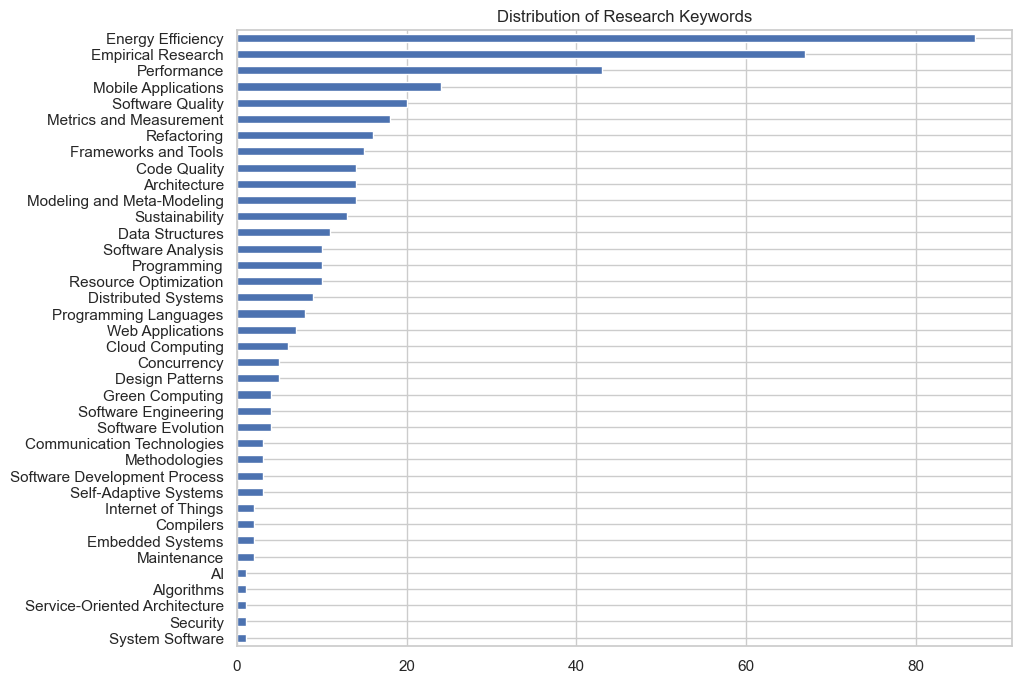

In [469]:
categories = set()
cat_count_snowballing = {}
for index, row in enumerate(snowballing_list["Research_Keywords"].to_list()):
    for category in set(row.split(";")):
        categories.add(category.strip())
        cat_count_snowballing[category.strip()] = cat_count_snowballing.get(category.strip(), 0) + 1
    
for cat in sorted(categories):
    print(f"{cat}: {cat_count_snowballing[cat]}")

pd.Series(cat_count_snowballing).sort_values().plot(kind='barh', figsize=(10, 8), title='Distribution of Research Keywords')
display()

#### Domains

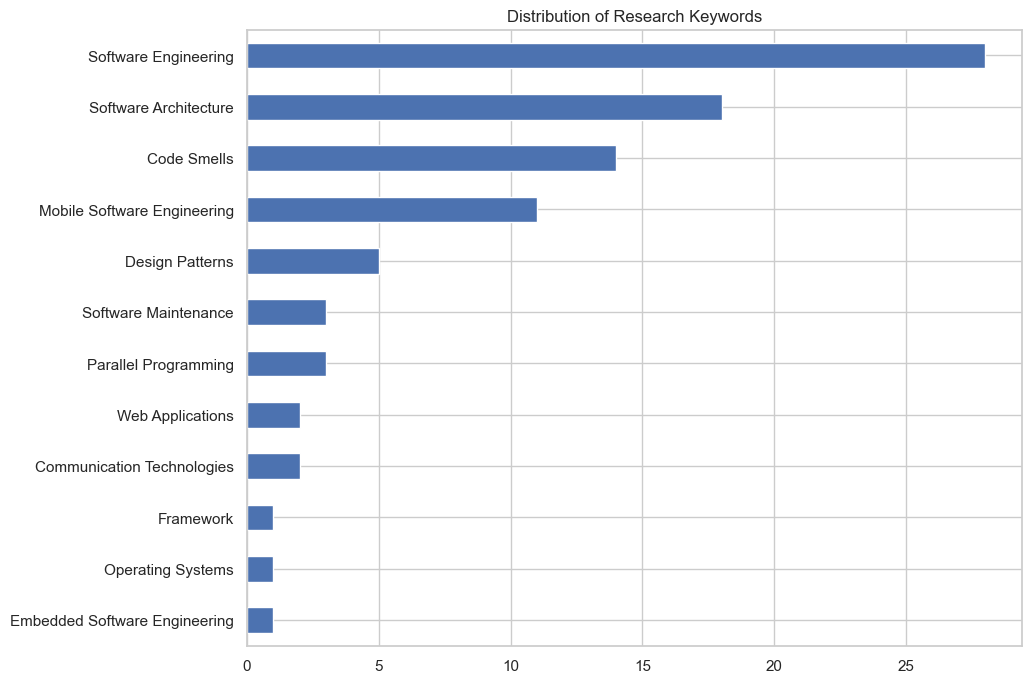

In [470]:
domains = set()
domain_count_snowballing = {}
for index, row in enumerate(snowballing_list["Domain"].to_list()):

    for category in set(row.split(";")):
        categories.add(category.strip())
        domain_count_snowballing[category.strip()] = domain_count_snowballing.get(category.strip(), 0) + 1
    
for cat in sorted(domains):
    print(f"{cat}: {domain_count_snowballing[cat]}")

pd.Series(domain_count_snowballing).sort_values().plot(kind='barh', figsize=(10, 8), title='Distribution of Research Keywords')
display()


## Further Reduction


Due to the large amount of documents retreived from snowballing, we are going to further filter the total list of documents (previously selected + snowballing results) and filter it be more strict criteria listed in the following:
1. (Topic) Exclude papers if:
    1. Hardware focus
    2. Network-level only
    3. Generic approaches like "green computing"
2. (Map) Analyze papers
    1. Keep Software-level decisions
    2. Exclude:
        1. Measurement tools
        2. Benchmarks
        3. Low-level (Below Software Design)

In [471]:
snowballing_list['source'] = "snowballing"
structurized_list['source'] = "initial"

# Make keywords "distinct" in their cell 

structurized_list = structurized_list.assign(Research_Keywords=structurized_list['Research_Keywords'].apply(lambda x: '; '.join(sorted(set([kw.strip() for kw in x.split(';')])))))
#Excluding 'Energy-Efficient Software' since it just summarizes other primary study thats already present
structurized_list = structurized_list[structurized_list["Title"]!='Energy-Efficient Software']
structurized_list = structurized_list.reset_index(drop=True)
combined_list = pd.concat([snowballing_list[['Title', 'DOI', 'Abstract', 'Year', 'source',  'Domain', 'Research_Keywords', 'Research_Approach', 'Context', 'Contribution']], structurized_list[['Title', 'DOI', 'Abstract', 'Year', 'source', 'Domain', 'Research_Keywords', 'Research_Approach', 'Context', 'Contribution']]]).sort_values(by='Title').reset_index(drop=True)
display(combined_list.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Title              158 non-null    object 
 1   DOI                144 non-null    object 
 2   Abstract           152 non-null    object 
 3   Year               157 non-null    float64
 4   source             158 non-null    object 
 5   Domain             158 non-null    object 
 6   Research_Keywords  158 non-null    object 
 7   Research_Approach  158 non-null    object 
 8   Context            158 non-null    object 
 9   Contribution       158 non-null    object 
dtypes: float64(1), object(9)
memory usage: 12.5+ KB


/var/folders/pg/xktlq8917zj4gsm41nm520z00000gn/T/ipykernel_45720/2790989016.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  structurized_list['source'] = "initial"


None

### Research Keyword combined

AI: 7
Algorithms: 1
Architecture: 36
Cloud Computing: 11
Code Quality: 19
Communication Technologies: 7
Compilers: 4
Concurrency: 6
Data Structures: 12
Design Patterns: 19
Distributed Systems: 15
Embedded Systems: 10
Empirical Research: 70
Energy Efficiency: 154
Frameworks and Tools: 23
Green Computing: 6
Internet of Things: 6
Knowledge Management: 1
Maintenance: 5
Methodologies: 4
Metrics and Measurement: 31
Mobile Applications: 33
Modeling and Meta-Modeling: 16
Performance: 50
Programming: 21
Programming Languages: 14
Refactoring: 22
Resource Optimization: 14
Security: 2
Self-Adaptive Systems: 4
Service-Oriented Architecture: 1
Software Analysis: 17
Software Development Process: 8
Software Engineering: 42
Software Evolution: 5
Software Quality: 24
Sustainability: 22
System Software: 3
Web Applications: 10


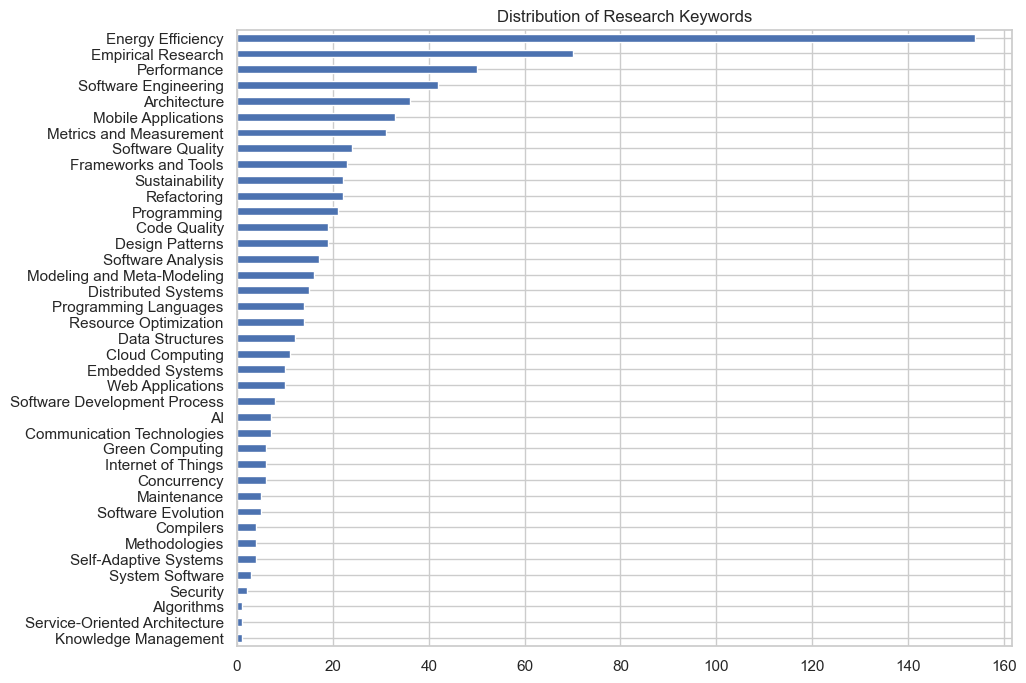

In [472]:
combined_keywords = set()
combined_keywords_count = {}
for index, row in enumerate(combined_list["Research_Keywords"].to_list()):
    for category in set(row.split(";")):
        combined_keywords.add(category.strip())
        combined_keywords_count[category.strip()] = combined_keywords_count.get(category.strip(), 0) + 1
    
for cat in sorted(combined_keywords):
    print(f"{cat}: {combined_keywords_count[cat]}")

pd.Series(combined_keywords_count).sort_values().plot(kind='barh', figsize=(10, 8), title='Distribution of Research Keywords')
display()

### Domain combined

Code Smells: 16
Communication Technologies: 4
Design Patterns: 9
Embedded Software Engineering: 8
Framework: 3
Mobile Software Engineering: 17
Operating Systems: 2
Parallel Programming: 4
Software Architecture: 40
Software Engineering: 47
Software Maintenance: 5
Software Modelling: 1
Web Applications: 2


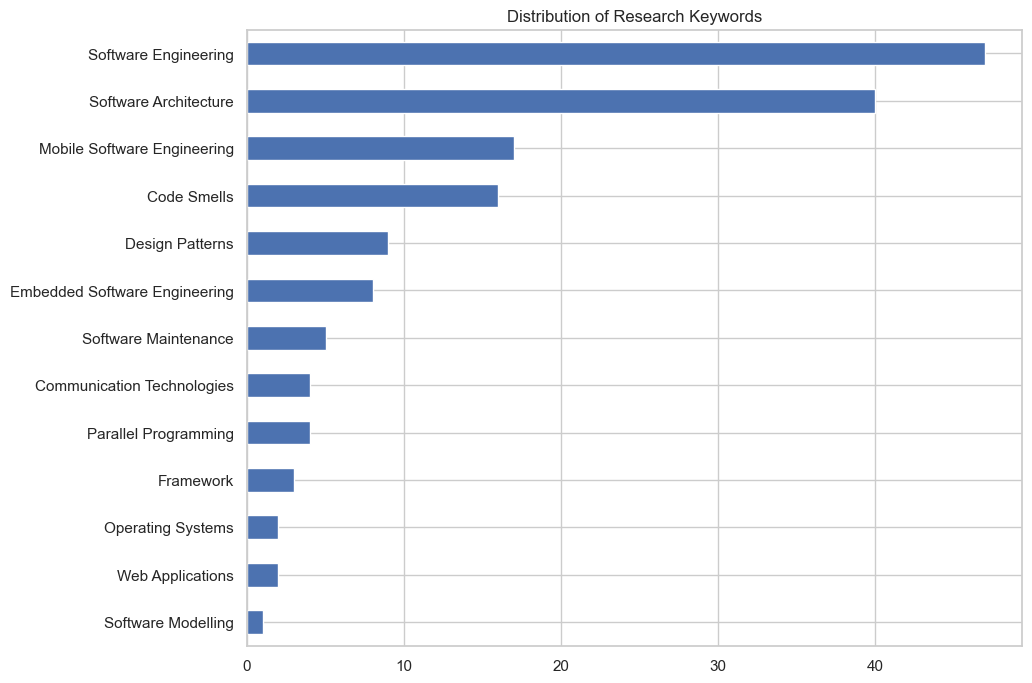

In [473]:
combined_domains = set()
combined_dom_count = {}

for index, row in enumerate(combined_list["Domain"].to_list()):
    for domain in set(row.split(";")):
        combined_domains.add(domain.strip())
        combined_dom_count[domain.strip()] = combined_dom_count.get(domain.strip(), 0) + 1
    
for domain in sorted(combined_domains):
    print(f"{domain}: {combined_dom_count[domain    ]}")

pd.Series(combined_dom_count).sort_values().plot(kind='barh', figsize=(10, 8), title='Distribution of Research Keywords')
display()

### Check Contributions

<Axes: title={'center': 'Distribution of Contribution Types'}, ylabel='Contribution'>

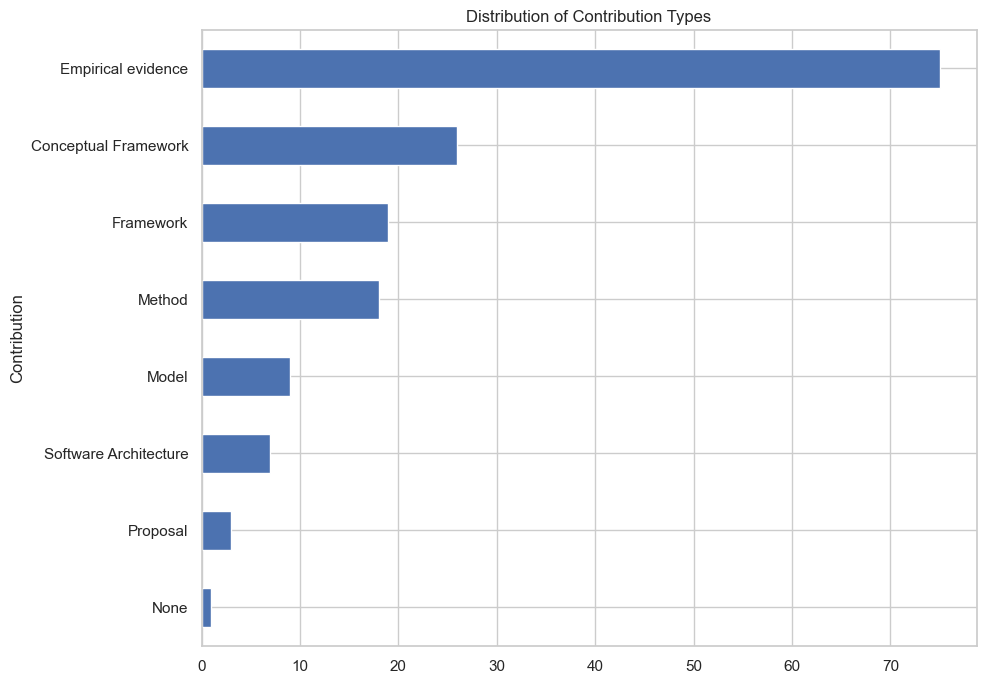

In [474]:
combined_list['Contribution'].value_counts().sort_values().plot(kind='barh', figsize=(10, 8), title='Distribution of Contribution Types')



<Axes: title={'center': 'Distribution of Contribution Types'}>

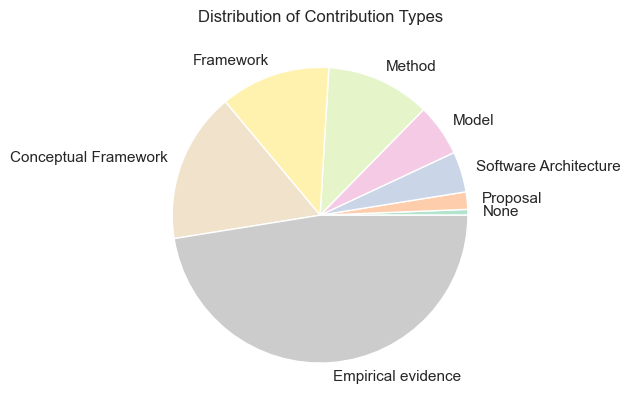

In [475]:
combined_list['Contribution'].value_counts().sort_values().plot(kind='pie', title='Distribution of Contribution Types', xlabel="", ylabel="", colormap="Pastel2")

### Check Research Approach

<Axes: title={'center': 'Distribution of Research Approaches'}, ylabel='count'>

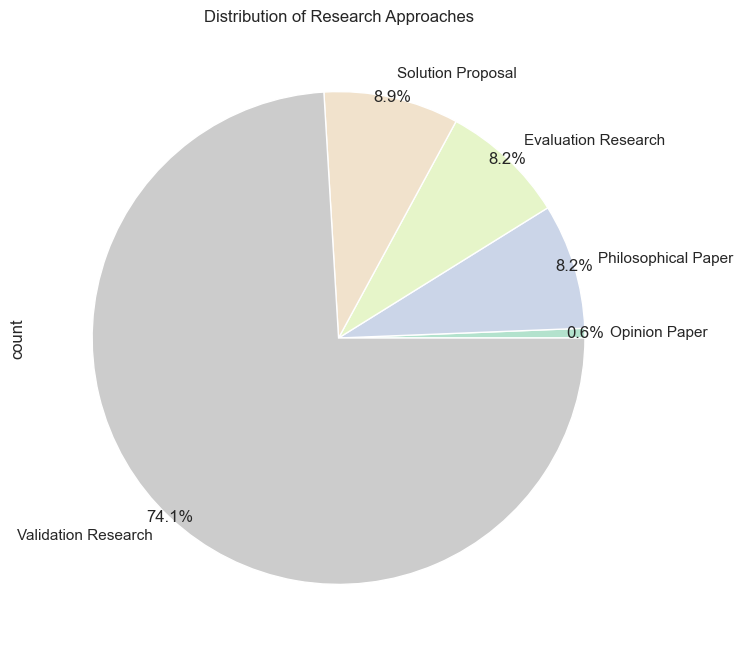

In [476]:
combined_list['Research_Approach'].value_counts().sort_values().plot(kind='pie', figsize=(10, 8), title='Distribution of Research Approaches', autopct='%1.1f%%', pctdistance=1, colormap="Pastel2")

### Check non "Software Engineering" Papers

<Axes: xlabel='Domain', ylabel='Research_Keywords'>

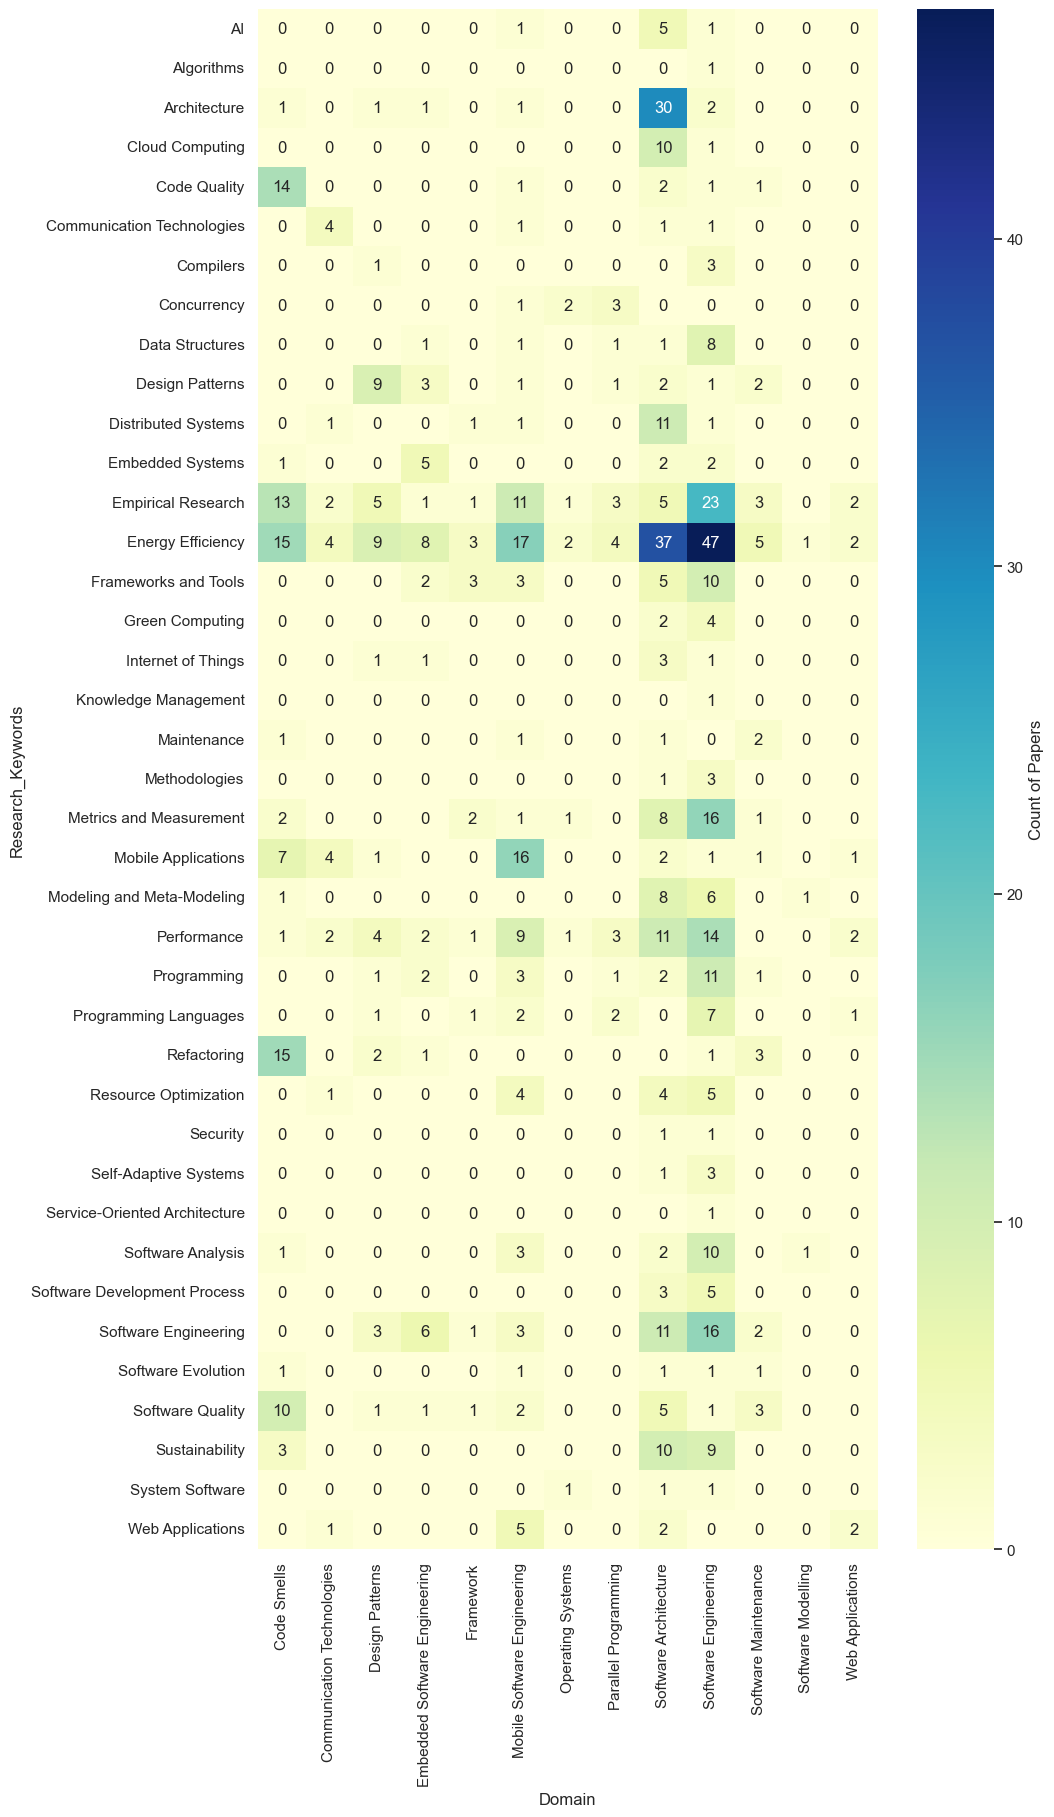

In [477]:
keywords_and_domain = combined_list.assign(**{'Research_Keywords': combined_list['Research_Keywords'].apply(lambda x: list(set([i.strip() for i in x.split(';')])))}).explode('Research_Keywords')[['Research_Keywords', 'Domain']]


matrix = keywords_and_domain.groupby(['Domain', 'Research_Keywords']).size().unstack(fill_value=0)

sns.set_theme(rc={'figure.figsize':(10,20)})
sns.heatmap(matrix.T, annot=True,  cmap='YlGnBu', cbar_kws={'label': 'Count of Papers'})

In [478]:
matrix = combined_list
# matrix = matrix.assign(**{'Research Keywords': combined_list['Research Keywords'].apply(lambda x: list(set([i.strip() for i in x.split(';')])))})

matrix


,Title,DOI,Abstract,Year,source,Domain,Research_Keywords,Research_Approach,Context,Contribution
0,A Comparative Analysis of Monolith vs Microser...,10.1007/978-3-032-02138-0_17,As energy demands rise and sustainability beco...,2026.0,initial,Software Architecture,Architecture; Energy Efficiency,Validation Research,"Two Open Source Java-Applications, each implem...",Empirical evidence
1,A Green Perspective on Structured Parallel Pro...,10.1109/PDP.2015.116,"Structured parallel programming, and in partic...",2015.0,initial,Software Architecture,Architecture; Distributed Systems; Energy Effi...,Validation Research,Five distributed system styles; Framework esti...,Framework
2,A Highly-efficient Lattice-based Post-Quantum ...,10.46586/tches.v2024.i2.130-153,"Lattice-Based Cryptography (LBC) schemes, like...",2024.0,initial,Parallel Programming,Design Patterns; Energy Efficiency; Programming,Validation Research,Parallel Software Systems,Conceptual Framework
3,A Multi-Sensor-Based System for Cardiovascular...,10.1109/ICSI64877.2025.11009742,With the rising prevalence of cardiovascular d...,2025.0,initial,Software Architecture,Architecture; Code Quality; Energy Efficiency,Solution Proposal,Development Lifecycle of microservice-based apps,Framework
4,A blessing in disguise? Assessing the Relation...,10.1109/icsme46990.2020.00088,Code smells have always been associated with b...,2020.0,snowballing,Code Smells,Code Quality; Sustainability; Software Quality...,Philosophical Paper,The paper discusses planned research to invest...,None
...,...,...,...,...,...,...,...,...,...,...
153,Understanding the impact of cloud patterns on ...,10.1016/j.jss.2018.03.063,Cloud patterns are abstract solutions to recur...,2018.0,initial,Software Architecture,Architecture; Cloud Computing; Design Patterns...,Validation Research,Cloud-deployed multi-process and multi-threade...,Empirical evidence
154,Understanding the impact of object oriented pr...,10.1109/IGCC.2017.8323605,With billions of lines of code being deployed ...,2017.0,initial,Software Engineering,Design Patterns; Energy Efficiency; Performanc...,Validation Research,Software systems analyzed through empirical ex...,Empirical evidence
155,Understanding the performance-energy tradeoffs...,10.1109/saner60148.2024.00069,Object-Relational Mapping (ORM) frameworks are...,2024.0,snowballing,Framework,Energy Efficiency; Frameworks and Tools; Perfo...,Validation Research,The study empirically evaluates different conf...,Empirical evidence
156,Unit testing of energy consumption of software...,10.1145/2554850.2554932,The development of energy-efficient software h...,2014.0,snowballing,Software Engineering,Energy Efficiency; Metrics and Measurement; So...,Validation Research,"The study proposes and validates JalenUnit, a ...",Framework


In [479]:
combined_list[['Title', 'Research_Keywords', 'Research_Approach', 'Context', 'Contribution']]

,Title,Research_Keywords,Research_Approach,Context,Contribution
0,A Comparative Analysis of Monolith vs Microser...,Architecture; Energy Efficiency,Validation Research,"Two Open Source Java-Applications, each implem...",Empirical evidence
1,A Green Perspective on Structured Parallel Pro...,Architecture; Distributed Systems; Energy Effi...,Validation Research,Five distributed system styles; Framework esti...,Framework
2,A Highly-efficient Lattice-based Post-Quantum ...,Design Patterns; Energy Efficiency; Programming,Validation Research,Parallel Software Systems,Conceptual Framework
3,A Multi-Sensor-Based System for Cardiovascular...,Architecture; Code Quality; Energy Efficiency,Solution Proposal,Development Lifecycle of microservice-based apps,Framework
4,A blessing in disguise? Assessing the Relation...,Code Quality; Sustainability; Software Quality...,Philosophical Paper,The paper discusses planned research to invest...,None
...,...,...,...,...,...
153,Understanding the impact of cloud patterns on ...,Architecture; Cloud Computing; Design Patterns...,Validation Research,Cloud-deployed multi-process and multi-threade...,Empirical evidence
154,Understanding the impact of object oriented pr...,Design Patterns; Energy Efficiency; Performanc...,Validation Research,Software systems analyzed through empirical ex...,Empirical evidence
155,Understanding the performance-energy tradeoffs...,Energy Efficiency; Frameworks and Tools; Perfo...,Validation Research,The study empirically evaluates different conf...,Empirical evidence
156,Unit testing of energy consumption of software...,Energy Efficiency; Metrics and Measurement; So...,Validation Research,"The study proposes and validates JalenUnit, a ...",Framework


### Keyword and domain scoring
For further reduction, we are going score the keywords and domains. Keywords as well as domains are being assigned a score. Then each document in the combined list is assigned a score based on their research keywords and domain.


We define a scoring range of 0-4 points per aspect considered. This leads to the following forumla:

$s_{Document} = s_{Reasearch Keywords} + s_{Domain} + s_{Contribution} + s_{ResearchApproach}$



#### Research Keywords
For the research keywords we choose an intervall of 0-2 points per research keywords and select the two best keywords for scoring. Therefore we have a total score of 4 points possible. We additionally added 0 points for those keywords that are already present in other aspects in order to avoid double scoring.


The domains with high relevance (2 points) are directly tackling software design like:
* Algorithms
* Programming
* Refactoring

Medium-High-relevance (1.5 points) are design-enabling:
* Data Structures
* Frameworks and Tools 
* Programming Languages


Medium relevance (1 point) isn't directly affecting the software design itself:
* Code Quality
* Concurrency
* Energy Efficiency
* Maintenance
* Resource Optimization
* Service-Oriented Architecture (Specific archtitecture)
* Software Development Process
* Software Quality


Low relevance (0.5 points) keywords are:
* Cloud Computing
* Communication Technologies
* Compilers
* Distributed Systems
* Metrics and Measurements
* Mobile Applications
* Modeling and Meta-Modeling
* Performance
* Self-Adaptive Systems
* Software Analysis
* Software Evolution
* System Software
* Web Applications


Ignore (0 points) to generic or already present somewhere else:
* AI => No relevance for software design
* Architecture => Contribution (Software Architecture)
* Design Patterns => Domain
* Embedded Systems => Domain
* Empirical Research => Research Approach
* Green Computing => Too generig
* Internet of Things  => Too generic
* Knowledge Management => No relevance for software design
* Maintenance => Domain
* Methodologies => Contribution
* Security => No relevance for software design
* Software Engineering => Domain
* Sustainability => Too generic 


#### Domain
We apply a smiliar scoring on the domain with high, medium and low relevance:


high-relevance (4 points):
* Code Smells
* Design Patterns
* Software Architecture

medium-high-relevance(3 points):
* Mobile Software Engineering
* Software Engineering 
* Software Maintenance

medium-relevance (2 points):
* Distributed Systems
* Framework
* Parallel Programming
* Software Modelling

low-relevance (1 points):
* Communication Technologies
* Embedded Software Engineering
* Operating Systems
* Web Applications


#### Contribution
The most important contribution for this study is empirical evidence, followed by models and methods that are generally appllicable. Medium important are concrete frameworks or software architectures due to their specifity and non generalistic character. Conceptual frameworks and proposals are the lowest rank, followed by documents that dont provide a contribution overall.

*The authors are aware of the fact, that Contribution and Domain contain Framework and Software Architecture. We keep these scores in both, because domain and contribution each only have one value assigned. Additonally, a document can contribute empirical evidence on the domain software architeture and therefore be differnent from 'software architecture' contributions.*

#### Research Approach
We decided to select evaluation research to be most important due to their application in practice followed by validation research becuse it is the *last* step before application in practice. Solution proposals offer a solution to problems but are not evaluated or validated and go third. The lowest scorings are applied to philosophical paper and opinion papers.

<div style="display: flex; flex-direction: row; justify-content:center; gap: 4px;">
<div>

| Keyword                       | Score |
| ----------------------------- | :---- |
| AI                            | 0     |
| Algorithms                    | 2     |
| Architecture                  | 0     |
| Cloud Computing               | 0.5   |
| Code Quality                  | 1     |
| Communication Technologies    | 0.5   |
| Compilers                     | 0.5   |
| Concurrency                   | 1     |
| Data Structures               | 1.5   |
| Design Patterns               | 0     |
| Distributed Systems           | 0.5   |
| Embedded Systems              | 0     |
| Empirical Research            | 0     |
| Energy Efficiency             | 1     |
| Frameworks and Tools          | 1.5   |
| Green Computing               | 0     |
| Internet of Things            | 0     |
| Knowledge Management          | 0     |
| Maintenance                   | 0     |
| Methodologies                 | 0     |
| Metrics and Measurement       | 0.5   |
| Mobile Applications           | 0.5   |
| Modeling and Meta-Modeling    | 0.5   |
| Performance                   | 0.5   |
| Programming                   | 2     |
| Programming Languages         | 1.5   |
| Refactoring                   | 2     |
| Resource Optimization         | 1     |
| Security                      | 0     |
| Self-Adaptive Systems         | 0.5   |
| Service-Oriented Architecture | 1     |
| Software Analysis             | 0.5   |
| Software Development Process  | 1     |
| Software Engineering          | 0     |
| Software Evolution            | 0.5   |
| Software Quality              | 1     |
| Sustainability                | 0     |
| System Software               | 0.5   |
| Web Applications              | 0.5   |


</div>
<div>

| Domain                        | Score |
| :---------------------------- | :---- |
| Code Smells                   | 3     |
| Communication Technologies    | 1     |
| Design Patterns               | 3     |
| Distributed Systems           | 2     |
| Embedded Software Engineering | 1     |
| Framework                     | 2     |
| Mobile Software Engineering   | 3     |
| Operating Systems             | 1     |
| Parallel Programming          | 2     |
| Software Architecture         | 4     |
| Software Engineering          | 3     |
| Software Maintenance          | 3     |
| Software Modelling            | 2     |
| Web Applications              | 1     |

</div>


<div>

| Contribution          | Score |
| :-------------------- | :---- |
| Conceptual Framework  | 1     |
| Empirical evidence    | 4     |
| Framework             | 2     |
| Method                | 3     |
| Model                 | 3     |
| None                  | 0     |
| Proposal              | 1     |
| Software Architecture | 2     |

<div>
</div>

| Research Approach   | Score |
| :------------------ | :---- |
| Evaluation Research | 4     |
| Opinion Paper      | 0     |
| Philosophical Paper | 1     |
| Solution Proposal   | 2     |
| Validation Research | 3     |

</div>
</div>

In [480]:
keyword_scores = {
"AI" : 0,
"Algorithms" : 2,
"Architecture" :0,
"Cloud Computing" : 0.5,
"Code Quality" : 1,
"Communication Technologies" : 0.5,
"Compilers" : 0.5,
"Concurrency" : 1,
"Data Structures" : 1.5,
"Design Patterns" : 0,
"Distributed Systems" : 0.5,
"Embedded Systems" : 0,
"Empirical Research" : 0,
"Energy Efficiency" : 1,
"Frameworks and Tools" : 1.5,
"Green Computing" : 0,
"Internet of Things" : 0,
"Knowledge Management" : 0,
"Maintenance" : 0,
"Methodologies" : 0,
"Metrics and Measurement" : 0.5,
"Mobile Applications" : 0.5,
"Modeling and Meta-Modeling" : 0.5,
"Performance" : 0.5,
"Programming" : 2,
"Programming Languages" : 1.5,
"Refactoring" : 2,
"Resource Optimization" : 1,
"Security" : 0,
"Self-Adaptive Systems" : 0.5,
"Service-Oriented Architecture" : 1,
"Software Analysis" : 0.5,
"Software Development Process" : 1,
"Software Engineering" : 0,
"Software Evolution" : 0.5,
"Software Quality" : 1,
"Sustainability" : 0,
"System Software" : 0.5,
"Web Applications" : 0.5,
}


domain_scores = {
"Code Smells": 3,
"Communication Technologies": 1,
"Design Patterns": 3,
"Distributed Systems": 2,
"Embedded Software Engineering": 1,
"Framework": 2,
"Mobile Software Engineering": 3,
"Operating Systems": 1,
"Parallel Programming": 2,
"Software Architecture": 4,
"Software Engineering": 3,
"Software Maintenance": 3,
"Software Modelling": 2,
"Web Applications": 1,
}

contribution_scores = {
"Conceptual Framework": 1,
"Empirical evidence": 4,
"Framework": 2,
"Method": 3,
"Model": 3,
"None": 0,
"Proposal": 1,
"Software Architecture": 2,
}

research_approach_scores = {
"Evaluation Research": 4,
"Opinion Paper": 0,
"Philosophical Paper": 1,
"Solution Proposal": 2,
"Validation Research": 3,
}

array([  1,   5,   9,  30,  46,  60,  90,  99, 114, 121, 130, 135, 139,
       142, 144, 151, 154, 157, 158])

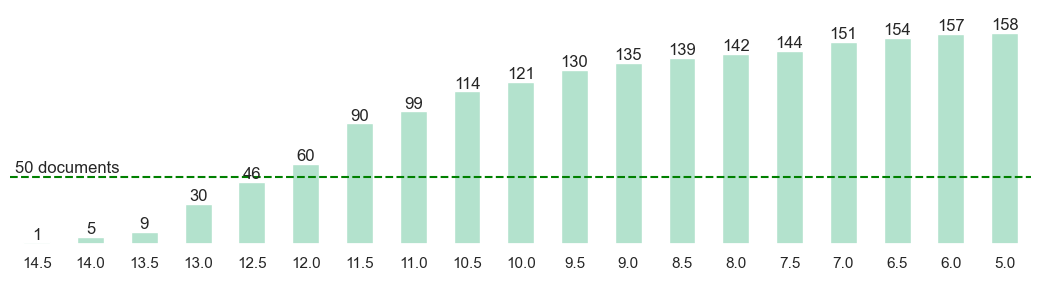

In [489]:
# plt.style.use('seaborn-v0_8-talk')
#plt.style.use('Pastel1')
for index, row in combined_list.iterrows():
    # print(f"{index}: {row['Title']} - {row['Research_Keywords']} - {row['Research_Approach']} - {row['Context']} - {row['Contribution']}")
    document_score = 0
    keyword_scores_values = []
    for keyword in row['Research_Keywords'].split(';'):
        keyword_score = keyword_scores.get(keyword.strip(), None)
        if keyword_score is None:
            print(f"Keyword '{keyword.strip()}' not found in keyword_scores dictionary.")
        keyword_scores_values.append(keyword_score)

    domain_score = domain_scores.get(row['Domain'].strip(), None)
    if domain_score is None:
        print(f"Domain '{row['Domain'].strip()}' not found in domain_scores dictionary.")
    contribution_score = contribution_scores.get(row['Contribution'].strip(), None)
    if contribution_score is None:
        print(f"Contribution '{row['Contribution'].strip()}' not found in contribution_scores dictionary.")
    research_approach_score = research_approach_scores.get(row['Research_Approach'].strip(), None)
    if research_approach_score is None:
        print(f"Research Approach '{row['Research_Approach'].strip()}' not found in research_approach_scores dictionary.")

    document_score = sum(sorted(keyword_scores_values, reverse=True)[:2]) + (domain_score or 0) + (contribution_score or 0) + (research_approach_score or 0)

    combined_list.at[index, 'Document_Score'] = document_score

fig, axes = plt.subplots(1, 1, figsize=(11, 3))
fig.tight_layout(pad=1.0)
document_score_counts = combined_list.value_counts('Document_Score').sort_index(ascending=False)
#combined_list.value_counts('Document_Score').sort_index().plot(title='Distribution of Document Scores', ax=axes[0], xlabel='Document Score', ylabel='Number of Documents')

consumed_document_scores = document_score_counts.cumsum()
# axes[1].set_xticks(consumed_document_scores.values)
display(consumed_document_scores.values)
hbars = consumed_document_scores.plot(kind='bar', xlabel="", grid=False, colormap="Pastel2")
hbars.set_ylim(0, 175)
hbars.hlines(50, -.5,100, linestyles='dashed', color="green")
hbars.annotate('50 documents',(-0.4,53))
hbars.bar_label(hbars.containers[0], consumed_document_scores.values, fmt='%.0f')
hbars.tick_params(axis='x', rotation=0)
hbars.set_facecolor('white')
hbars.spines['top'].set_visible(False)
hbars.spines['right'].set_visible(False)
hbars.spines['left'].set_visible(False)
hbars.set_yticklabels([])
#axes.set_title('Cumulative Distribution of Document Scores', fontsize=14, fontweight='bold')
plt.show()
fig.savefig('../output/03-Mapping/images/cumulative_distribution.png', bbox_inches='tight', transparent=True)
# axes[1].bar_label(hbars, fmt='%.2f')


## Reduction results
We identified 50 studies by reduction using scoring showed in the following table:

In [482]:
selection_after_snowballing = combined_list[combined_list['Document_Score'] >= 12]
selection_after_snowballing = selection_after_snowballing.convert_dtypes()
selection_after_snowballing.to_csv("../output/03-Mapping/finally_selected_studies.csv", index=False)

Framework                       1
Parallel Programming            1
Design\nPatterns                3
Software\nMaintenance           4
Mobile Software Engineering     8
Code\nSmells                   13
Software\nArchitecture         13
Software\nEngineering          17
dtype: int64

Research_Approach
Solution\nProposal       1
Evaluation\nResearch    12
Validation\nResearch    47
Name: count, dtype: int64

Contribution
Model                   3
Method                  7
Empirical\nEvidence    50
Name: count, dtype: int64

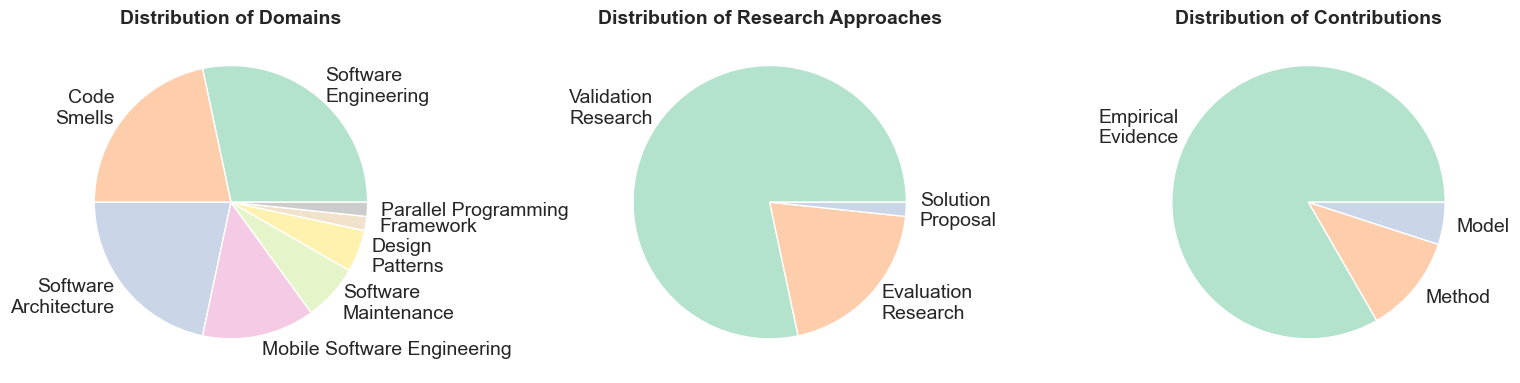

In [483]:
final_categories = set()
final_cat_count_snowballing = {}

# fig.tight_layout(pad=2.0)

for index, row in enumerate(selection_after_snowballing["Research_Keywords"].to_list()):

    for category in set(row.split(";")):
        final_categories.add(category.strip())
        final_cat_count_snowballing[category.strip()] = final_cat_count_snowballing.get(category.strip(), 0) + 1
    
fig, axes = plt.subplots(1, 3, figsize=(15, 5), gridspec_kw={'width_ratios': [1, 1, 1]})
#pd.Series(final_cat_count_snowballing).sort_values().plot(kind='barh', figsize=(10, 8), title='Distribution of Research Keywords', ax=axes[0])



# fig.set_figwidth(400)
final_domains = set()
final_domain_count_snowballing = {}
for index, row in enumerate(selection_after_snowballing["Domain"].to_list()):

    for category in set(row.split(";")):
        final_domains.add(category.strip())
        final_domain_count_snowballing[category.strip()] = final_domain_count_snowballing.get(category.strip(), 0) + 1

for domain in sorted(final_domain_count_snowballing):
    final_domain_count_snowballing[domain.replace(" ", "\n")] = final_domain_count_snowballing.pop(domain)

final_domain_count_snowballing['Parallel Programming'] = final_domain_count_snowballing.pop('Parallel\nProgramming')
final_domain_count_snowballing['Mobile Software Engineering'] = final_domain_count_snowballing.pop('Mobile\nSoftware\nEngineering')
research_approach_series = selection_after_snowballing['Research_Approach'].apply(lambda x: x.replace(" ", "\n"))
contribution_series = selection_after_snowballing['Contribution'].apply(lambda x: x.replace("evidence", "Evidence").replace(" ", "\n"))

pastel2 = list(plt.get_cmap("Pastel2").colors)
pastel2_no_gray = [c for i, c in enumerate(pastel2) if i != 8]
display(pd.Series(final_domain_count_snowballing).sort_values())
display(pd.Series(research_approach_series).value_counts().sort_values())
display(pd.Series(contribution_series).value_counts().sort_values())

ax1 = pd.Series(final_domain_count_snowballing).sort_values(ascending=False).plot(
    kind='pie', 
    ax=axes[0],
    ylabel="",
    fontsize=14,
    colors=pastel2_no_gray[:len(pd.Series(final_domain_count_snowballing))]
)
ax1.set_title('Distribution of Domains', fontsize=14, fontweight='bold')
ax2 = research_approach_series.value_counts().sort_values(ascending=False).plot(
    kind='pie', 
    title='Distribution of Research Approaches', 
    ax=axes[1], 
    ylabel="",
    fontsize=14,
    colors=pastel2_no_gray[:len(research_approach_series.value_counts())]
)
ax2.set_title('Distribution of Research Approaches', fontsize=14, fontweight='bold')
ax3 = contribution_series.value_counts().sort_values(ascending=False).plot(
    kind='pie', 
    title='Distribution of Contributions', 
    ax=axes[2], 
    ylabel="",
    fontsize=14,
    colors=pastel2_no_gray[:len(contribution_series)]
)
ax3.set_title('Distribution of Contributions', fontsize=14, fontweight='bold')
wrap_labels(axes[0], 10)
fig.tight_layout(pad=0.0)
# axes[1].tick_params(axis='x', rotation=45)
#fig.set_size_inches(15,15)
fig.savefig('../output/03-Mapping/images/distribution_after_selection.png', bbox_inches='tight', transparent=True)

In [484]:
selection_after_snowballing[['Title', 'source', 'DOI', 'Year']].sort_values(by=['source', 'Title'])
#HTML(DataFrame(selection_after_snowballing[['Title', 'source', 'DOI', 'Year']].sort_values(by=['source', 'Title'])).to_html())

,Title,source,DOI,Year
0,A Comparative Analysis of Monolith vs Microser...,initial,10.1007/978-3-032-02138-0_17,2026
13,An adaptive offloading framework for Android a...,initial,10.1007/s11432-018-9749-8,2019
16,An empirical evaluation of database software f...,initial,10.29007/9plt,2018
23,Architectural Tactics to Optimize Software for...,initial,10.1109/ICT4S55073.2022.00019,2022
29,Awakening awareness on energy consumption in s...,initial,10.1109/ICSE-SEIS.2017.10,2017
54,Empirical evaluation of two best practices for...,initial,10.1016/j.jss.2016.02.035,2016
55,Energy Consumption of&nbsp;IoT Monitoring Soft...,initial,10.1007/978-3-031-70797-1_15,2024
63,Energy efficiency of the Visitor Pattern: cont...,initial,10.1007/s10664-023-10387-8,2023
72,Estimating the energy consumption of software ...,initial,10.1145/3477314.3507353,2022
73,Evaluating the Impact of Design Pattern Usage ...,initial,10.2478/acss-2021-0001,2021


Research_Approach
Validation Research    47
Evaluation Research    12
Solution Proposal       1
Name: count, dtype: int64

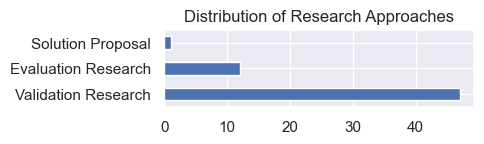

In [485]:

selection_after_snowballing.drop(columns=['Abstract','DOI', 'source']).to_csv("../output/03-Mapping/selected_papers_for_latex_table.csv", index=False)

selection_after_snowballing.value_counts('Research_Approach').plot(kind='barh', figsize=(4, 1), ylabel="", title='Distribution of Research Approaches')
selection_after_snowballing.value_counts('Research_Approach')

Contribution
Empirical evidence    50
Method                 7
Model                  3
Name: count, dtype: int64

,Title,DOI,Abstract,Year,source,Domain,Research_Keywords,Research_Approach,Context,Contribution,Document_Score
0,A Comparative Analysis of Monolith vs Microser...,10.1007/978-3-032-02138-0_17,As energy demands rise and sustainability beco...,2026,initial,Software Architecture,Architecture; Energy Efficiency,Validation Research,"Two Open Source Java-Applications, each implem...",Empirical evidence,12.0


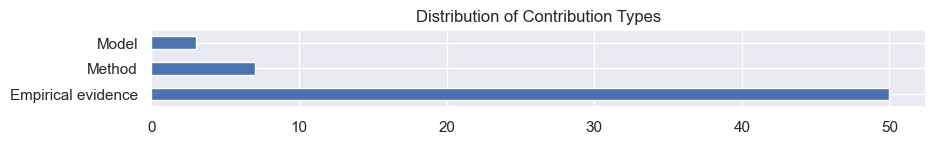

In [486]:
selection_after_snowballing.value_counts('Contribution').plot(kind='barh', figsize=(10, 1), ylabel="", title='Distribution of Contribution Types')
display(selection_after_snowballing.value_counts('Contribution'))
display(selection_after_snowballing[selection_after_snowballing['Year'] == 2026])

Domain
Software Engineering           17
Code Smells                    13
Software Architecture          13
Mobile Software Engineering     8
Software Maintenance            4
Design Patterns                 3
Framework                       1
Parallel Programming            1
Name: count, dtype: int64

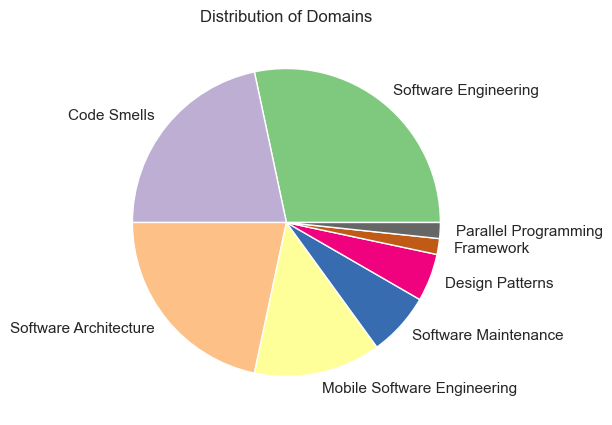

In [487]:
selection_after_snowballing.value_counts('Domain').plot(kind='pie', figsize=(5, 5), ylabel="", xlabel="", title='Distribution of Domains', colormap="Accent")
plt.savefig("../output/03-Mapping/images/distribution_of_domains.png", bbox_inches='tight')
selection_after_snowballing.value_counts('Domain')

FileNotFoundError: [Errno 2] No such file or directory: '../output/images/heatmap_keywords_domains.png'

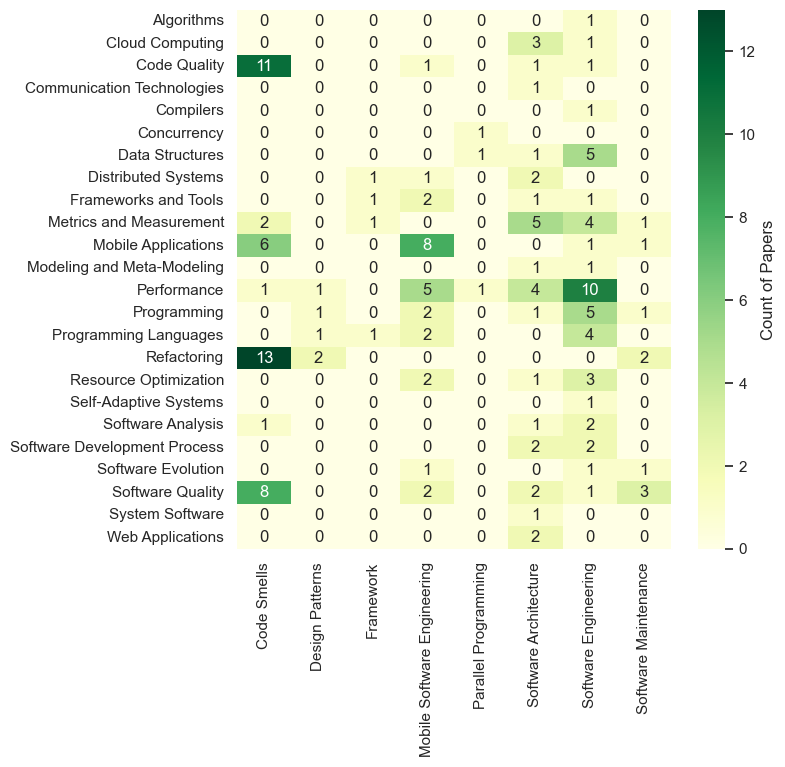

In [488]:
keywords_and_domain_final = selection_after_snowballing.assign(**{'Research_Keywords': selection_after_snowballing['Research_Keywords'].apply(lambda x: list(set([i.strip() for i in x.split(';')])))}).explode('Research_Keywords')[['Research_Keywords', 'Domain']]
keywords_to_exclude_from_matrix = ['AI', 'Architecture', 'Design Patterns', 'Energy Efficiency', 'Embedded Systems', 'Empirical Research', 'Green Computing', 'Internet of Things', 'Knowledge Management', 'Maintenance', 'Methodologies', 'Security', 'Software Engineering', 'Sustainability']
keywords_and_domain_final = keywords_and_domain_final[~keywords_and_domain_final['Research_Keywords'].isin(keywords_to_exclude_from_matrix)]


matrix = keywords_and_domain_final.groupby(['Domain', 'Research_Keywords']).size().unstack(fill_value=0)

sns.set_theme(rc={'figure.figsize':(7,7)})
ax = sns.heatmap(matrix.T, annot=True,  cmap='YlGn', cbar_kws={'label': 'Count of Papers'})
ax.set_xlabel('')
ax.set_ylabel('')
plt.savefig("../output/images/heatmap_keywords_domains.png", bbox_inches='tight')

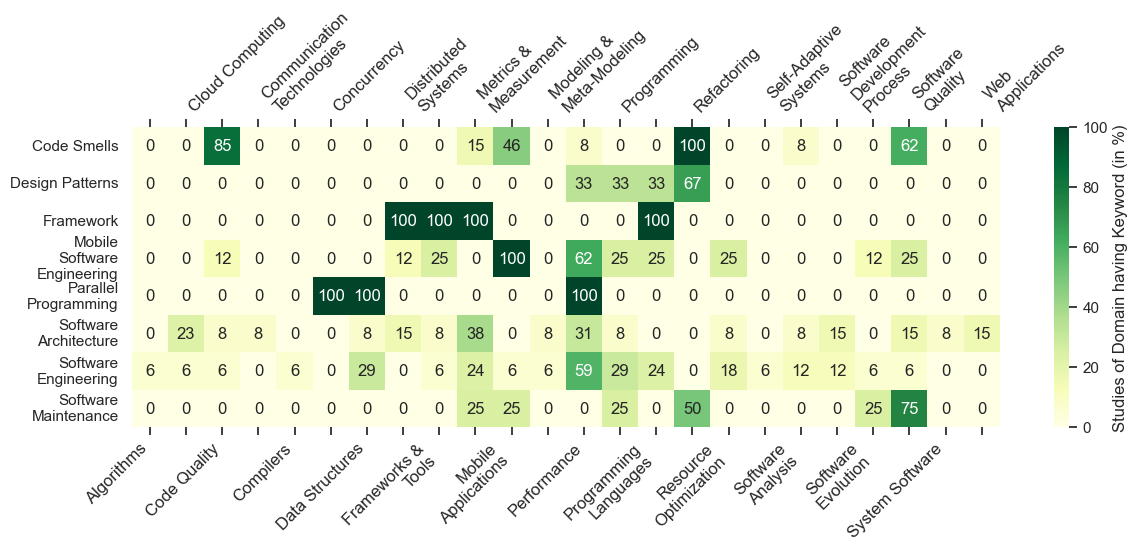

In [ ]:


# clean + explode keywords
test = selection_after_snowballing
test['Domain'] = test['Domain'].apply(lambda x: x.replace(" ", "\n") if len(x) > 15 else x)
# test['Research_Keywords'] = test['Research_Keywords'].apply(lambda x: x.replace(" ", "\n") if len(x) > len("Frameworks and Tools ") else x)
keywords_and_domain_final = (
    test
    .assign(
        Research_Keywords=test['Research_Keywords'].apply(
            lambda x: list(set(i.strip() for i in x.split(';')))
        )
    )
    .explode('Research_Keywords')[['Research_Keywords', 'Domain']]
)

keywords_and_domain_final = keywords_and_domain_final[
    ~keywords_and_domain_final['Research_Keywords'].isin(keywords_to_exclude_from_matrix)
]


# count studies per Domain x Keyword
matrix = (
    keywords_and_domain_final
    .groupby(['Domain', 'Research_Keywords'])
    .size()
    .unstack(fill_value=0)
)

# display(matrix)

# total number of studies per domain FROM ORIGINAL DATAFRAME
domain_totals = selection_after_snowballing.groupby('Domain').size()

# percentage of studies in each domain that have each keyword
matrix_pct = matrix.div(domain_totals, axis=0) * 100

# optional rounding
matrix_pct = matrix_pct.round(2)
sns.set_theme(rc={'figure.figsize':(14,5)})
ax = sns.heatmap(
    matrix_pct, 
    annot=True,  
    cmap='YlGn', 
    cbar_kws={'label': 'Studies of Domain having Keyword (in %)'}, 
    fmt='.0f',

)
ax.set_xticks([])
ax.set_xlabel('')
ax.set_ylabel('')
# wrap_labels(ax, 10)
ax.figure

xlabels = matrix_pct.columns.map(lambda x: x.replace(" ", "\n").replace("\nand\n", " &\n") if len(x) > 15 else x).tolist()

ncols = matrix_pct.shape[1]
nrows = matrix_pct.shape[0]

# Give room for custom labels above and below
plt.subplots_adjust(top=0.82, bottom=0.22)

for i, label in enumerate(xlabels):
    x = i + 0.5
    if i % 2 == 0:
        # bottom
        ax.text(
            x, nrows + 0.35, label,
            rotation=45,
            ha="right",
            va="top",
            clip_on=False
        )
    else:
        # top
        ax.text(
            x, -0.35, label,
            rotation=45,
            ha="left",
            va="bottom",
            clip_on=False
        )

ax.set_xticks(np.arange(ncols) + 0.5)
ax.tick_params(axis='x', which='both', bottom=True, top=True,
               labelbottom=False, labeltop=False)

# plt.show()


plt.savefig("../output/03-Mapping/heatmap_keywords_domains.png", bbox_inches='tight')


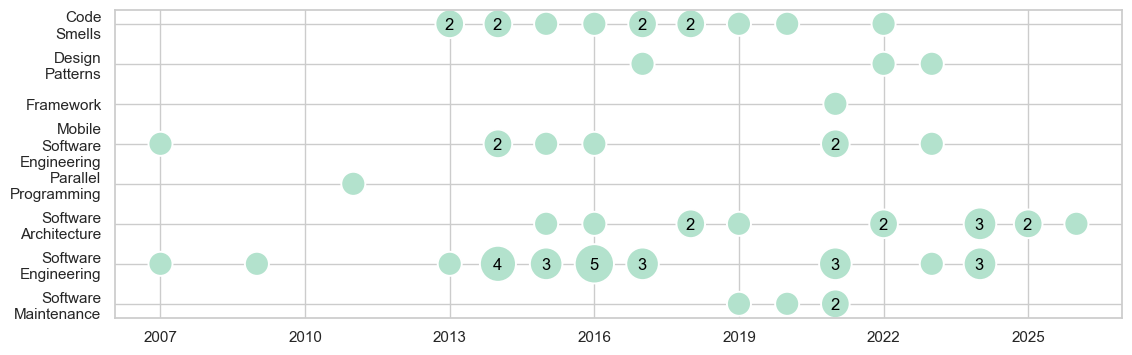

In [ ]:
min_count = 1
# display(selection_after_snowballing['Year'].value_counts())
filtered_domain_pivot = build_pivot_table(selection_after_snowballing, 'Domain', count_by="Year", min_count=min_count)
# display(filtered_domain_pivot)
df = build_long_pivot(filtered_domain_pivot, "Domain")
df = df[df['count'] > 0].sort_values(by='Domain')
df['Year'] = df['Year'].convert_dtypes(convert_integer=True)
df['Domain'] = df['Domain'].apply(lambda x: x.replace(" ", "\n"))
y="Domain"
x="Year"
title=""
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 1, figsize=(13, 4))
# Use sns.scatterplot for bubbles

plot = sns.scatterplot(
    data=df,
    x=x,
    y=y,
    size='count',
    sizes=(300, 800), # Adjust bubble size range
    alpha=1,
    legend=False,
    color=sns.color_palette("Pastel2")[0],
)
for i, row in df.iterrows():
    if row['count'] > 1: # Highlight keywords with count > 2
        plt.annotate(
            f"{row['count']}",
            (row[x], row[y]),
            textcoords="offset points",
            xytext=(-0.5,-4),
            ha='center',
            fontsize=12,
            color='black',
        )
# plot.legend_.remove()
#all_years = df['Year'].convert_dtypes(convert_integer=True).unique()
# print(all_years)
# Add labels and title
from matplotlib.ticker import MaxNLocator
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.xlabel("")
plt.ylabel("")
#wrap_labels(plot, 90)
plt.title(title, fontsize=14, fontweight='bold')
# Show the plot
plt.show
plt.savefig("../output/03-Mapping/images/bubble_chart_domains_over_time.png", bbox_inches='tight')

In [ ]:
selection_after_snowballing[selection_after_snowballing['Domain'] == 'Design Patterns']['Title']

HTML(DataFrame(selection_after_snowballing[selection_after_snowballing['Domain'] == 'Design Patterns']).to_html())

,Title,DOI,Abstract,Year,source,Domain,Research_Keywords,Research_Approach,Context,Contribution,Document_Score
63,Energy efficiency of the Visitor Pattern: contrasting Java and C++ implementations,10.1007/s10664-023-10387-8,"Design patterns are applied frequently during software evolution in order to make the software more flexible and amenable to extension. One little-studied aspect of design patterns is their propensity to increase run-time energy consumption due to the indirection and additional structure they introduce. In this paper we study the impact of the Visitor pattern on energy efficiency. The Visitor pattern separates an algorithm from the objects it acts upon and improves maintainability by placing each algorithm within a single visitor class. This is at the cost of increased indirection due to the double dispatch required when the algorithm is invoked. We experimentally investigate the energy impact of varying the implementation of this pattern, and of removing the pattern entirely from software written in Java and C++. In our results we observe energy consumption reductions greater than 7% in a Java-based textbook example when the pattern is implemented using reflective dispatch, and reductions of over 10% when experimenting with an open source Java project, JavaParser. The complete removal of the pattern yields more complex results, with little impact in the textbook example but reductions of over 7% in the JavaParser study. To explore the generalisability of our findings, we subsequently apply the same transformations to the C++ based CppParser. Total pattern removal here sees energy consumption reductions of over 66% while the reflective dispatch approach increases energy consumption by up to 2012%. Our results highlight the energy savings that can be achieved when the Visitor pattern is removed both in Java and C++ implementations, and also show that some language specific features can allow for further energy savings when the implementation of the pattern is varied.",2023,initial,Design Patterns,Design Patterns; Energy Efficiency; Programming Languages,Validation Research,Software systems implemented in Java and C++ evaluated through controlled experiments on pattern variants and real-world projects resulting in empirical evidence on how different implementations and removal of the Visitor design pattern affect software energy consumption across programming languages,Empirical evidence,12.5
94,Investigating the effect of design patterns on energy consumption,10.1002/smr.1851,"AbstractGang of Four (GoF) patterns are well‚Äêknown best practices for the design of object‚Äêoriented systems. In this paper, we aim at empirically assessing their relationship to energy consumption, ie, a performance indicator that has recently attracted the attention of both researchers and practitioners. To achieve this goal, we investigate pattern‚Äêparticipating methods (ie, those that play a role within the pattern) and compare their energy consumption to the consumption of functionally equivalent alternative (nonpattern) solutions. We obtained the alternative solution by refactoring the pattern instances using well‚Äêknown transformations (eg, replace polymorphism with conditional statements). The comparison is performed on 169 methods of 2 GoF patterns (namely, State/Strategy and Template Method), retrieved from 2 well‚Äêknown open source projects. The results suggest that for the majority of cases the alternative design excels in terms of energy consumption. However, in some cases (eg, when the method is large in size or invokes many methods) the pattern solution presents similar or lower energy consumption. The outcome of our study can be useful to both researchers and practitioners, because we: (1) provide evidence on a possible negative effect of GoF patterns, and (2) can provide guidance on which cases the use of the pattern is not hurting energy consumption.",2017,snowballing,Design Patterns,Energy Efficiency; Design P